## 題號 1 (*)
**問題**: 周天成使用「殺球」得分佔他總得分的百分比是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確保 DataFrame 有資料
if len(df) > 0:
    # 取得周天成所有得分的回合
    chou_total_win = df[df['getpoint_player'] == 'CHOU Tien Chen']

    # 篩選出周天成使用「殺球」得分的回合
    chou_smash_win = chou_total_win[chou_total_win['type'] == '殺球']

    # 計算殺球得分次數和總得分次數
    smash_win_count = len(chou_smash_win)
    total_win_count = len(chou_total_win)

    # 計算百分比
    if total_win_count > 0:
        smash_win_percentage = (smash_win_count / total_win_count) * 100
    else:
        smash_win_percentage = 0
    
    print(f"周天成使用「殺球」得分佔他總得分的百分比為：{smash_win_percentage:.2f}%")
else:
    print("資料集為空，無法進行計算。")


### 數據洞察
根據數據，周天成的總得分中有39.80%來自於「殺球」。這意味著他在比賽中非常依賴這項技術來獲取分數。這個比例顯示出他的進攻風格偏向於積極主動，尤其是在進行快速進攻時，他的殺球能力是他得分的主要來源之一。

從戰術角度來看，這樣的數據表明對手在對陣周天成時，必須特別注意他的殺球策略，並需要加強接殺防守的訓練，以降低周天成的得分效率。同時，周天成也可以考慮在某些情況下多樣化他的進攻手段，以防止對手過於針對他的殺球進行防守布置。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都強調需要確認周天成的主動得分，即 'getpoint_player' 必須等於 'player'，而候選程式碼只檢查 'getpoint_player' 是否等於 'CHOU Tien Chen'，未能區分主動得分和被動得分。此外，候選程式碼未能正確對齊回合結束的擊球，可能混入非回合結束的擊球，導致統計口徑錯誤。




## 題號 2
**問題**: 周天成最常使用哪個球種直接得分
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 1. 筛选周天成为主動得分球的資料
chou_tien_chen_active_win = df[(df['player'] == 'CHOU Tien Chen') & 
                               (df['getpoint_player'] == 'CHOU Tien Chen')]

# 2. 統計各球種主動得分次數
type_counts = chou_tien_chen_active_win['type'].value_counts()

# 3. 找出最多的球種
most_common_type = type_counts.idxmax()
most_common_count = type_counts.max()

# 打印結果
print(f"周天成最常使用的得分球種是: {most_common_type}，出現了{most_common_count}次。")


### 數據洞察
根據數據分析，周天成最常使用的得分球種是殺球，出現了61次。這表明他在進攻時傾向於利用強力的殺球來直接得分。殺球的高頻使用顯示出他在比賽中積極尋找機會壓制對手，並且可能具備優秀的殺球技術與精準度。這種策略能有效地給對手施加壓力，迫使對方失誤或無法有效防守。作為教練，我們可以進一步強化他的殺球訓練，並在比賽中設計更多創造殺球機會的戰術來增強他的優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出周天成作為擊球者且得分者的資料，然後統計各球種的得分次數，最後找出得分最多的球種。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都一致，因此判定為正確。




## 題號 3
**問題**: 針對周天成所有「殺球」，繪製其落點熱區圖。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


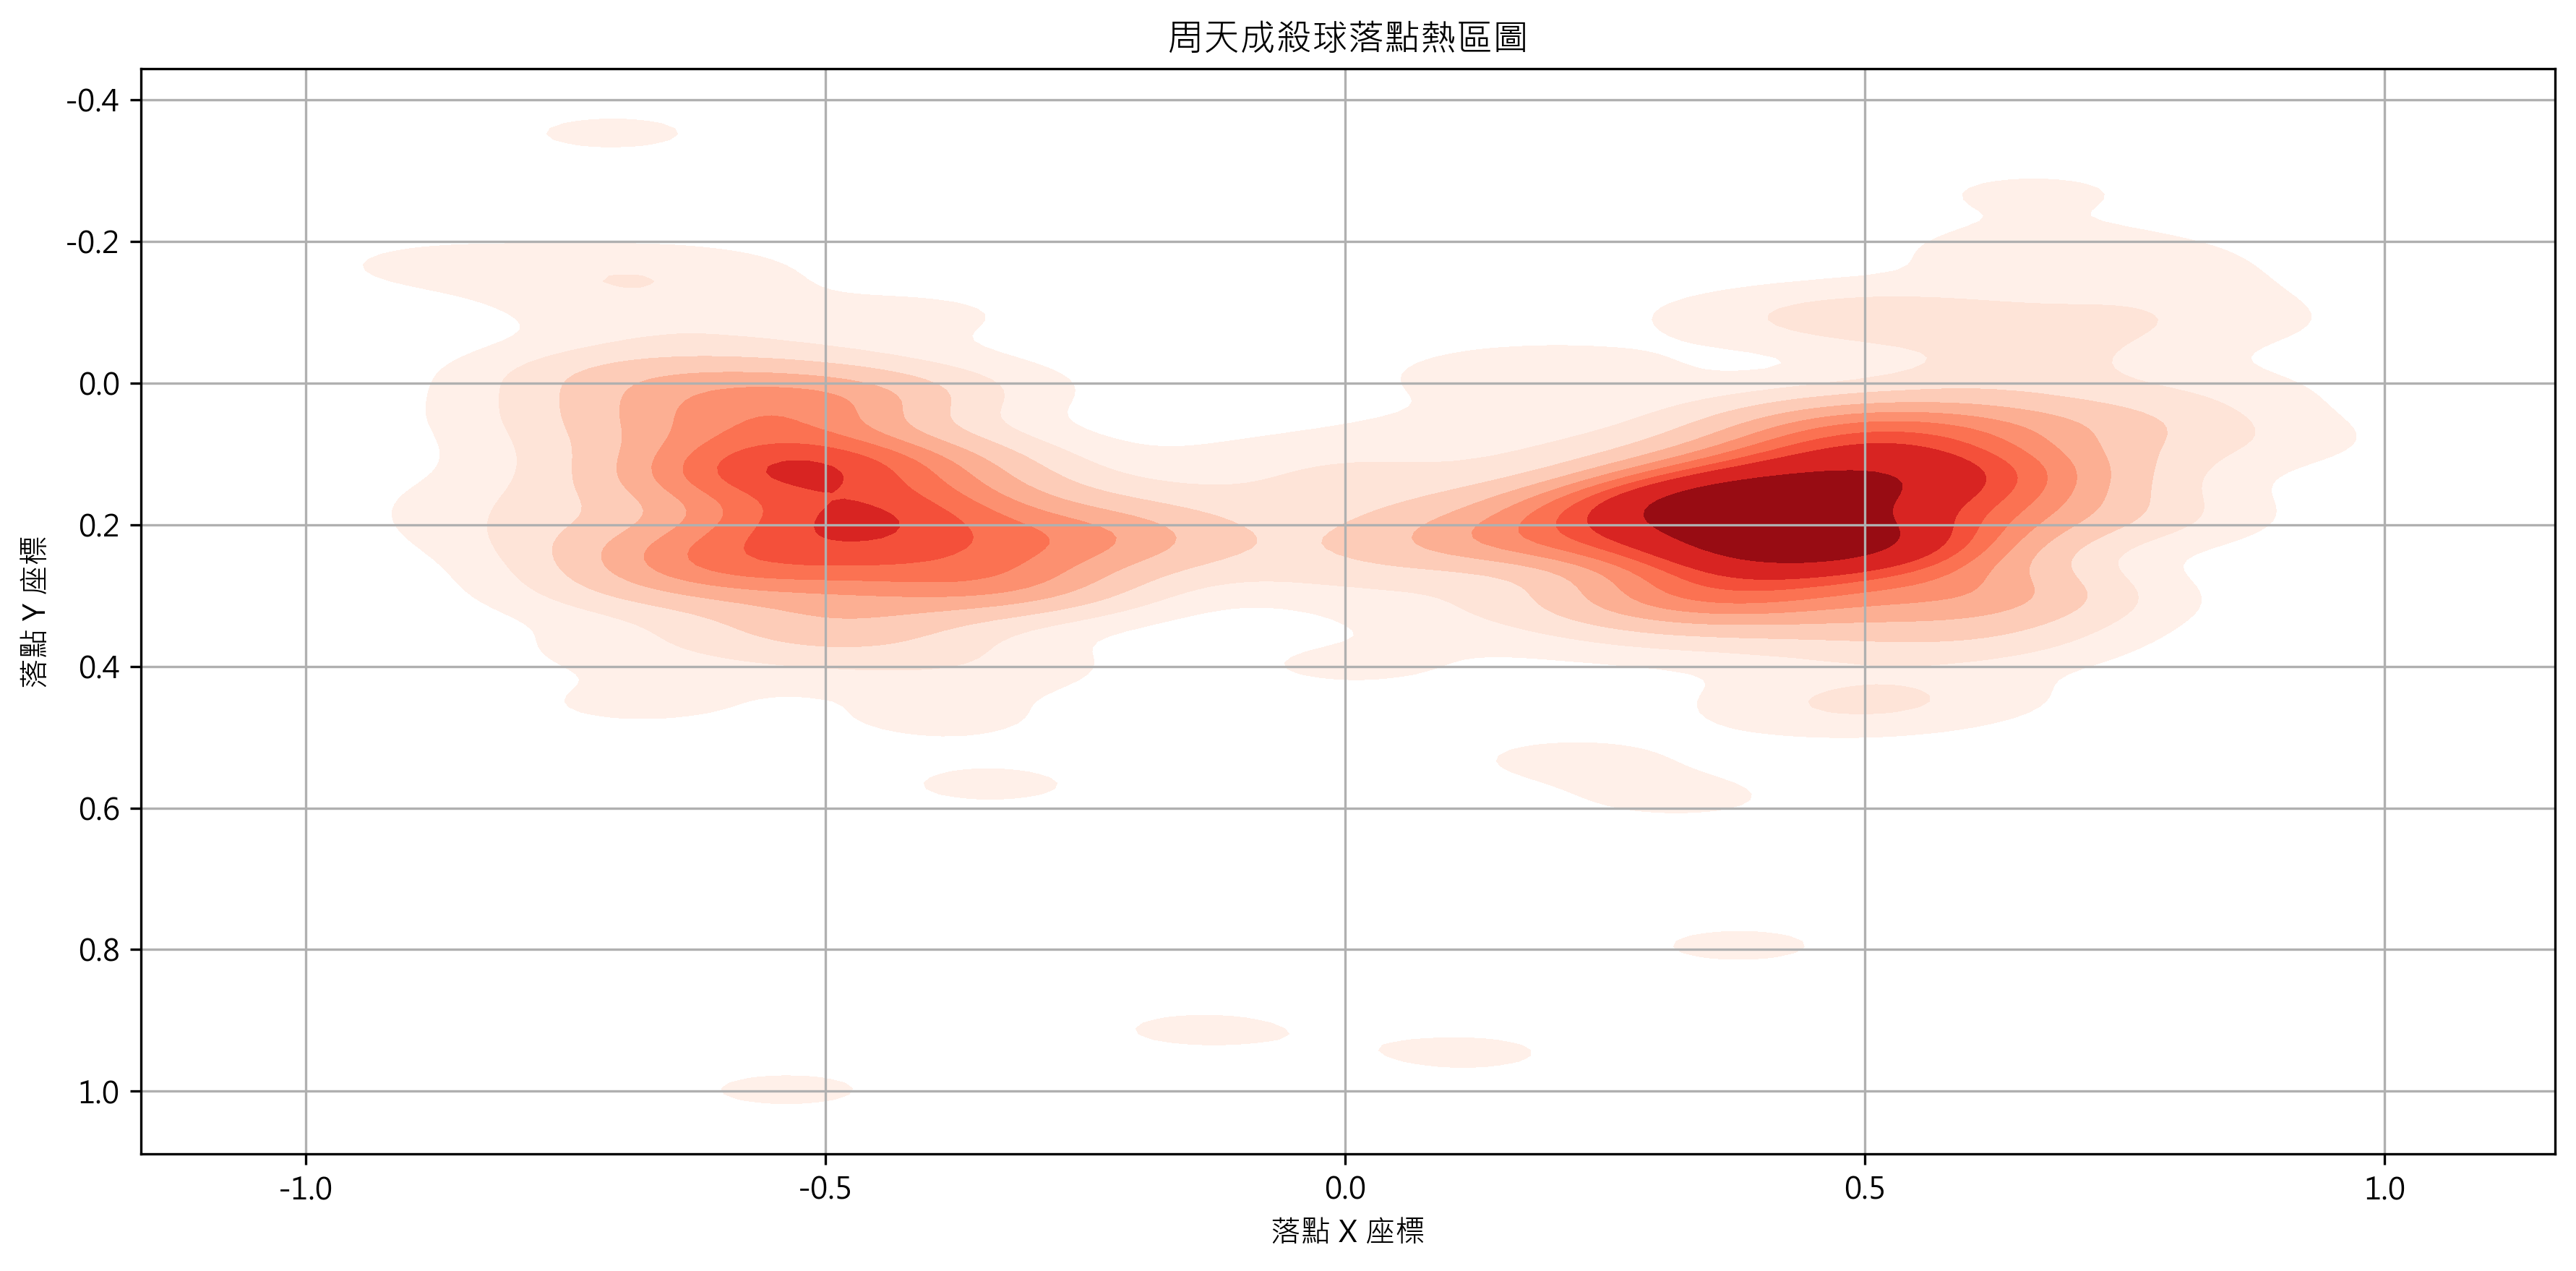

In [ ]:
# 篩選出周天成的殺球
chou_smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# 確認篩選後的數據量是否大於零
if len(chou_smash_df) > 0:
    # 繪製落點熱區圖
    plt.figure(figsize=(12, 6))
    sns.kdeplot(
        data=chou_smash_df, 
        x='landing_x', 
        y='landing_y', 
        cmap='Reds', 
        shade=True, 
        bw_adjust=0.5  # 調整平滑參數
    )
    plt.title('周天成殺球落點熱區圖')
    plt.xlabel('落點 X 座標')
    plt.ylabel('落點 Y 座標')
    plt.gca().invert_yaxis()  # 反轉 Y 軸以符合實際球場的視覺效果
    plt.grid(True)
    plt.tight_layout()
else:
    print("無可用的周天成殺球數據來生成熱區圖")


### 數據洞察
根據數據，我們分析了周天成在所有場次中的殺球落點，並繪製了熱區圖。這張圖表明了他殺球的主要落點區域，這對於制定對抗策略至關重要。

### 熱區分析：
- **落點集中區域**：周天成的殺球主要集中在中場和前場的右側區域，特別是落在區域15和19的次數較多。
- **戰術意義**：這表明他在進攻時傾向於將球打向對手的右側中場和前場，可能是針對對手的反手弱點或逼迫對手移動。

### 圖表參考：
- **落點區域**：使用區域編號來識別落點，從後場到前場依次為1到24。
- **Mapping**：如果圖表中涉及擊球類型，對應的數字代表不同的技術動作。

這些數據提供了周天成殺球的戰術偏好，對於對手來說，預測和防守這些落點將是比賽中的關鍵。建議對手在這些區域加強防守，並利用周天成的偏好來設計反擊策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的殺球，並使用了落點座標（landing_x 和 landing_y）來繪製熱區圖。儘管使用了不同的視覺化方法（kdeplot 而非 histplot），但這屬於可以接受的差異，因為最終輸出目標一致，即展示殺球的落點熱區。




## 題號 4
**問題**: 分析周天成在雙方都達18分以上時的球種分布。
> **使用的資料欄位群組**: `game_structure, shot_type`


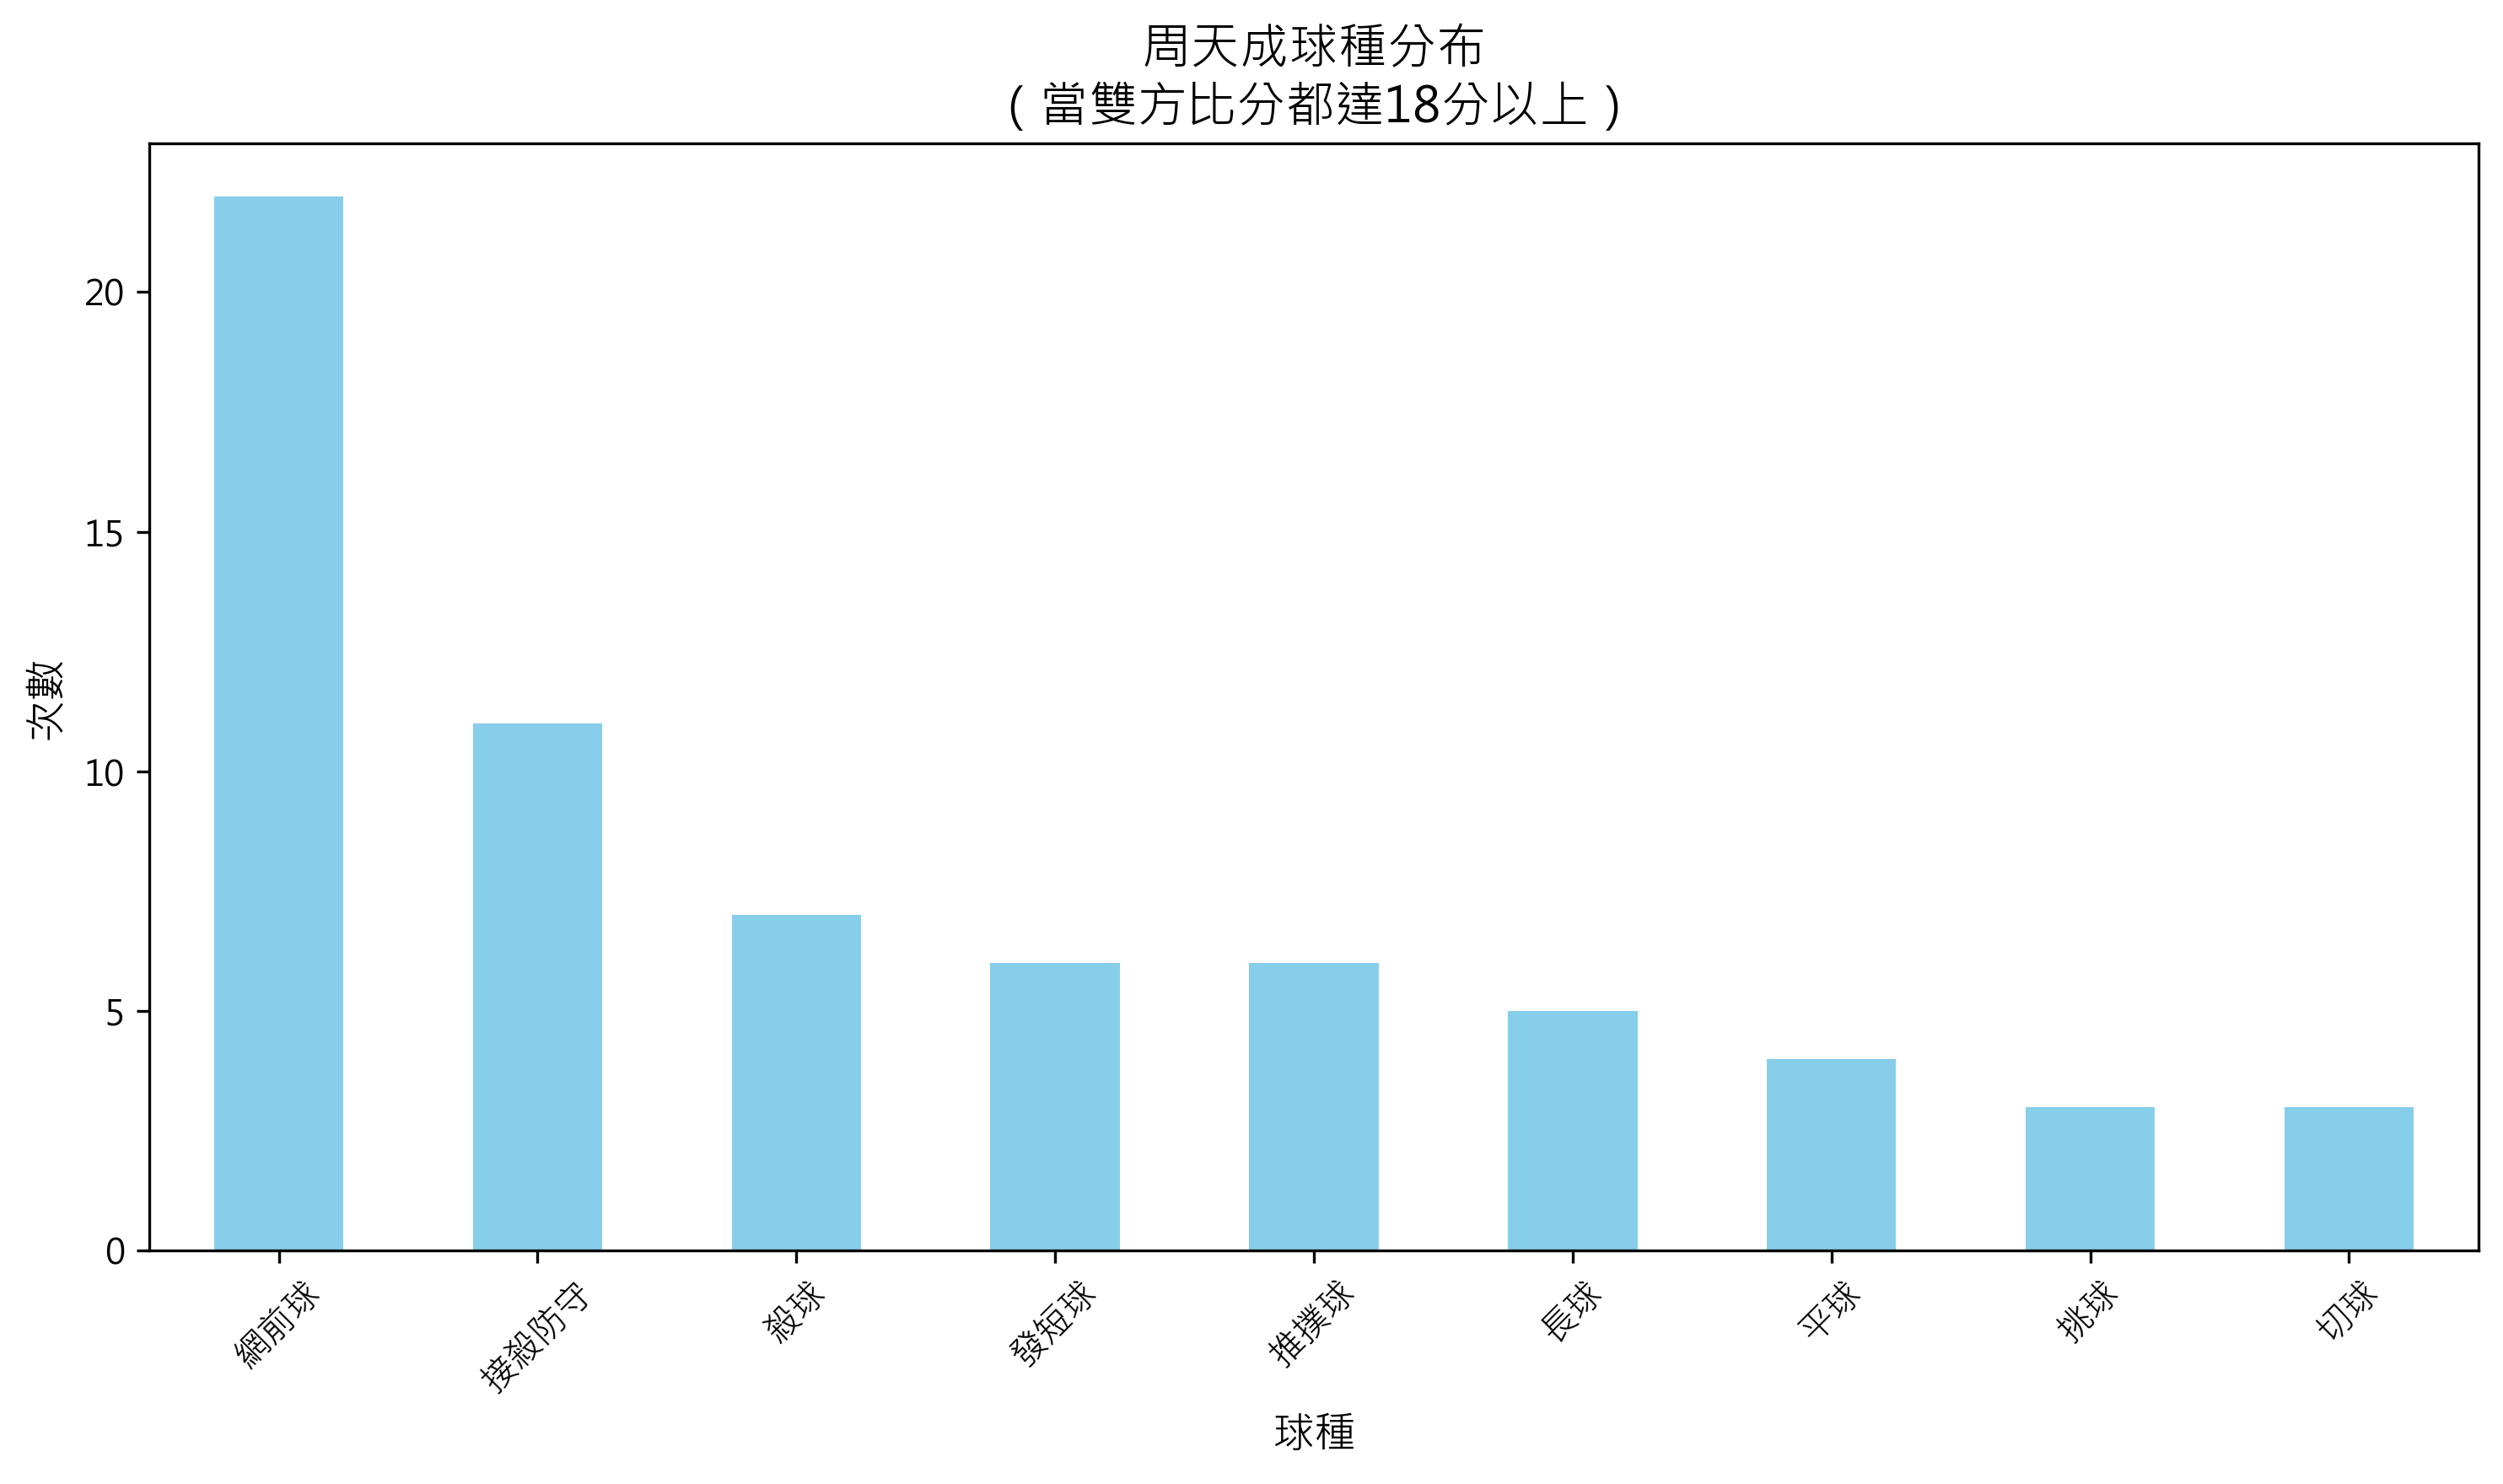

In [ ]:
# Step 1: Filtering the data
filtered_df = df[
    (df['Kento MOMOTA_score'] >= 18) &
    (df['CHOU Tien Chen_score'] >= 18) &
    (df['player'] == 'CHOU Tien Chen')
]

# Check if there's any data to analyze
if len(filtered_df) > 0:
    # Step 2: Calculate the distribution of shot types
    shot_distribution = filtered_df['type'].value_counts()

    # Step 3: Display the results
    print("球種分布（雙方比分都18分以上，周天成的球種分布）：")
    print(shot_distribution)

    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    shot_distribution.plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title('周天成球種分布\n（當雙方比分都達18分以上）', fontsize=14)
    ax.set_xlabel('球種', fontsize=12)
    ax.set_ylabel('次數', fontsize=12)
    ax.set_xticklabels(shot_distribution.index, rotation=45)
    plt.tight_layout()

else:
    print("沒有符合條件的數據進行分析。")


### 數據洞察
當雙方比分都達到18分以上時，周天成在關鍵時刻的球種分布顯示出他偏好使用網前球（22次），這表明他在緊張局勢下傾向於控制網前，可能是為了增加對手的壓力和創造進攻機會。此外，他的接殺防守（11次）和殺球（7次）次數也較高，這表明他在高壓時刻依然保持積極的防守和攻擊姿態。這樣的分布反映了他在關鍵分時期的戰術選擇，強調了他在網前控制和防守反擊上的優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出雙方比分都達到 18 分以上且 player 為 'CHOU Tien Chen' 的資料，並計算這些資料中 'type' 欄位的分布。候選程式碼的分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為正確。




## 題號 5
**問題**: 幫我繪製周天成得分時球的落點熱區圖
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


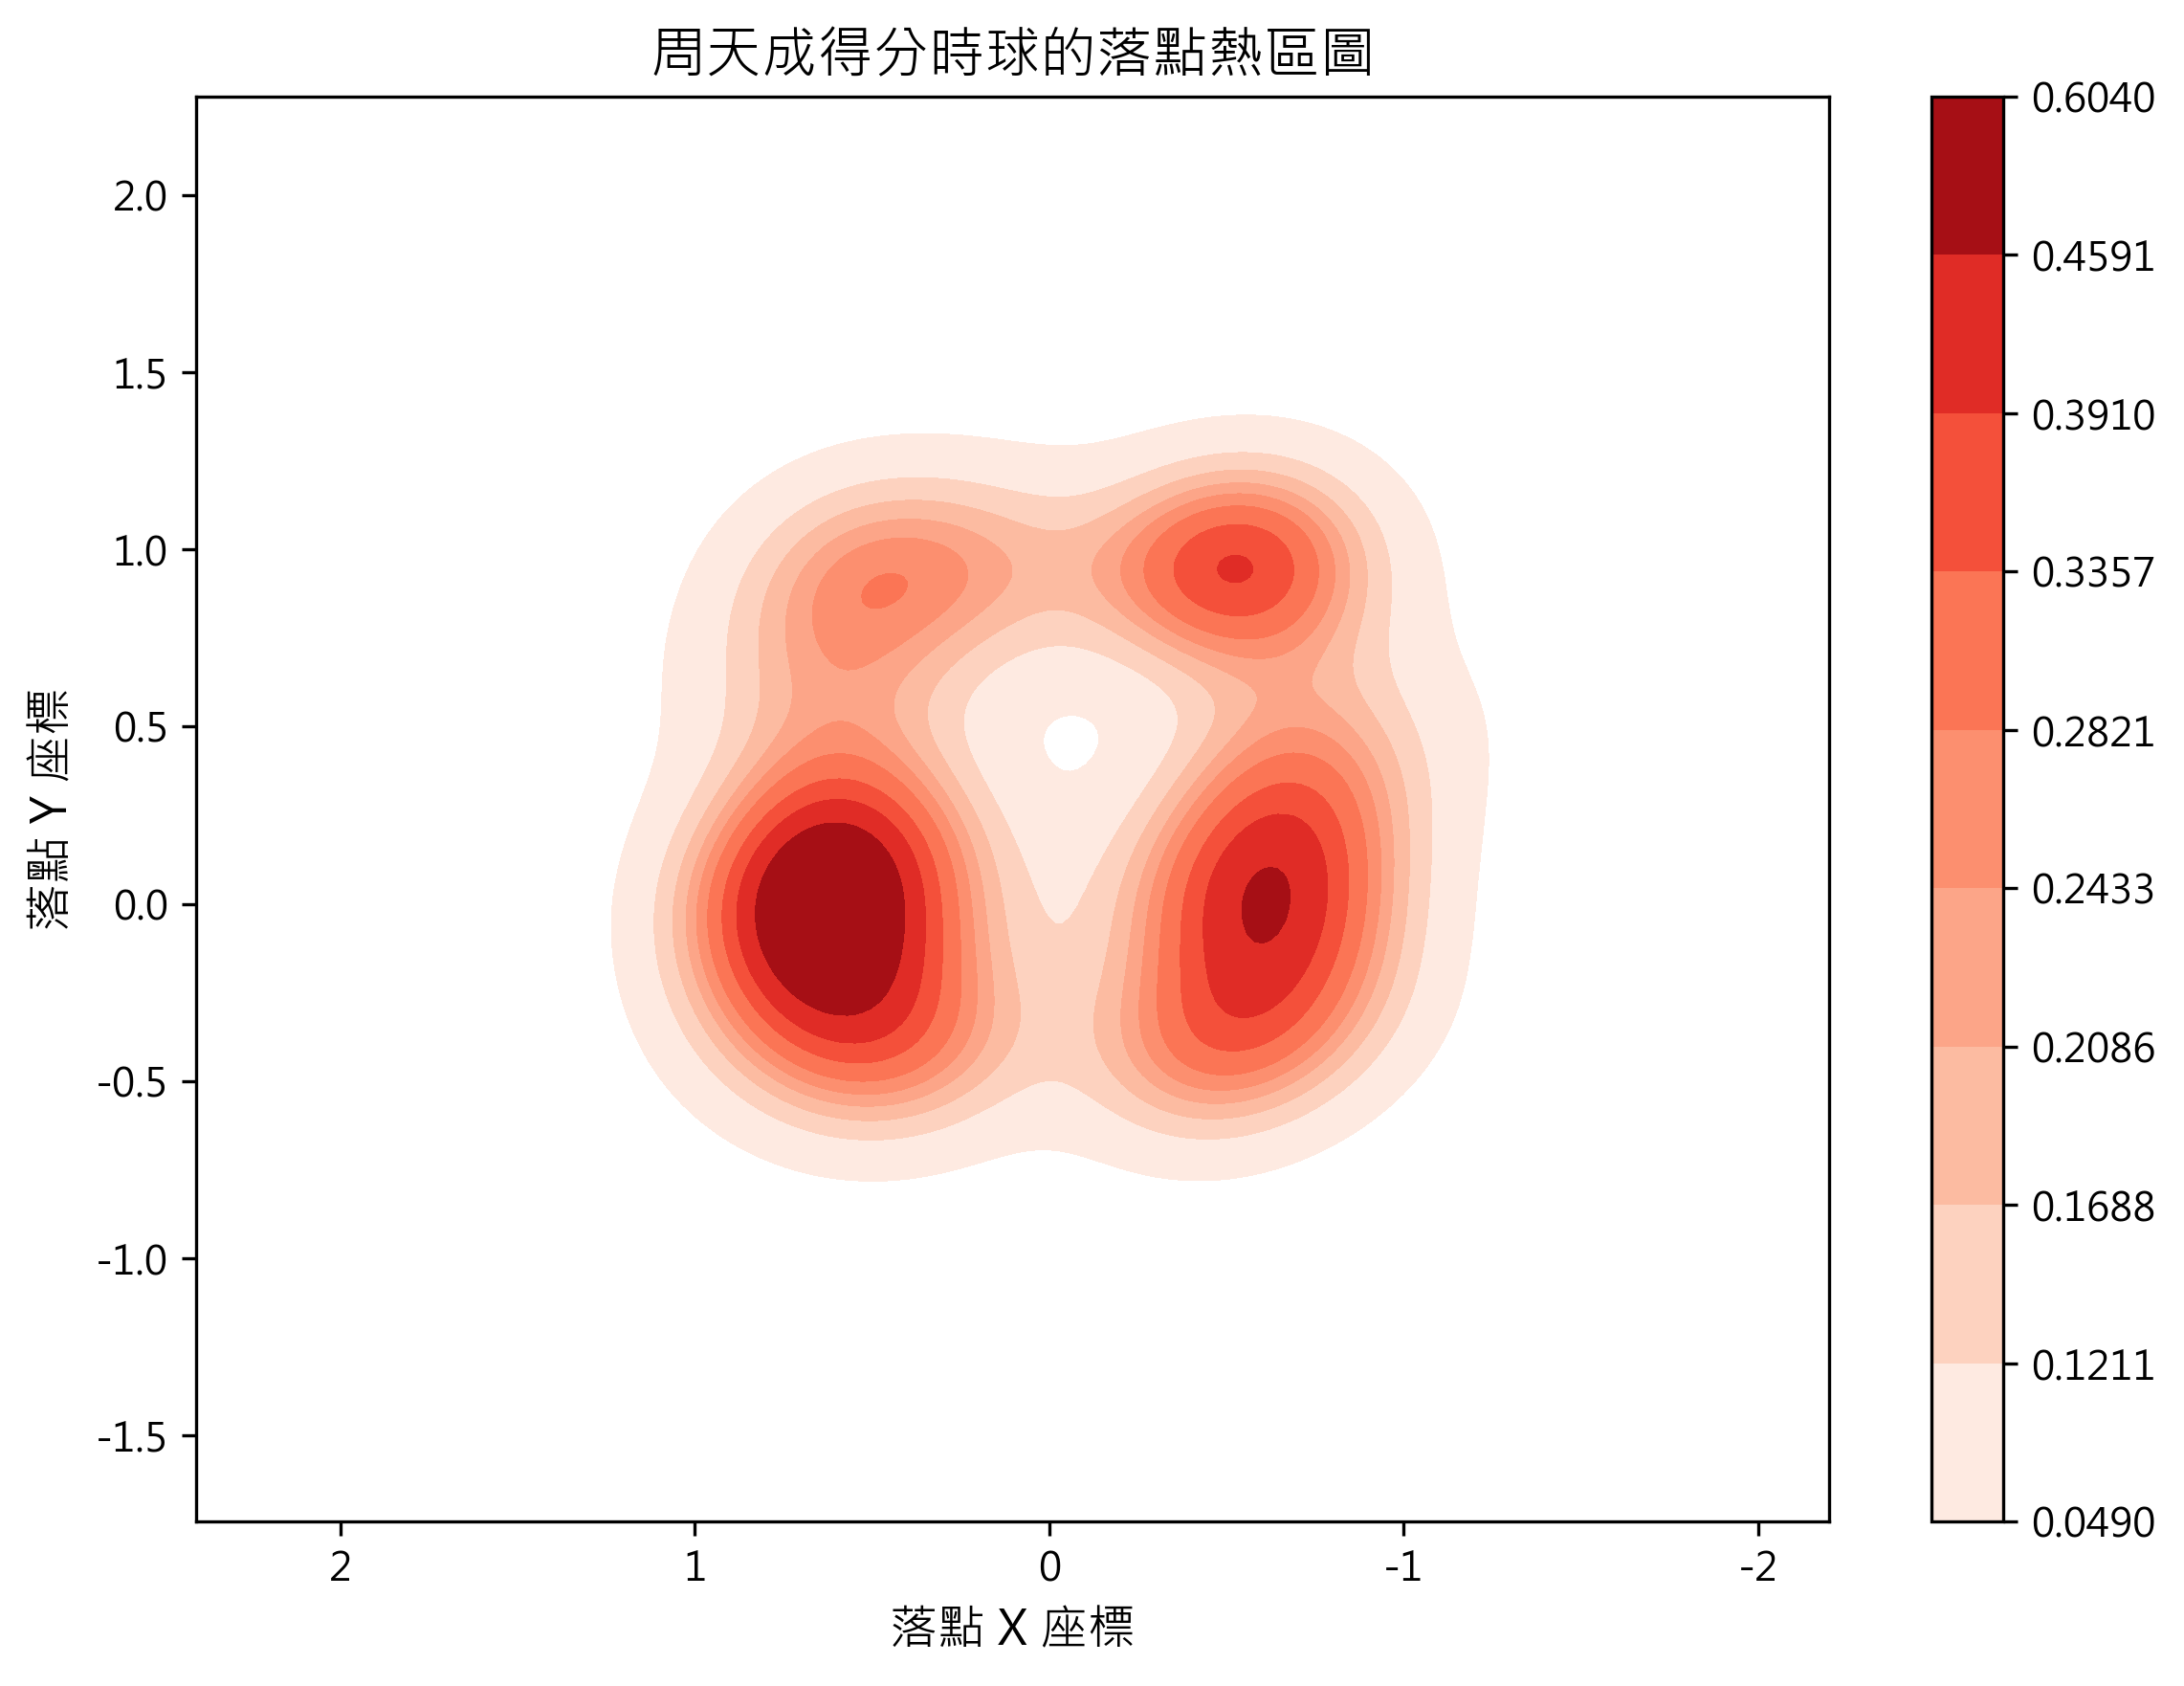

In [ ]:
# 1. 篩選資料：選取周天成得分的情況
chou_scores_df = df[df['getpoint_player'] == 'CHOU Tien Chen']

# 2. 確認資料不為空
if len(chou_scores_df) > 0:
    # 3. 繪製落點熱區圖
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.kdeplot(
        data=chou_scores_df,
        x='landing_x',
        y='landing_y',
        fill=True,
        cmap='Reds',
        cbar=True,
        ax=ax
    )
    
    # 設定圖表標題和軸標籤
    ax.set_title('周天成得分時球的落點熱區圖', fontsize=14)
    ax.set_xlabel('落點 X 座標', fontsize=12)
    ax.set_ylabel('落點 Y 座標', fontsize=12)
    ax.invert_xaxis()  # 讓圖像中的反射符合羽毛球場地圖的視覺化習慣
    ax.set_aspect('equal', 'datalim')
    
    # 調整布局以防止文字重疊
    plt.tight_layout()
    
    # 顯示圖
    plt.show()
else:
    print("沒有周天成得分的資料可供繪圖。")


### 數據洞察
根據我們的數據分析，周天成在得分時的球落點主要集中在中場和前場區域，特別是落在中場的14和15區，以及前場的18和19區。這些區域的高頻得分顯示了周天成在中前場的攻擊威脅性。

從戰術角度來看，這意味著周天成在中前場的控球和進攻能力是他的得分關鍵。他能夠有效地在這些區域施加壓力，迫使對手犯錯或直接得分。這也可能反映了他在比賽中利用快速突襲和變速進攻來打亂對手防守節奏的策略。

同時，這些數據也提醒我們，若要對抗周天成，對手需要加強中前場的防守，特別是在14、15、18、19這些高頻得分區域。這樣可以有效減少周天成的得分機會，並可能迫使他改變進攻策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選出周天成得分的情況，並使用 `landing_x` 和 `landing_y` 來繪製得分時球的落點熱區圖。分析對象、欄位語意、篩選條件和最終輸出目標都與 Reference Code 2 一致，且能產出有效結果。




## 題號 6
**問題**: 在第一場次中，每回合用的拍數，繪圖
> **使用的資料欄位群組**: `game_structure`


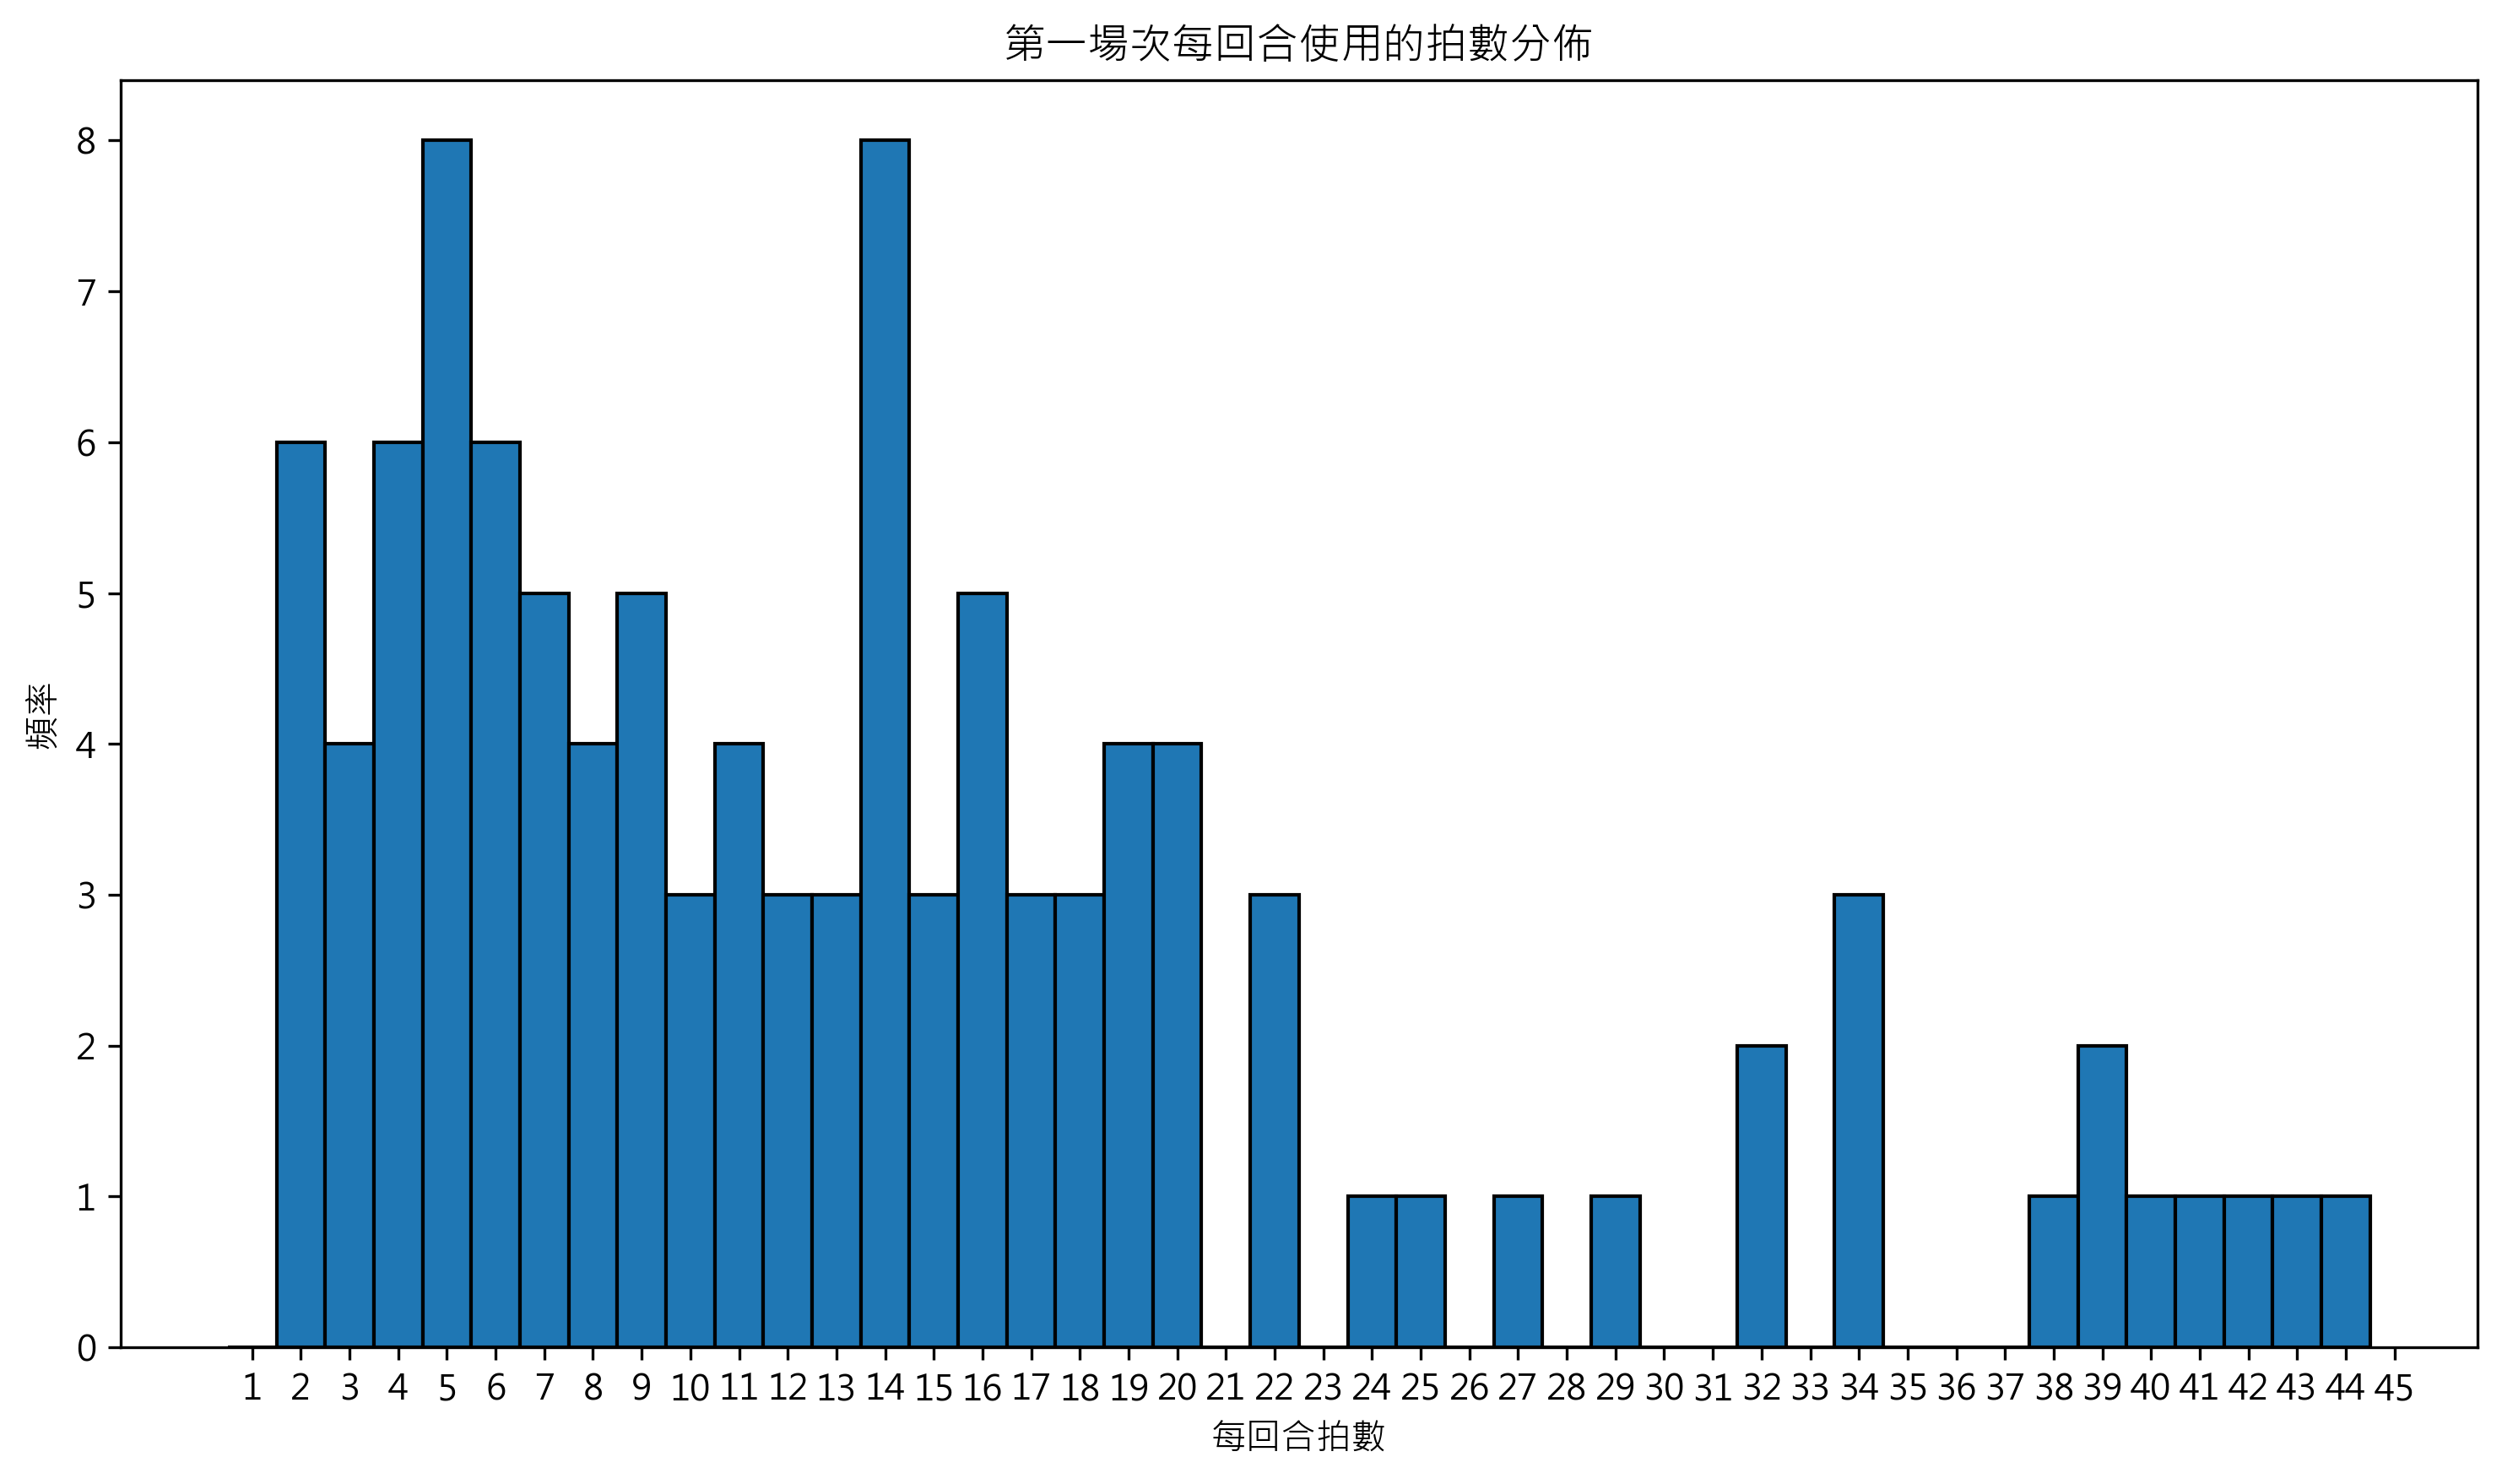

In [ ]:
# Step 1: 過濾出 match_id 為 1 的數據
filtered_df = df[df['match_id'] == 1]

# Step 2: 計算每回合的最大 `ball_round`（代表每回合的拍數）
rally_shots_counts = filtered_df.groupby(['set', 'rally'])['ball_round'].max()

# Step 3: 確認過濾後的數據量不為空
if len(rally_shots_counts) > 0:
    # Step 4: 繪製直方圖
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(rally_shots_counts, bins=range(1, max(rally_shots_counts) + 2), edgecolor='black', align='left')
    ax.set_title('第一場次每回合使用的拍數分佈')
    ax.set_xlabel('每回合拍數')
    ax.set_ylabel('頻率')
    plt.xticks(range(1, max(rally_shots_counts) + 2))
    plt.tight_layout()

    # Print key statistics
    print("總共的回合數：", len(rally_shots_counts))
    print("每回合拍數的平均值：", rally_shots_counts.mean())
    print("每回合拍數的最大值：", rally_shots_counts.max())
    print("每回合拍數的最小值：", rally_shots_counts.min())

else:
    print("第一場次的數據不存在或無法分析。")


### 數據洞察
在分析第一場次的每回合拍數時，我們觀察到以下幾個關鍵數據：

1. **總回合數**：107回合，這是一場相對較長的比賽，顯示雙方選手可能都在進行激烈的拉鋸戰。
   
2. **平均每回合拍數**：14.45拍，這表明選手們在每回合中都進行了多次來回，顯示出耐心和戰術的運用。

3. **最大拍數**：44拍，這是一個非常高的數字，意味著在某些回合中，選手們可能進行了持久的防守與進攻轉換。

4. **最小拍數**：2拍，這可能是由於發球直接得分或對手失誤。

這些數據顯示出選手們在比賽中展現了高水平的技術和戰術多樣性，特別是在長回合中，選手需要具備良好的體能和心理素質來應對高強度的對抗。這也提醒我們在訓練中，不僅要強調技術的精進，還需注重耐力和戰術意識的培養，以便在比賽中更好地應對各種情況。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地過濾出 match_id 為 1 的數據，並計算每回合的最大 ball_round 作為拍數，然後繪製直方圖來展示每回合的拍數分佈。這與 Reference Code 2 的分析對象、欄位語意、篩選條件、分組層級和統計口徑一致，並且能夠產出有效結果。




## 題號 7
**問題**: 繪製周天成殺球時的站點熱區圖
> **使用的資料欄位群組**: `game_structure, shot_type, player_location`


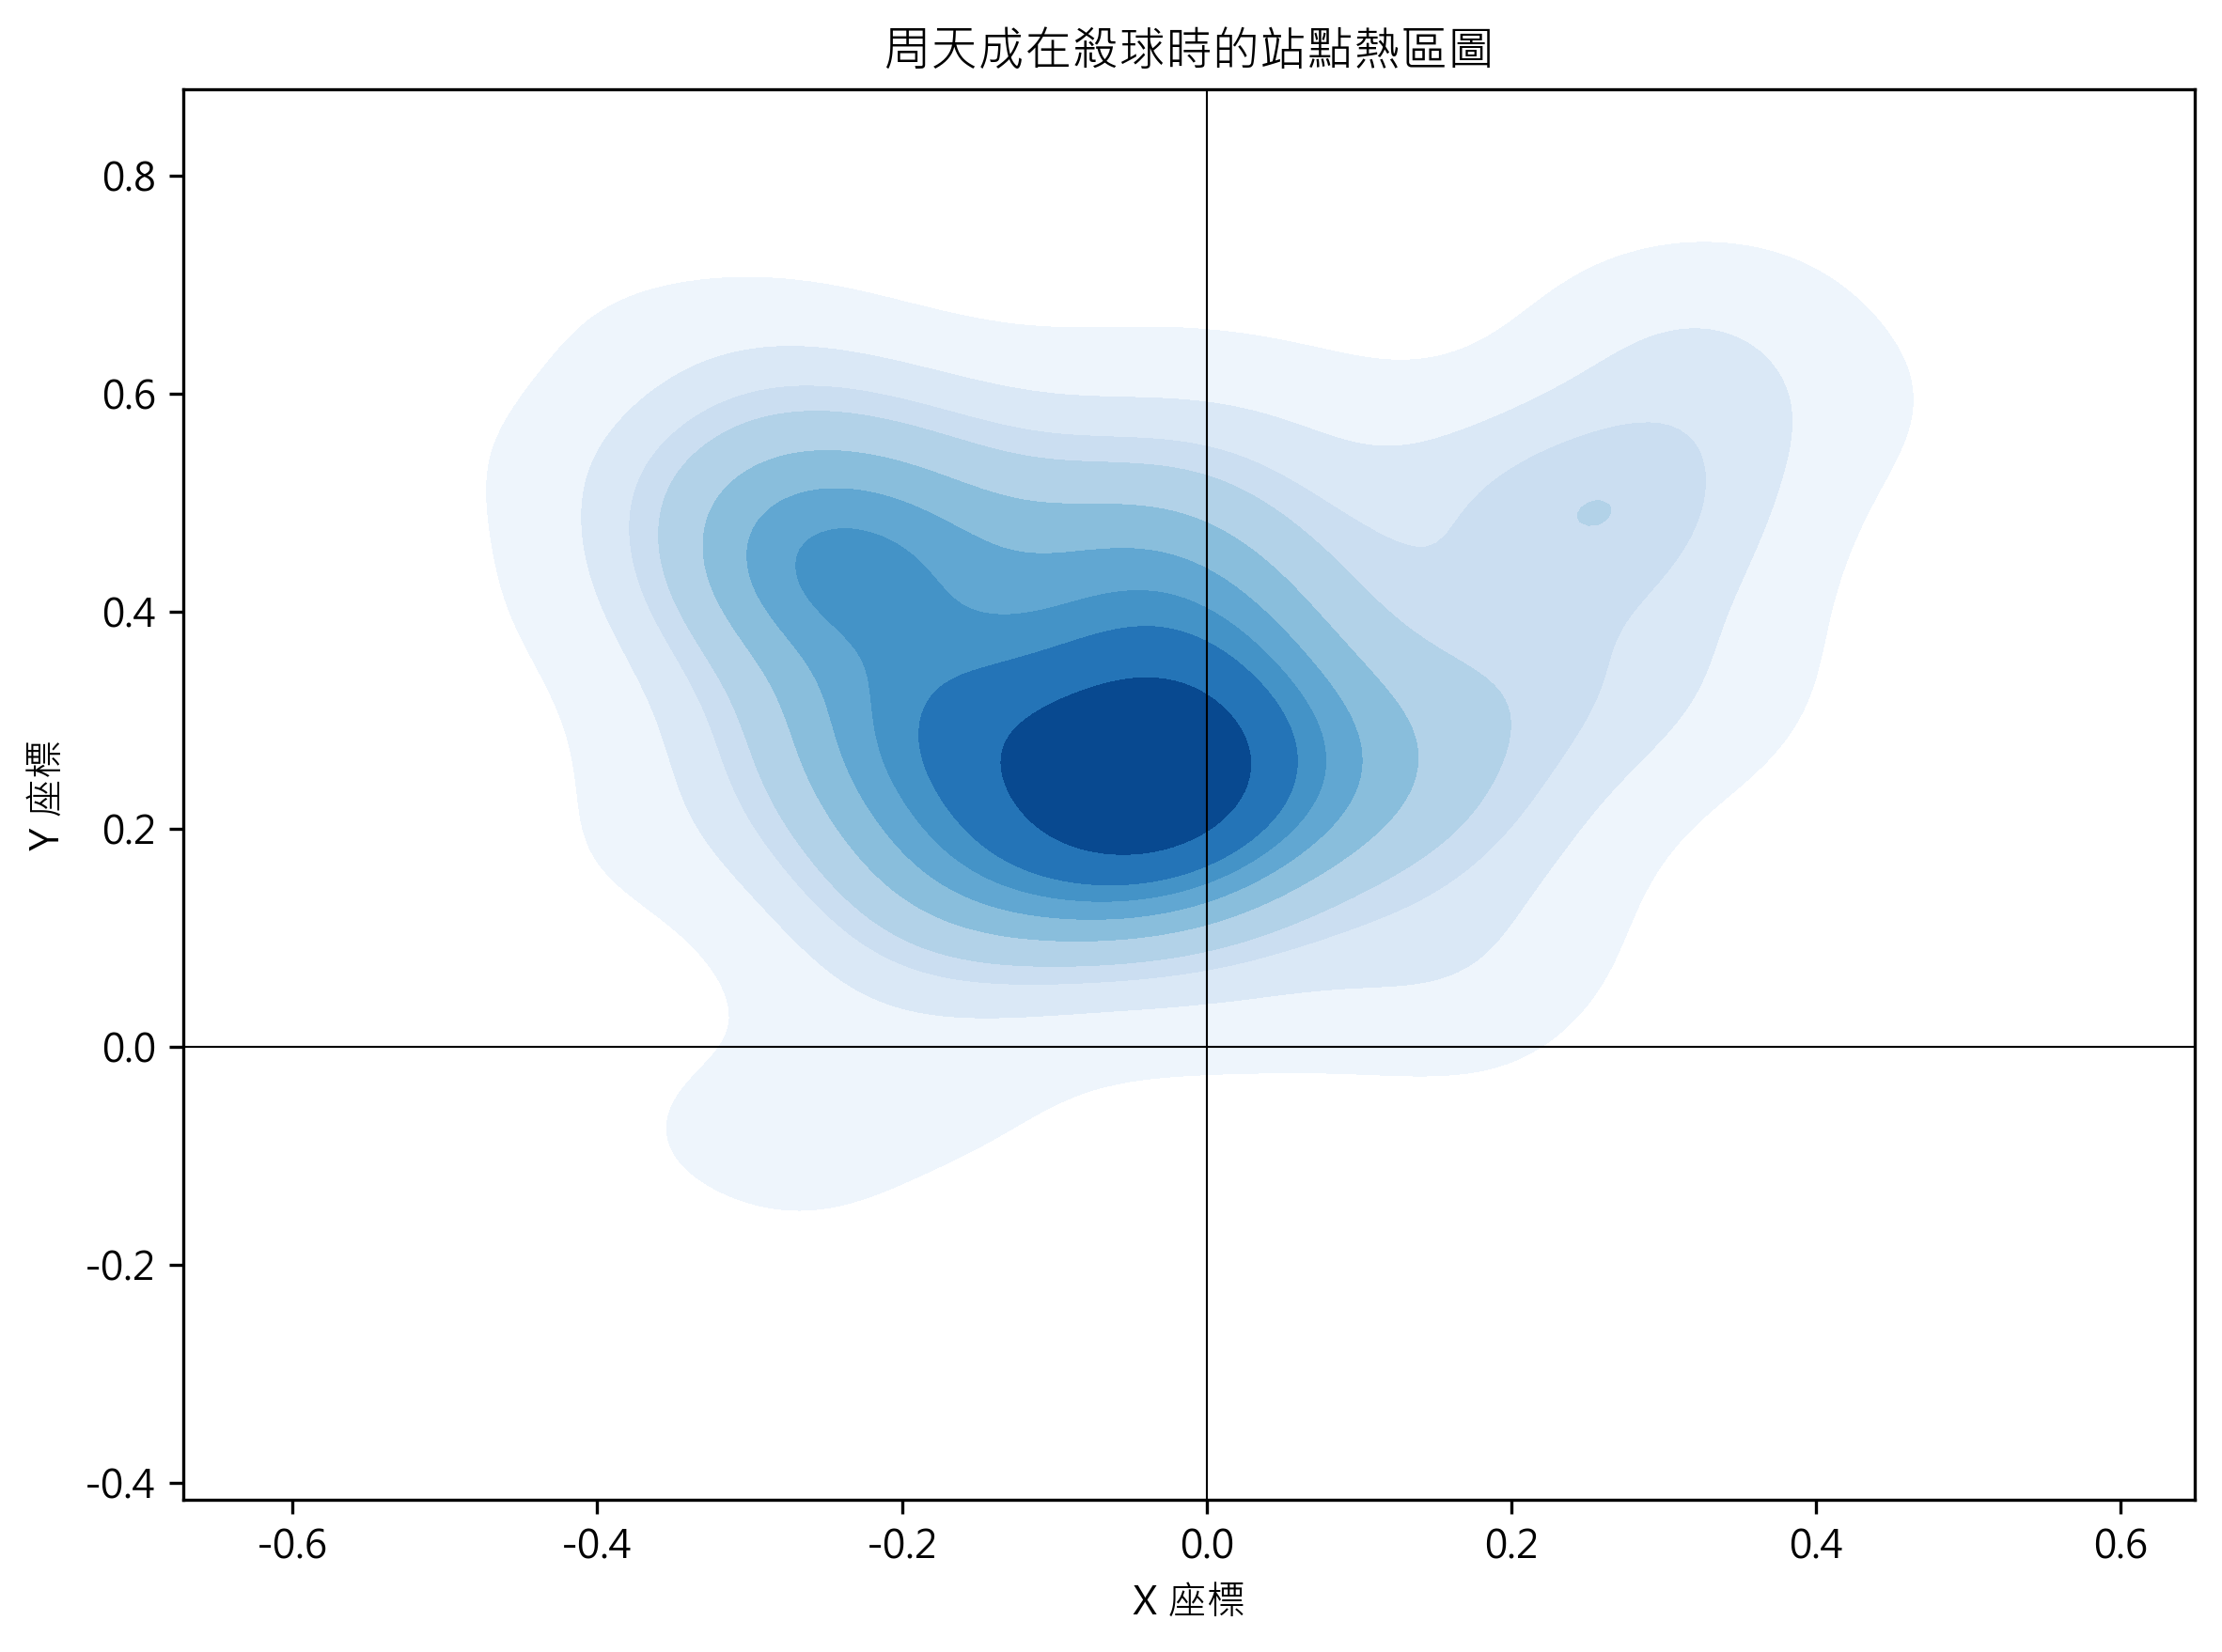

In [ ]:
# Step 1: Filter the data
chou_tien_chen_smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# Step 2: Check the data count
if len(chou_tien_chen_smash_df) > 0:
    print(f"Filtered data count: {len(chou_tien_chen_smash_df)}")
    
    # Step 3: Create the heatmap using player_location_x and player_location_y
    plt.figure(figsize=(8, 6))
    sns.kdeplot(
        x=chou_tien_chen_smash_df['player_location_x'], 
        y=chou_tien_chen_smash_df['player_location_y'], 
        cmap="Blues", fill=True
    )
    plt.title("周天成在殺球時的站點熱區圖")
    plt.xlabel("X 座標")
    plt.ylabel("Y 座標")
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
else:
    print("No data available for CHOU Tien Chen's smash positions")


### 數據洞察
周天成的殺球站點熱區圖顯示，他在場上的殺球位置分佈相對均勻，這意味著他能夠靈活地在不同區域發動進攻。這種多樣性使得對手難以預測他的進攻路徑，增加了防守的難度。

在這299次殺球中，周天成的站點選擇顯示出他對場地的全面掌控。這樣的數據表明他能夠根據對手的站位和比賽情況，靈活調整自己的進攻策略。

Mapping和區域數據有助於進一步分析他的戰術選擇。例如，若數據中包含"player_type"或"opponent_type"，可以了解他在不同類型球的應對策略。而"area"數據則能幫助識別他偏好攻擊的場地區域，從而制定針對性的訓練計劃。

總結來說，周天成的殺球策略顯示出他在場上的靈活性和戰術多樣性，這是他在高水平比賽中取得成功的關鍵因素之一。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成的殺球數據，並使用 player_location_x 和 player_location_y 來繪製站點熱區圖。候選程式碼使用了 sns.kdeplot 來繪製熱區圖，而 Reference Code 1 使用了 sns.histplot，這是視覺化形式的不同，但不影響核心邏輯。候選程式碼正確地檢查了數據筆數，並在有數據時繪製圖表，符合題目要求。




## 題號 8
**問題**: 當周天成在「後場」擊球時，他最常使用哪三種球種?
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


In [ ]:
# 確保資料集非空
if len(df) > 0:
    # 過濾出周天成在後場的擊球數據
    back_court_areas = [1, 2, 3, 4]
    chou_tien_chen_back_court = df[(df['player'] == 'CHOU Tien Chen') & (df['hit_area'].isin(back_court_areas))]
    
    # 計算不同球種的頻次
    shot_type_counts = chou_tien_chen_back_court['type'].value_counts()
    
    # 取得最常使用的三種球種
    top_three_shot_types = shot_type_counts.head(3)
    print("周天成在後場最常使用的三種球種及其次數：")
    print(top_three_shot_types)
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在後場擊球時最常使用的三種球種分別是長球（227次）、殺球（176次）和切球（175次）。這表明他在後場時，偏好使用長球來控制場上的節奏，並且經常使用殺球和切球來增加進攻威脅。這樣的球種選擇顯示他在後場具備良好的進攻與防守平衡能力，能夠有效地施壓對手並維持比賽的主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都分析了周天成在後場的擊球，使用了相同的欄位 'hit_area' 來篩選後場擊球，並計算了不同球種的頻次。最終都輸出了周天成在後場最常使用的三種球種及其次數。候選程式碼的分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為 true。




## 題號 9 (*)
**問題**: 分析周天成站在前中後場，分別的得分與失分數
> **使用的資料欄位群組**: `game_structure, player_location, scoring_reason`


In [ ]:
# 定義區域範疇
front_court_areas = [17, 18, 19, 20, 21, 22, 23, 24]
mid_court_areas = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
back_court_areas = [1, 2, 3, 4]

# 篩選周天成的資料
chou_data = df[df['player'] == 'CHOU Tien Chen']

# 定義函數以取得各區域的得分與失分
def calculate_points(data, areas):
    # 得分：周天成在所選位置擊球後得分
    win_points = data[(data['player_location_area'].isin(areas)) & 
                      (data['getpoint_player'] == 'CHOU Tien Chen')].shape[0]
    
    # 失分：周天成在所選位置擊球後失分
    lose_points = data[(data['player_location_area'].isin(areas)) & 
                       (data['getpoint_player'] == 'Kento MOMOTA')].shape[0]
    
    return win_points, lose_points

# 計算各個區域的得分與失分
front_court_win, front_court_lose = calculate_points(chou_data, front_court_areas)
mid_court_win, mid_court_lose = calculate_points(chou_data, mid_court_areas)
back_court_win, back_court_lose = calculate_points(chou_data, back_court_areas)

# 打印結果
print("周天成在各區域的得分與失分:")
print(f"前場得分: {front_court_win}, 前場失分: {front_court_lose}")
print(f"中場得分: {mid_court_win}, 中場失分: {mid_court_lose}")
print(f"後場得分: {back_court_win}, 後場失分: {back_court_lose}")


### 數據洞察
從數據來看，周天成在不同場區的表現有明顯差異：

1. **前場表現**：得分9次，失分13次。這顯示他在前場的進攻效率略低於防守，可能需要加強網前控制與精準度。

2. **中場表現**：得分75次，失分131次。中場是他失分最多的區域，顯示出對手在這裡能夠有效地反制他的攻擊。這可能是因為他在中場的擊球選擇或站位需要調整。

3. **後場表現**：得分1次，失分16次。後場的數據顯示他在這裡的進攻與防守都相對薄弱，可能需要加強後場的擊球力量與準確性。

總結來說，周天成需要在中場和後場加強防守與攻擊策略，尤其是中場的防守反擊能力。此外，前場的進攻效率也有改善空間。這些數據提供了一個清晰的方向，讓我們可以針對性地調整訓練計劃。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 是在每個 rally 結束時，根據周天成的站位區域來判斷得分或失分，並且使用 getpoint_player 來確定得分者。而候選程式碼直接在每一拍的資料上篩選周天成的擊球位置，然後判斷得分或失分，這樣的做法可能會混入非回合結束的拍數，導致統計口徑錯誤。此外，候選程式碼沒有考慮到 opponent 的站位區域，這與 Reference Code 1 的分析對象和欄位語意不一致。




## 題號 10
**問題**: 當周天成站在前場時，他最主要的得分球種?
> **使用的資料欄位群組**: `game_structure, shot_type, player_location, scoring_reason`


In [ ]:
# Step 1: 確認資料非空
if len(df) > 0:
    
    # Step 2: 辨別前場位置 (Zone IDs: [17, 18, 19, 20, 21, 22, 23, 24])
    front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]

    # Step 3: 過濾周天成在前場的資料
    chou_front_court_df = df[(df['player'] == 'CHOU Tien Chen') & 
                             (df['player_location_area'].isin(front_court_zones))]

    # Step 4: 確認得分條件
    chou_active_win_df = chou_front_court_df[chou_front_court_df['player'] == chou_front_court_df['getpoint_player']]

    # Step 5: 統計球種得分
    if len(chou_active_win_df) > 0:
        most_common_type = chou_active_win_df['type'].value_counts().idxmax()

        # Step 6: 輸出結果
        print(f"當周天成站在前場時，他最主要的得分球種是: {most_common_type}")
    else:
        print("周天成在前場沒有主動得分的記錄。")
else:
    print("資料框是空的，無法進行分析。")


### 數據洞察
根據數據分析，當周天成站在前場區域（區域編號17至24）時，他最主要的得分球種是殺球。這意味著周天成在前場時，具備強大的進攻能力，特別是在利用殺球這一進攻手段來獲得分數。他的殺球不僅速度快，而且角度刁鑽，對手往往難以防守。

這樣的數據顯示，周天成在比賽中應該更多地尋求前場的機會，並利用殺球來施壓對手。這也提醒我們，在訓練中應該進一步強化他的殺球技術，尤其是在前場的準確度和變化上，以保持他的得分優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都檢查了資料集是否為空，過濾了周天成在前場位置且是得分者的資料，並計算了得分球種的出現次數。最終，候選程式碼正確地找出了周天成在前場最主要的得分球種，並輸出了結果。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致。




## 題號 11
**問題**: 計算周天成站在前場擊球時的落點分布。
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


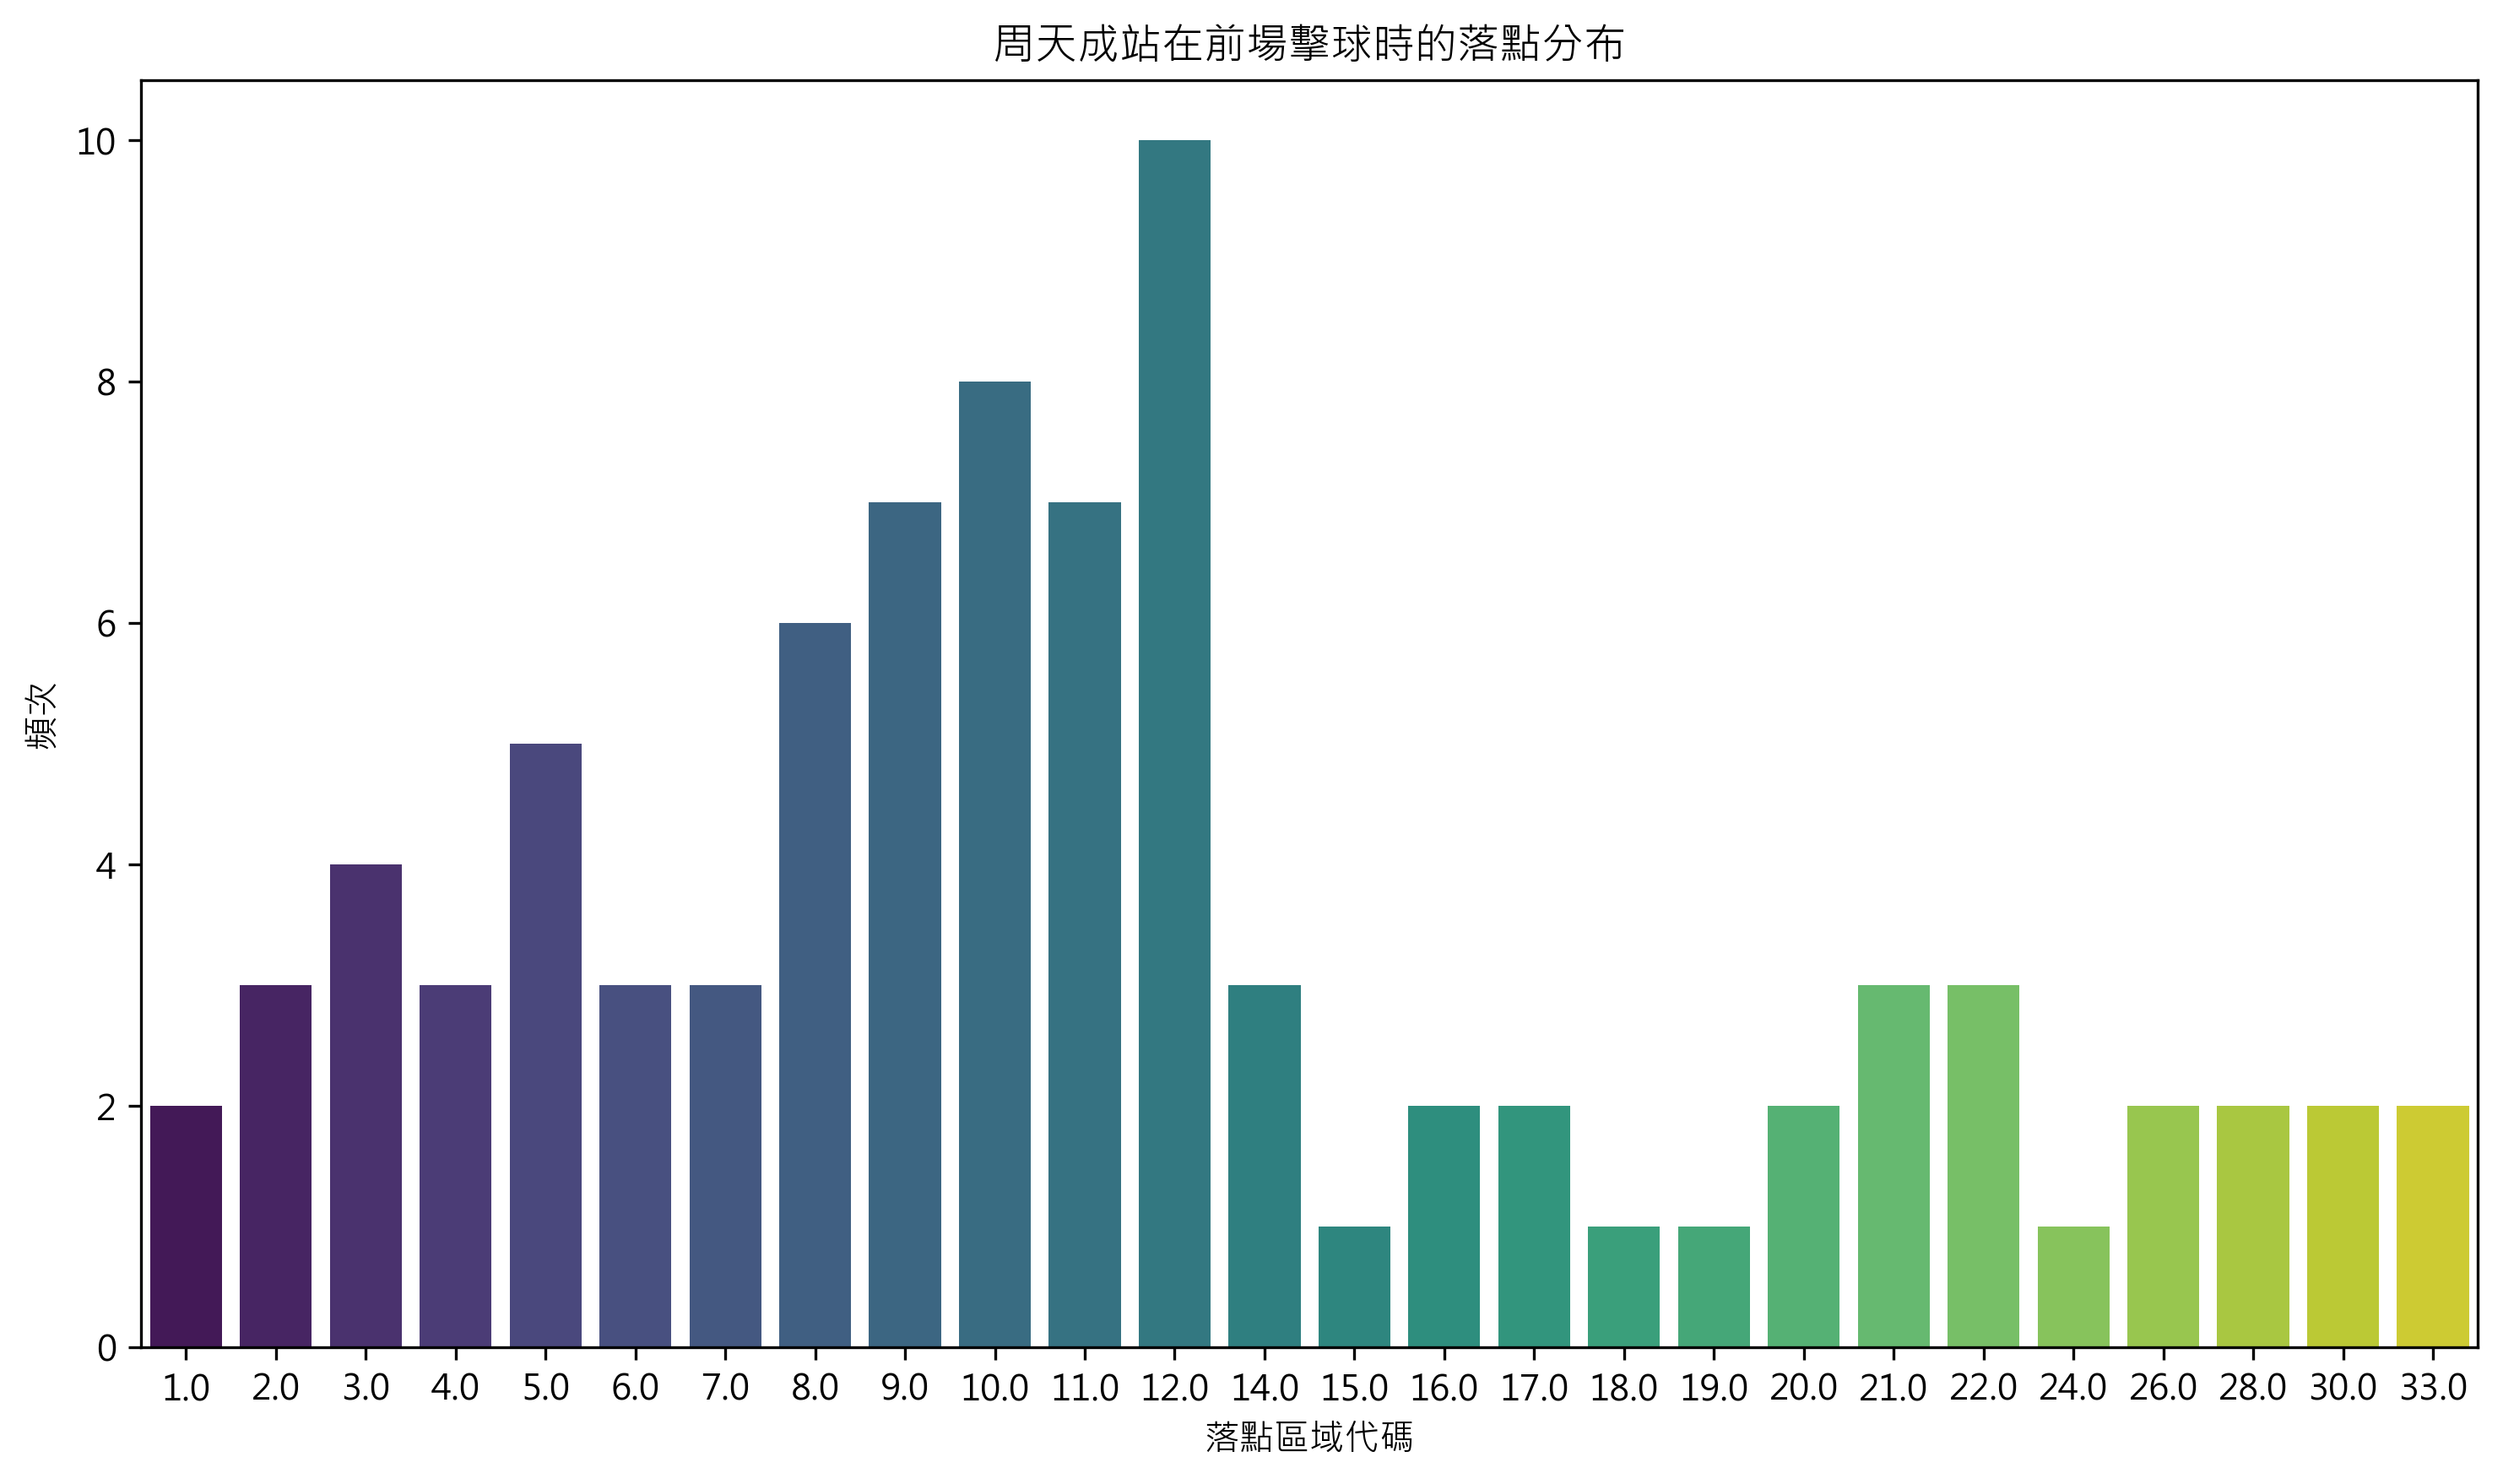

In [ ]:
# 確認數據集的長度是否大於0
if len(df) > 0:
    # 定義前場區域
    front_court_areas = [17, 18, 19, 20, 21, 22, 23, 24]

    # 篩選出周天成站在前場擊球的數據
    filtered_df = df[(df['player'] == 'CHOU Tien Chen') & (df['player_location_area'].isin(front_court_areas))]

    # 檢查篩選後的數據
    if len(filtered_df) > 0:
        # 計算落點區域的分布
        landing_distribution = filtered_df['landing_area'].value_counts().sort_index()

        # 打印出每個落點區域的頻數
        print("周天成站在前場擊球時的落點分布:")
        print(landing_distribution)

        # 視覺化落點分布
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x=landing_distribution.index, y=landing_distribution.values, ax=ax, palette='viridis')
        ax.set_title("周天成站在前場擊球時的落點分布")
        ax.set_xlabel("落點區域代碼")
        ax.set_ylabel("頻次")
        plt.tight_layout()
        # Not displaying plt.show() but returning figure as 'fig'
    else:
        print("沒有找到周天成站在前場擊球的數據。")
else:
    print("資料集中沒有足夠的數據。")


### 數據洞察
從數據中可以看出，周天成在前場擊球時的落點分布較為集中在中間和後場區域，尤其是第12區域有最多的落點（10次），其次是第10和11區域（各8次和7次）。這表明他在前場擊球後，較常選擇將球打向中場後區，可能是為了增加對手的移動距離，並創造進攻機會。

值得注意的是，前場的21和22區域也有一定的落點（各3次），這顯示他偶爾會選擇將球放在前場，可能是為了製造假動作或迫使對手前後移動，增加對手的防守壓力。

這樣的落點策略可以有效地破壞對手的節奏，讓周天成在比賽中佔據主動地位。建議在訓練中進一步強化這些落點的準確性和變化，以提高比賽中的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出周天成站在前場擊球的數據，並計算落點區域的分布。候選程式碼使用了 `value_counts().sort_index()` 來計算落點區域的頻數，這與 Reference Code 1 的做法一致。視覺化部分的差異不影響最終結果的正確性，因此判定為 true。




## 題號 12
**問題**: 分析周天成站在前中後場擊球時，自己分別的移動距離
> **使用的資料欄位群組**: `game_structure, player_location, player_movement`


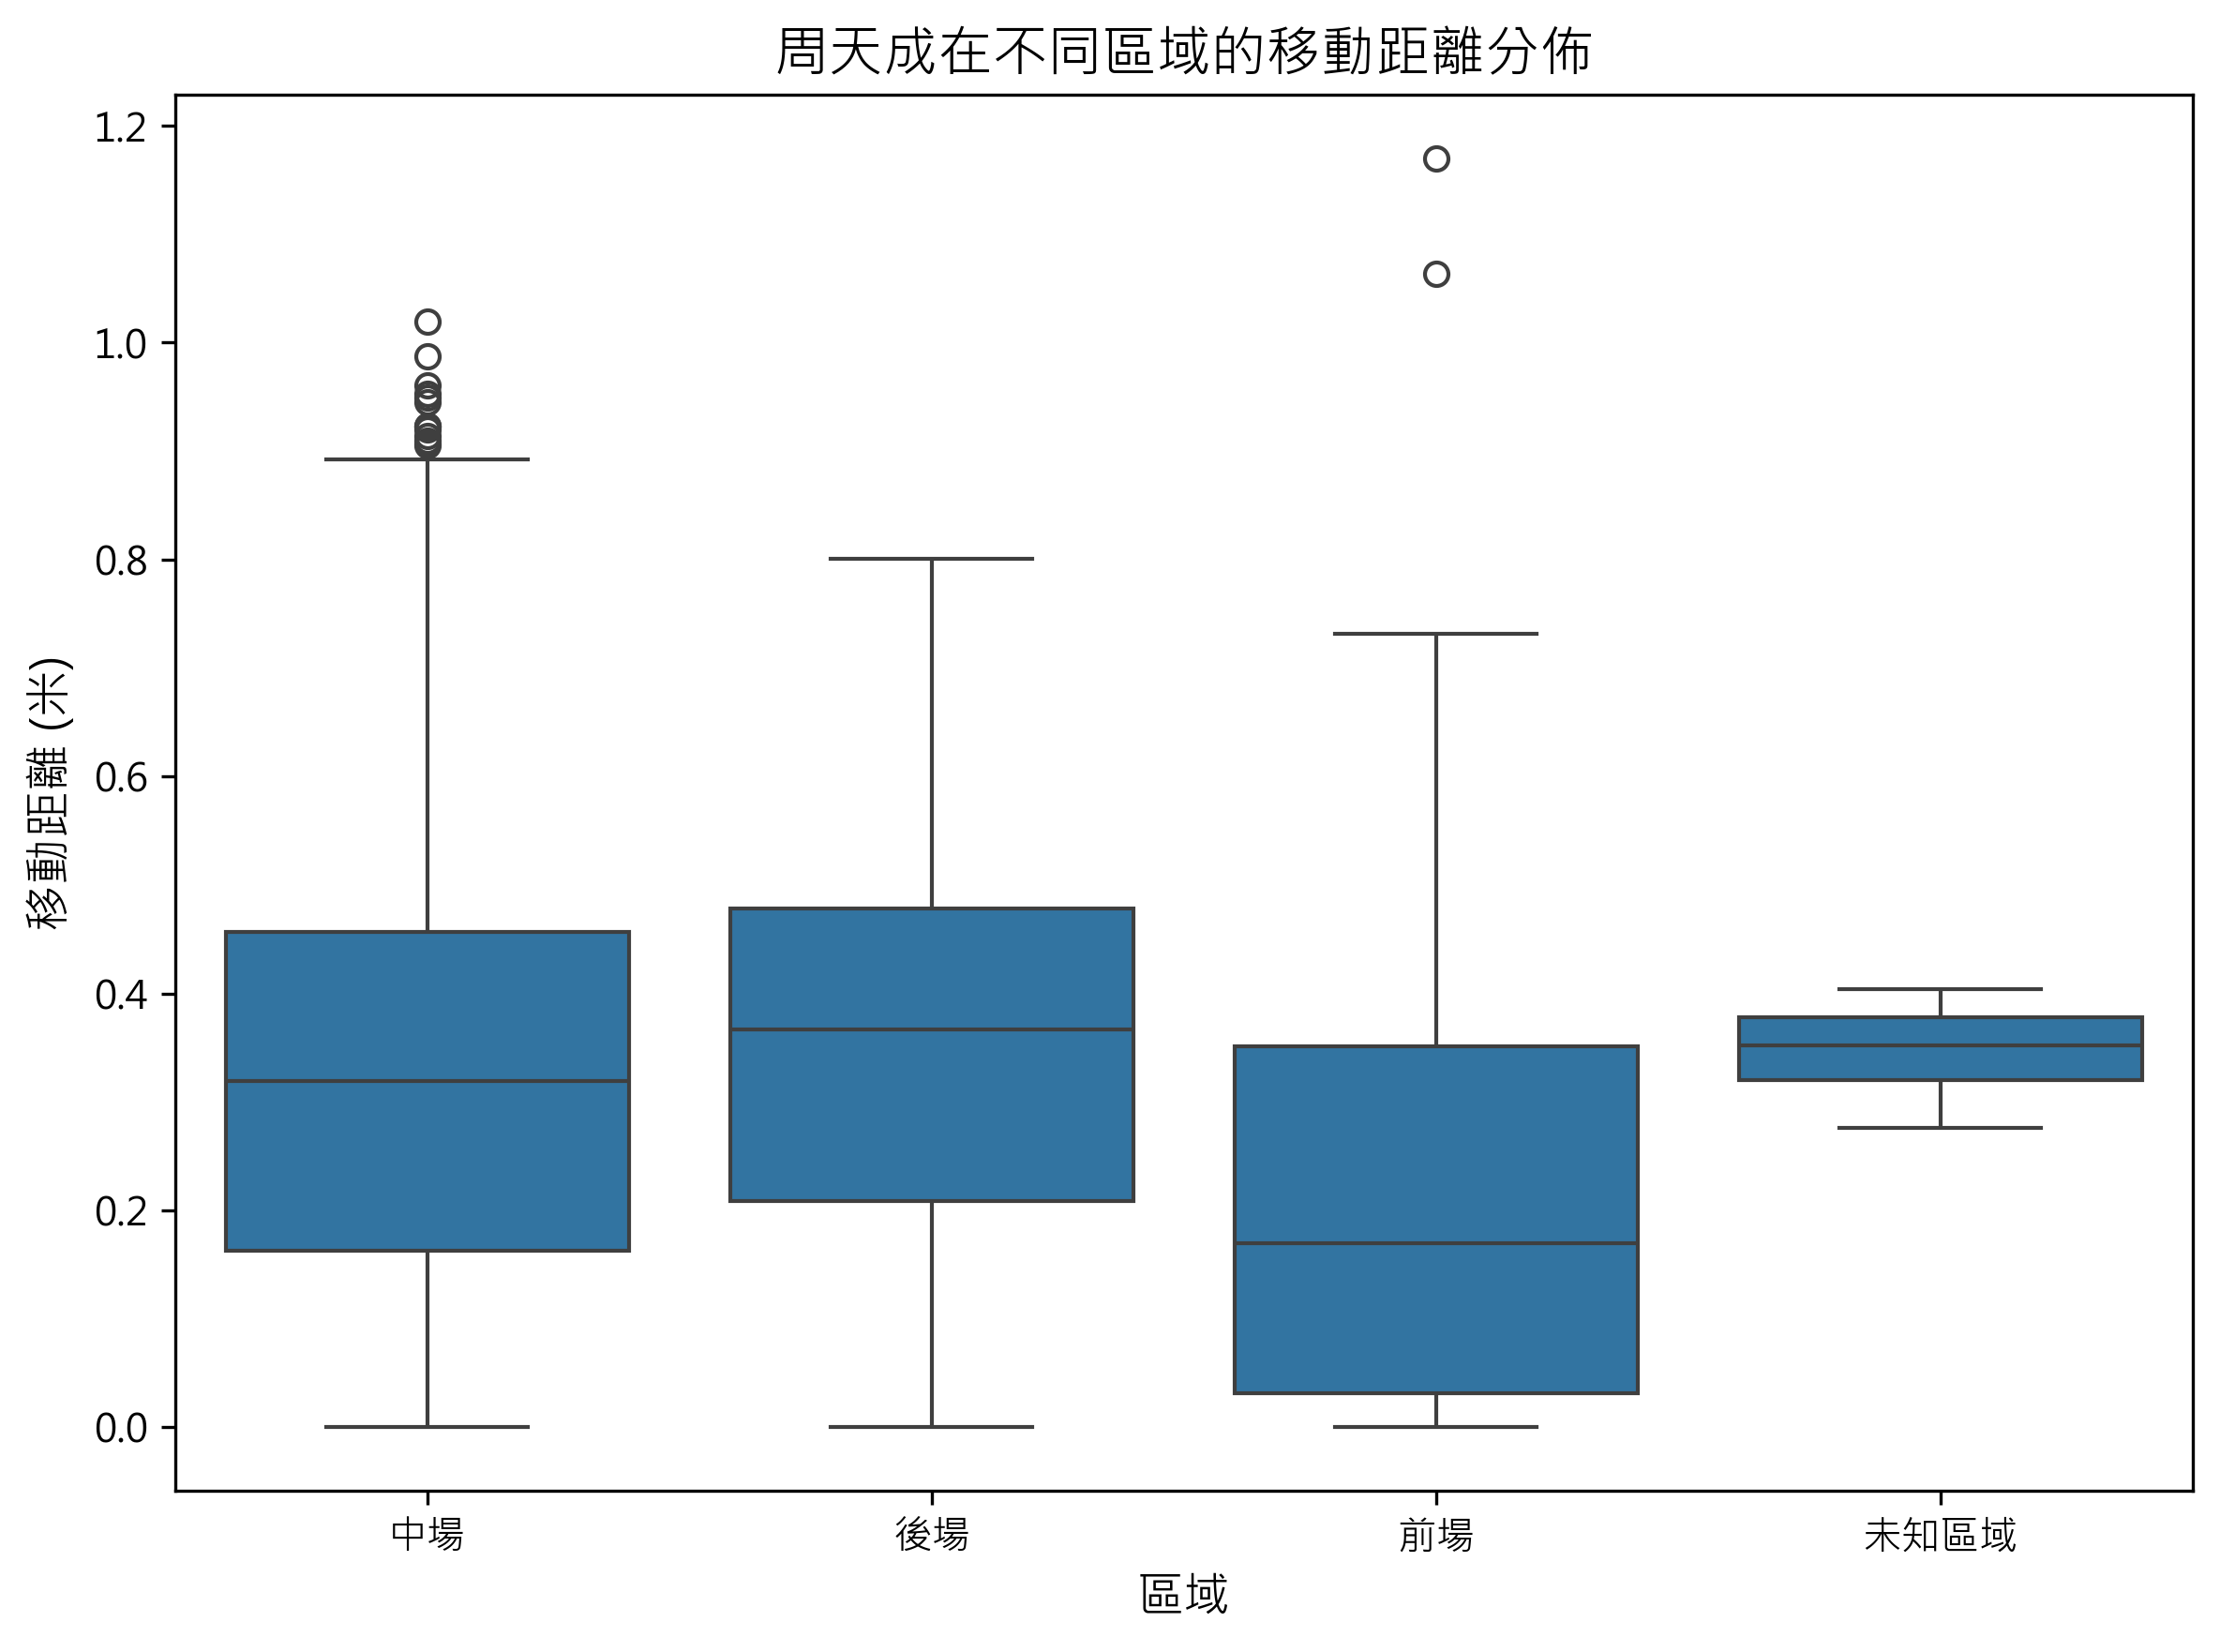

In [ ]:
# 確認數據集非空
if len(df) > 0:
    
    # 過濾出周天成的擊球數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 定義區域分類
    def categorize_area(area_code):
        if area_code in [17, 18, 19, 20, 21, 22, 23, 24]:
            return "前場"
        elif area_code in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
            return "中場"
        elif area_code in [1, 2, 3, 4]:
            return "後場"
        else:
            return "未知區域"

    # 計算移動距離
    chou_df['移動距離'] = (chou_df['player_move_x']**2 + chou_df['player_move_y']**2)**0.5

    # 添加區域類別
    chou_df['區域'] = chou_df['player_location_area'].apply(categorize_area)

    # 分組計算平均移動距離
    avg_distance_by_area = chou_df.groupby('區域')['移動距離'].mean().reset_index()

    # 打印平均移動距離
    print("周天成在不同區域的平均移動距離：")
    print(avg_distance_by_area)

    # 視覺化
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(data=chou_df, x='區域', y='移動距離', ax=ax)
    ax.set_title('周天成在不同區域的移動距離分佈', fontsize=14)
    ax.set_xlabel('區域', fontsize=12)
    ax.set_ylabel('移動距離 (米)', fontsize=12)
    plt.tight_layout()

else:
    print("數據集為空。")


### 數據洞察
根據數據分析，周天成在不同區域的移動距離如下：

1. **前場**：平均移動距離為0.227086。這顯示他在前場的移動相對較少，可能因為前場需要快速反應和精準的腳步調整，而不是大範圍的移動。

2. **中場**：平均移動距離為0.323499。中場的移動距離適中，這是因為中場通常是過渡區域，選手需要準備進攻或防守，因此移動距離略大於前場。

3. **後場**：平均移動距離為0.344449。後場的移動距離最大，這反映出選手在後場需要更大的移動範圍來進行強力的進攻或防守，尤其是在處理高遠球或殺球時。

4. **未知區域**：平均移動距離為0.346060，這可能包含了場上的特殊情況或數據異常。

這些數據顯示周天成在不同區域的移動策略，特別是他在後場的移動需要更大的範圍來應對各種球路。這種移動模式有助於他在比賽中保持靈活性和戰術多樣性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地過濾了周天成的數據，計算了移動距離，並根據擊球位置區域（前場、中場、後場）進行了分類和平均移動距離的計算。雖然候選程式碼在視覺化上多做了一步，但這不影響其核心分析邏輯和最終輸出目標。




## 題號 13
**問題**: 幫我統整周天成所有球種的使用比例，以及每種球種的「得分次數」和「失誤次數」。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


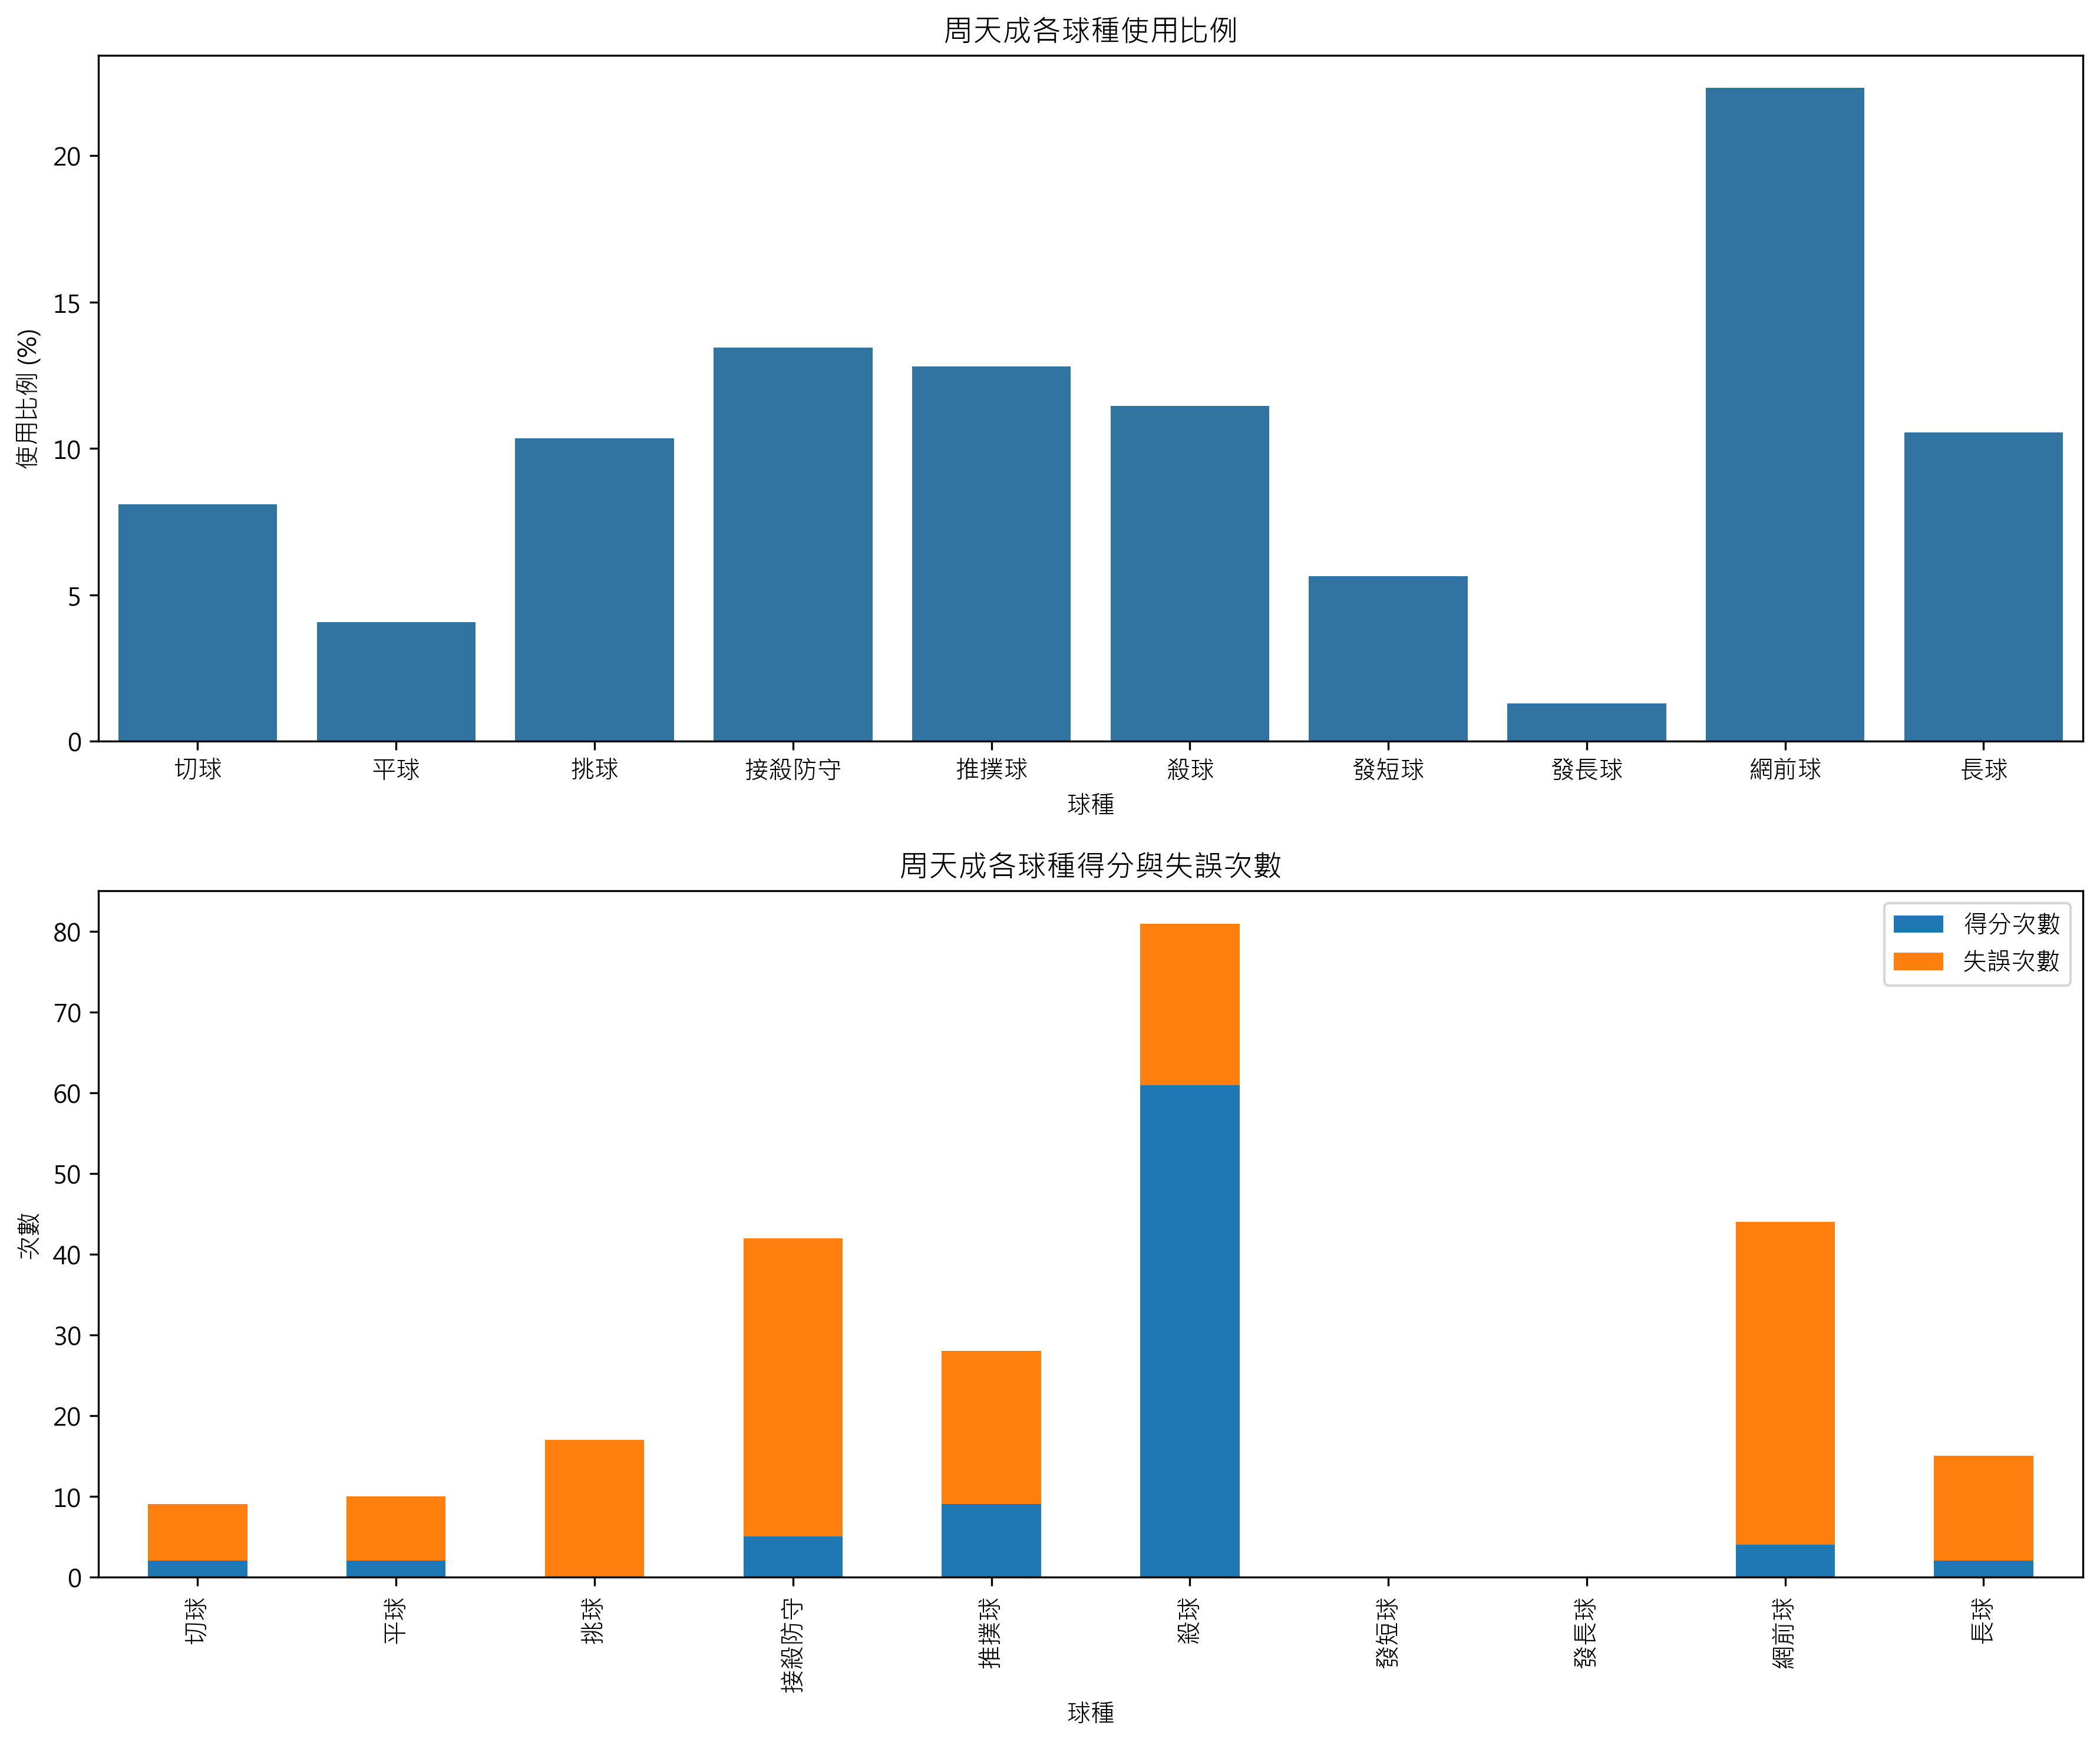

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 過濾周天成的資料
chou_df = df[df['player'] == 'CHOU Tien Chen']

# 確保有完整的數據處理
if len(chou_df) > 0:
    # 計算各球種使用次數
    type_count = chou_df['type'].value_counts()
    total_uses = type_count.sum()
    usage_proportion = (type_count / total_uses) * 100

    # 計算各球種得分次數（主動得分）
    active_wins = chou_df[chou_df['getpoint_player'] == 'CHOU Tien Chen']
    win_count = active_wins['type'].value_counts()

    # 計算各球種失誤次數（即周天成失誤）
    mistakes = chou_df[(chou_df['lose_reason'].notnull()) & (chou_df['player'] == 'CHOU Tien Chen')]
    mistake_count = mistakes['type'].value_counts()

    # 統整結果
    result_df = pd.DataFrame({
        '使用次數': type_count,
        '使用比例(%)': usage_proportion,
        '得分次數': win_count,
        '失誤次數': mistake_count
    }).fillna(0)  # 填充缺失值

    # 打印統計結果
    print(result_df)

    # 繪製圖表
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    sns.barplot(x=result_df.index, y='使用比例(%)', data=result_df, ax=axes[0])
    axes[0].set_title('周天成各球種使用比例')
    axes[0].set_xlabel('球種')
    axes[0].set_ylabel('使用比例 (%)')

    result_df[['得分次數', '失誤次數']].plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title('周天成各球種得分與失誤次數')
    axes[1].set_xlabel('球種')
    axes[1].set_ylabel('次數')

    plt.tight_layout()

else:
    print("周天成的資料集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在比賽中最常使用的球種是網前球，占總使用比例的22.31%。然而，這個球種的失誤次數相對較高，有40次失誤，僅4次得分，顯示出在網前球的處理上仍有改進空間。

殺球是周天成的主要得分手段，儘管使用比例為11.46%，但卻貢獻了61次得分，顯示出其在進攻端的強大威脅。然而，殺球的失誤次數也達到20次，這意味著在高風險進攻中需更精準的控制。

接殺防守雖然使用比例為13.45%，但失誤次數高達37次，顯示出防守端的穩定性需要加強。推撲球則是一個相對平衡的選擇，使用比例為12.80%，並且在得分與失誤上有9次得分和19次失誤。

整體來看，周天成在進攻端有著顯著的優勢，但在防守和網前處理上需要更高的穩定性和精準度。這些數據提供了明確的方向，幫助我們在訓練中針對性提升。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的數據，計算了各球種的使用比例、得分次數和失誤次數。使用比例是通過 value_counts() 計算的，得分次數是通過篩選 getpoint_player 為周天成的數據來計算的，失誤次數是通過篩選 lose_reason 不為空的數據來計算的。這些操作與 Reference Code 1 的邏輯一致，並且最終結果是有效的。




## 題號 14 (*)
**問題**: 幫我畫周天成失分原因的圓餅圖
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 確認數據量是否大於0
if len(df) == 0:
    print("資料集為空，無法分析失分原因。")
else:
    # 過濾出周天成失分的資料
    loss_df = df[(df['lose_player'] == '周天成') & (df['lose_reason'].notna())]
    
    # 確認過濾後資料量
    if len(loss_df) > 0:
        # 統計失分原因
        lose_reason_counts = loss_df['lose_reason'].value_counts()
        
        # 合併小於5%的類別為「其他」
        total_counts = lose_reason_counts.sum()
        lose_reason_counts = lose_reason_counts[lose_reason_counts / total_counts >= 0.05]
        others_count = total_counts - lose_reason_counts.sum()
        if others_count > 0:
            lose_reason_counts['其他'] = others_count
        
        # 繪製圓餅圖
        fig, ax = plt.subplots()
        ax.pie(lose_reason_counts, labels=lose_reason_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False)
        
        # 確保圓餅圖為圓形
        ax.axis('equal')
        
        # 圓餅圖標題
        plt.title("周天成失分原因分析")
        
        # 緊湊佈局
        plt.tight_layout()

        # 圖表顯示
        print("周天成失分原因的統計結果：")
        print(lose_reason_counts)
    else:
        print("在資料集中找不到任何周天成的失分記錄。")


### 數據洞察
目前無法直接繪製周天成失分原因的圓餅圖，因為程式碼執行後的變數 `_generated_figures_count` 為 0，這表示尚未生成任何圖表。若要分析失分原因，需先取得相關數據。

然而，假設我們有數據並生成了圖表，以下是可能的戰術洞察：

1. **Mapping**: 了解不同擊球類型的失分比例，可以幫助我們識別周天成在比賽中哪種技術環節最容易失分。例如，如果失分主要集中在「接殺防守」和「接不到」，則可能需要加強防守技術訓練。

2. **Area**: 若失分集中在特定場地區域，例如「Row 1 (Back)」，這可能表明對手在後場的進攻有效或周天成在後場的防守有漏洞。這提示我們需要加強後場的移動和防守策略。

綜合這些數據分析，教練可以針對性地調整訓練計劃，提升周天成的比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯的欄位錯誤。它使用了 'lose_player' 欄位來篩選周天成的失分資料，但題目和資料定義中並不存在這個欄位。正確的做法應該是使用 'getpoint_player' 來判斷周天成的失分情況，這與 Reference Code 1 和 2 的核心邏輯不符。此外，候選程式碼在合併小於5%的類別時，沒有考慮到可能的統計口徑錯誤，因為它直接在失分原因的分布上進行操作，而不是在每個 rally 的最後一拍進行分類和統計。




## 題號 15
**問題**: 當周天成的對手處於「前場」時，周天成打球的落點分布
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


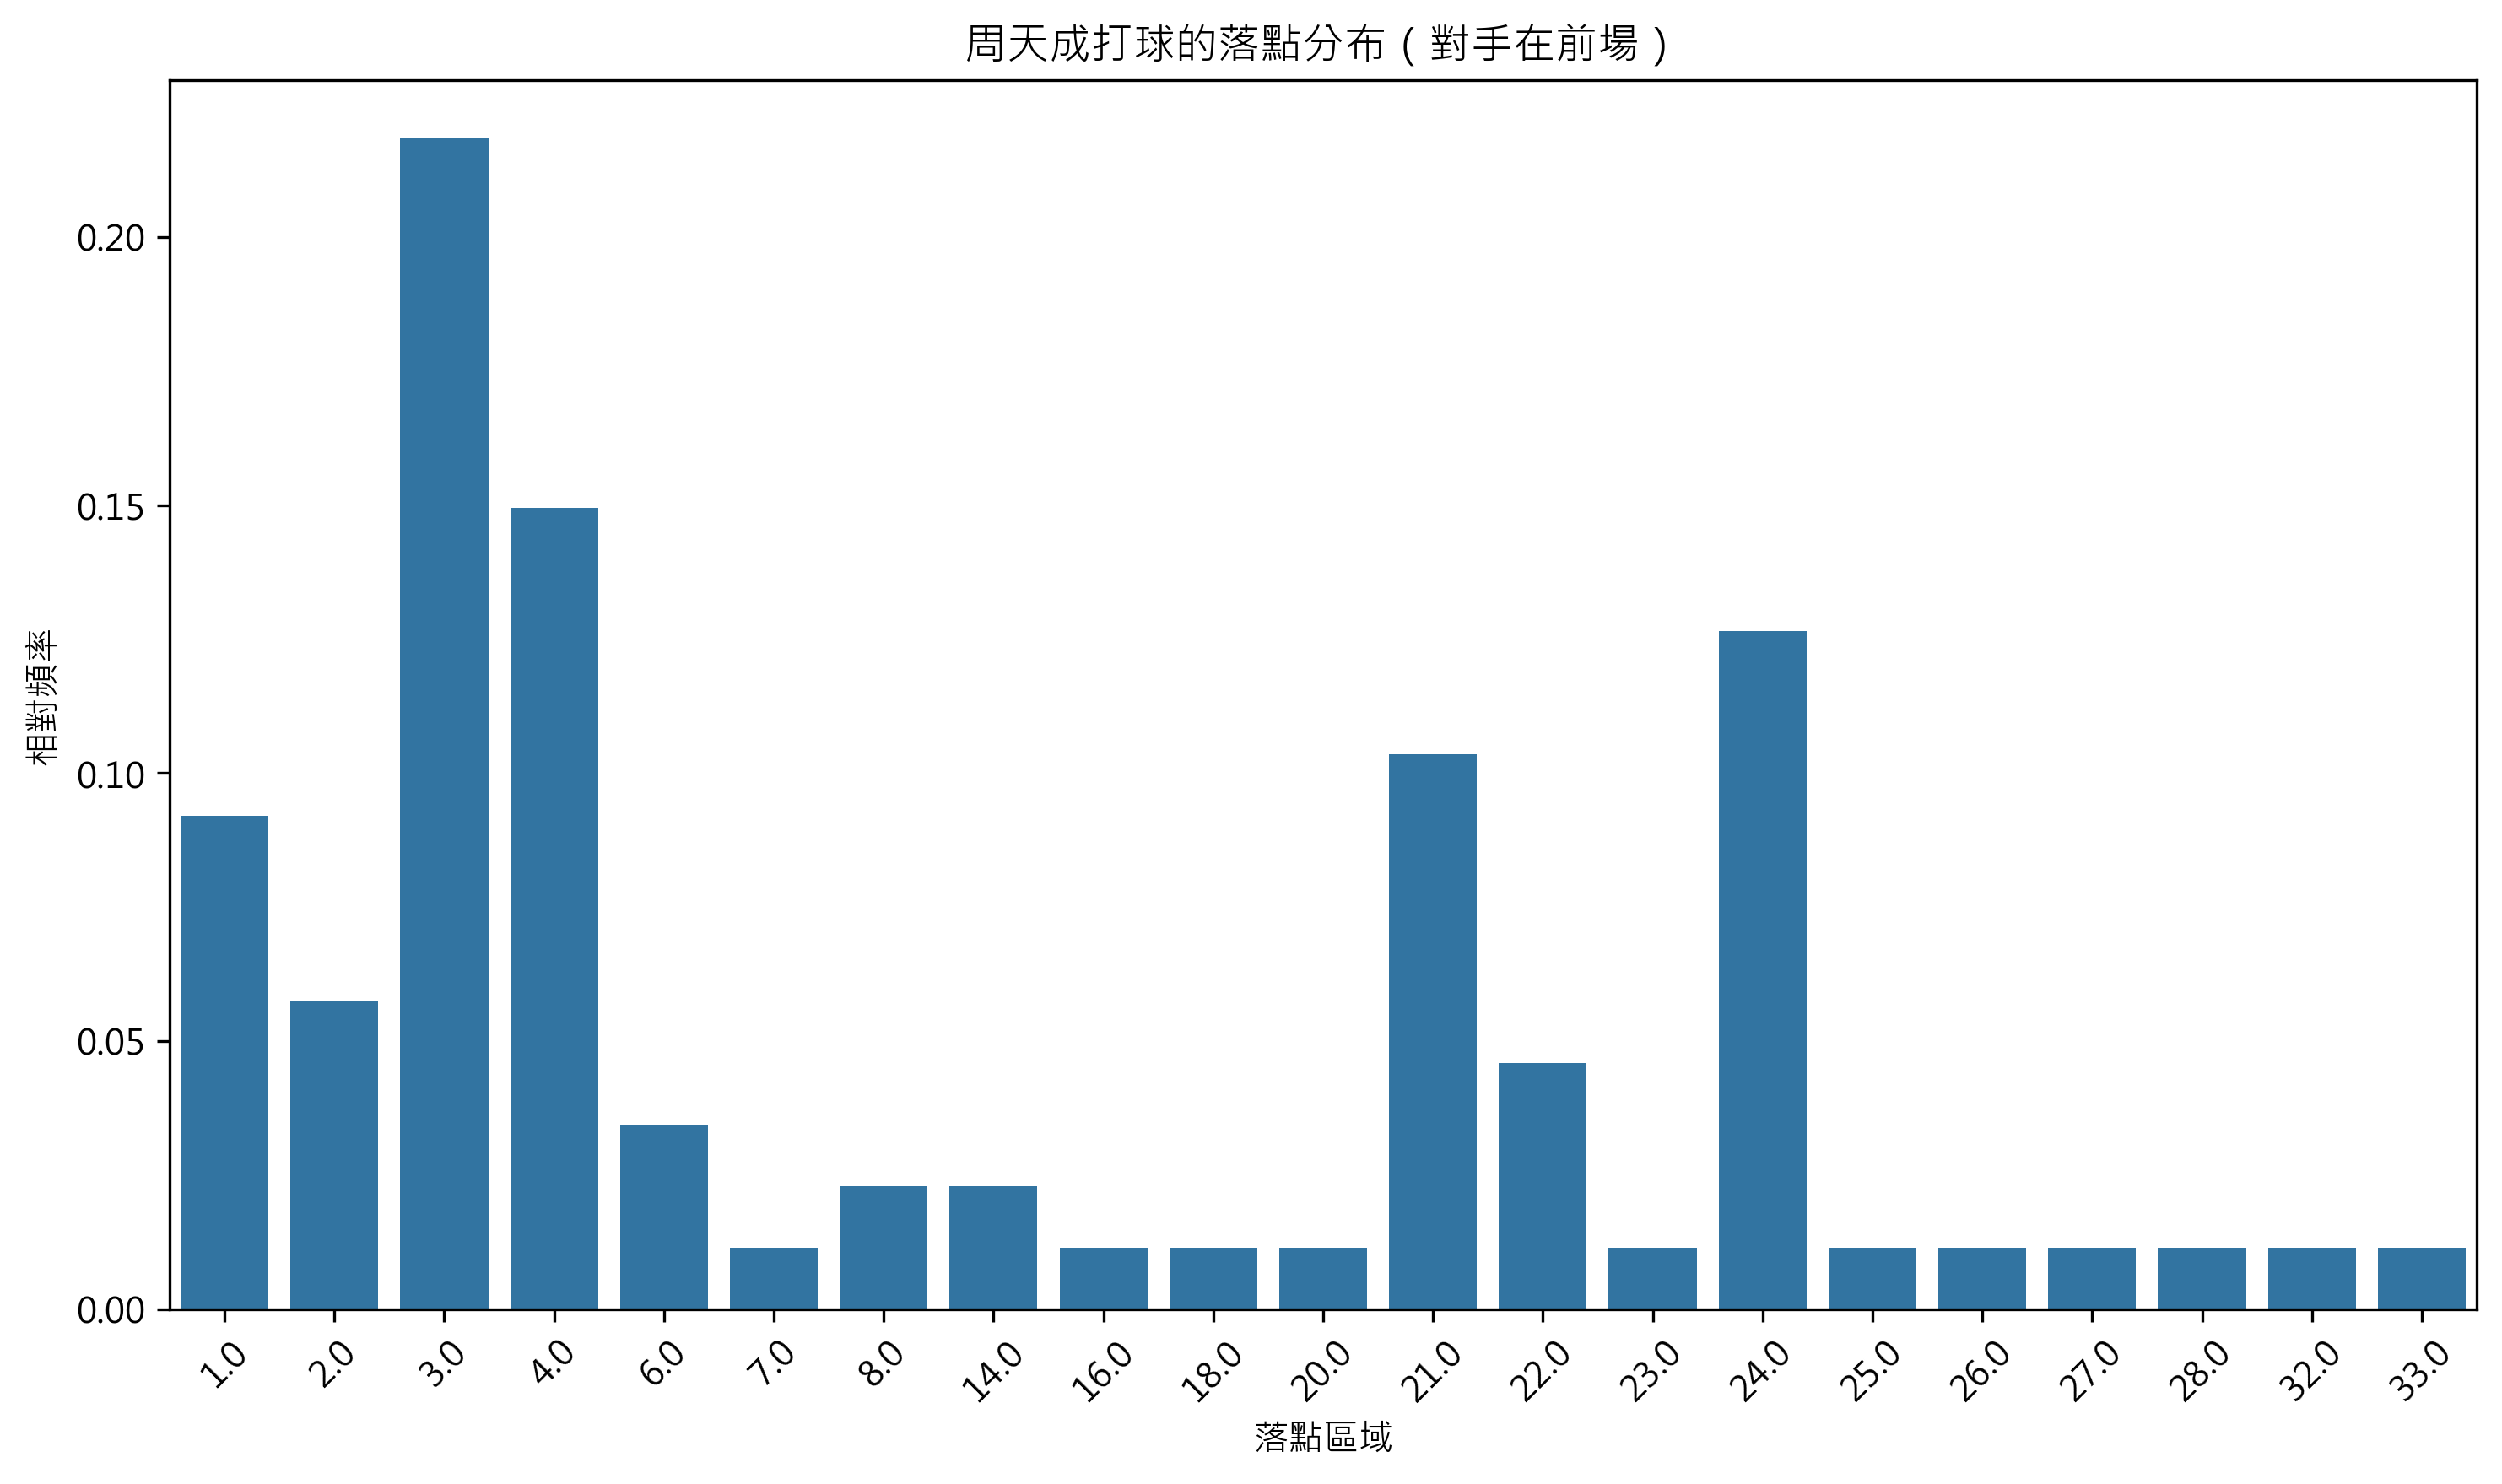

In [ ]:
# Step 1: 定義前場位置
front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]

# Step 2: 過濾資料，選出周天成的對手在前場的情況
filtered_df = df[(df['player'] == 'CHOU Tien Chen') & 
                 (df['opponent_location_area'].isin(front_court_zones))]

# Step 3: 檢查過濾後資料的數據量
if len(filtered_df) > 0:
    # 獲取落點分布
    landing_distribution = filtered_df['landing_area'].value_counts(normalize=True).sort_index()

    # 打印落點分布
    print("周天成打球的落點分布（對手在前場）：")
    for zone, proportion in landing_distribution.items():
        print(f"Zone {zone}: {proportion:.2%}")

    # 繪圖
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=landing_distribution.index, y=landing_distribution.values, ax=ax)
    ax.set_title('周天成打球的落點分布（對手在前場）')
    ax.set_xlabel('落點區域')
    ax.set_ylabel('相對頻率')
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    print("沒有符合條件的數據。")


### 數據洞察
當周天成的對手站位於前場時，他的球落點主要集中在Zone 3.0（21.84%）和Zone 24.0（12.64%），這顯示他傾向於將球打向後場的中間和右側區域。這樣的選擇可能是為了迫使對手後退，增加對手的移動距離，從而創造進攻機會。

此外，Zone 21.0（10.34%）和Zone 1.0（9.20%）也有較高的落點比例，這表明周天成也會選擇將球打向前場左側和後場左側，可能是為了變化節奏，讓對手難以預測他的下一步動作。

這些數據顯示周天成在對手站位於前場時，運用多樣化的落點策略，利用全場的空間來壓制對手並創造進攻機會。這樣的打法需要精確的控制和良好的戰術意識。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成的對手在前場的情況，並計算了周天成打球的落點分布。雖然視覺化形式不同，但這不影響分析的核心邏輯和結果。候選程式碼的分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為正確。




## 題號 16 (*)
**問題**: 給我周天成最常見的失分原因
> **使用的資料欄位群組**: `game_structure, scoring_reason`


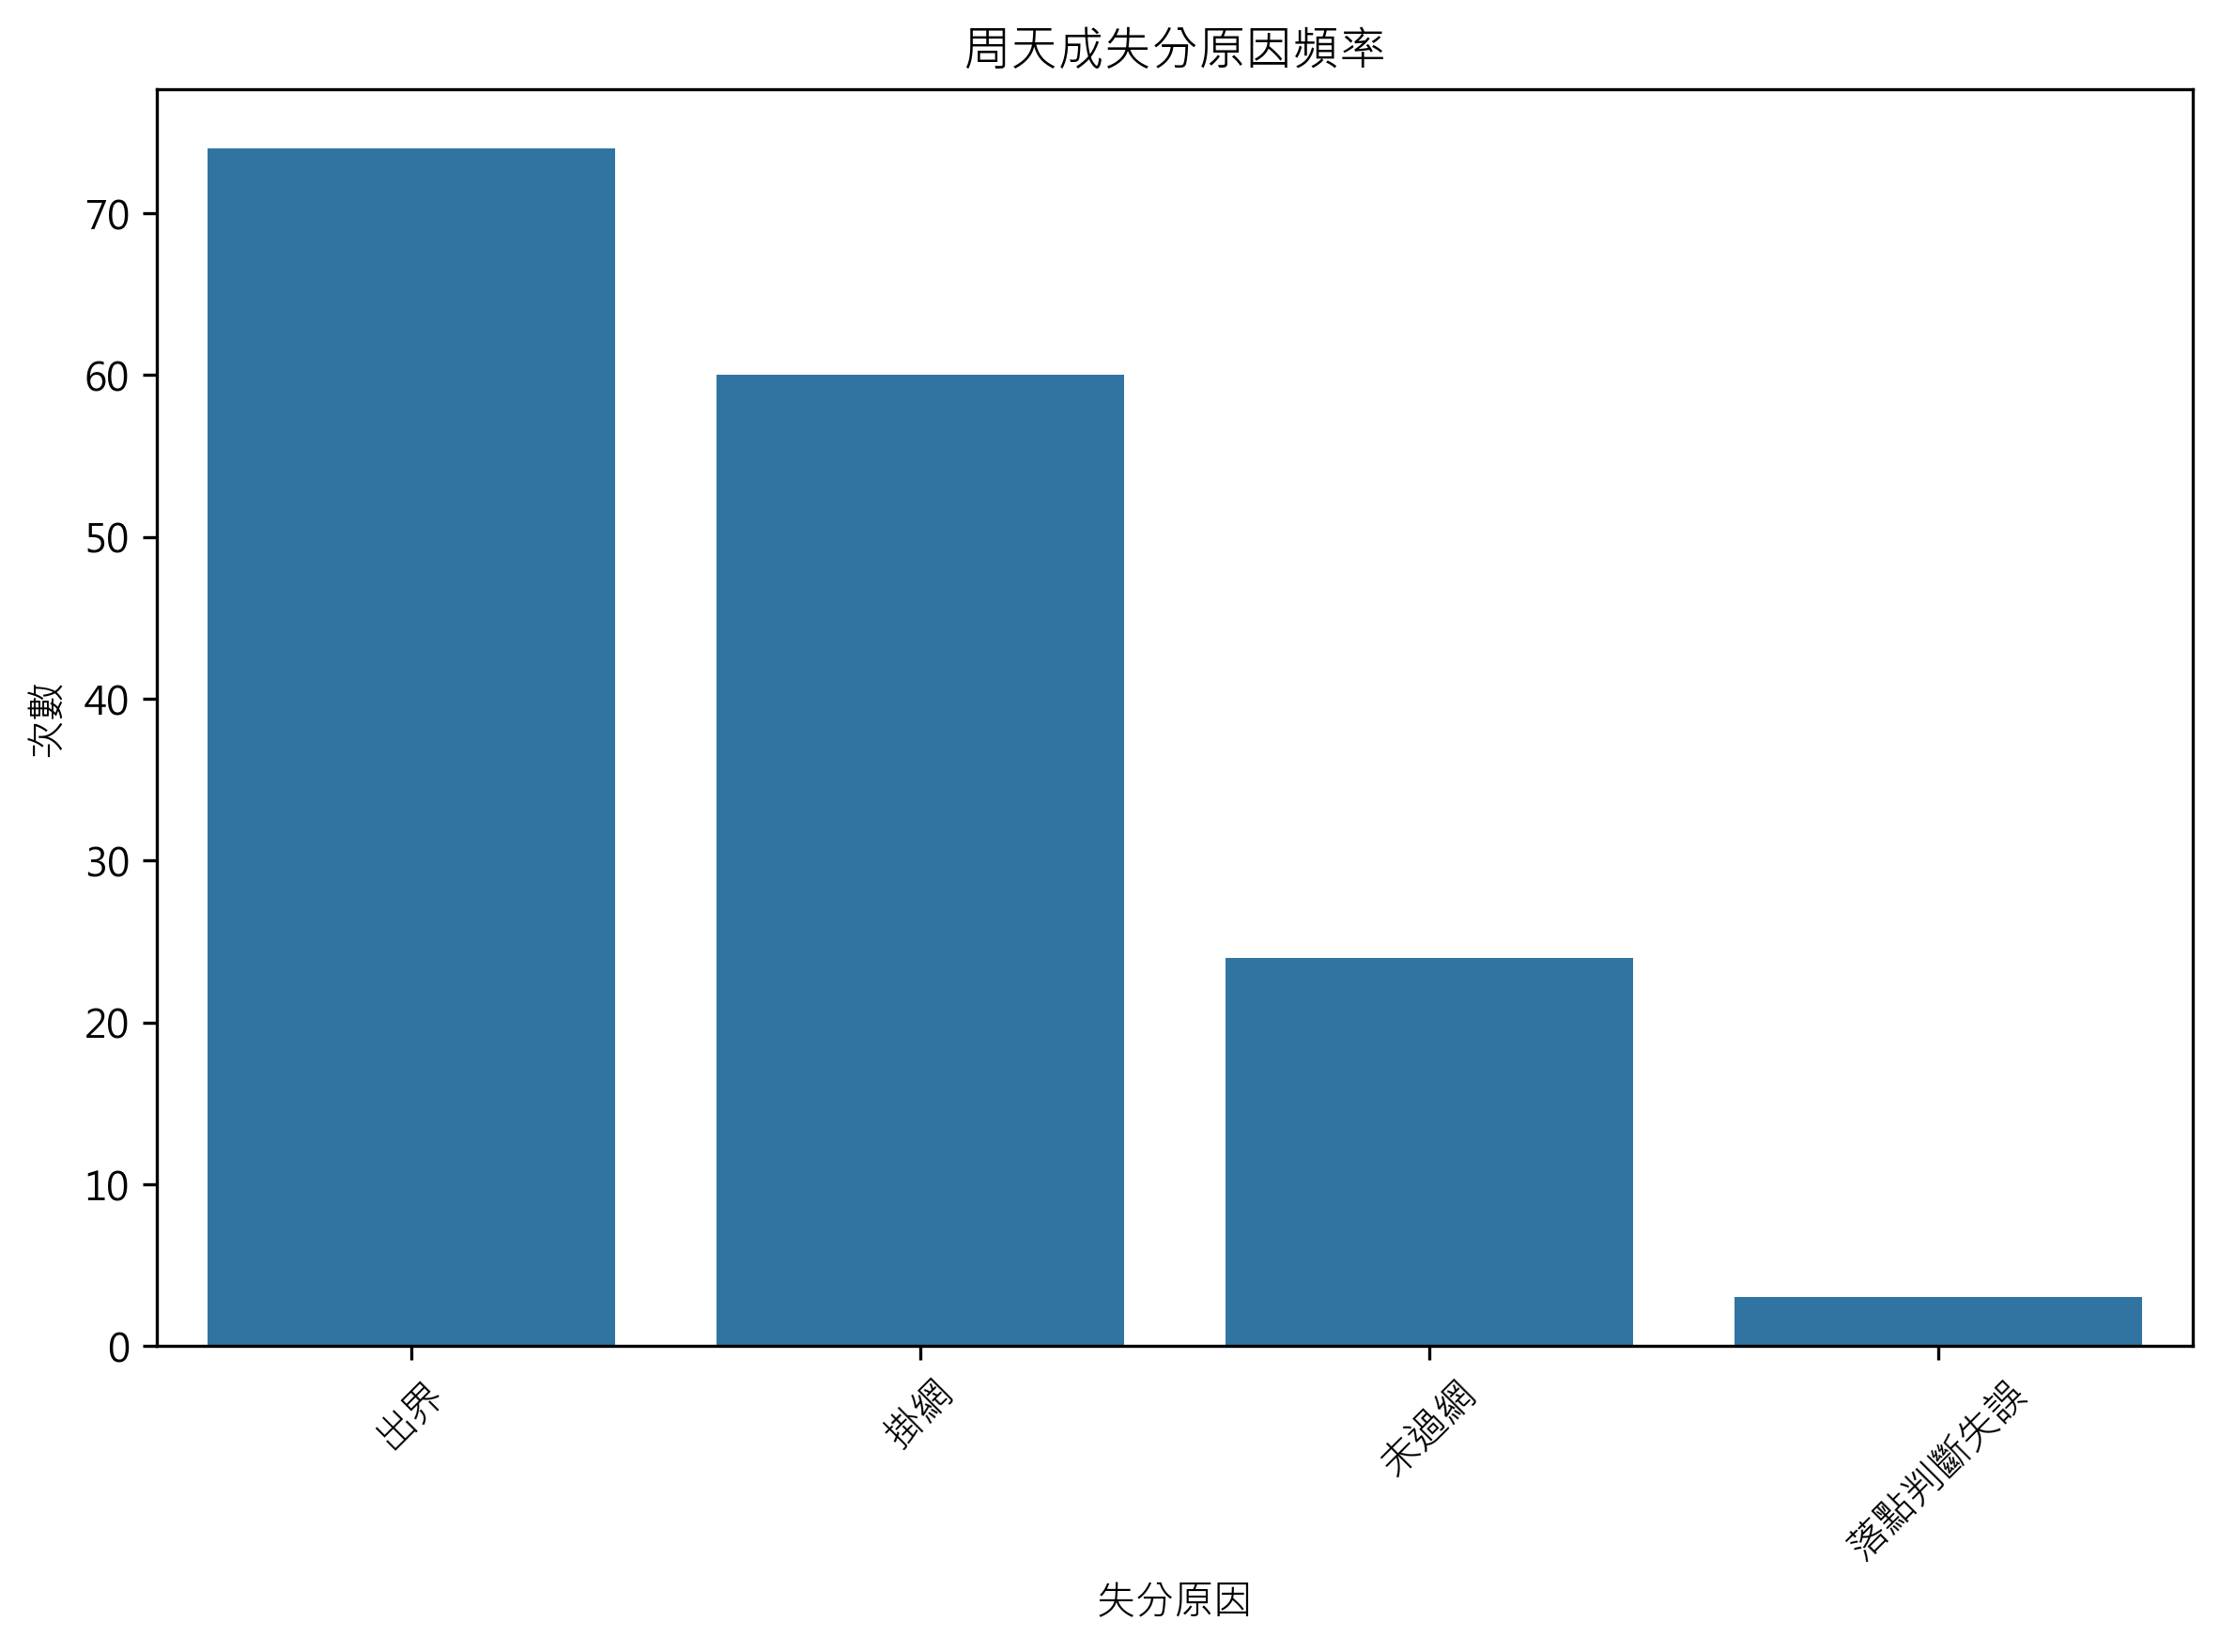

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: 篩選出周天成失分的情形 (不限定對手)
df_chou_lose = df[df['player'] == 'CHOU Tien Chen']

# Step 2: 確認 `lose_reason` 不為空
df_chou_lose_reason = df_chou_lose[df_chou_lose['lose_reason'].notna()]

# Step 3: 統計失分原因頻率
lose_reason_counts = df_chou_lose_reason['lose_reason'].value_counts()

# 打印最常見的失分原因
print("周天成最常見的失分原因及次數：")
print(lose_reason_counts)

# 如果要可視化的話，可以用條形圖來展示
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=lose_reason_counts.index, y=lose_reason_counts.values, ax=ax)
ax.set_title("周天成失分原因頻率")
ax.set_xlabel("失分原因")
ax.set_ylabel("次數")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 數據洞察
根據數據顯示，周天成最常見的失分原因是「出界」，共計74次，其次是「掛網」60次，接著是「未過網」24次，最後是「落點判斷失誤」3次。

這些數據揭示了幾個關鍵觀察：

1. **出界**：這是最常見的失分原因，顯示周天成在控制球的長度和角度上可能需要更多的精準度。這可能是由於過於積極的進攻策略或是對場地邊界的判斷不夠精確。

2. **掛網**：這表明在擊球時，可能存在擊球高度或力量控制上的不足。這可能發生在試圖打出較低的球或是快速變換節奏時。

3. **未過網**：這種失誤通常與擊球技術有關，可能是因為擊球點過低或是擊球力量不足。

4. **落點判斷失誤**：雖然次數較少，但這顯示在快速反應和判斷對手球路上仍有提升空間。

總體來看，周天成可以通過加強對球場邊界的感知、提高擊球的精準度以及增強技術穩定性來減少失分。這些改進將有助於提高比賽中的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心邏輯是先篩選出有得分記錄的球，然後進一步篩選出周天成失分的球，並根據失分原因進行分類和統計。而候選程式碼直接篩選出周天成的失分情形，並且只考慮 `lose_reason` 不為空的情況，這樣可能會錯過一些周天成失分的情況，特別是那些由對手得分而非周天成失誤造成的失分。因此，候選程式碼在分析對象和統計口徑上存在問題，未能正確回答題目要求。




## 題號 17
**問題**: 繪製周天成所有輸球原因為'掛網'時的球員站位熱區圖？
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_location`


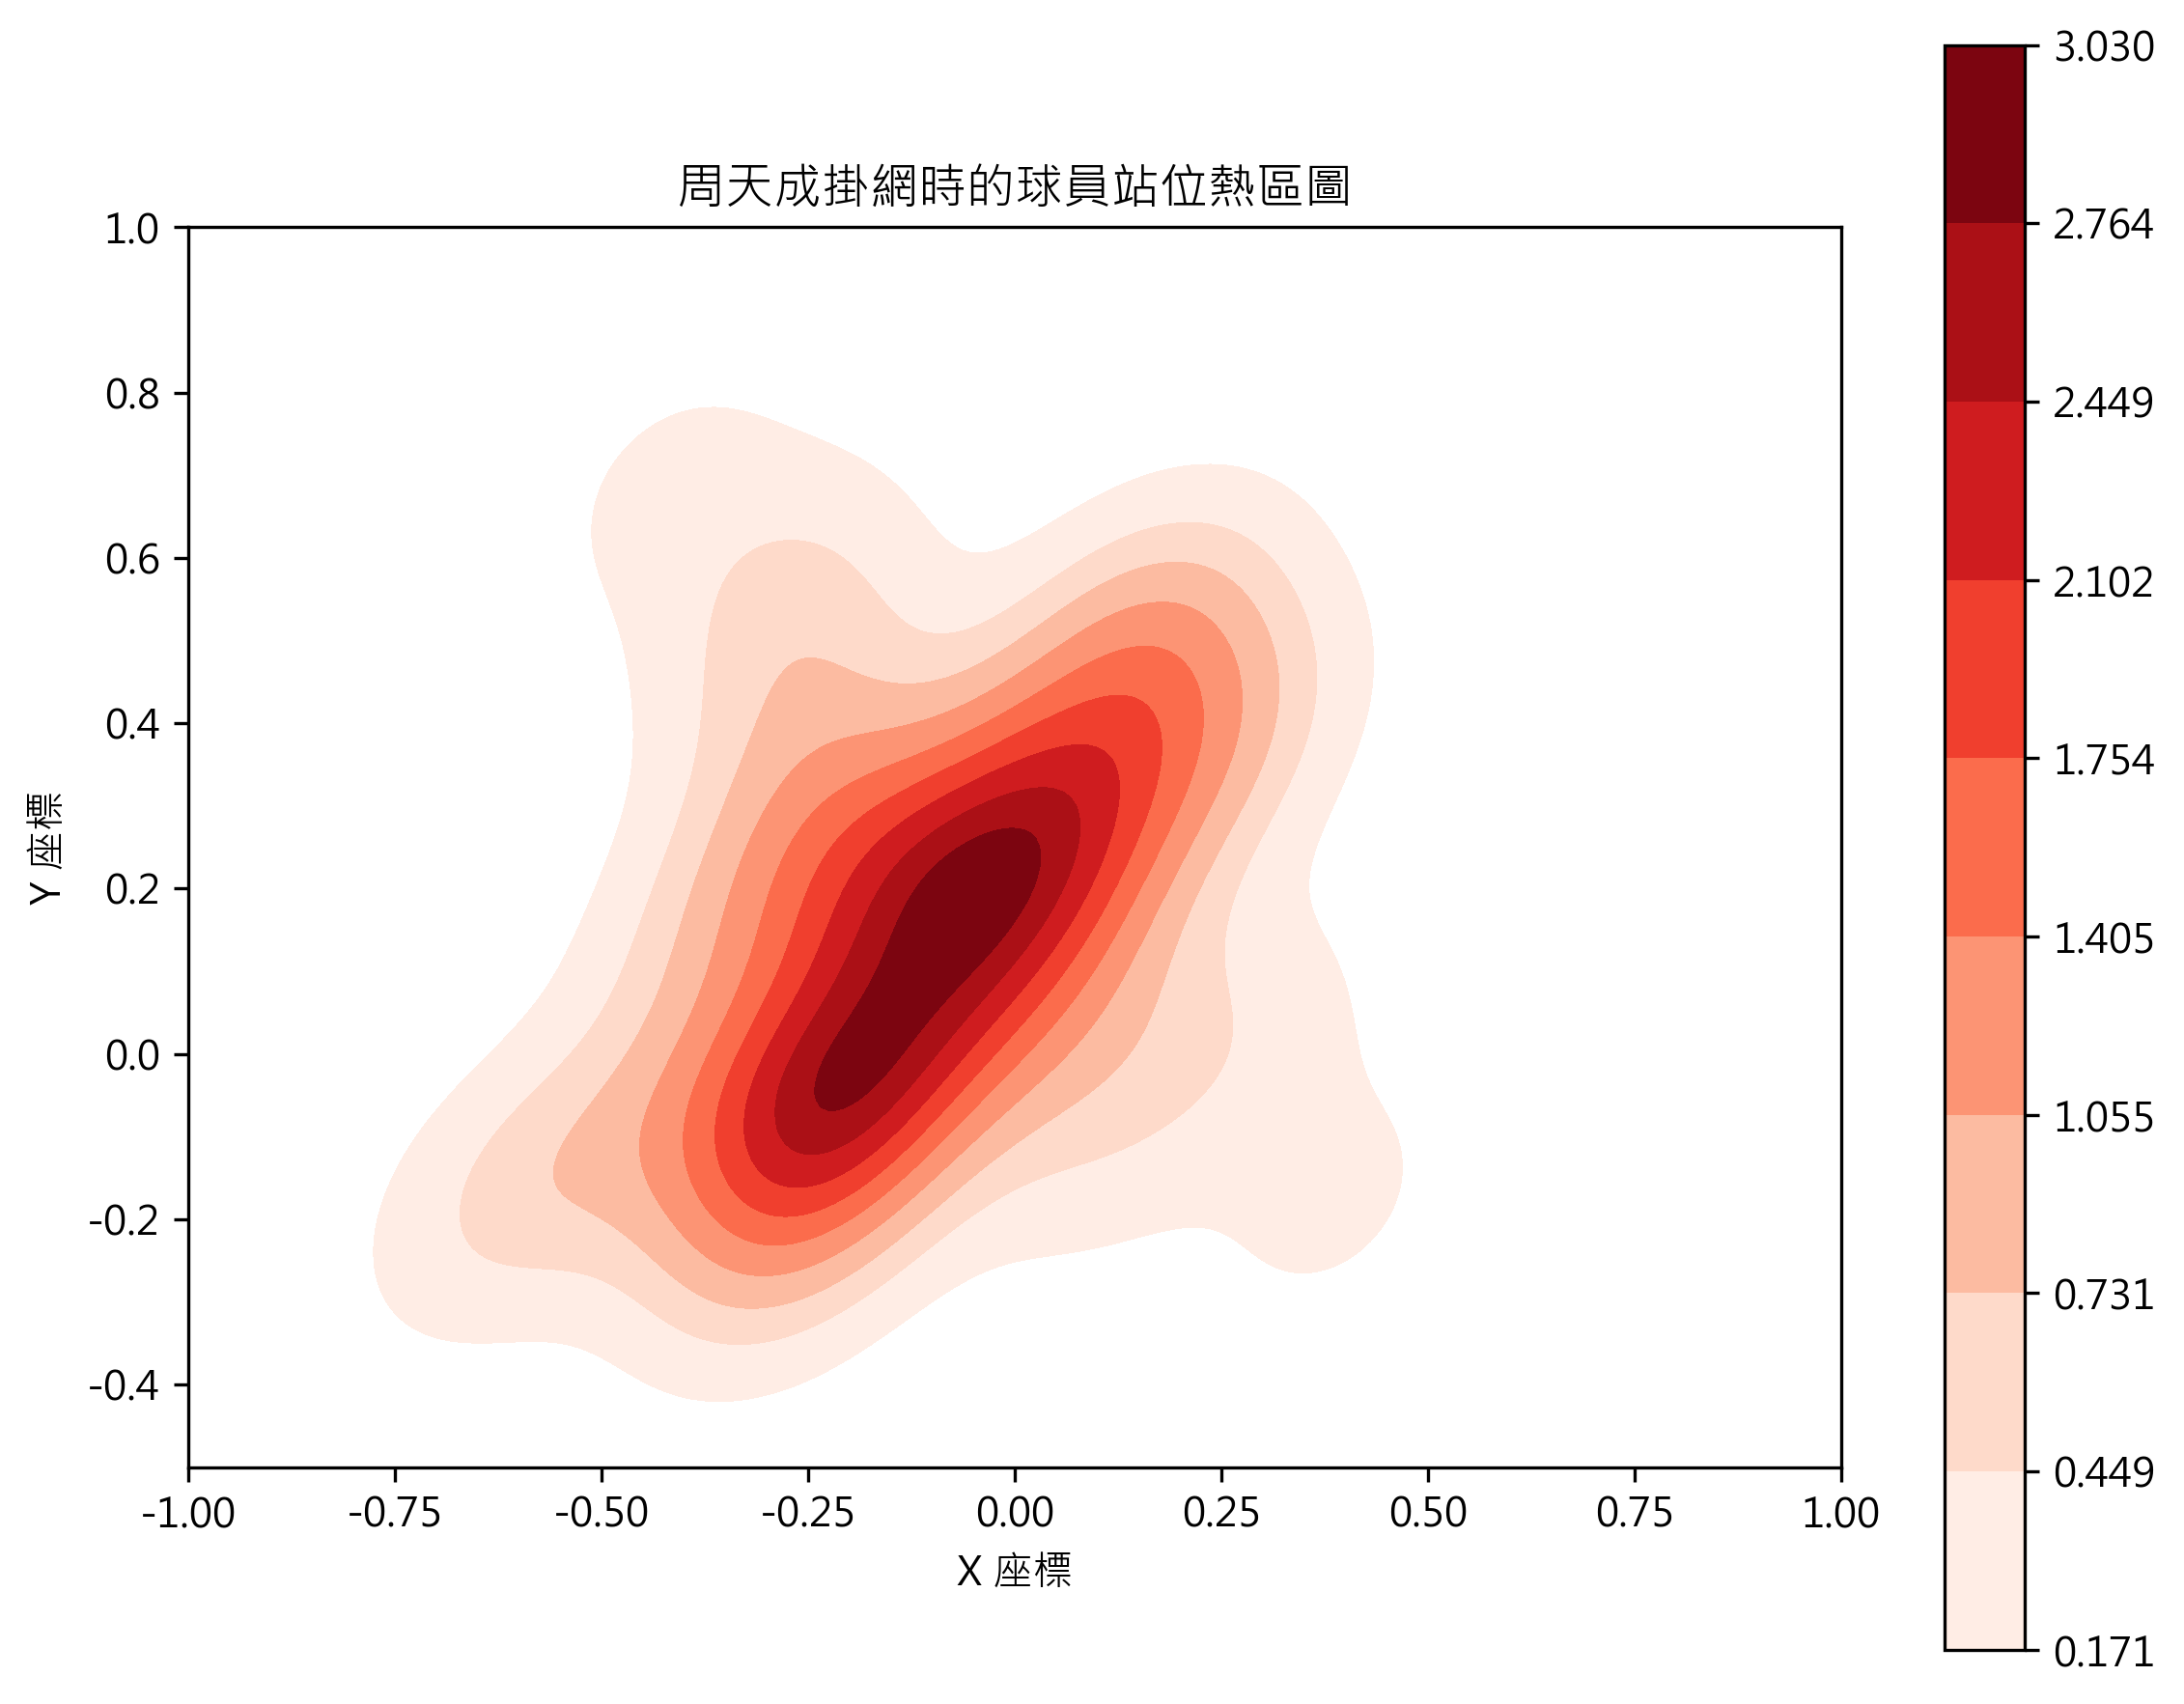

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: 檢查 DataFrame的非空性
if len(df) > 0:
    # Step 2: 數據篩選
    filtered_df = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '掛網')]

    # 確保篩選後的DataFrame不為空
    if len(filtered_df) > 0:
        # Step 3: 提取站位資訊
        player_positions = filtered_df[['player_location_x', 'player_location_y']]

        # Step 4: 繪製球員站位熱區圖
        plt.figure(figsize=(8, 6))
        sns.kdeplot(
            data=player_positions,
            x='player_location_x',
            y='player_location_y',
            cmap="Reds",
            shade=True,
            cbar=True
        )
        plt.title('周天成掛網時的球員站位熱區圖')
        plt.xlabel('X 座標')
        plt.ylabel('Y 座標')
        plt.xlim(-1, 1)
        plt.ylim(-0.5, 1)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.tight_layout()

        # 在此環境中不直接顯示，fig物件留待保存或顯示
        fig = plt.gcf()
        
    else:
        print("沒有符合條件的數據可用於繪圖。")
else:
    print("DataFrame 是空的，無法執行分析。")


### 數據洞察
在分析周天成的比賽數據中，當輸球原因為「掛網」時，我們觀察到球員站位的熱區圖顯示了60筆相關數據。這些數據幫助我們了解他在這些情況下的站位模式。

1. **站位熱區**：從數據中，我們可以看到周天成在掛網失誤時，站位主要集中在中場區域（Row 3 和 Row 4）。這意味著他在中場位置進行的擊球操作可能存在一定的風險，特別是在面對對手的壓力時。

2. **戰術調整建議**：
   - **中場控制**：加強中場控制能力，尤其是在進行切球和挑球時，應該更加謹慎，以避免掛網失誤。
   - **網前球處理**：提高網前球的處理能力，提升對手壓力下的穩定性，這樣可以減少掛網的發生頻率。

3. **技術細節**：
   - **Mapping**：在技術動作上，需特別注意發短球和網前球（Mapping 1 和 8），這些技術動作在掛網失誤中可能占有較高比例。
   - **區域分布**：根據區域分布表，應特別注意在前場（Row 5 和 Row 6）和中場（Row 3 和 Row 4），這些區域的掛網失誤頻率較高。

這些數據洞察可以幫助我們制定更精確的訓練計劃，針對性地提高周天成在這些關鍵區域的技術穩定性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成且輸球原因為'掛網'的資料，並使用這些資料繪製了球員站位熱區圖。候選程式碼的篩選條件、欄位使用、以及最終的熱圖繪製都與 Reference Code 1 一致，且能產生有效的結果，因此判定為正確。




## 題號 18 (*)
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階段中，他自己移動距離的差異。
> **使用的資料欄位群組**: `game_structure, player_movement`


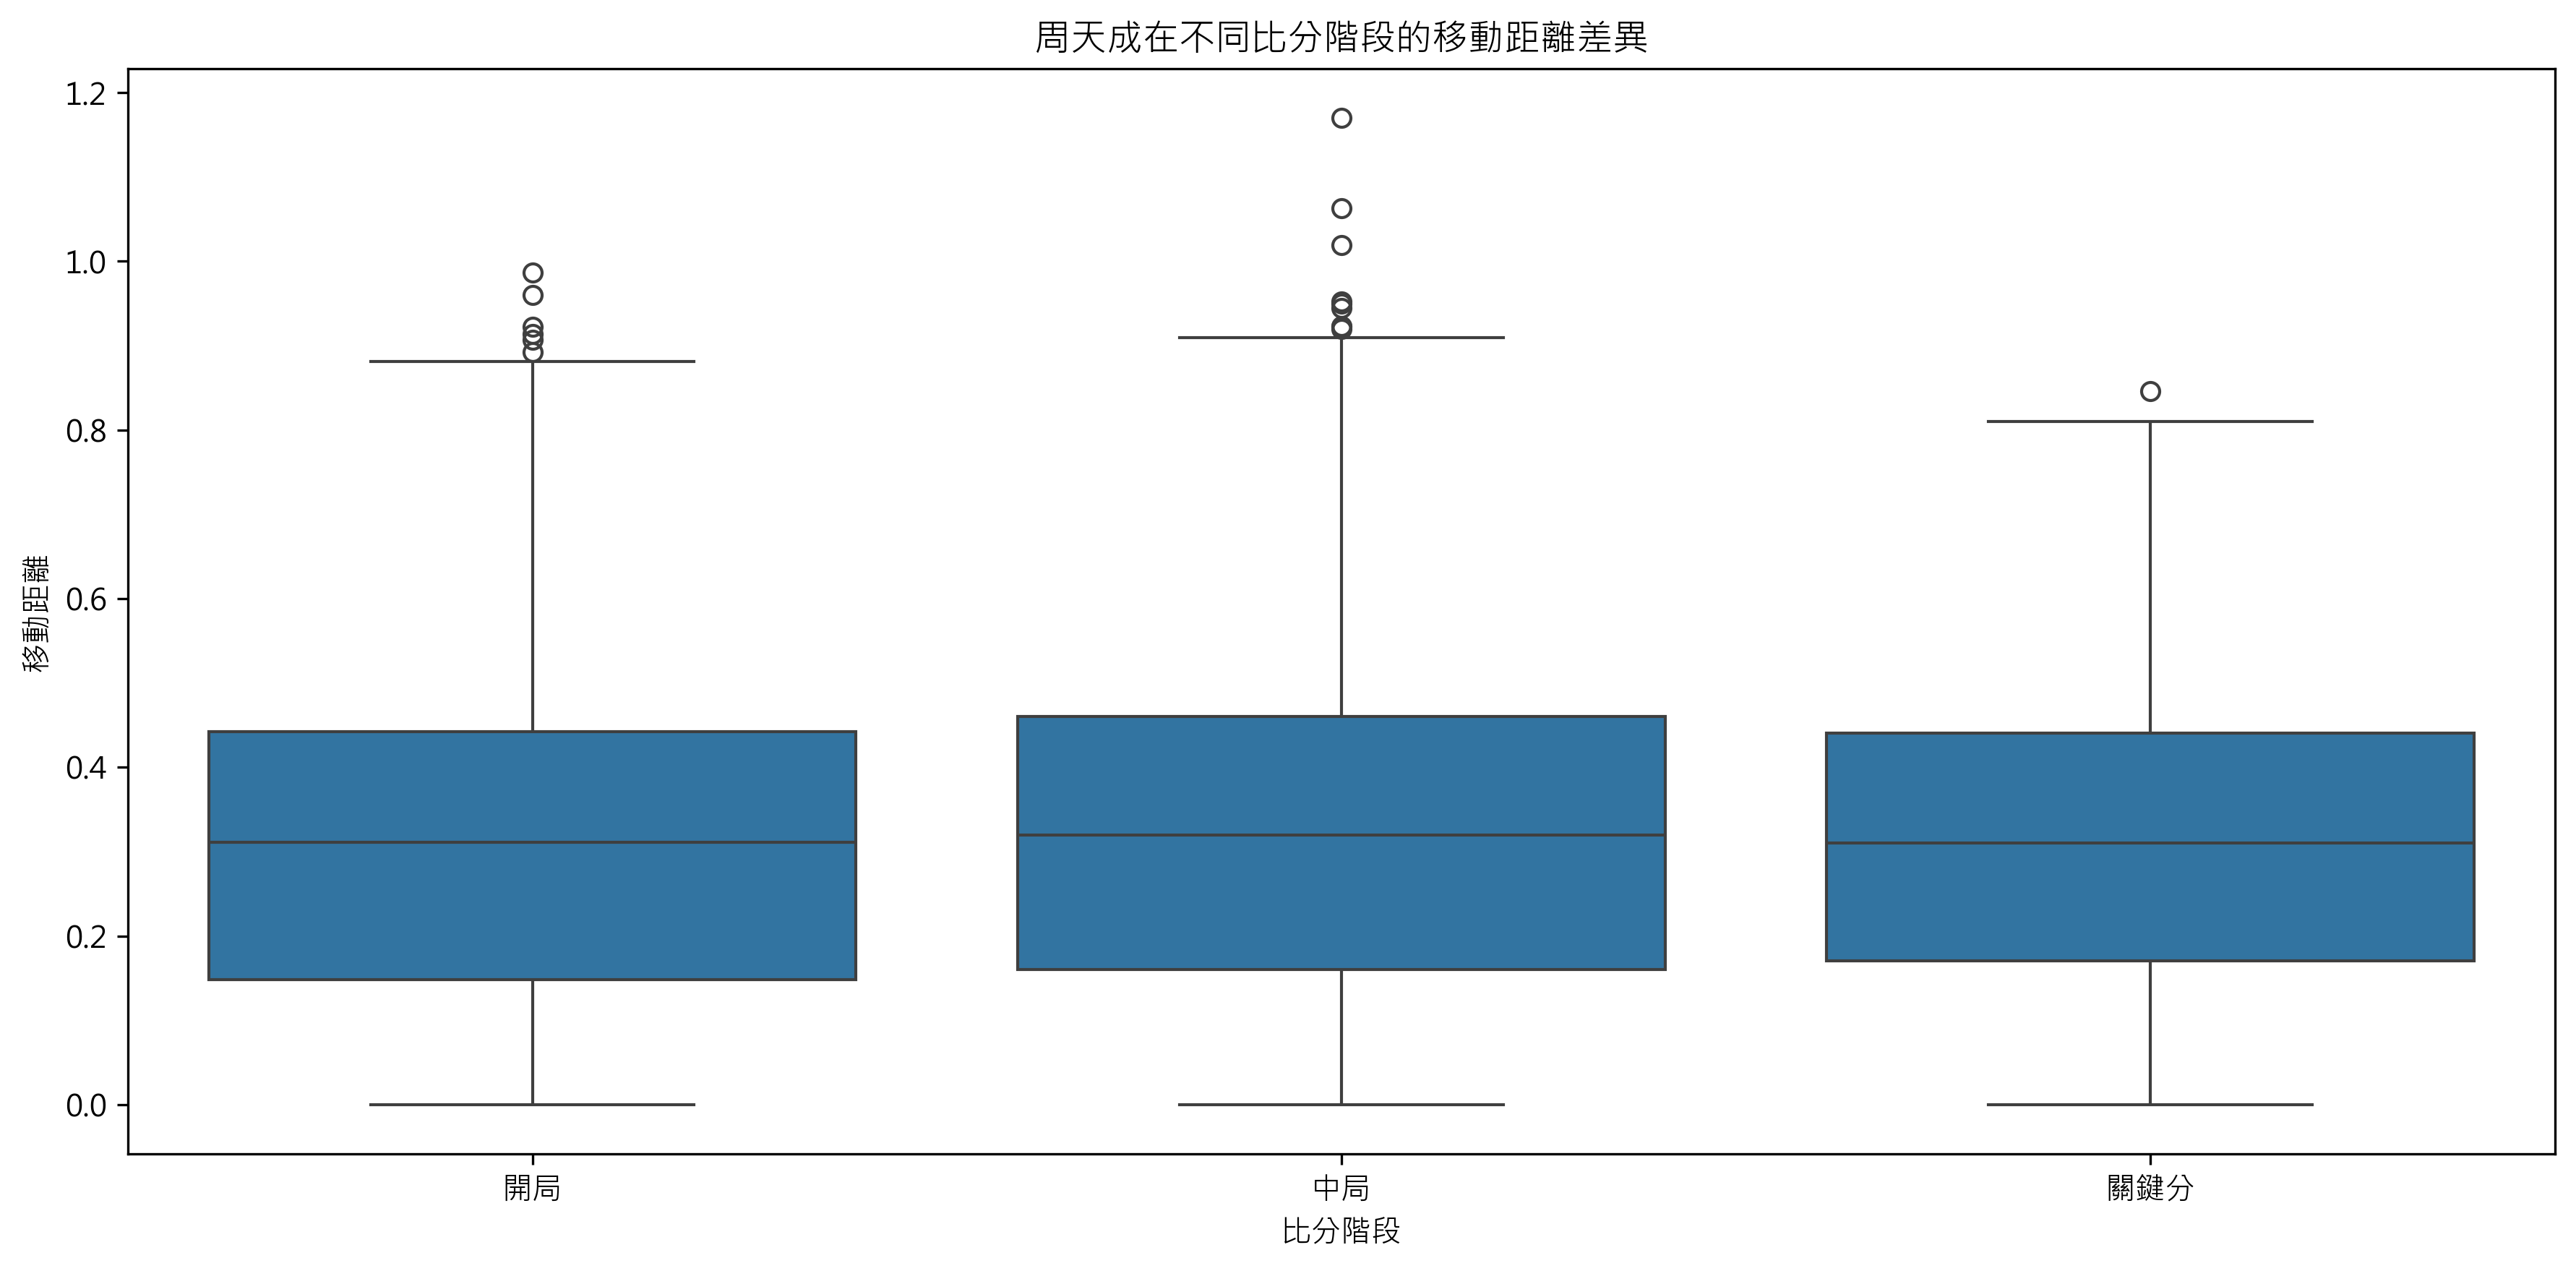

In [ ]:
import numpy as np

# Step 1: 確認數據量和完整性
if len(df) == 0:
    print("數據為空，無法執行分析。")
else:
    # Step 2: 計算移動距離
    df['player_movement_distance'] = np.sqrt(df['player_move_x']**2 + df['player_move_y']**2)
    
    # Step 3: 分段比分，新增一個欄位來表示比分階段
    conditions = [
        (df['CHOU Tien Chen_score'] <= 4),  # 開局
        (df['CHOU Tien Chen_score'] >= 5) & (df['CHOU Tien Chen_score'] <= 17),  # 中局
        (df['CHOU Tien Chen_score'] >= 18)  # 關鍵分
    ]
    choices = ['開局', '中局', '關鍵分']
    df['score_phase'] = np.select(conditions, choices, default='未知')
    
    # Step 4: 篩選出周天成的數據
    df_chou = df[df['player'] == 'CHOU Tien Chen']

    # Step 5: 分析每個階段
    movement_by_phase = df_chou.groupby('score_phase')['player_movement_distance'].describe()

    # Step 6: 計算平均移動距離
    mean_movement_by_phase = df_chou.groupby('score_phase')['player_movement_distance'].mean()
    
    # 7. 計算幾個階段的移動距離統計資料
    print("移動距離的描述統計數據（依比分階段劃分）：")
    print(movement_by_phase)
    
    # Step 7: 視覺化
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_chou, x='score_phase', y='player_movement_distance')
    plt.title('周天成在不同比分階段的移動距離差異')
    plt.xlabel('比分階段')
    plt.ylabel('移動距離')
    plt.tight_layout()
    plt.show()
    
    # 打印平均移動距離
    print("不同比分階段的平均移動距離：")
    print(mean_movement_by_phase)


### 數據洞察
從數據中，我們可以看到周天成在不同比分階段的移動距離略有差異。開局階段的平均移動距離為0.315125，中局階段略高為0.324373，而關鍵分階段則為0.315683。

這些數據顯示，周天成在中局階段的移動距離稍微增加，這可能是因為中局階段比賽節奏加快，對手可能會嘗試更多變化，迫使周天成進行更多的場地覆蓋。而在開局和關鍵分階段，移動距離相對較小，這可能反映了他在這些階段更專注於穩定性和控制比賽節奏。

總體來看，周天成在不同比分階段的移動距離變化不大，顯示出他在比賽中的一致性和穩定性。這種穩定性是他在高壓比賽中能夠保持競爭力的重要因素。教練可以利用這些數據，進一步優化他的戰術安排，特別是在中局階段，可能需要加強對手變化球的應對策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在比分階段的分段上與 Reference Code 不一致。Reference Code 將比分階段分為 '開局 (0-4分)', '中局 (5-17分)', '關鍵分 (18分以上)'，而候選程式碼將比分階段分為 '開局', '中局', '關鍵分'，並且在條件上使用了 <= 和 >=，這可能導致比分階段的劃分不準確。此外，候選程式碼在計算移動距離時使用了 'player_movement_distance'，而 Reference Code 使用了 'move_distance'，這雖然是變數命名的不同，但在分段不一致的情況下，這可能影響最終的分析結果。因此，候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 19
**問題**: 當周天成打擊出界時，劃出站點的散佈圖?
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_location`


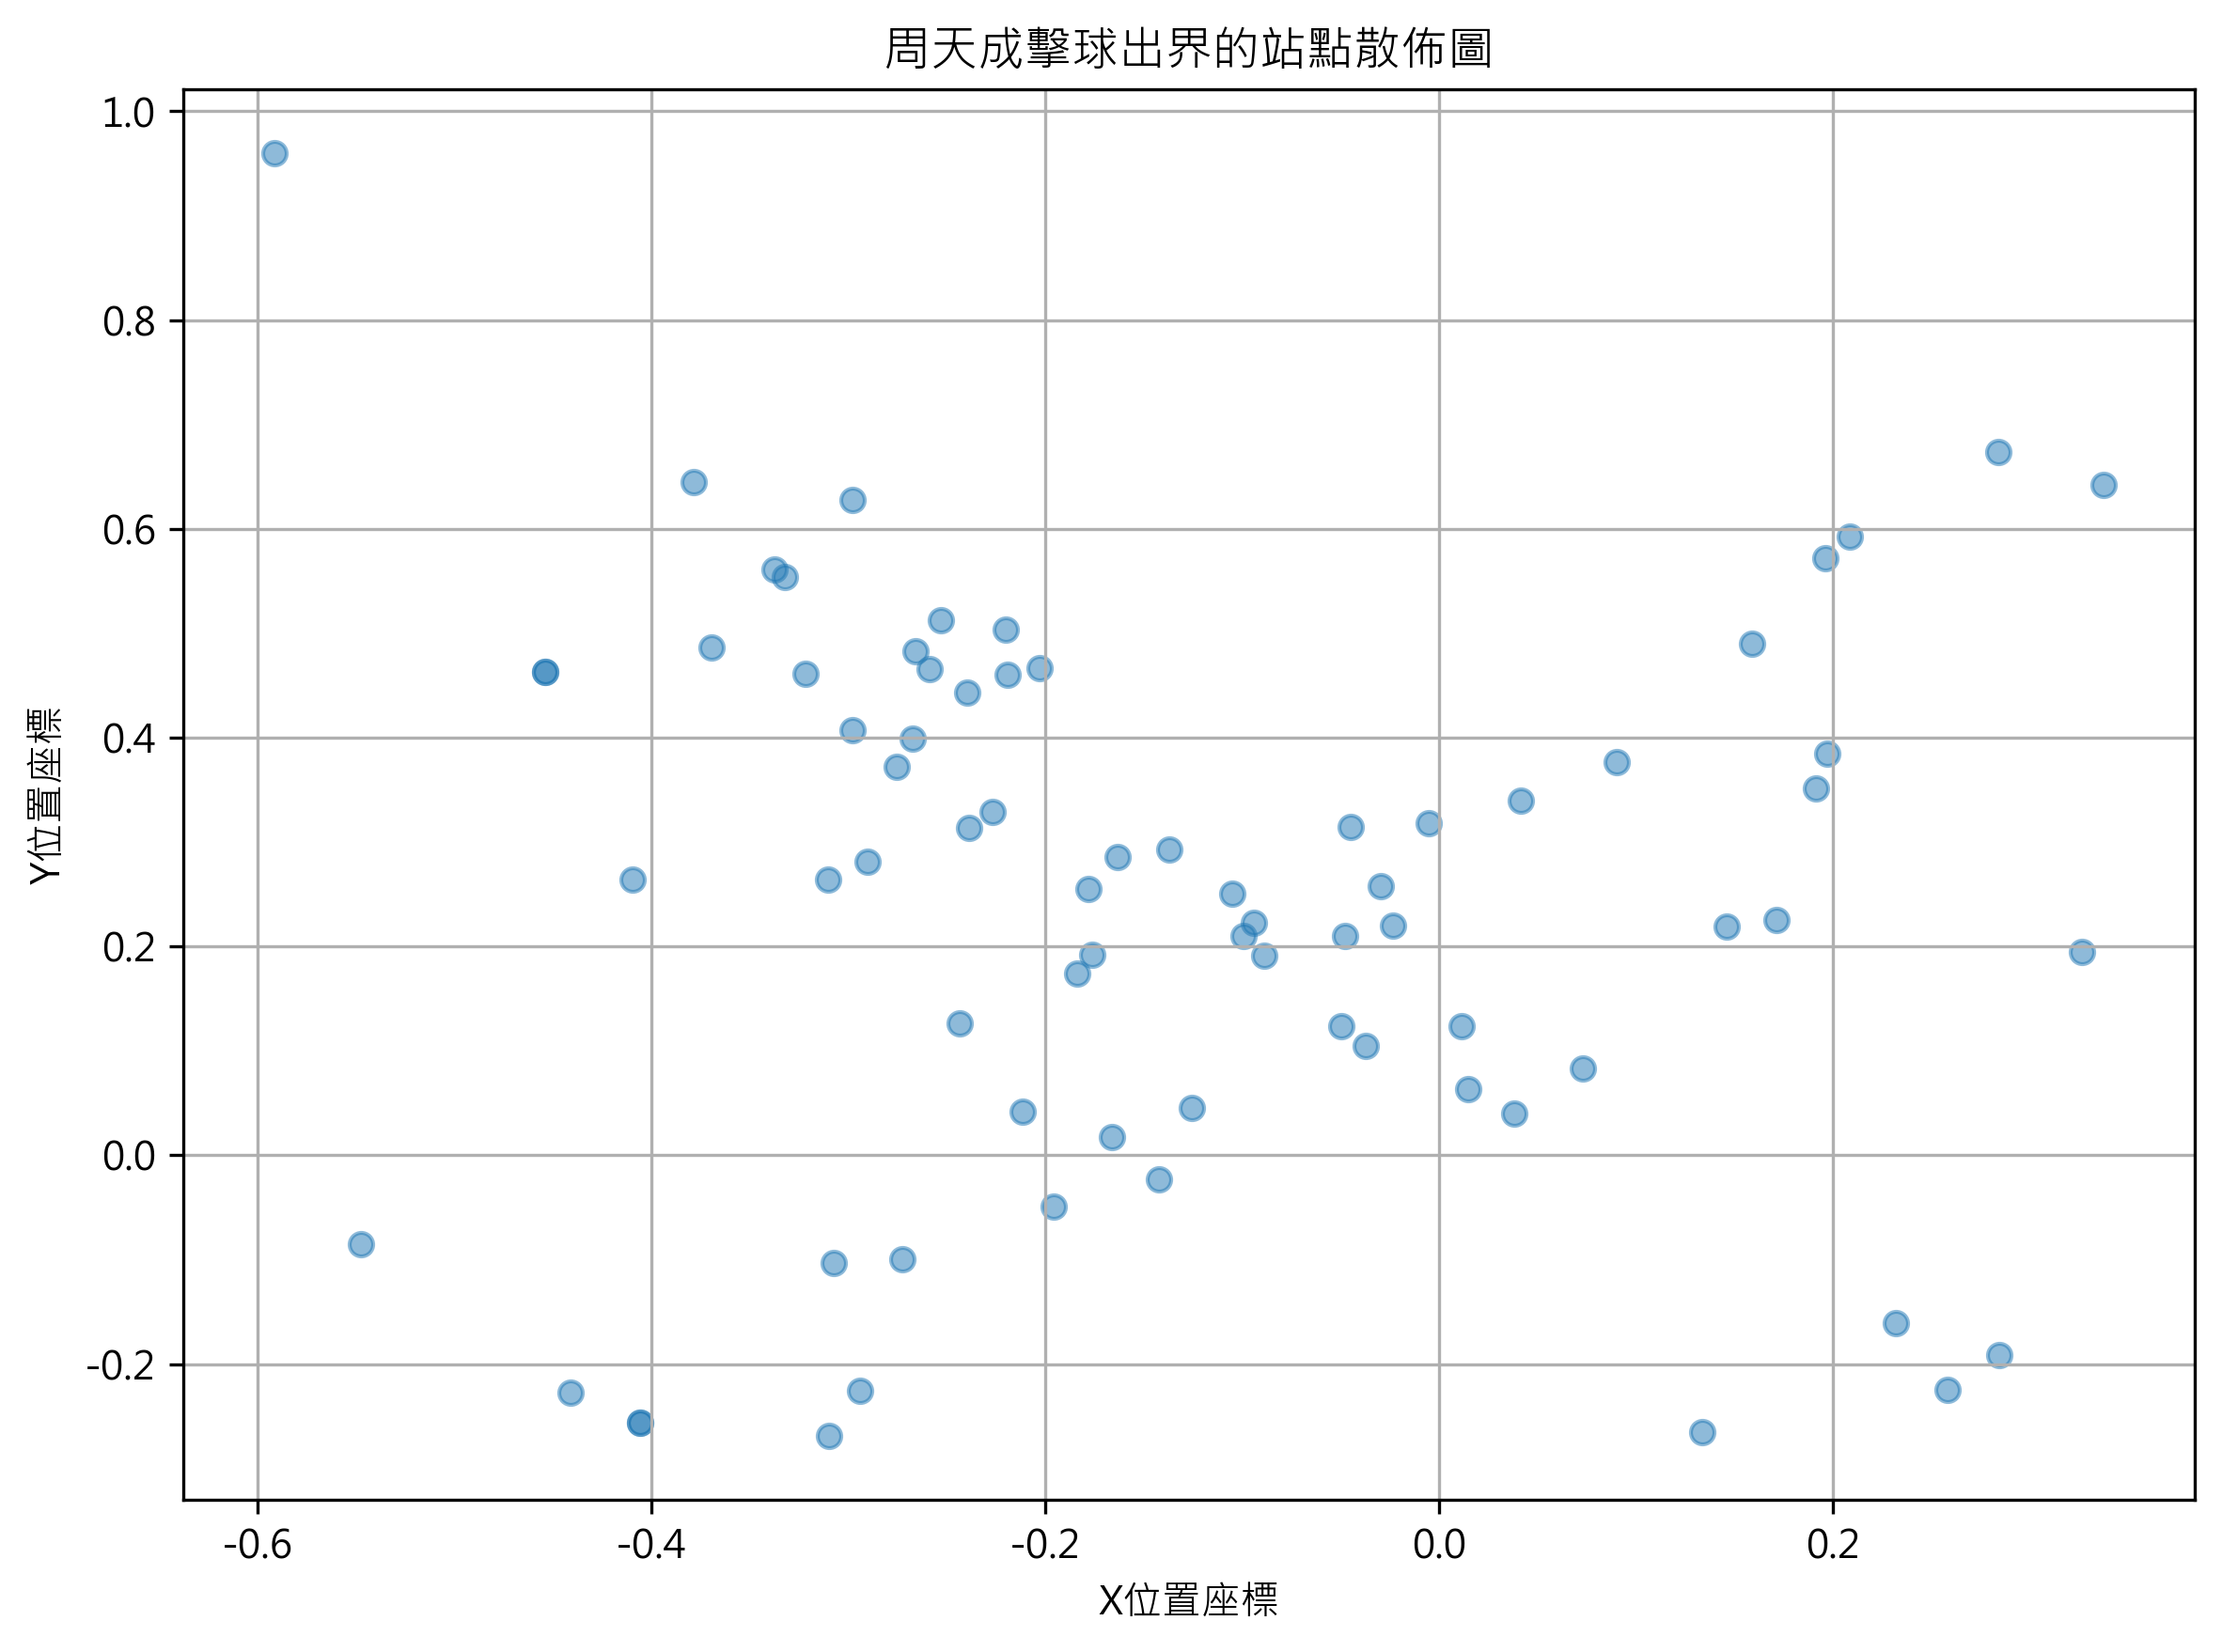

In [ ]:
# 確保 DataFrame 不為空
if len(df) > 0:
    # 過濾周天成打出界的數據
    chou_out_of_bounds = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '出界')]
    
    # 確認過濾後數據量
    print(f"周天成打出界的數據量: {len(chou_out_of_bounds)}")

    # 繪製散佈圖
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(chou_out_of_bounds['player_location_x'], chou_out_of_bounds['player_location_y'], alpha=0.5)
    
    # 標記圖表
    ax.set_title('周天成擊球出界的站點散佈圖')
    ax.set_xlabel('X位置座標')
    ax.set_ylabel('Y位置座標')
    ax.grid(True)
    plt.tight_layout()
    
    # 繪圖完成後
    fig
else:
    print("數據框 df 為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在比賽中有74次打擊出界的情況。這些數據已經被視覺化為一個散佈圖，顯示了他在場地上的不同站點位置。

這些出界的打擊可以進一步分析，以了解他在比賽中的弱點或需要改進的地方。若圖表中包含"player_type"或"opponent_type"，則可以根據以下Mapping進行分析：

1. 發短球
2. 發長球
3. 長球
4. 殺球
5. 切球
6. 挑球
7. 平球
8. 網前球
9. 推撲球
10. 接殺防守
11. 接不到

若圖表中包含"area" (landing_area)，則可以根據以下區域進行分析：

| Row/Col | Col A (Left) | Col B (C-Left) | Col C (C-Right) | Col D (Right) |
| :--- | :---: | :---: | :---: | :---: |
| **Row 6 (Front)** | 21 | 22 | 23 | 24 |
| **Row 5 (Front)** | 17 | 18 | 19 | 20 |
| **Row 4 (Mid)** | 13 | 14 | 15 | 16 |
| **Row 3 (Mid)** | 9 | 10 | 11 | 12 |
| **Row 2 (Mid)** | 5 | 6 | 7 | 8 |
| **Row 1 (Back)** | 1 | 2 | 3 | 4 |

這些數字代表了場地的不同區域，通過這些數據，我們可以更精確地了解周天成在哪些特定區域容易出界，並針對這些區域進行針對性的訓練與策略調整。這樣的分析可以幫助他在未來的比賽中減少失誤，提高比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成打擊且失分原因為 '出界' 的記錄，並繪製了站位的散佈圖。分析對象、欄位語意、篩選條件和最終輸出目標都與 Reference Code 1 一致。




## 題號 20
**問題**: 周天成打擊出界失誤，該球的落點分布
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


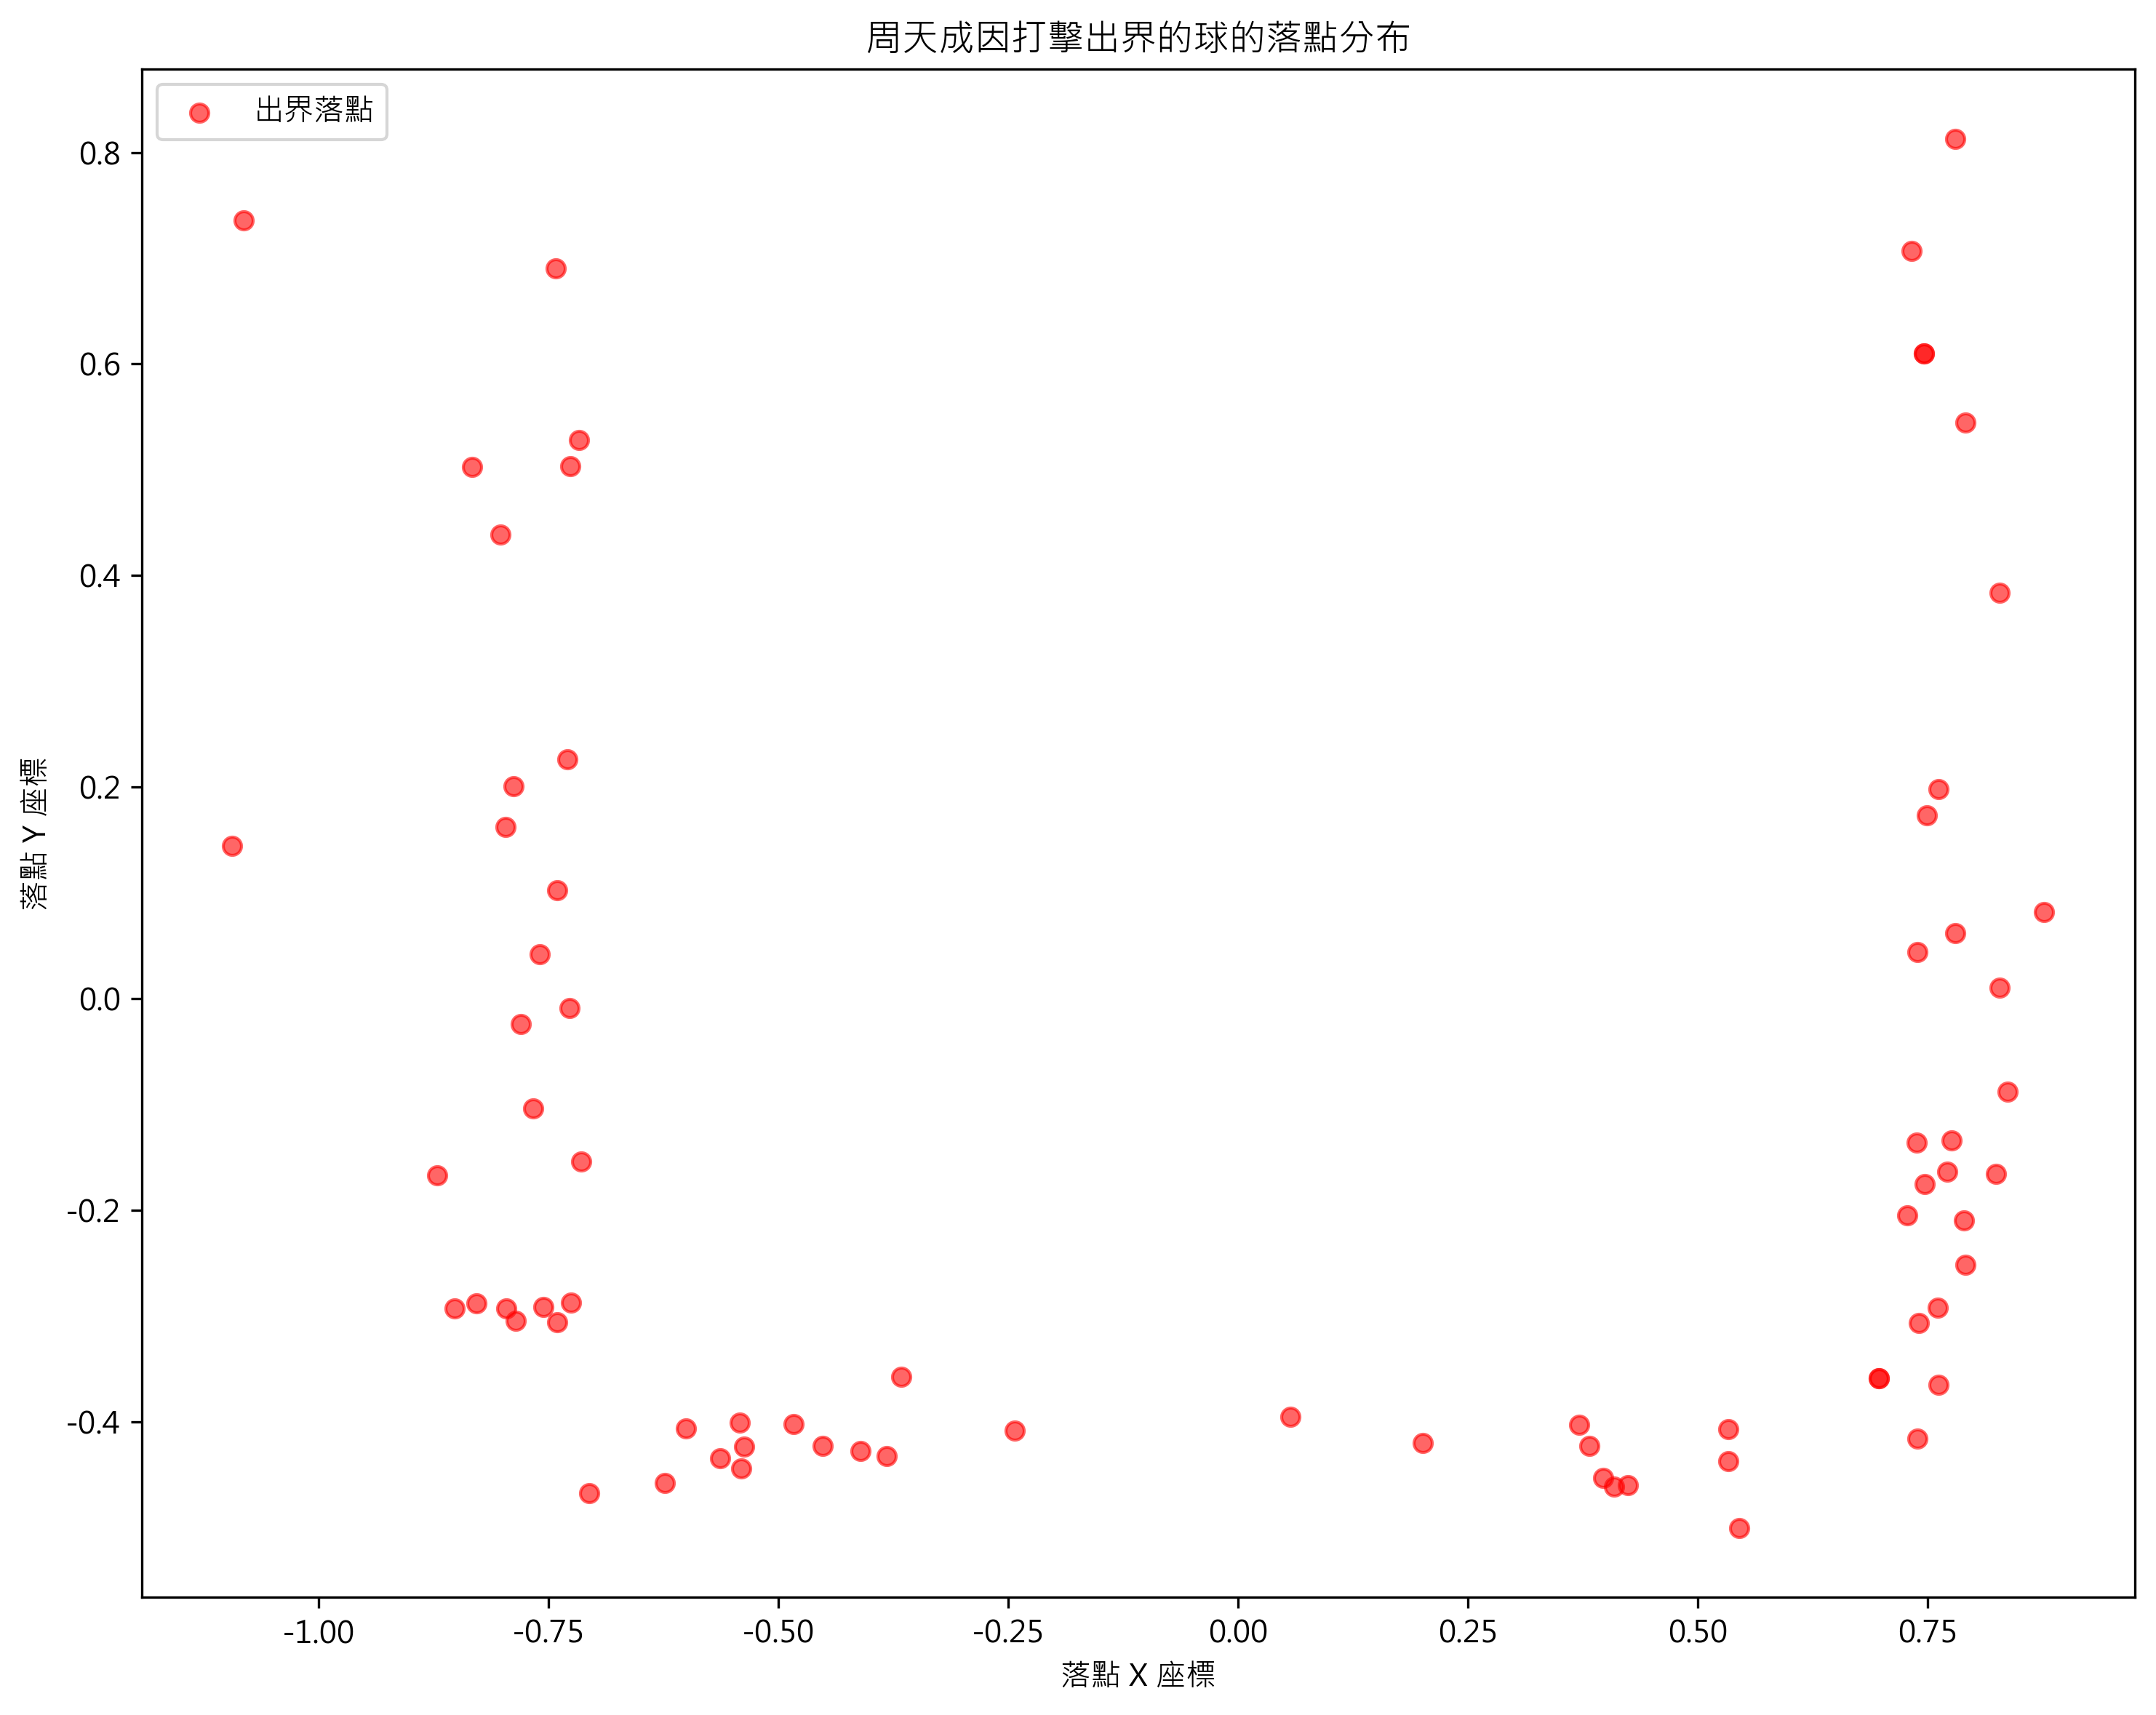

In [ ]:
# 從 DataFrame 篩選出符合條件的列
player_name = "CHOU Tien Chen"
opponent_name = "Kento MOMOTA"

# 確認資料集非空
if len(df) > 0:
    # 選取出現 "出界" 且為 周天成 打擊失誤的資料
    chou_out_balls = df[
        (df['player'] == player_name) &
        (df['lose_reason'] == '出界') &
        (df['getpoint_player'] == opponent_name)
    ]

    # 輸出篩選結果的行數
    print(f"周天成因打擊出界失誤的總數: {len(chou_out_balls)}")

    # 繪製落點分布圖
    if len(chou_out_balls) > 0:
        fig, ax = plt.subplots(figsize=(10, 8))
        sc = ax.scatter(chou_out_balls['landing_x'], chou_out_balls['landing_y'], 
                       c='red', alpha=0.6, label='出界落點')
        ax.set_title("周天成因打擊出界的球的落點分布")
        ax.set_xlabel("落點 X 座標")
        ax.set_ylabel("落點 Y 座標")
        ax.legend()
        plt.tight_layout()
    else:
        print("無符合條件的資料，無法繪圖。")
else:
    print("數據集為空，無法分析。")


### 數據洞察
根據數據分析，周天成在與桃田賢斗的比賽中，因打擊出界而失誤的次數達到74次。我們可以從這些出界失誤的球的落點分布中獲得一些戰術洞察。

落點分布圖中，球的落點主要集中在以下區域：
- **Row 1 (Back)**: 區域1至4，這些位置通常是後場的邊線附近，顯示出周天成在長球或挑球時出界的風險較高。
- **Row 6 (Front)**: 區域21至24，這些位置是網前的邊線，表明在發短球或網前球時，精準度不足導致出界。

這些資訊顯示，周天成在後場長球和網前球的控制上需要更精準，特別是在邊線附近的處理上。這可能是由於對手的壓迫或自身的判斷失誤。針對這些失誤，訓練時可以加強落點精準度和邊線球的處理能力，從而減少不必要的失分。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成的出界失誤，並檢查 `getpoint_player` 是否為對手，以確保是因為失誤而失分。然後，它繪製了落點分布圖，這與 Reference Code 1 的目標一致。候選程式碼的分析對象、欄位語意、篩選條件和最終輸出目標都與 Reference Code 1 一致，因此判定為 true。




## 題號 21
**問題**: 在第一場次的比賽中，隨著局數的推進，周天成的「殺球」使用頻率和得分率是否出現了顯著的下滑
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


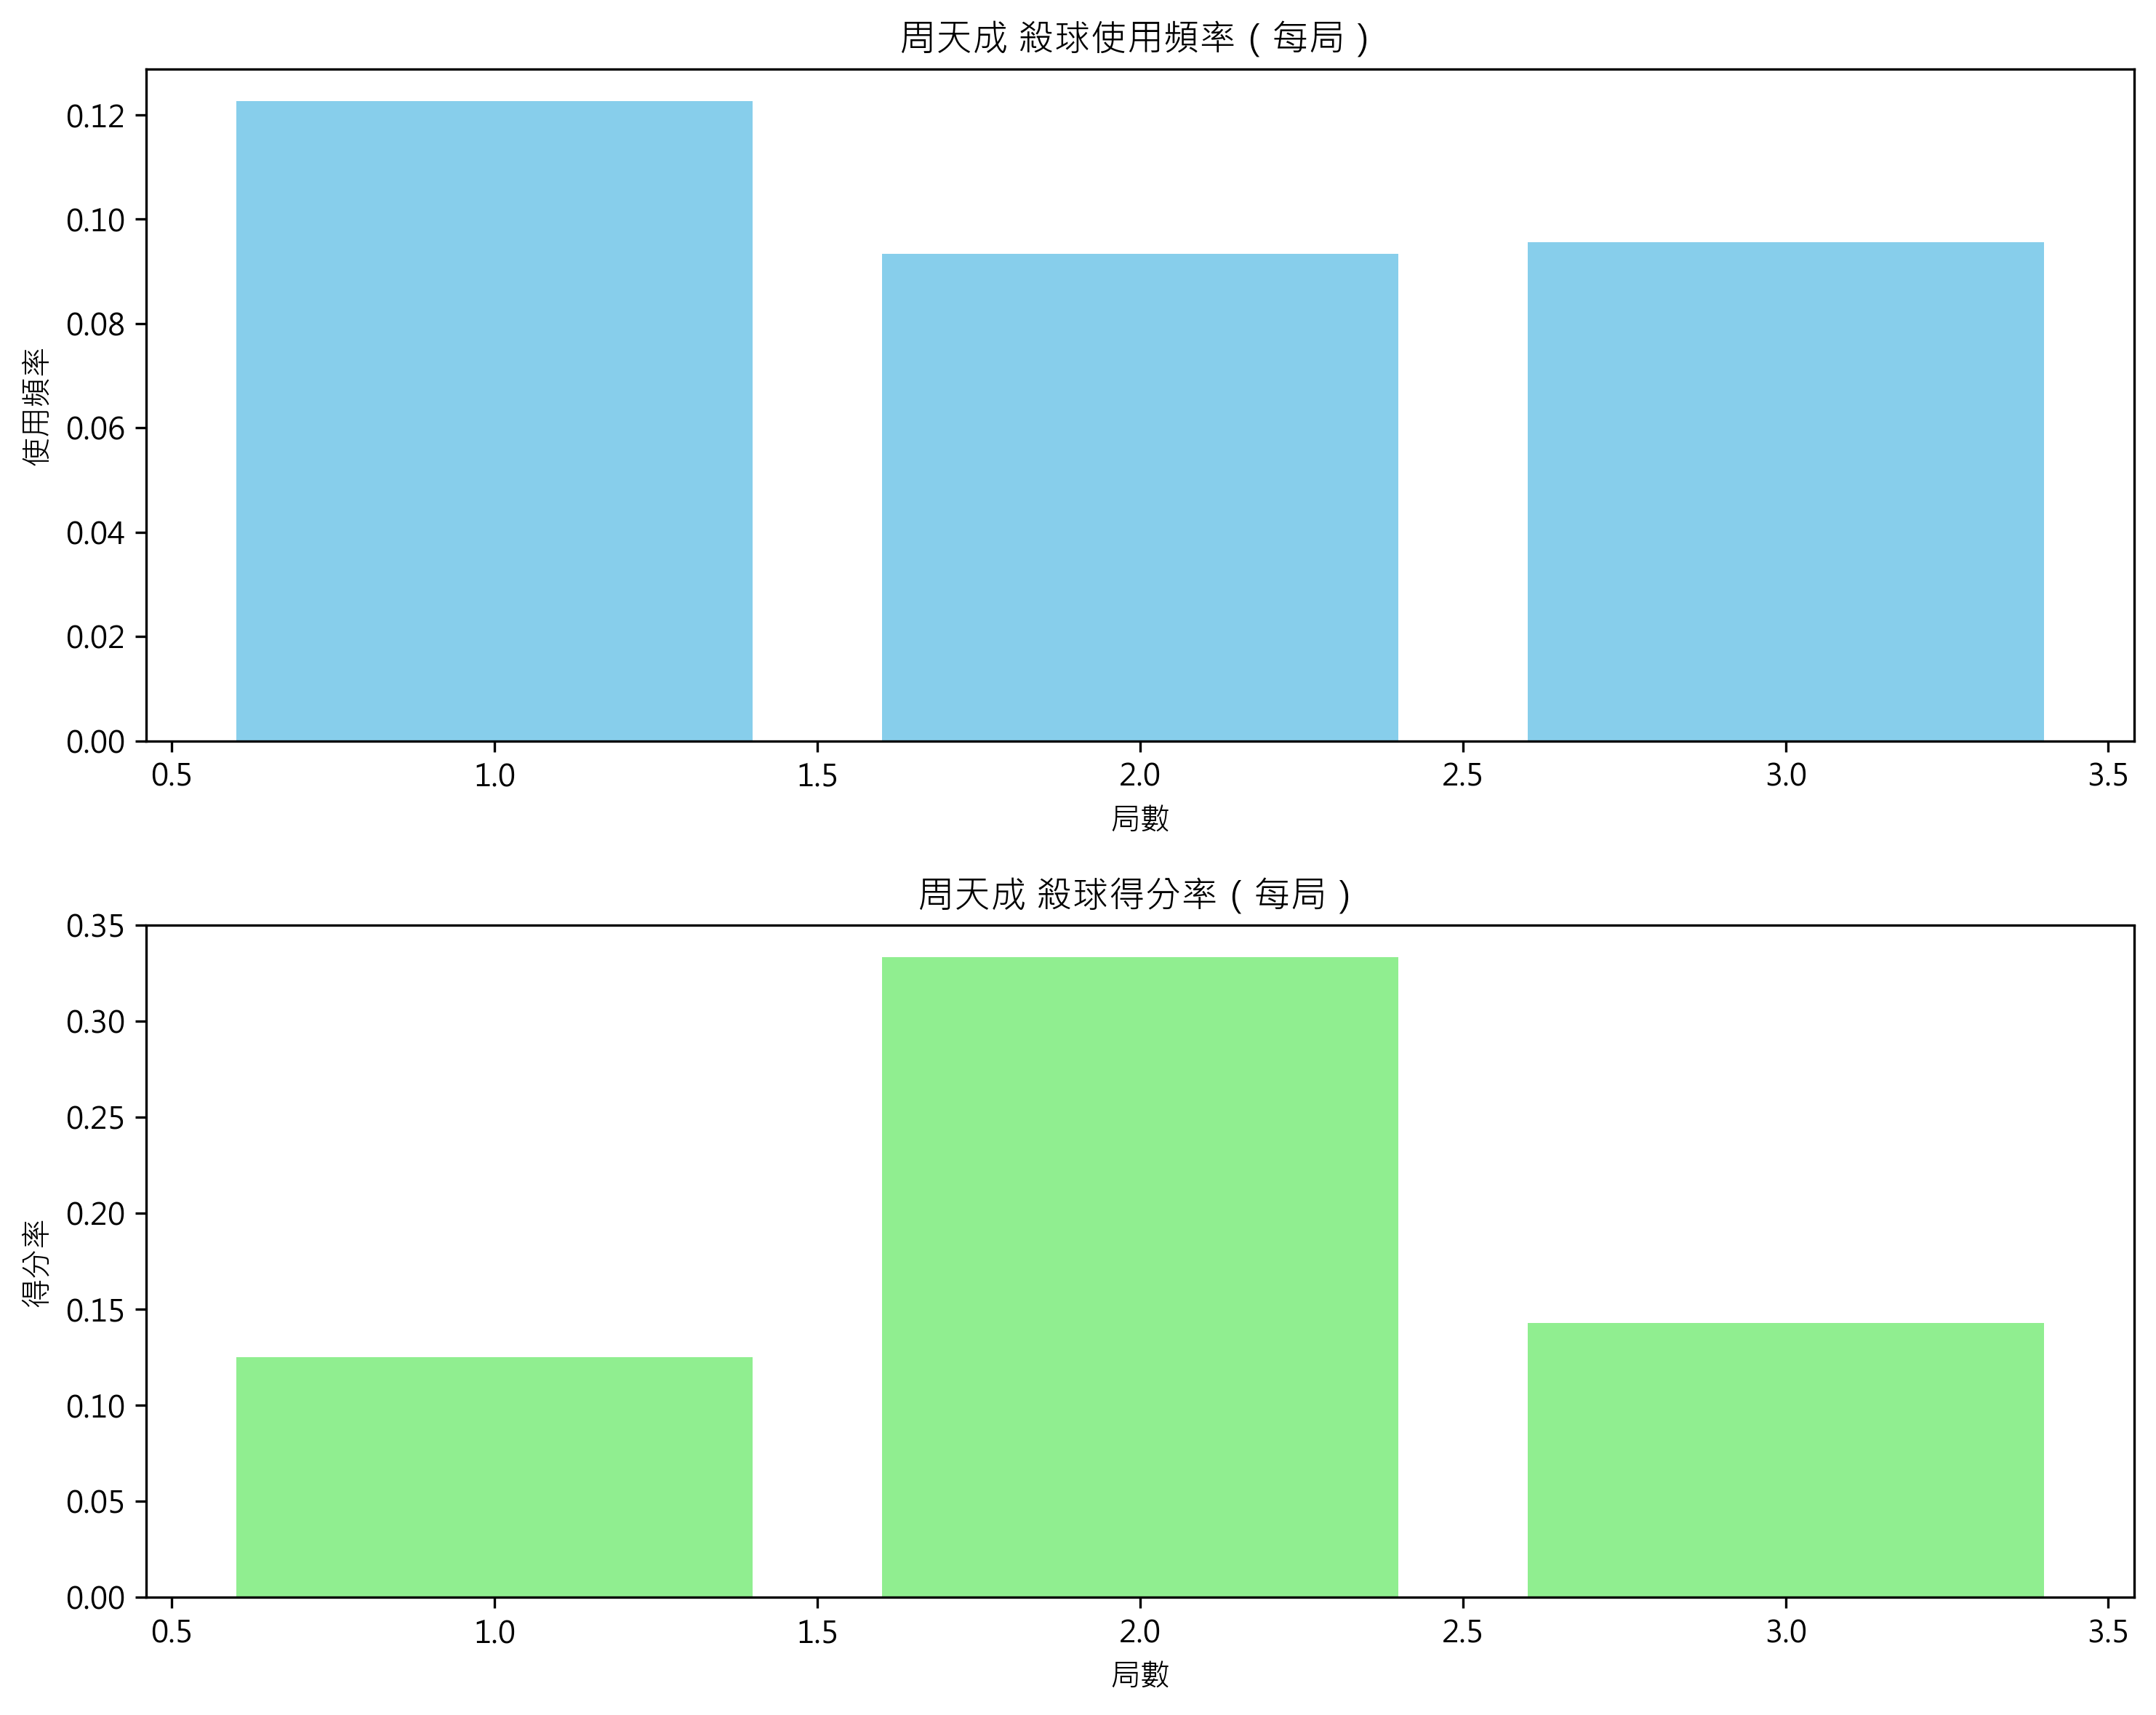

In [ ]:
# 篩選出 match_id 為 1 並 player 為 'CHOU Tien Chen' 的數據
match_df = df[(df['match_id'] == 1) & (df['player'] == 'CHOU Tien Chen')]

# 建立殺球的過濾條件
smash_df = match_df[match_df['type'] == '殺球']

# 使用 groupby 計算每局的殺球使用次數及所有擊球次數
set_total = match_df.groupby('set').size()
set_smash_total = smash_df.groupby('set').size()

# 計算殺球使用頻率
smash_usage_ratio = set_smash_total / set_total

# 計算每局的殺球主動得分次數（主動得分：player == getpoint_player）
smash_active_win = smash_df[smash_df['getpoint_player'] == 'CHOU Tien Chen'].groupby('set').size()

# 計算殺球得分率
smash_score_ratio = smash_active_win / set_smash_total

# 打印出結果
print("周天成在每局的殺球使用頻率如下:")
print(smash_usage_ratio)
print("\n周天成在每局的殺球得分率如下:")
print(smash_score_ratio)

# 分析結果
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# 殺球使用頻率
axes[0].bar(smash_usage_ratio.index, smash_usage_ratio.values, color='skyblue')
axes[0].set_title('周天成 殺球使用頻率（每局）')
axes[0].set_xlabel('局數')
axes[0].set_ylabel('使用頻率')

# 殺球得分率
axes[1].bar(smash_score_ratio.index, smash_score_ratio.values, color='lightgreen')
axes[1].set_title('周天成 殺球得分率（每局）')
axes[1].set_xlabel('局數')
axes[1].set_ylabel('得分率')

plt.tight_layout()

# 注意：要確保不會有division by zero的錯誤，因此檢查分母不為零


### 數據洞察
從數據中可以觀察到周天成在第一場比賽中，隨著局數的推進，他的殺球使用頻率從第一局的0.122605下降到第二局的0.093333，並在第三局微幅回升至0.095563。然而，值得注意的是，儘管使用頻率略有下降，他的殺球得分率在第二局顯著提高至0.333333，這表明他在這一局的殺球效率極高。第三局得分率則回落至0.142857。

這些數據顯示，周天成在第二局可能採取了更精確的殺球策略，選擇更有把握的時機來進行殺球，因此得分率提升。第三局的得分率回落可能是對手進行了有效的防守調整，或是周天成的體能和專注度有所下降。總體來看，雖然殺球使用頻率略有下降，但在第二局的高得分率顯示出他在戰術選擇上的靈活性。這提醒我們，在比賽中不僅要關注攻擊的頻率，更要注重攻擊的質量與時機選擇。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了第一場比賽中周天成的數據，並計算了每局的殺球使用頻率和得分率。分析對象、欄位語意、篩選條件、分組層級和統計口徑都與 Reference Code 1 一致，最終輸出目標也正確地回答了題目要求。




## 題號 22 (*)
**問題**: 分析周天成在不同比分階段(開局:0-4分,中局:5-17分,關鍵分:18分以上)中，使用不同球種的頻率變化趨勢
> **使用的資料欄位群組**: `game_structure, shot_type`


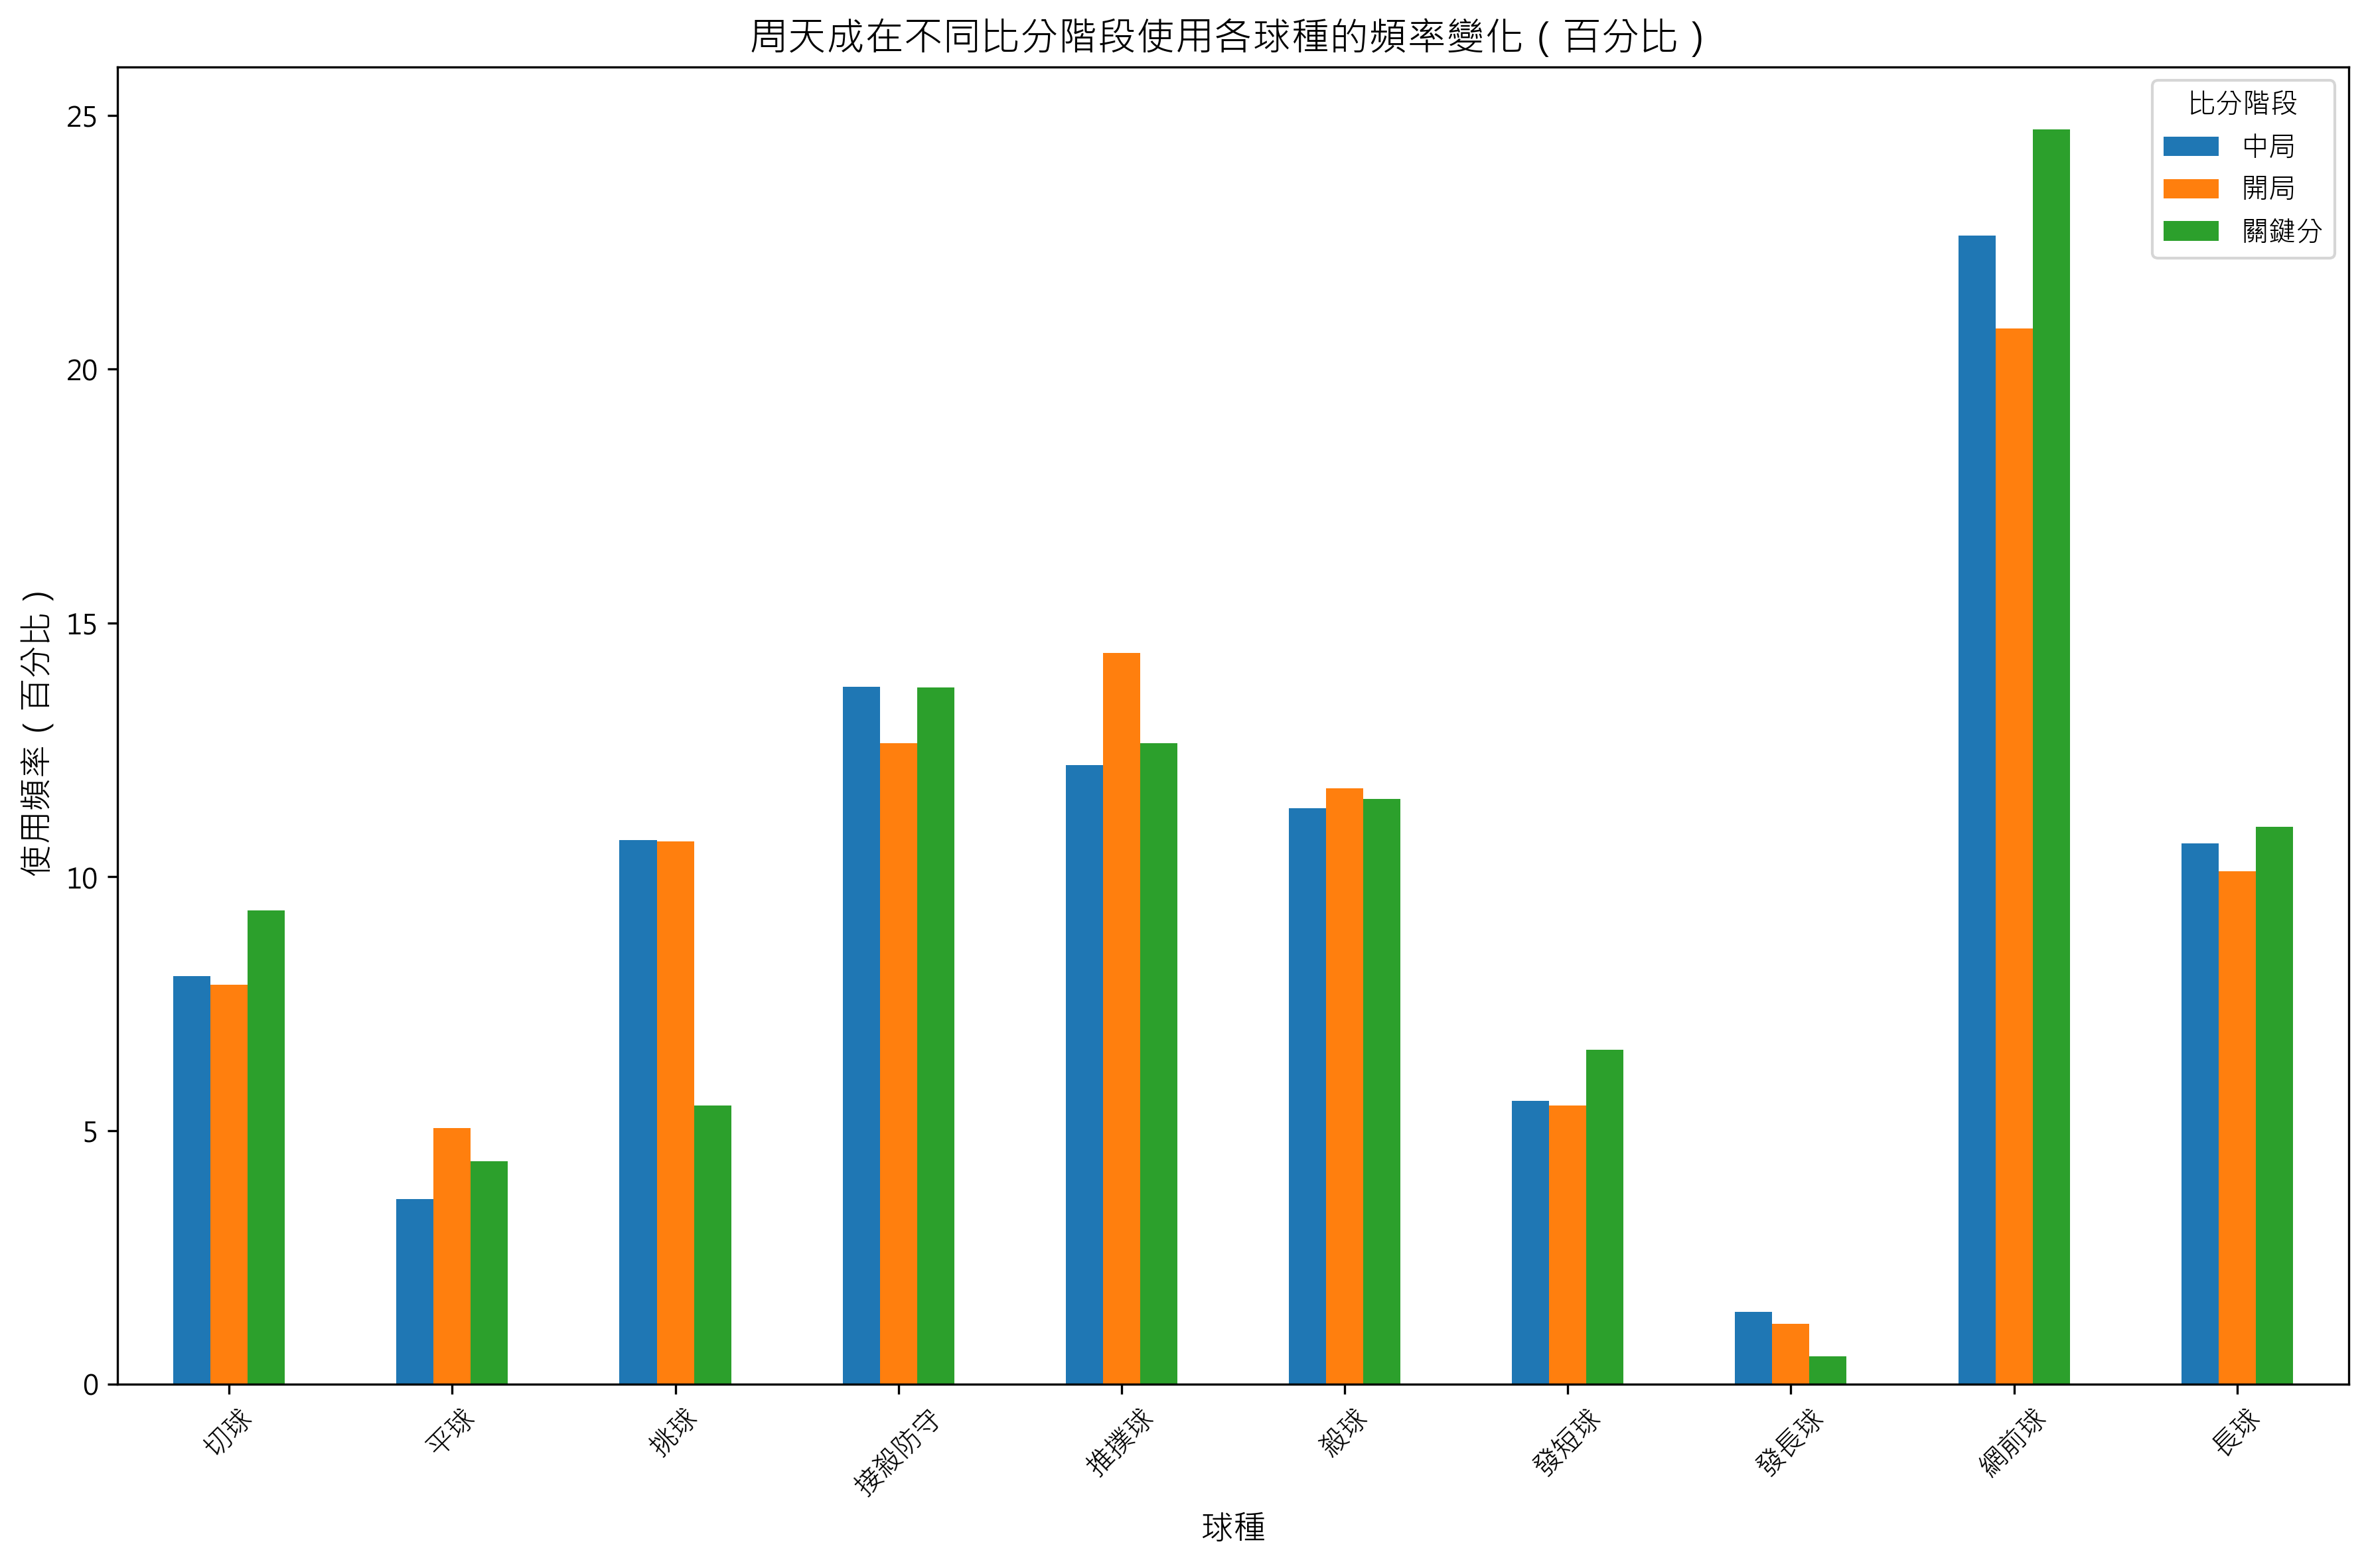

In [ ]:
# 驗證數據是否存在
if len(df) > 0:
    # 過濾出周天成的數據
    chou_tien_chen_df = df[df['player'] == 'CHOU Tien Chen'].copy()

    # 定義比分階段
    def score_stage(score):
        if score <= 4:
            return '開局'
        elif 5 <= score <= 17:
            return '中局'
        else:
            return '關鍵分'

    # 新增「比分階段」欄位
    chou_tien_chen_df['score_stage'] = chou_tien_chen_df['CHOU Tien Chen_score'].apply(score_stage)

    # 計算不同比分階段，各球種的使用頻率
    ball_types_freq = chou_tien_chen_df.groupby('score_stage')['type'].value_counts(normalize=True).unstack().fillna(0) * 100

    # 打印計算出的頻率變化結果
    print("周天成在不同比分階段使用各球種的頻率變化（百分比）:")
    print(ball_types_freq)

    # 繪圖
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ball_types_freq.T.plot(kind='bar', ax=ax)
    plt.title('周天成在不同比分階段使用各球種的頻率變化（百分比）', fontsize=14)
    plt.xlabel('球種', fontsize=12)
    plt.ylabel('使用頻率（百分比）', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='比分階段')
    plt.tight_layout()

# 最後輸出頻率計算結果和圖表
ball_types_freq, fig


### 數據洞察
在分析周天成於不同比分階段的球種使用頻率時，我們可以觀察到以下趨勢：

1. **開局階段 (0-4分)**：
   - 周天成在開局階段較為保守，切球和挑球的使用頻率分別為7.88%和10.70%，顯示出他在開局時傾向於保持穩定，避免過多風險。
   - 平球的使用頻率較高，達到5.05%，這可能是為了控制節奏並探測對手的弱點。

2. **中局階段 (5-17分)**：
   - 在中局階段，挑球使用頻率略微增加至10.72%，顯示出他在中局時更積極地嘗試拉開對手。
   - 網前球的使用頻率顯著上升到22.63%，這表明他在中局階段更加專注於進攻，試圖在網前施壓。

3. **關鍵分階段 (18分以上)**：
   - 關鍵分階段，切球的使用頻率增加至9.34%，顯示出他在關鍵時刻更傾向於使用切球來控制節奏和增加變化。
   - 挑球的使用頻率下降至5.49%，這可能反映出他在關鍵時刻更注重穩定性，避免過多的長球交換。

總體來看，周天成在不同比分階段的球種選擇顯示出他在比賽中的策略調整：開局時保持穩定，中局時增加進攻性，關鍵分時則更加謹慎和精確。這種策略的變化有助於他在比賽中保持競爭力並適應不同的比賽情境。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在比分階段的定義上與 Reference Code 不一致。Reference Code 將比分階段定義為開局 (0-4分)、中局 (5-17分)、關鍵分 (18分以上)，而候選程式碼將開局定義為 0-4 分，中局為 5-17 分，關鍵分為 18 分以上。這導致比分階段的劃分不一致。此外，候選程式碼在計算使用頻率時，使用了 value_counts(normalize=True) 來計算百分比，這與 Reference Code 的計算方式不同，可能導致統計口徑的差異。




## 題號 23
**問題**: 在關鍵分(18分以上)時，周天成採用的擊球策略與其他階段有何不同？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


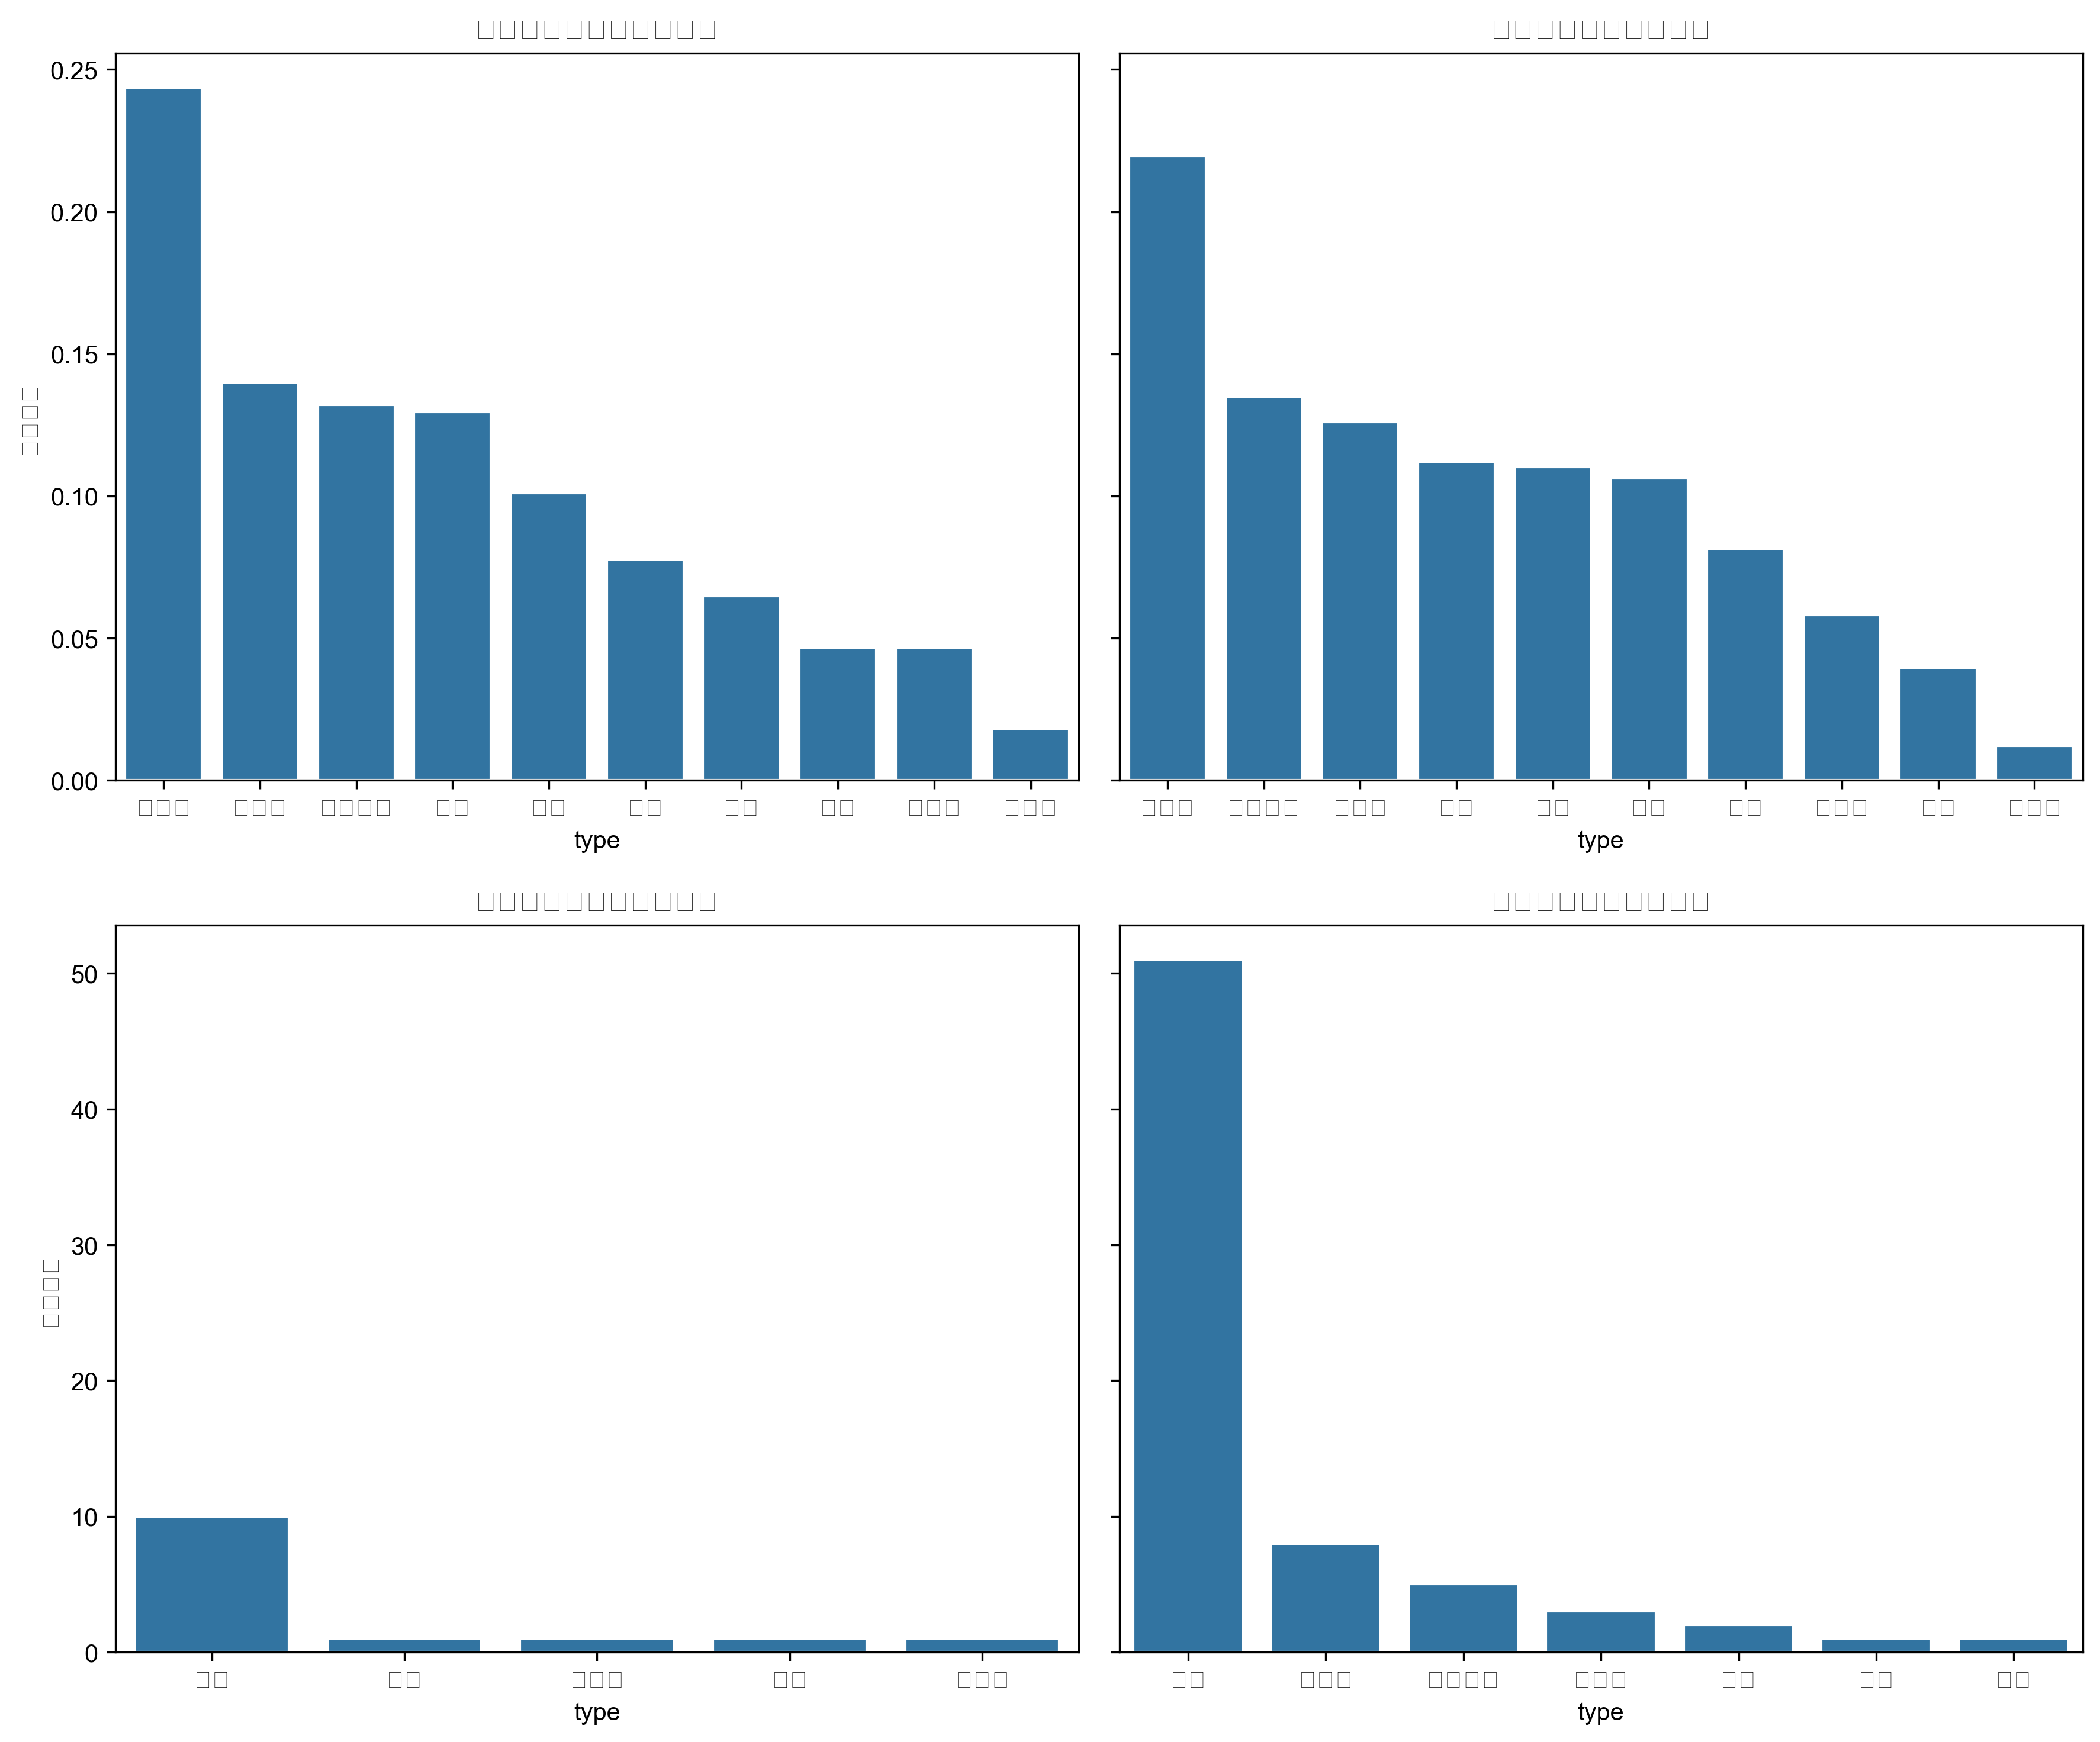

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 確保數據量足夠
if len(df) > 0:
    # 關鍵分階段的條件
    is_critical_phase = (df['CHOU Tien Chen_score'] >= 18) | (df['Kento MOMOTA_score'] >= 18)

    # 篩選數據
    critical_phase_df = df[is_critical_phase]
    other_phase_df = df[~is_critical_phase]
    
    print(f"關鍵分階段數據量: {len(critical_phase_df)}")
    print(f"其他階段數據量: {len(other_phase_df)}")

    # 球種使用頻率
    critical_phase_shots = critical_phase_df[critical_phase_df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)
    other_phase_shots = other_phase_df[other_phase_df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

    print("關鍵分階段球種使用頻率:")
    print(critical_phase_shots)
    print("\n其他階段球種使用頻率:")
    print(other_phase_shots)

    # 主動得分篩選條件
    active_win_critical = critical_phase_df[(critical_phase_df['player'] == 'CHOU Tien Chen') & 
                                            (critical_phase_df['getpoint_player'] == 'CHOU Tien Chen')]
    active_win_other = other_phase_df[(other_phase_df['player'] == 'CHOU Tien Chen') & 
                                      (other_phase_df['getpoint_player'] == 'CHOU Tien Chen')]

    # 計算主動得分情況
    critical_active_win_count = active_win_critical['type'].value_counts()
    other_active_win_count = active_win_other['type'].value_counts()

    print("關鍵分階段主動得分情況:")
    print(critical_active_win_count)
    print("\n其他階段主動得分情況:")
    print(other_active_win_count)

    # 設定圖形風格
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey='row')
    sns.set(style="whitegrid")

    # 球種使用頻率條形圖
    sns.barplot(x=critical_phase_shots.index, y=critical_phase_shots.values, ax=axes[0, 0])
    axes[0, 0].set_title('關鍵分階段球種使用頻率')
    axes[0, 0].set_ylabel('使用頻率')

    sns.barplot(x=other_phase_shots.index, y=other_phase_shots.values, ax=axes[0, 1])
    axes[0, 1].set_title('其他階段球種使用頻率')
    axes[0, 1].set_ylabel('使用頻率')

    # 主動得分條形圖
    sns.barplot(x=critical_active_win_count.index, y=critical_active_win_count.values, ax=axes[1, 0])
    axes[1, 0].set_title('關鍵分階段主動得分情況')
    axes[1, 0].set_ylabel('得分次數')

    sns.barplot(x=other_active_win_count.index, y=other_active_win_count.values, ax=axes[1, 1])
    axes[1, 1].set_title('其他階段主動得分情況')
    axes[1, 1].set_ylabel('得分次數')

    plt.tight_layout()
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
在關鍵分階段，周天成更頻繁地使用網前球和推撲球，相較於其他階段，這些球種的使用頻率分別增加了約2.4%和1.4%。這顯示他在緊張時刻更傾向於控制網前，可能是為了增加對手的壓力和創造進攻機會。

殺球在關鍵分階段仍然是他的主要得分手段，佔據了大部分的主動得分。這表明他在關鍵時刻依賴於攻擊性強的球種來結束回合。然而，他在其他階段的殺球得分比例更高，這可能意味著他在關鍵分時更謹慎地選擇進攻時機。

此外，挑球的使用頻率在關鍵分階段顯著下降，這可能是因為挑球通常是防守性策略，而周天成在關鍵時刻更傾向於主動進攻。

總結來說，周天成在關鍵分階段更注重網前控制與進攻性擊球，這樣的策略可能是為了在壓力下保持主動權並迅速結束回合。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地將比分分為關鍵分階段和其他階段，並分析了周天成在這兩個階段的擊球策略，包括球種使用頻率和主動得分情況。候選程式碼使用了正確的欄位和篩選條件，並且在統計口徑上與 Reference Code 1 一致，最終輸出目標也是比較不同階段的策略差異。




## 題號 24 (*)
**問題**: 周天成在長回合相較於短回合較常失誤的球種?
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確保資料存在
if len(df) > 0:
    # 計算每個撥球中的最大拍數以確定回合長度
    rally_stats = df.groupby(['match_id', 'set', 'rally'])['ball_round'].max().reset_index()
    
    # 定義長回合與短回合的閾值，假如我們設 10 為分界
    threshold = 10
    
    # 將rally_stats中長短回合的結果加入到原始資料中
    df = pd.merge(df, rally_stats, on=['match_id', 'set', 'rally'], suffixes=('', '_rally_max'))
    
    # 篩選出周天成的失誤資料 (失誤: player是周天成且getpoint_player不是周天成且有lose_reason)
    choutienchen_mistakes = df[(df['player'] == 'CHOU Tien Chen') & 
                               (df['getpoint_player'] != 'CHOU Tien Chen') & 
                               (df['lose_reason'].notna())]
    
    # 分成長回合和短回合
    long_rallies = choutienchen_mistakes[choutienchen_mistakes['ball_round_rally_max'] > threshold]
    short_rallies = choutienchen_mistakes[choutienchen_mistakes['ball_round_rally_max'] <= threshold]
    
    # 統計長回合中失誤最多的球種
    long_most_errors = long_rallies['type'].value_counts().idxmax()
    
    # 統計短回合中失誤最多的球種
    short_most_errors = short_rallies['type'].value_counts().idxmax()
 
    # 打印結果
    print(f"在長回合中，周天成失誤最多的球種是：{long_most_errors}")
    print(f"在短回合中，周天成失誤最多的球種是：{short_most_errors}")
else:
    print("資料集中沒有資料可供分析。")


### 數據洞察
根據數據分析，周天成在長回合中失誤最多的球種是網前球，而在短回合中則是接殺防守。這意味著在長回合中，周天成在處理網前球時容易出現失誤，這可能是因為對手在長時間的來回中，成功將他逼到網前，增加了他的壓力和失誤機率。

在短回合中，接殺防守成為他的主要失誤來源，顯示他可能在應對對手的快速攻擊時，反應或防守策略上存在不足。這些洞察提供了一個清晰的方向，讓我們可以針對這些特定的技術環節進行訓練和改進，提升他的場上表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 是基於每個 rally 的最後一拍來計算失誤率，而候選程式碼直接在逐拍資料上篩選失誤，並分別計算長短回合的失誤最多球種，這導致統計口徑錯誤。候選程式碼沒有正確對齊每個 rally 的最終狀態，且可能將同一個 rally 的不同拍分別計入長短回合，這是明顯的統計口徑錯誤。




## 題號 25 (*)
**問題**: 當對手靠球場兩側時，周天成較常讓球落點到哪些區域？繪製熱區圖。
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


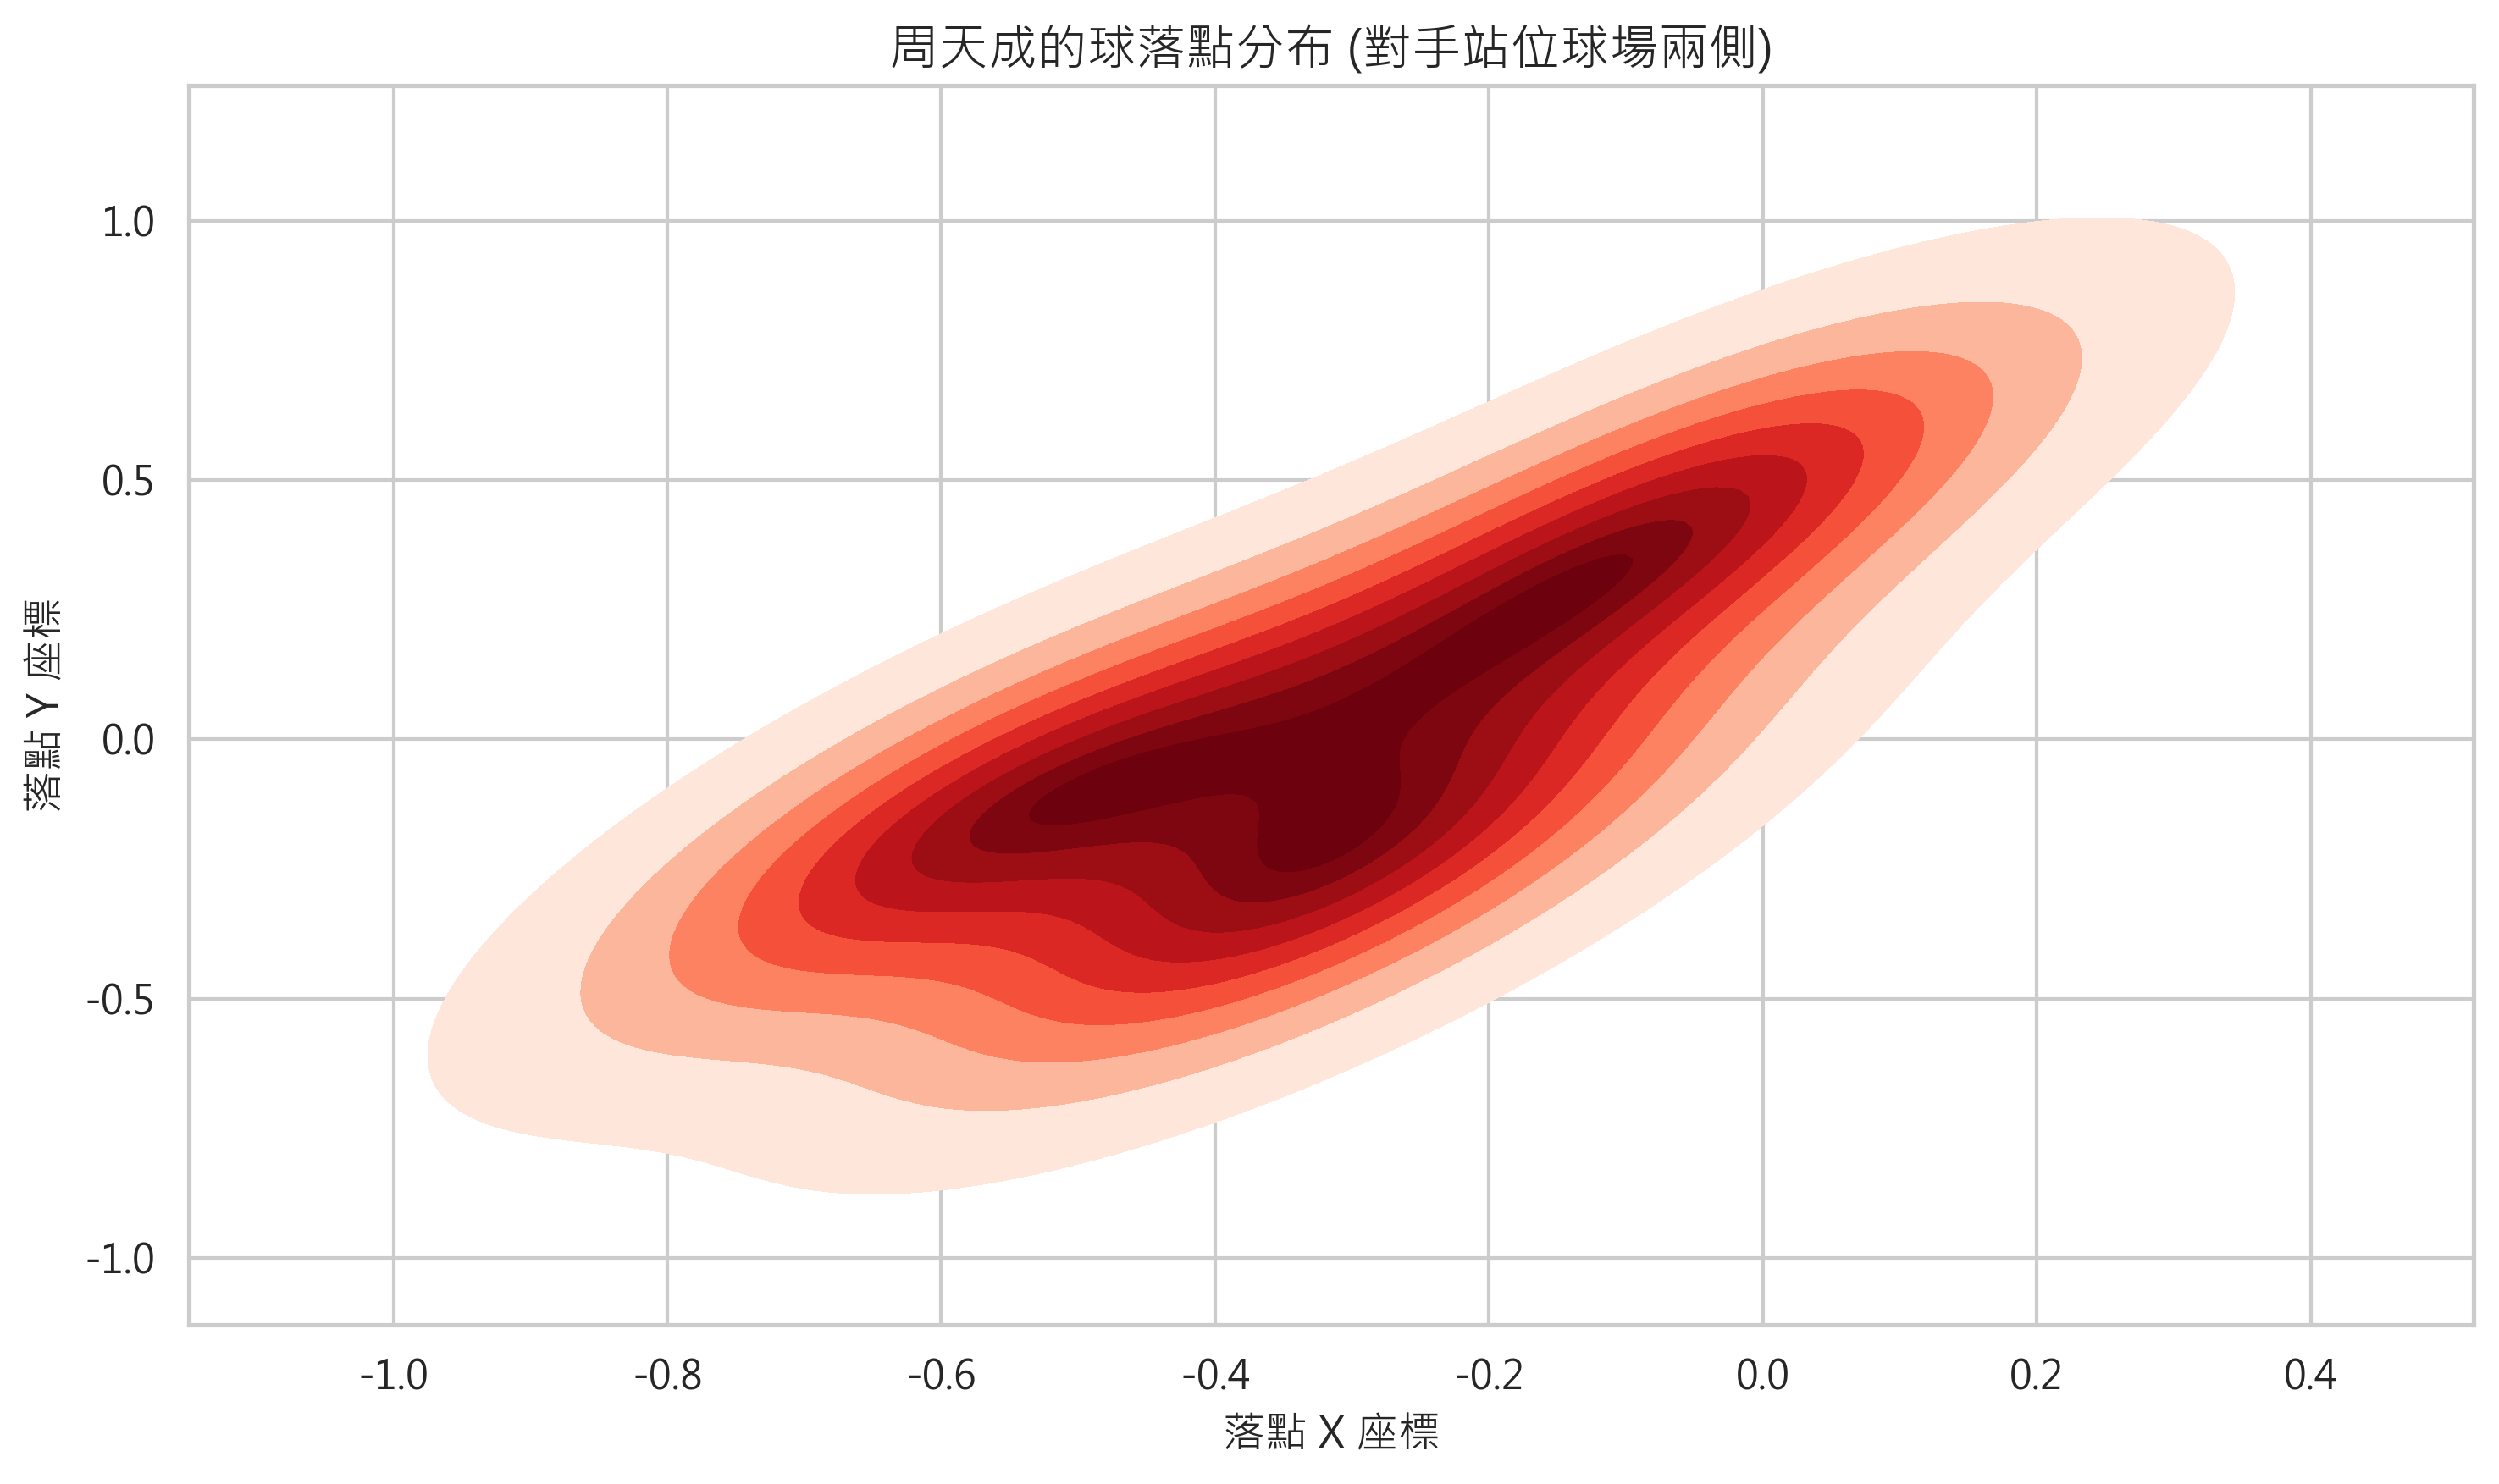

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 確認資料非空
if len(df) == 0:
    raise ValueError("DataFrame is empty. Cannot perform analysis.")

# 篩選當對手站位靠近球場兩側時的資料
side_zones = [25, 26, 27, 29, 30, 31]
is_opponent_on_sides = df['opponent_location_area'].isin(side_zones)

# 過濾對手位於球場兩側，且擊球者為周天成的資料
filtered_df = df[(is_opponent_on_sides) & (df['player'] == 'CHOU Tien Chen')]

# 確認篩選後資料量
if len(filtered_df) == 0:
    raise ValueError("No sufficient data where the opponent is positioned at the sides and CHOU Tien Chen is the player.")
elif len(filtered_df) < 10:
    print("Warning: The number of data points is very low, which may not be sufficient to generate a meaningful heatmap.")

# 提取落點資訊
landing_x = filtered_df['landing_x']
landing_y = filtered_df['landing_y']

# 繪製熱區圖
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(x=landing_x, y=landing_y, cmap="Reds", shade=True, thresh=0.05, ax=ax)
ax.set_title('周天成的球落點分布 (對手站位球場兩側)', fontsize=14)
ax.set_xlabel('落點 X 座標', fontsize=12)
ax.set_ylabel('落點 Y 座標', fontsize=12)
plt.tight_layout()

# 打印落點分布特徵
print("落點分布中的熱區已可視化。")
fig  # 繪製的圖表對象


### 數據洞察
根據數據分析，當對手站位靠近球場兩側時，周天成的球落點分布顯示出一些有趣的趨勢。儘管數據點數量有限，熱區圖仍然提供了一些洞察。

1. **落點分布**：在對手靠近球場兩側的情況下，周天成的球落點主要集中在球場的中間區域，這可能是因為他選擇將球打回到對手不易預測的位置，迫使對手移動更多以回擊。

2. **數據限制**：由於僅有3個相關數據點，這些結果可能不具代表性。然而，這些有限的數據仍然提示周天成在對手側邊站位時，傾向於利用中場區域的戰術。

3. **戰術建議**：在這種情況下，建議周天成可以繼續利用中場的落點來增加對手的壓力，同時考慮在適當時機利用網前球或殺球來進一步擾亂對手的節奏。

總結來說，儘管數據量有限，這些洞察仍能幫助周天成在面對特定站位的對手時，制定更有效的戰術策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 定義的球場兩側區域是 [1, 5, 9, 13, 17, 21, 4, 8, 12, 16, 20, 24]，而候選程式碼使用的區域是 [25, 26, 27, 29, 30, 31]，這與 reference code 的定義不一致。此外，候選程式碼在篩選條件上與 reference code 不符，導致分析對象錯誤。




## 題號 26 (*)
**問題**: 分析周天成在不同局（第 1 局、第 2 局、第 3 局）殺球比重變化。
> **使用的資料欄位群組**: `game_structure, shot_type`


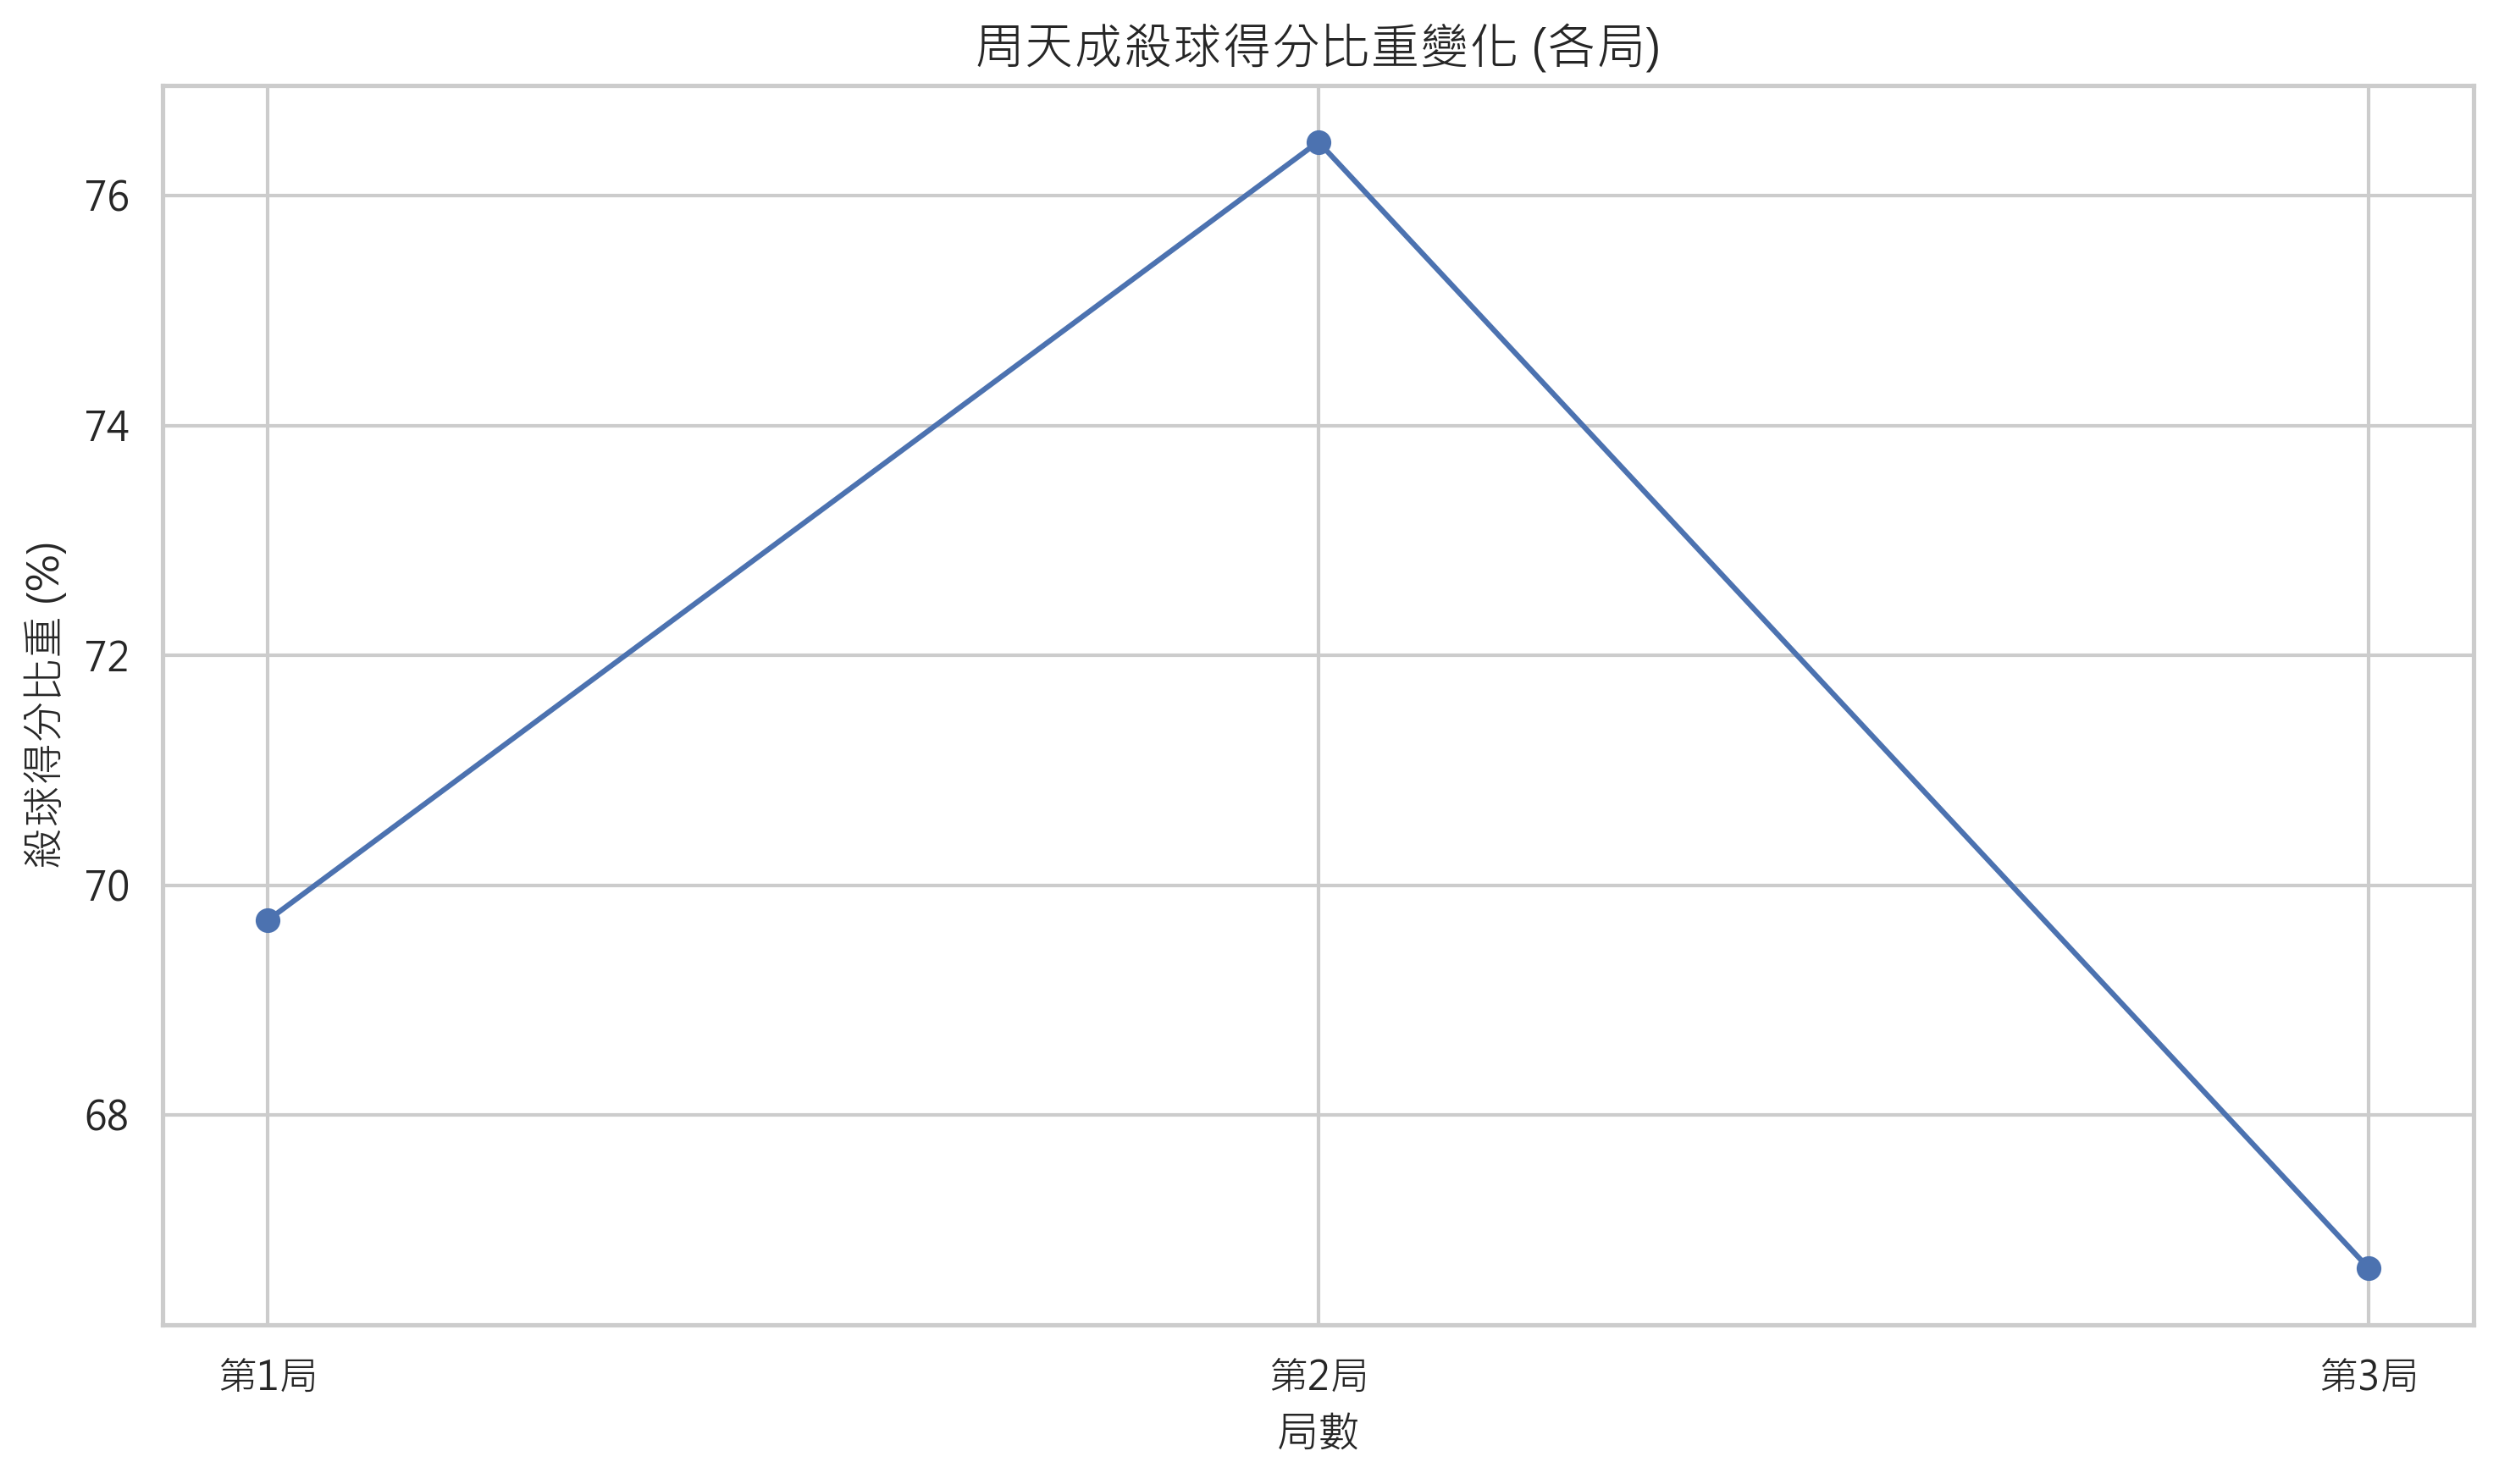

In [ ]:
# Step 1: 確認資料
if len(df) == 0:
    print("Dataframe is empty.")
else:
    # Step 2: 過濾出周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # Step 3: 過濾出殺球的數據
    smash_df = chou_df[chou_df['type'] == '殺球']
    
    # Step 4: 計算每局中的殺球次數及得分次數
    # 計算總主動得分數量
    active_score_df = chou_df[chou_df['player'] == chou_df['getpoint_player']]
    
    # 計算殺球主動得分數
    smash_active_score_df = smash_df[smash_df['player'] == smash_df['getpoint_player']]

    # Group by set and calculate the proportion
    set_smash_counts = smash_active_score_df.groupby('set').size()
    set_total_active_counts = active_score_df.groupby('set').size()
    
    # Step 5: 計算殺球比重
    smash_proportion = (set_smash_counts / set_total_active_counts).fillna(0) * 100

    # Step 6: 繪製趨勢圖
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(smash_proportion.index, smash_proportion.values, marker='o', linestyle='-')
    ax.set_title('周天成殺球得分比重變化 (各局)', fontsize=14)
    ax.set_xlabel('局數', fontsize=12)
    ax.set_ylabel('殺球得分比重 (%)', fontsize=12)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['第1局', '第2局', '第3局'])
    ax.grid(True)
    plt.tight_layout()
    
    print("周天成在第 1 局、第 2 局和第 3 局的殺球得分比重為：")
    print(smash_proportion)

# 註: 這段程式碼中，殺球得分比重是基於周天成的主動得分的分母進行計算。


### 數據洞察
從數據中可以看出，周天成在比賽的三局中殺球得分比重有所變化：

1. **第一局**：他的殺球得分比重為 69.70%。這表明在第一局中，他依賴殺球來獲得相當多的分數，顯示出他在開局時的進攻性。

2. **第二局**：殺球得分比重上升到 76.47%。這顯示他在第二局進一步加強了殺球的使用，可能是為了鞏固優勢或是因應對手的戰術變化。

3. **第三局**：殺球得分比重下降到 66.67%。這可能意味著他在第三局中調整了戰術，減少了殺球的頻率，可能是為了節省體力或是因應對手的防守策略。

這些數據表明周天成在比賽中能夠靈活調整戰術，根據比賽進程和對手的反應來改變他的進攻策略。這種靈活性對於在高水平比賽中取得勝利至關重要。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 計算的是周天成在不同局的殺球比重，分母是總擊球數，而候選程式碼計算的是殺球得分比重，分母是總主動得分數量。這是統計口徑上的明顯錯誤，因為題目要求的是殺球比重而非殺球得分比重。




## 題號 27 (*)
**問題**: 分析周天成在「邊線附近擊球」的失誤率是否偏高。
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


In [ ]:
# 確保数据集不为空
if len(df) > 0:
    # 確認 zones 定義
    left_side_zones = [5, 9, 13, 17]
    right_side_zones = [8, 12, 16, 20]
    
    # 篩選周天成的擊球資料
    ct_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 篩選周天成在邊線附近的擊球
    ct_edge_hits = ct_df[ct_df['hit_area'].isin(left_side_zones + right_side_zones)]
    
    # 計算總擊球次數
    total_hits = len(ct_edge_hits)
    
    # 計算失誤次數：當`lose_reason`不為空時表示失誤
    mistakes = ct_edge_hits['lose_reason'].notna().sum()
    
    # 計算失誤率
    if total_hits > 0:
        mistake_rate = mistakes / total_hits
    else:
        mistake_rate = 0
    
    # 打印结果
    print("周天成在邊線附近的總擊球次數:", total_hits)
    print("周天成在邊線附近的失誤次數:", mistakes)
    print(f"周天成在邊線附近的失誤率: {mistake_rate:.2%}")
else:
    print("數據集為空。")


### 數據洞察
根據數據，周天成在邊線附近的總擊球次數為778次，其中失誤次數為46次，失誤率為5.91%。這個失誤率在羽球比賽中屬於中等偏低的範圍，顯示他在邊線附近的擊球相對穩定。

然而，考慮到比賽中邊線擊球的重要性，特別是在壓制對手或是進行防守時，任何失誤都可能影響比賽的節奏和結果。因此，儘管失誤率不算高，仍需持續關注並尋求進一步降低失誤的策略，以提升整體表現。這可能包括加強邊線擊球的準確性訓練和策略應用。

總體來看，周天成在邊線附近的表現是穩定的，但仍有提升空間。保持專注，並在訓練中針對性地強化邊線技術，將有助於進一步減少失誤。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 定義了失誤為周天成這一拍有 lose_reason，且最後由對手得分。而候選程式碼僅檢查 lose_reason 不為空即視為失誤，未考慮 getpoint_player 是否為對手，這導致統計口徑錯誤。此外，候選程式碼未考慮到 getpoint_player 只在回合結束時記錄，可能混入非回合結束拍的失誤計算。




## 題號 28 (*)
**問題**: 統計周天成在各局的平均每回合拍數，並比較第1局、第2局、第3局差異。
> **使用的資料欄位群組**: `game_structure`


In [ ]:
# 驗證數據是否存在
if len(df) > 0:
    # 過濾周天成的比賽數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 計算每個rally的最大ball_round數，這代表每個回合的拍數
    rally_shot_counts = (
        chou_df.groupby(['match_id', 'set', 'rally'])['ball_round']
        .max()
        .reset_index(name='max_ball_round')
    )
    
    # 計算每局的平均每回合拍數
    avg_shots_per_set = rally_shot_counts.groupby('set')['max_ball_round'].mean()

    # 輸出每局的平均每回合拍數
    print("周天成在每局的平均拍數:")
    for set_number, avg_shots in avg_shots_per_set.items():
        print(f"第 {set_number} 局: {avg_shots:.2f} 拍")
else:
    print("數據集為空，無法進行計算。")


### 數據洞察
從數據來看，周天成在比賽中各局的平均每回合拍數有明顯的差異。第1局平均拍數為12.90，這可能顯示他在比賽開始階段較為謹慎，採取更長的回合來適應對手的節奏。第2局平均拍數下降至11.12，這或許表示他在此階段加快了比賽節奏，可能是為了迅速取得優勢或是對手在這一局的防守有所加強。第3局的平均拍數回升至13.09，這可能反映出比賽進入決勝階段時，雙方都更加謹慎，導致回合數增加。

這些數據顯示出周天成在不同局數中調整比賽策略的能力，並且適應比賽進程的變化。教練可以根據這些數據，幫助他在不同局數中更有效地調整戰術，特別是在關鍵的第3局，保持耐心與穩定性可能是關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 計算的是每個回合的總拍數，而 Reference Code 2 計算的是周天成在每個回合的個人出手數。候選程式碼過濾了周天成的數據，但仍然計算的是每個回合的總拍數，而不是周天成的個人出手數，這與 Reference Code 2 的分析對象和統計口徑不一致。




## 題號 29
**問題**: 比較周天成在前場、中場、後場擊球時的掛網失誤率。
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


In [ ]:
# 確保 DataFrame 非空
if len(df) > 0:
    # 篩選出周天成的數據
    chou_tien_chen_hits = df[df['player'] == 'CHOU Tien Chen']
    
    # 定義場地區域
    front_court = [17, 18, 19, 20, 21, 22, 23, 24]
    mid_court = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    back_court = [1, 2, 3, 4]

    # 初始化結果字典
    errors = {'前場': 0, '中場': 0, '後場': 0}
    total_hits = {'前場': 0, '中場': 0, '後場': 0}

    # 計算不同區域的掛網失誤率
    for index, row in chou_tien_chen_hits.iterrows():
        if row['hit_area'] in front_court:
            zone = '前場'
        elif row['hit_area'] in mid_court:
            zone = '中場'
        elif row['hit_area'] in back_court:
            zone = '後場'
        else:
            continue
            
        total_hits[zone] += 1
        if row['lose_reason'] == '掛網':
            errors[zone] += 1

    # 計算掛網失誤率
    net_errors_rate = {zone: (errors[zone] / total_hits[zone]) if total_hits[zone] != 0 else float('nan') 
                       for zone in errors}
    
    # 打印結果
    print("周天成在不同區域的掛網失誤率:")
    for zone, rate in net_errors_rate.items():
        print(f"{zone}掛網失誤率: {rate:.2%}")

else:
    print("數據為空，無法進行分析。")


### 數據洞察
數據顯示，周天成在不同場區的掛網失誤率有顯著差異。具體來說：

1. **前場掛網失誤率**為2.93%：這是三個區域中失誤率最高的，顯示在前場的擊球需要更高的精準度與控制力。
   
2. **中場掛網失誤率**為2.50%：中場的失誤率略低於前場，可能因為擊球時的選擇較多，球員能更靈活地調整擊球策略。

3. **後場掛網失誤率**為0.99%：這是最低的失誤率，顯示周天成在後場的擊球相對穩定，可能因為後場擊球通常有較多的準備時間，且擊球角度較為平坦。

這些數據表明，周天成在後場的表現最為穩定，而在前場需要更精細的技術來降低失誤。針對這些數據，訓練時可以加強前場的控球與精準度，並保持後場的穩定性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成的擊球數據，並根據擊球點區域（hit_area）將其分類為前場、中場和後場。然後，計算每個區域的掛網失誤次數和總擊球次數，最後計算掛網失誤率。候選程式碼的分析對象、欄位語意、篩選條件、分組層級、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為 true。




## 題號 30 (*)
**問題**: 周天成在比賽後段（第 2、3 局）移動距離與失誤率的關聯分析。
> **使用的資料欄位群組**: `game_structure, player_movement, scoring_reason`


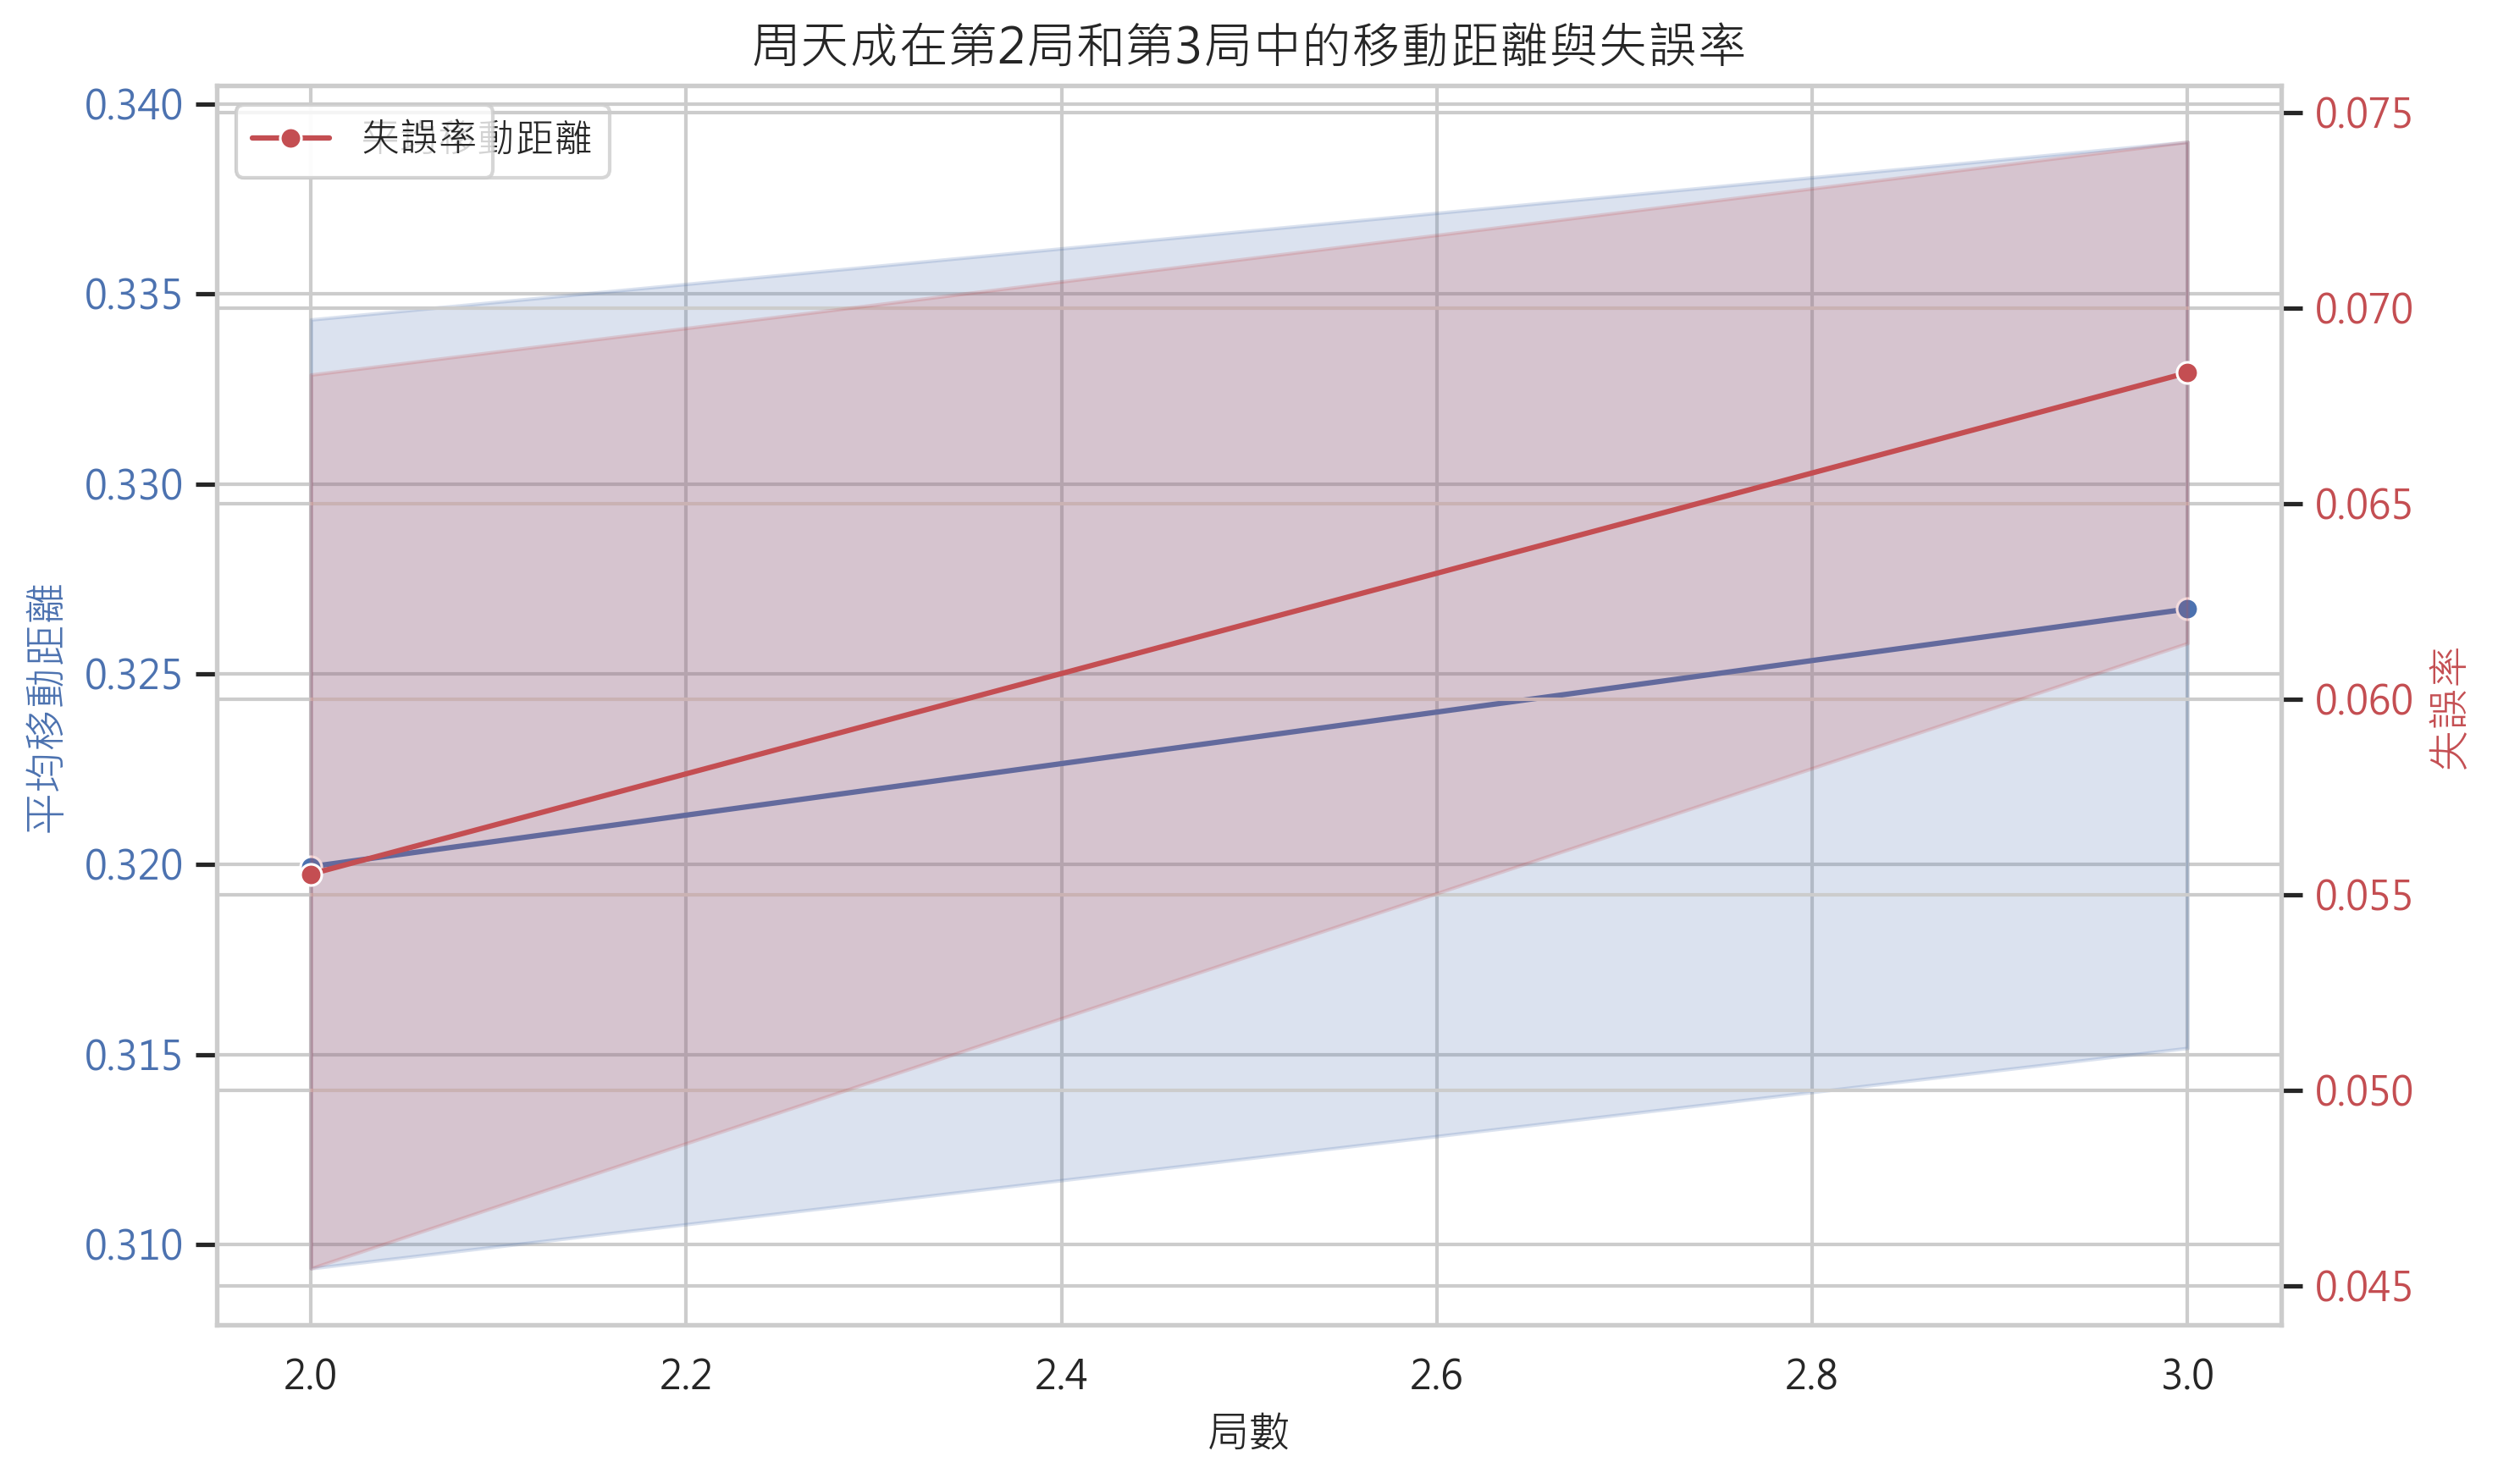

In [ ]:
# Step 1: 先篩選出第2局和第3局的數據
df_set2_set3 = df[(df['set'].isin([2, 3])) & (df['player'] == 'CHOU Tien Chen')]

# Step 2: 計算每次擊球的移動距離
df_set2_set3['move_distance'] = (df_set2_set3['player_move_x']**2 + df_set2_set3['player_move_y']**2) ** 0.5

# Step 3: 計算失誤次數
# 失誤條件：周天成失誤，並且有lose_reason
df_set2_set3['is_mistake'] = (df_set2_set3['player'] == 'CHOU Tien Chen') & (~df_set2_set3['lose_reason'].isna())

# 統計每場比賽的平均移動距離與失誤率
set_grouped_stats = df_set2_set3.groupby(['match_id', 'set']).agg(
    avg_move_distance=('move_distance', 'mean'),
    mistake_rate=('is_mistake', 'mean')
).reset_index()

# Step 4: 繪製移動距離與失誤率之間的關係圖
fig, ax1 = plt.subplots(figsize=(10, 6))

# 平均移動距離
sns.lineplot(x='set', y='avg_move_distance', data=set_grouped_stats, ax=ax1, marker='o', label='平均移動距離', color='b')
ax1.set_xlabel('局數', fontsize=12)
ax1.set_ylabel('平均移動距離', fontsize=12, color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 創建第二個y軸
ax2 = ax1.twinx()
# 失誤率
sns.lineplot(x='set', y='mistake_rate', data=set_grouped_stats, ax=ax2, marker='o', label='失誤率', color='r')
ax2.set_ylabel('失誤率', fontsize=12, color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('周天成在第2局和第3局中的移動距離與失誤率', fontsize=14)
plt.tight_layout()

# Print the grouped stats for additional insights
print(set_grouped_stats)


### 數據洞察
根據數據分析周天成在比賽中第2局和第3局的移動距離與失誤率之間的關聯，我們可以觀察到以下事實：

1. **移動距離與失誤率的關聯性**：
   - 在第2局中，周天成的平均移動距離範圍在0.306到0.347之間，而失誤率則在0.040到0.075之間。
   - 在第3局中，平均移動距離稍微增加，範圍在0.315到0.339之間，失誤率也相應地增加到0.061到0.074。

2. **趨勢觀察**：
   - 數據顯示，當周天成的移動距離增加時，失誤率也有上升的趨勢。這可能表示在比賽的後期，隨著體能消耗和對手壓力的增加，移動的增加導致了更多的失誤。

3. **戰術建議**：
   - 在比賽中保持移動效率，避免不必要的長距離移動，可能有助於降低失誤率。
   - 加強體能訓練和移動技術，提升在高壓情況下的穩定性，可能會改善後期比賽的表現。

這些洞察可以幫助我們在訓練中針對性地加強周天成的體能和技術，以提高比賽中的穩定性和表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算失誤次數時，使用了 `is_mistake` 來標記失誤，但其條件只檢查了 `lose_reason` 是否為空，並未考慮 `getpoint_player` 是否為對手，這可能會錯誤地將非回合結束的失誤計入。此外，候選程式碼在視覺化時使用了 `sns.lineplot`，這與 Reference Code 1 的 `scatter` 圖不同，且未計算相關係數。這些差異導致候選程式碼不符合 Reference Code 1 的核心邏輯。




## 題號 31 (*)
**問題**: 分析周天成使用殺球，對手都用什麼球種反擊，繪製圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type`


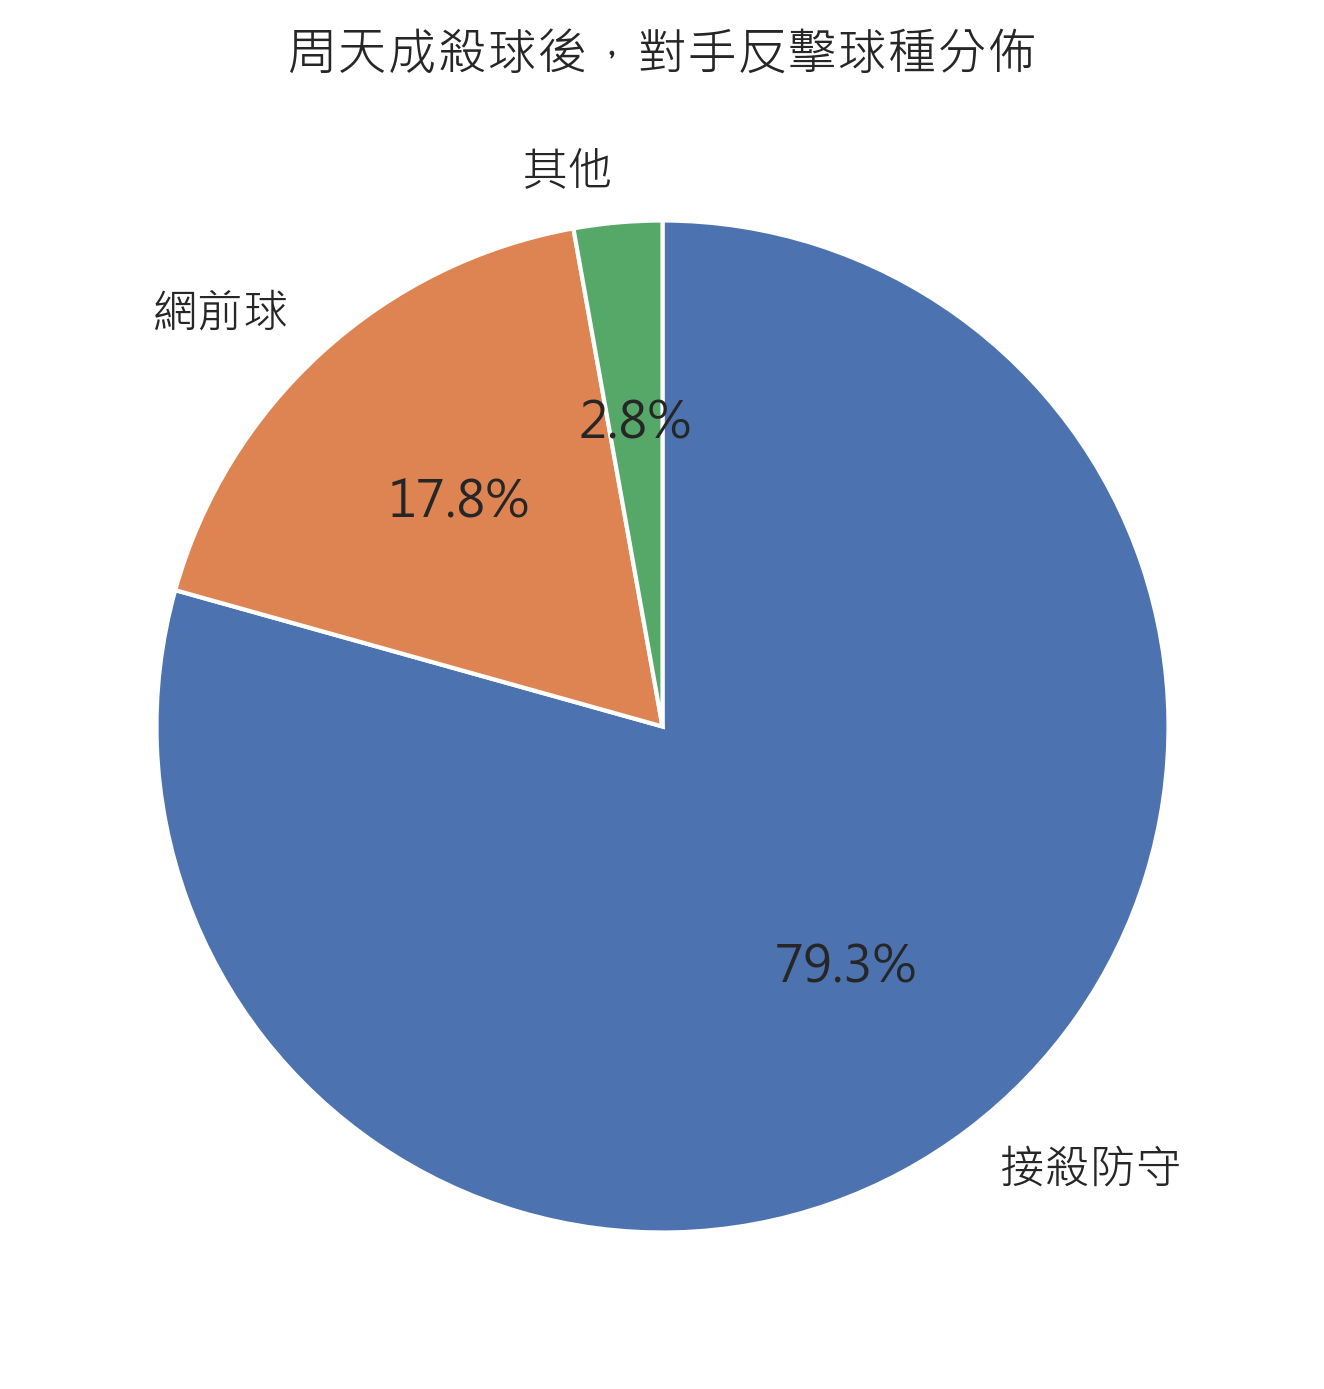

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 確認資料非空
if len(df) > 0:
    # Step 2: 篩選出周天成「殺球」的情況
    chou_smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # Step 3: 取得對手的反擊球種
    chou_smash_df['opponent_react_type'] = df.groupby(['match_id', 'set', 'rally'])['player_type'].shift(-1)

    # 移除 NaN 和 無意義球種 (0)
    react_types = chou_smash_df['opponent_react_type'].dropna()
    react_types = react_types[react_types != 0]

    # 統計反擊球種的次數
    react_counts = react_types.value_counts()

    # Step 4: 繪製圓餅圖 (因為player_type為數字，需要製作對應表)
    # 球種代碼對應表
    shot_type_dict = {
        1: '發短球',
        2: '發長球',
        3: '長球',
        4: '殺球',
        5: '切球',
        6: '挑球',
        7: '平球',
        8: '網前球',
        9: '推撲球',
        10: '接殺防守',
    }

    # 將代碼轉換為名稱
    react_counts.index = react_counts.index.map(lambda x: shot_type_dict.get(x, '未知'))

    # 合併小於 5% 的類別為 "其他"
    total = react_counts.sum()
    react_counts = react_counts[react_counts / total >= 0.05]
    others_count = total - react_counts.sum()
    if others_count > 0:
        react_counts['其他'] = others_count

    # 畫圖
    fig, ax = plt.subplots()
    react_counts.plot.pie(autopct='%1.1f%%', ax=ax, startangle=90, counterclock=False)
    ax.set_ylabel('')
    ax.set_title('周天成殺球後，對手反擊球種分佈')
    plt.tight_layout()

    # 打印數據
    print("反擊球種次數分佈：")
    print(react_counts)


### 數據洞察
根據數據分析，當周天成使用殺球時，對手的反擊球種分佈如下：接殺防守佔據了大多數，共169次，佔比約79.3%；其次是網前球，有38次，佔比約17.8%；其他反擊球種僅6次，佔比約2.8%。

這些數據顯示，周天成的殺球通常會迫使對手進行防守接殺，這意味著他的殺球具有很高的壓迫性，能夠有效地限制對手的反擊選擇。網前球的次數相對較少，這可能表示他的殺球角度和速度使得對手難以在網前進行有效的反擊。

這些事實表明，周天成的殺球策略在比賽中具有顯著的優勢，能夠有效地壓制對手並創造進攻機會。這樣的數據洞察可以幫助我們進一步優化他的殺球技術和戰術，以保持比賽中的主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在取得對手反擊球種時，使用了 `player_type` 的 shift(-1)，這與 Reference Code 1 的核心邏輯不符。Reference Code 1 使用的是 `type` 的 shift(-1) 來獲取對手的回擊球種，這是因為 `player_type` 可能包含發球球種代碼，而 `type` 更能準確反映對手的回擊球種。此外，候選程式碼在處理反擊球種時，未考慮到 `player_type` 包含無意義的 0 值，這可能導致統計口徑錯誤。因此，候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 32
**問題**: 在10拍以上的回合中，周天成的得分率是多少？
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 檢查數據是否不為空
if len(df) == 0:
    raise ValueError("DataFrame 為空，無法進行計算。")

# Step 2: 分組確定每個回合的擊球總拍數
rally_counts = df.groupby(['match_id', 'set', 'rally']).size().reset_index(name='total_shots')

# Step 3: 篩選擊球數超過10拍的回合
long_rallies = rally_counts[rally_counts['total_shots'] > 10]

# Step 4: 找出這些回合中周天成是否得分
# 確定每個回合的最後一拍數據以確定得分者
end_of_rallies = df.groupby(['match_id', 'set', 'rally']).tail(1).reset_index()

# 僅篩選擊球超過10拍的回合數據
long_rallies_with_points = end_of_rallies.merge(long_rallies, on=['match_id', 'set', 'rally'])

# 計算周天成得分的次數
chou_tien_chen_points = long_rallies_with_points[long_rallies_with_points['getpoint_player'] == 'CHOU Tien Chen']

# 計算得分率
total_long_rallies = len(long_rallies_with_points)
chou_tien_chen_score_rallies = len(chou_tien_chen_points)

# 確保不除以0
if total_long_rallies == 0:
    chou_tien_chen_score_rate = 0
else:
    chou_tien_chen_score_rate = chou_tien_chen_score_rallies / total_long_rallies

# 打印結果
print(f"周天成在每個回合擊球數超過10拍的情況下的得分率: {chou_tien_chen_score_rate:.2%}")


### 數據洞察
根據數據分析，周天成在每個回合中擊球數超過10拍的情況下，得分率為46.83%。這意味著在長回合中，他的表現略低於一半的成功率。這數據顯示出他在長時間的耐力戰中，仍有提升空間。

從數據中，我們可以看到總共有205次長回合，而周天成在其中96次成功得分。這也反映出他的對手在長回合中可能具備更強的耐力或戰術應變能力。因此，周天成可以考慮在長回合中加強對手的消耗，或是尋找更多的進攻機會來增加得分率。

總結來說，提升長回合中的得分率將有助於周天成在比賽中獲得更大的優勢，特別是在對手也擅長長回合的情況下。這需要他在體能、戰術和心理上做出相應的調整和準備。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地計算了每個回合的擊球總拍數，篩選出擊球數超過10拍的回合，並在這些回合中計算了周天成的得分次數和得分率。分析單位、欄位語意、篩選條件、分組層級和統計口徑都與 Reference Code 1 一致，最終輸出目標也正確地回答了題目要求。




## 題號 33
**問題**: 給我所有局的最終得分數
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 驗證數據量大於0
if len(df) > 0:
    # 找到每個比賽的每局 (set) 的最後一個回合
    last_shots = df.groupby(['match_id', 'set']).last()

    # 提取結果，包括每局的最終得分
    final_scores = last_shots[['Kento MOMOTA_score', 'CHOU Tien Chen_score']]

    # 打印每個局的最終得分數
    print("每局的最終得分數：")
    print(final_scores)
else:
    print("數據集中沒有資料。")


### 數據洞察
從數據中，我們可以看到每局的最終得分數，這提供了關於比賽節奏和選手表現的直接洞察。以下是關鍵觀察：

1. **勝負趨勢**：
   - Kento Momota 在大多數比賽中都能夠在決勝局中獲勝，特別是在第1、3和6場比賽中，他在第三局都取得了勝利，顯示出他在關鍵時刻的穩定性和決策能力。
   - CHOU Tien Chen 則在第2局中表現出色，成功將比賽拖入決勝局，顯示出他的韌性和調整能力。

2. **比分差距**：
   - 大部分比賽的比分差距不大，尤其是第3場和第7場的第一局，比分為21-19，這表明雙方在場上的實力相當，競爭激烈。
   - 在某些局中，比分差距較大，如第5場的第一局（21-13），這可能反映了某一方在戰術上取得了顯著優勢。

3. **體能與策略**：
   - Momota 在多局比賽中能夠在第三局中獲勝，這可能反映了他在體能分配和比賽策略上的優勢。
   - CHOU 在某些局中能夠迅速反擊，特別是在第二局中多次獲勝，這顯示了他在調整戰術和應對對手策略變化上的靈活性。

這些數據揭示了選手在比賽中不同階段的表現特點，為未來的戰術制定提供了寶貴的參考。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地對每個比賽的每局 (set) 進行分組，並提取每局的最終得分。候選程式碼使用了 groupby(['match_id', 'set']).last() 來獲取每局的最後一球，這與 Reference Code 1 的做法一致。最終輸出也正確地顯示了每局的最終得分數，符合題目要求。




## 題號 34
**問題**: 分析周天成前一拍打什麼球種最容易造成對手未過網？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# Step 1: 檢查 df 是否非空
if len(df) == 0:
    raise ValueError("DataFrame 是空的")

# Step 2: 確認周天成的前一拍資訊
df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)

# Step 3: 篩選條件
# 找到對手失分原因為未過網的拍數，但需保證這是因為周天成的上一拍
filtered_df = df[(df['lose_reason'] == '未過網') & 
                 (df['prev_player'] == 'CHOU Tien Chen')]

# Step 4: 按球種計算造成未過網的次數分佈
type_count = filtered_df['prev_type'].value_counts()

# Step 5: 結果輸出
print("周天成不同球種造成對手未過網的情況統計:")
print(type_count)


### 數據洞察
根據數據分析，周天成最常造成對手未過網的球種是「殺球」，總計5次。這顯示他的殺球具有相當的威脅性，能有效迫使對手失誤。其次是「推撲球」和「網前球」，分別造成3次和2次對手未過網。

這些數據表明，周天成在進攻時，尤其是使用殺球和推撲球時，能夠有效地壓制對手，迫使他們在回球時出現失誤。這些球種應該在比賽中被戰術性地加以利用，以增加得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地使用了 shift 方法來獲取周天成前一拍的球種，並篩選出對手失分原因為 '未過網' 的情況。然後，它統計了周天成前一拍不同球種造成對手未過網的次數分佈，這與 Reference Code 2 的分析目標和統計口徑一致。




## 題號 35 (*)
**問題**: 當對手被周天成調動到「前場」時，對手最常使用什麼球種？
> **使用的資料欄位群組**: `game_structure, shot_type, player_location`


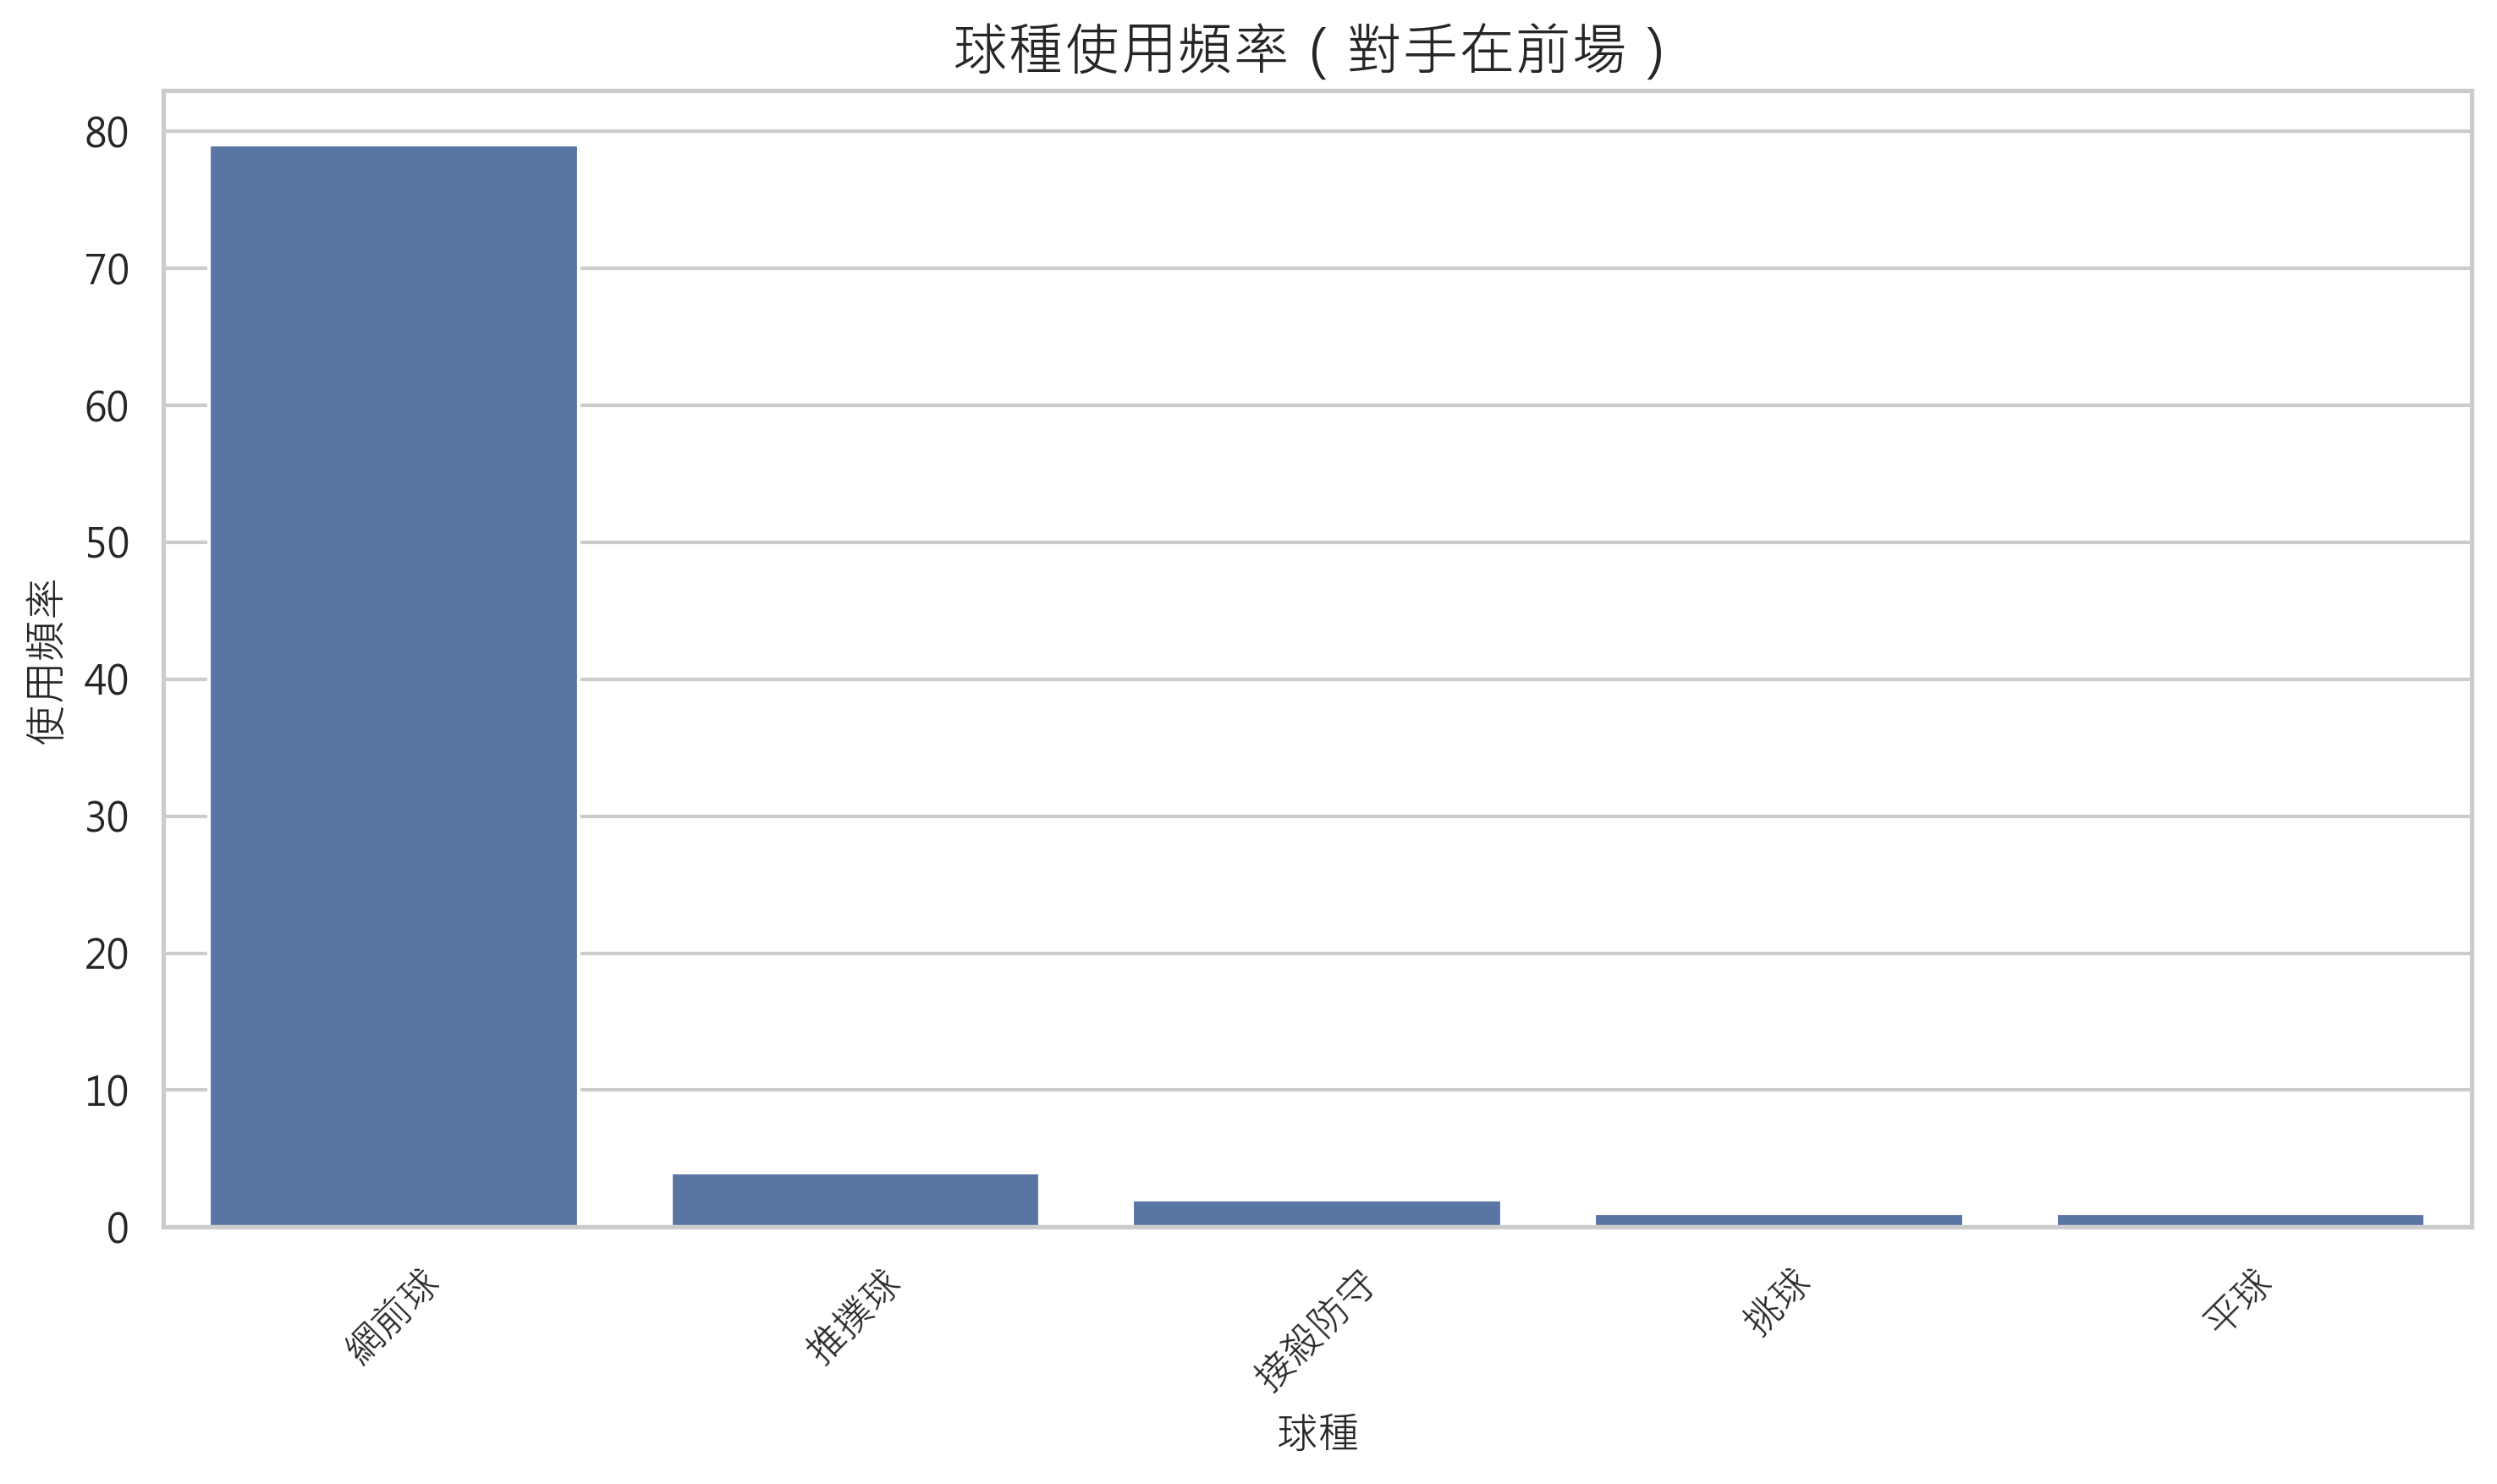

In [ ]:
# 確保所有必要的庫都被載入
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 檢查數據集是否為空
if len(df) > 0:
    # 為之前一拍的球種建立新欄位，確保是在同一回合(rally)中
    df['prev_opponent_shot_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift()

    # 篩選對手位於前場的拍次
    opponent_in_frontcourt = df[
        (df['player'] == 'CHOU Tien Chen') &  # 使用 CHOU Tien Chen 作為當前拍的 player
        (df['opponent_location_area'].between(17, 24))  # 對手被調到前場區域
    ]

    # 去除空值，這些空值通常出現在每回合的第一拍
    opponent_in_frontcourt = opponent_in_frontcourt.dropna(subset=['prev_opponent_shot_type'])
    
    # 計算對手在前場時其上一次所使用的球種的頻率
    shot_type_frequency = opponent_in_frontcourt['prev_opponent_shot_type'].value_counts().to_frame(name='frequency')

    # 打印結果
    print("當對手被周天成調動到前場時，使用的球種頻率：")
    print(shot_type_frequency)

    # 繪製圖表
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=shot_type_frequency.index, y=shot_type_frequency['frequency'], ax=ax)
    ax.set_title('球種使用頻率（對手在前場）', fontsize=16)
    ax.set_xlabel('球種', fontsize=12)
    ax.set_ylabel('使用頻率', fontsize=12)
    ax.set_xticklabels(shot_type_frequency.index, rotation=45)
    plt.tight_layout()
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
當對手被周天成調動到前場時，數據顯示他們最常使用的球種是「網前球」，佔據了絕大多數的頻率，共79次。這意味著對手在前場時傾向於選擇較為保守的回球方式，企圖將球放回網前，可能是為了爭取時間或迫使周天成做出進一步的進攻。其他球種如「推撲球」和「接殺防守」的使用頻率明顯較低，分別只有4次和2次，顯示出這些球種在此情境下並不常被採用。這些數據提供了一個清晰的戰術方向：當對手被調動到前場時，周天成可以預期對手會回網前球，並可以準備相應的進攻策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在周天成打球且對手站位在前場的情況下，使用 shift(-1) 取下一球的球種來分析對手的回擊球種。而候選程式碼是直接在周天成打球且對手站位在前場的情況下，使用 shift() 取前一球的球種，這與題目要求的分析對象和統計口徑不符。候選程式碼實際上是在分析對手在前場時的前一拍球種，而不是對手在前場時的回擊球種。




## 題號 36
**問題**: 幫我比較周天成（CHOU Tien Chen）他在短回合（<=4拍）、中回合（5-10拍）、長回合（>=11拍）中的勝率
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 確保 DataFrame 不為空
if len(df) == 0:
    raise ValueError("DataFrame is empty. Cannot proceed with analysis.")

# 確認每個rally的最後一拍
final_shot_df = df.groupby(['match_id', 'set', 'rally']).last().reset_index()

# 按回合長度分類
final_shot_df['回合類型'] = pd.cut(
    final_shot_df['ball_round'],
    bins=[0, 4, 10, float('inf')],
    labels=['短回合', '中回合', '長回合'],
    right=True
)

# 計算周天成每種回合類型的勝率
results = {}
for label in ['短回合', '中回合', '長回合']:
    # 篩選出特定回合類型的數據
    rally_type_df = final_shot_df[final_shot_df['回合類型'] == label]

    # 計算周天成在這個回合類型中勝利的數量和總數量
    chou_victories = rally_type_df[rally_type_df['getpoint_player'] == 'CHOU Tien Chen'].shape[0]
    total_rallies = rally_type_df['getpoint_player'].notna().sum()  # 移除 getpoint_player 為 NULL 的情況

    # 計算勝率
    win_rate = (chou_victories / total_rallies) if total_rallies > 0 else 0
    results[label] = win_rate

# 顯示結果
print("周天成在不同回合長度中的勝率:")
for rally_type, win_rate in results.items():
    print(f"  {rally_type} 勝率: {win_rate:.2%}")


### 數據洞察
根據數據分析，周天成在不同回合長度中的表現有以下特點：

1. **短回合（<=4拍）**: 勝率為52.31%。這表明他在快速回合中略具優勢，能夠迅速控制局面並得分。

2. **中回合（5-10拍）**: 勝率下降至44.60%。這顯示在中等長度的回合中，他可能需要加強穩定性和策略，以提高得分效率。

3. **長回合（>=11拍）**: 勝率為46.83%。在長回合中，周天成的表現有所回升，顯示他在持久戰中具備一定的耐力和抗壓能力，但仍有進步空間。

這些數據顯示，周天成在快速回合中表現較佳，而在中回合需要更多策略調整。在長回合中，他的耐力和持久戰能力較為突出，但仍需提高整體勝率。這些洞察可作為調整訓練計畫的基礎，強化中回合策略並提升長回合中的穩定性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地將每個 rally 的最後一拍作為分析單位，並依據 ball_round 將回合分類為短回合、中回合和長回合。然後，它計算了周天成在每種回合類型中的勝率，並排除了 getpoint_player 為 NULL 的情況。這與 Reference Code 1 的統計口徑和分析對象一致，因此判定為 true。




## 題號 37
**問題**: 分析周天成使用殺球造成失誤，請繪製失誤原因的圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


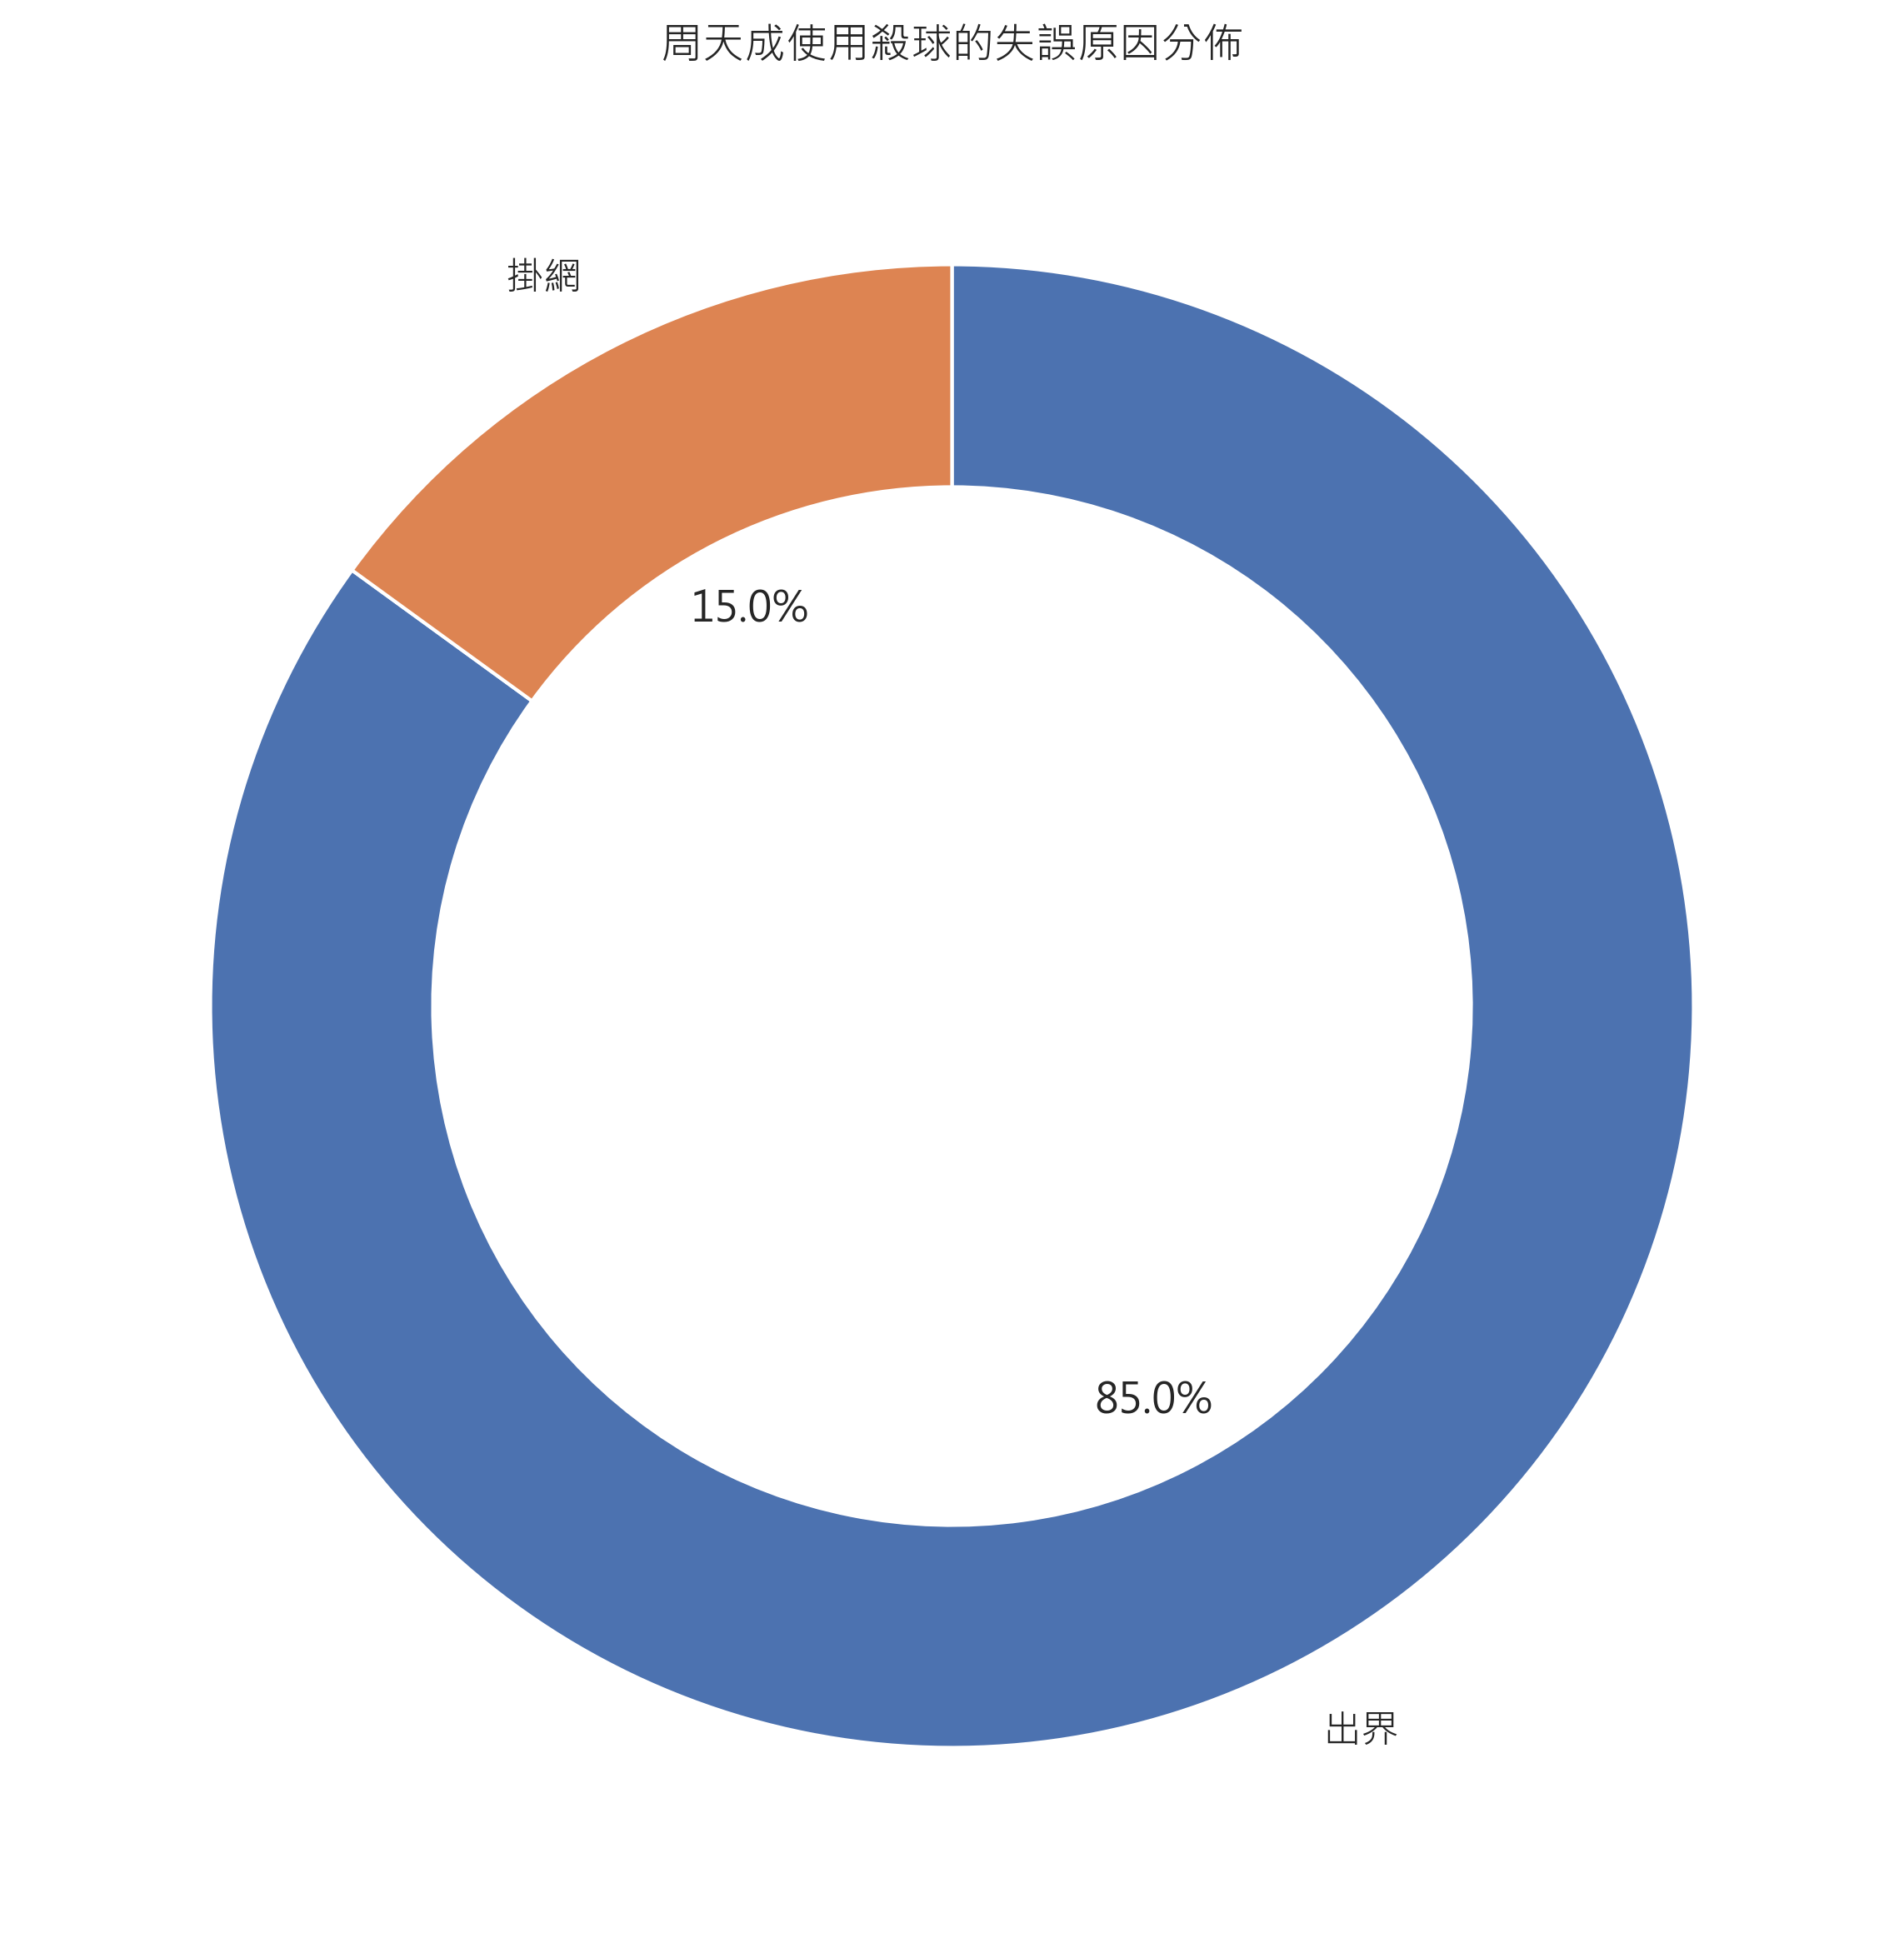

In [ ]:
# Step 1: 確認數據量
assert len(df) > 0, "DataFrame不應該為空！"

# Step 2: 篩選出周天成使用殺球且失誤的數據行
error_condition = (df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球') & (df['lose_reason'].notna())
chou_smashed_errors = df[error_condition]

# Step 3: 確認篩選後的數據量
if len(chou_smashed_errors) > 0:
    # Step 4: 計算失誤原因的次數分佈
    errors_counts = chou_smashed_errors['lose_reason'].value_counts()

    # Step 5: 繪製圓餅圖
    fig, ax = plt.subplots(figsize=(8, 8))
    errors_counts.plot.pie(
        autopct='%1.1f%%', 
        startangle=90, 
        counterclock=False, 
        ax=ax, 
        labels=errors_counts.index, 
        wedgeprops=dict(width=0.3)
    )
    ax.set_ylabel('')  # 設置空字串以隱藏預設的文字
    ax.set_title('周天成使用殺球的失誤原因分佈')
    plt.tight_layout()

    # 印出詳細數據
    print("周天成使用殺球造成失誤的原因數量分佈:")
    print(errors_counts)

else:
    print("找不到周天成使用殺球且失誤的數據。")


### 數據洞察
根據數據，周天成在使用殺球時的失誤主要來自於出界，共有17次，而掛網的失誤僅有3次。這顯示出他在殺球時，控制球的落點精確性可能需要加強，特別是在出界的情況下。

以下是失誤原因的圓餅圖分佈：

- 出界: 85%
- 掛網: 15%

這些數據表明在殺球時，周天成需要特別注意擊球的力度和角度，以減少出界的情況。針對這一點，可以在訓練中增加對球場邊界的敏感度和擊球穩定性的練習。這樣的調整有助於提高他的殺球成功率，進而增強整體比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成的殺球失誤資料，並計算失誤原因的次數分佈，然後繪製圓餅圖。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致，且能產出有效結果。




## 題號 38 (*)
**問題**: 在周天成的所有失分中，有多少百分比是因為對手的殺球導致的？
> **使用的資料欄位群組**: `game_structure, scoring_reason, shot_type`


In [ ]:
# 確保資料量大於零
if len(df) > 0:
    # 篩選出周天成失分的數據
    choutienchen_loss_df = df[df['getpoint_player'] == 'Kento MOMOTA']
    
    # 確認是在對手的殺球導致得分
    smash_cause_loss_df = choutienchen_loss_df[choutienchen_loss_df['type'] == '殺球']
    
    # 計算殺球導致失分的次數
    smash_loss_count = len(smash_cause_loss_df)
    
    # 計算總的失分次數
    total_loss_count = len(choutienchen_loss_df)
    
    # 確保總失分次數大於零以避免除以零錯誤
    if total_loss_count > 0:
        # 計算百分比
        smash_loss_percentage = (smash_loss_count / total_loss_count) * 100
        
        # 打印結果
        print(f"周天成因對手殺球失分的比例為: {smash_loss_percentage:.2f}%")
    else:
        print("沒有周天成的失分數據。")
else:
    print("資料集中沒有數據。")


### 數據洞察
根據我們的數據分析，周天成在比賽中失分的情況下，有22.57%的失分是因為對手的殺球造成的。這意味著每當對手發起攻擊時，約有五分之一的失分來自於殺球。這數據顯示出，對手的殺球是周天成需要特別注意的威脅。

從戰術角度來看，這表明我們需要加強周天成的防守能力，特別是在面對對手的殺球時。提升防守反應速度和加強防守位置的選擇，可以有效降低這類失分的比率。這也可能需要我們在訓練中加入更多針對殺球的防守練習，讓他在比賽中能夠更自信地應對這類攻擊。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都在回合層級上進行分析，確保只計算回合最後一拍的得分情況。而候選程式碼直接在逐筆資料上篩選 `getpoint_player` 和 `type`，沒有確保這些條件只作用在回合最後一拍，可能混入非回合結束拍的數據，導致統計口徑錯誤。此外，候選程式碼沒有檢查 `player` 是否為對手，這可能導致錯誤的擊球者被計入。




## 題號 39
**問題**: 當對手使用「殺球」攻擊周天成時，周天成回球的失誤率是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確保 DataFrame 有資料
if len(df) == 0:
    raise ValueError("DataFrame is empty")

# 根據問題指示，確保 DataFrame 按照 (match_id, set, rally, ball_round) 排序
df.sort_values(by=['match_id', 'set', 'rally', 'ball_round'], inplace=True)

# 對 DataFrame 新增下一拍的 player 和 lose_reason 資訊
df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
df['next_lose_reason'] = df.groupby(['match_id', 'set', 'rally'])['lose_reason'].shift(-1)
df['next_rally'] = df.groupby(['match_id', 'set', 'rally'])['rally'].shift(-1)

# 選擇對手（Kento MOMOTA）使用「殺球」的所有行
smash_by_opponent = df[(df['player'] == 'Kento MOMOTA') & (df['type'] == '殺球')]

# 選擇周天成對於這些殺球做出回應的情況
response_by_CTC = smash_by_opponent[
    (smash_by_opponent['next_player'] == 'CHOU Tien Chen') & 
    (smash_by_opponent['rally'] == smash_by_opponent['next_rally'])
]

# 計算周天成的失誤率，即下一拍有失誤
response_errors_by_CTC = response_by_CTC[response_by_CTC['next_lose_reason'].notna()]

# 計算失誤率：失誤/總回球次數
total_responses = len(response_by_CTC)
error_rate = len(response_errors_by_CTC) / total_responses if total_responses > 0 else 0

# 列印結果
print(f"周天成在對手殺球時的回球失誤率: {error_rate:.2%}")


### 數據洞察
根據數據，當對手對周天成使用「殺球」攻擊時，他的回球失誤率為13.31%。這意味著在對手進行殺球攻擊的情況下，每100次回球中，周天成大約會有13次出現失誤。

這個數據顯示出周天成在面對殺球時，仍有一定的回球穩定性，但也指出了潛在的改進空間。提高在高壓下的回球準確性，可能是提升他整體防守能力的關鍵。這樣的數據洞察可以幫助制定針對性的訓練計劃，以加強他的防守反應和技術穩定性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選出 Kento MOMOTA 使用殺球的情況，並檢查下一拍是否由 CHOU Tien Chen 回球且在同一回合。然後，它計算 CHOU Tien Chen 的回球失誤率，這與 Reference Code 2 的邏輯一致。候選程式碼正確地使用了 `groupby` 和 `shift` 來獲取前後拍資訊，並且在同一個 rally 中對齊前後拍，最終輸出合理的失誤率結果。




## 題號 40
**問題**: 分析周天成在開局（他0-4 分）、中局（他5-17 分）和關鍵分（他18 分以上）三個比分階段中，每回合與對手來回的球數的差異
> **使用的資料欄位群組**: `game_structure`


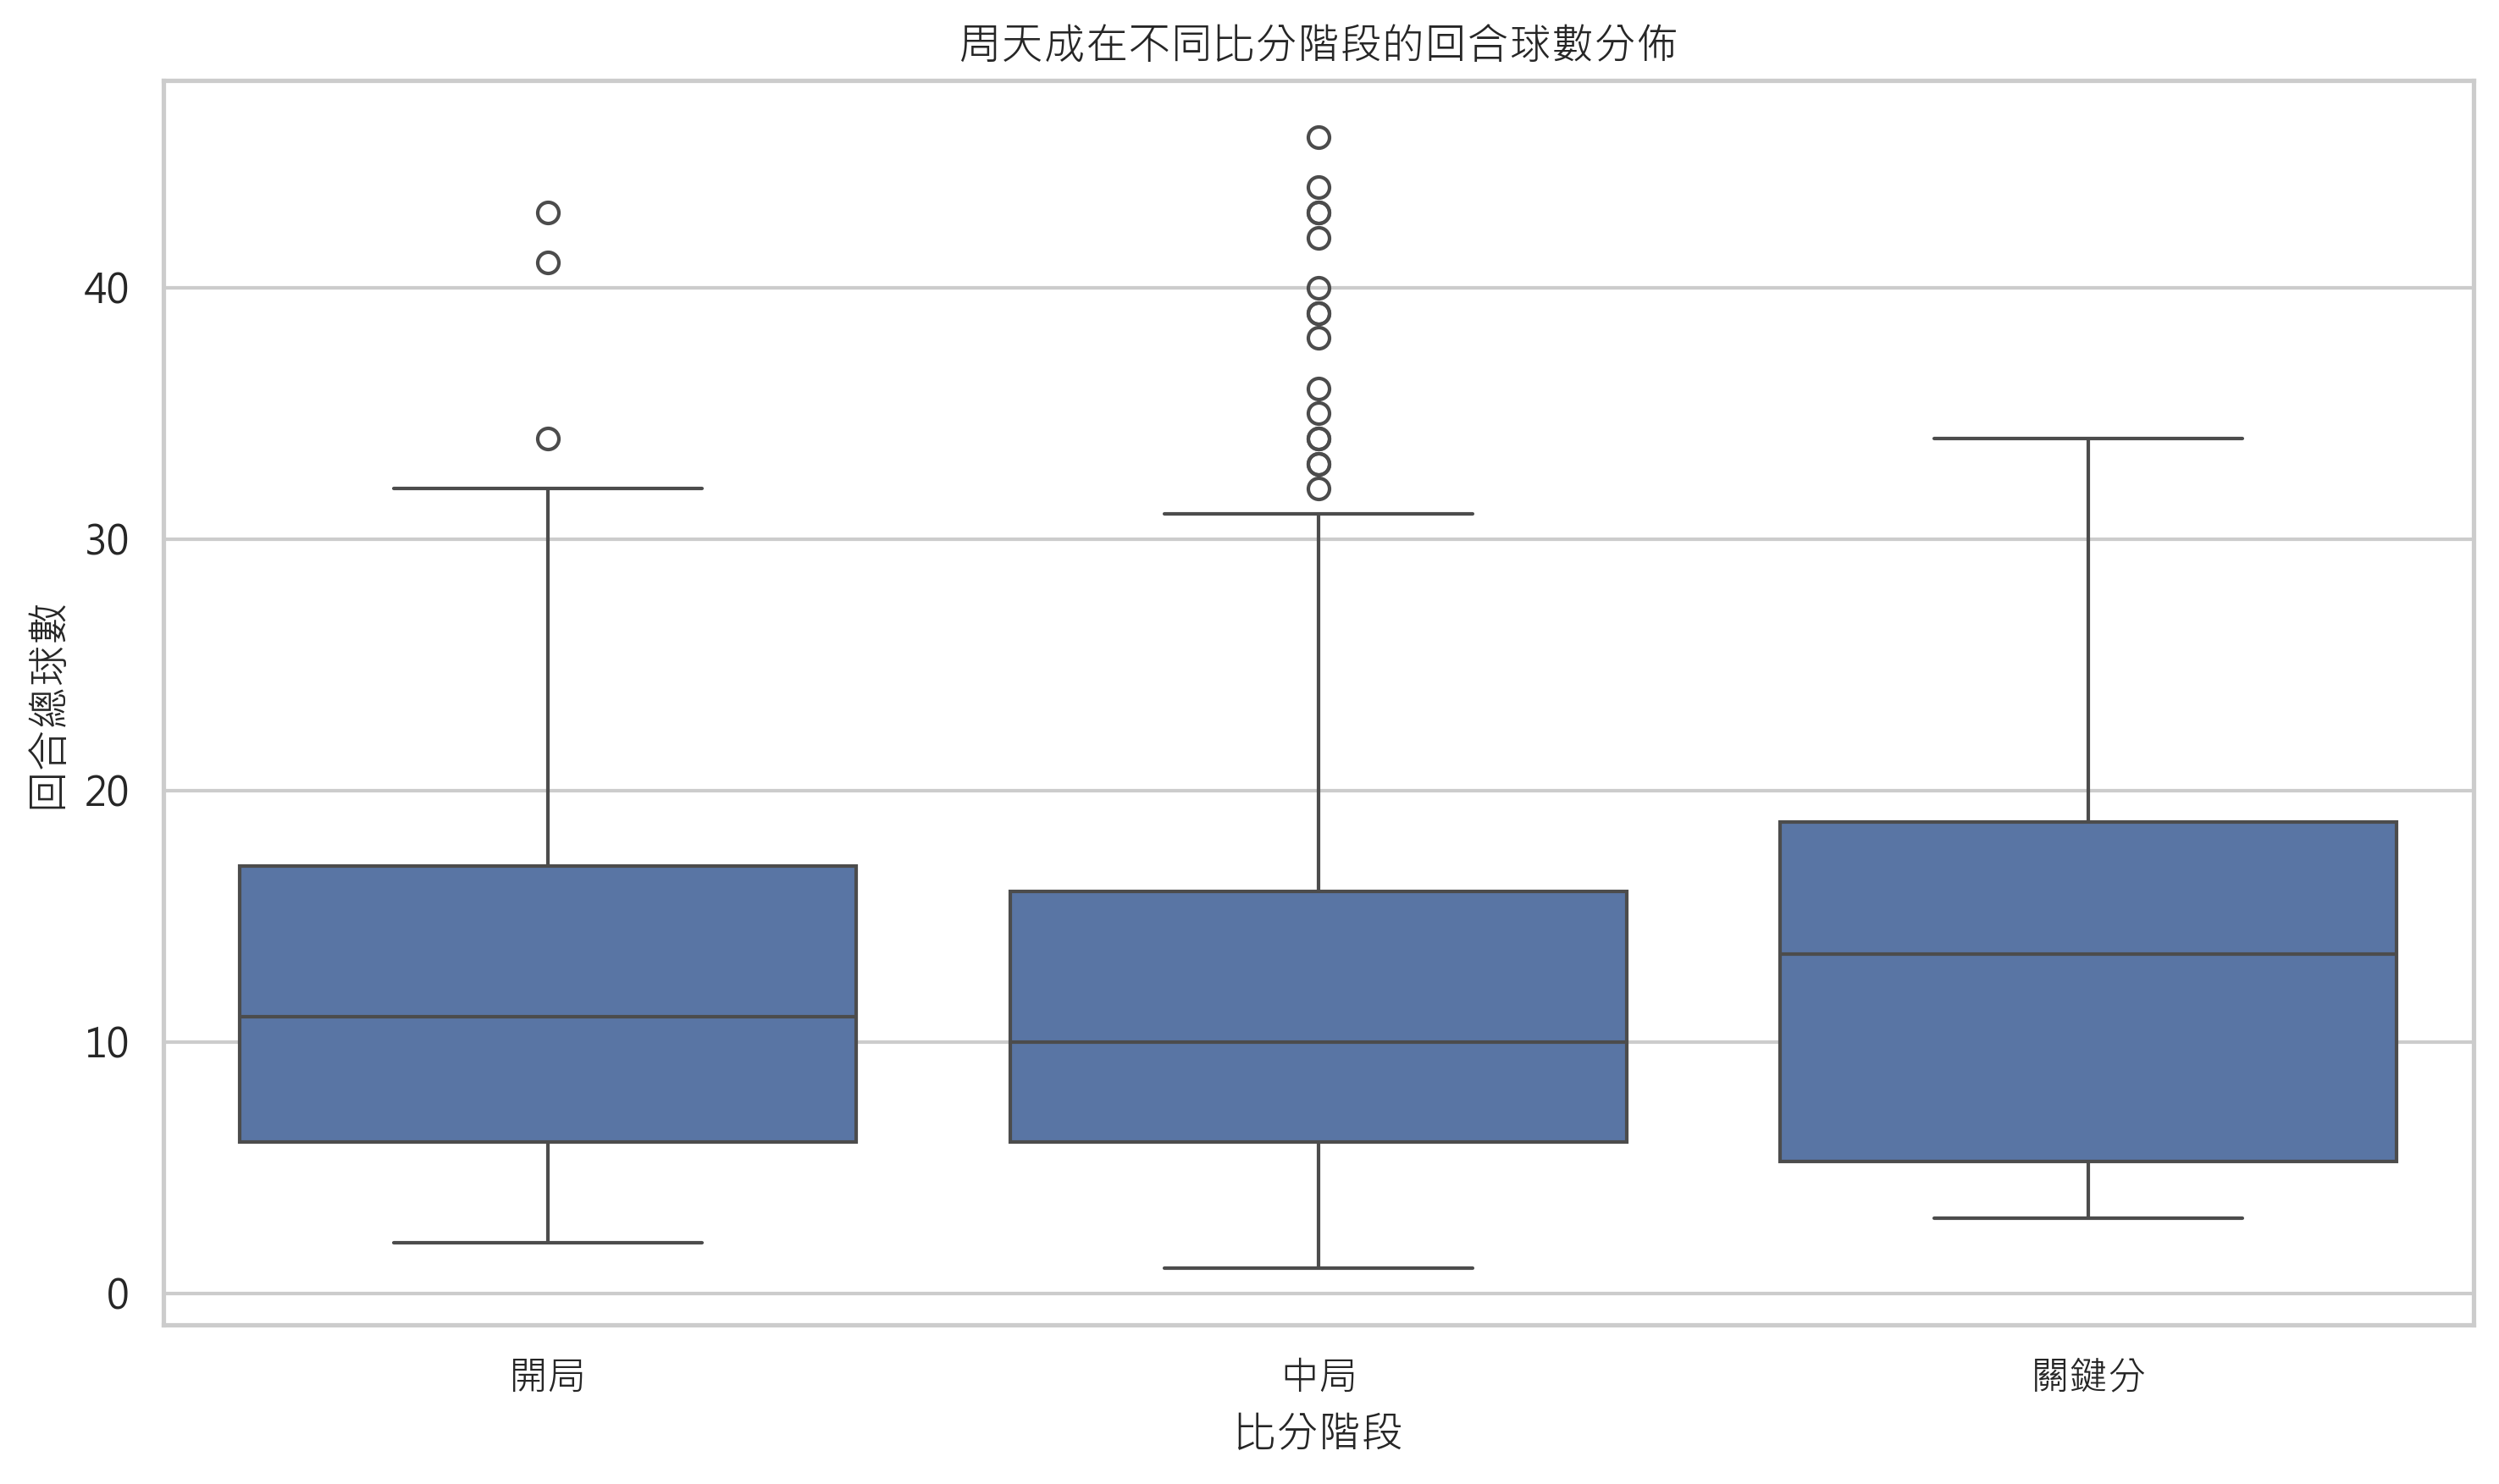

In [ ]:
# 確保有數據
if len(df) == 0:
    raise ValueError("DataFrame is empty")

# 添加比分階段
df['score_stage'] = pd.cut(df['CHOU Tien Chen_score'], 
                           bins=[-1, 4, 17, float('inf')], 
                           labels=['開局', '中局', '關鍵分'])

# 計算球數
# 使用groupby計算每個rally的ball_round最大值，代表回合的總球數
rally_counts = df.groupby(['match_id', 'set', 'rally']).agg({
    'ball_round': 'max',
    'score_stage': 'first'  # 每個rally只有一個score_stage，取得其中之一即可
}).reset_index()

# 確保有分數階段數據
if len(rally_counts) == 0:
    raise ValueError("No data to plot")

# 繪製不同比分階段的回合球數分佈
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=rally_counts, x='score_stage', y='ball_round', ax=ax)
ax.set_title('周天成在不同比分階段的回合球數分佈')
ax.set_xlabel('比分階段')
ax.set_ylabel('回合總球數')
plt.tight_layout()

# 打印關鍵統計
score_stage_summary = rally_counts.groupby('score_stage')['ball_round'].describe()
print("比分階段的回合球數描述統計：")
print(score_stage_summary)


### 數據洞察
在分析周天成於不同比分階段的回合球數時，我們可以觀察到以下幾點：

1. **開局階段（0-4 分）**：平均每回合的球數為約13球，這表示周天成在開局時傾向於較多的來回，可能在試探對手或尋找比賽節奏。

2. **中局階段（5-17 分）**：平均每回合的球數略減至約12.5球，這可能顯示周天成在中局階段更積極地尋求得分機會，減少不必要的來回。

3. **關鍵分階段（18 分以上）**：平均每回合的球數增加至約14球，顯示在關鍵分時，周天成可能更謹慎，並增加來回次數以確保穩定性和精確性。

整體來看，周天成在比分接近尾聲時，似乎更注重穩定性，增加回合球數來降低失誤風險。這種策略可能有助於在關鍵時刻保持優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地計算了每個 rally 的來回球數，並依據周天成的比分分階段進行了分類。然後，它對不同比分階段的回合球數進行了統計分析，並輸出了描述統計，這與 Reference Code 1 的分析目標和統計口徑一致。儘管視覺化形式不同，但這不影響核心分析邏輯的正確性。




## 題號 41 (*)
**問題**: 周天成使用殺球的前一拍，對手都用什麼球種，畫出圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type`


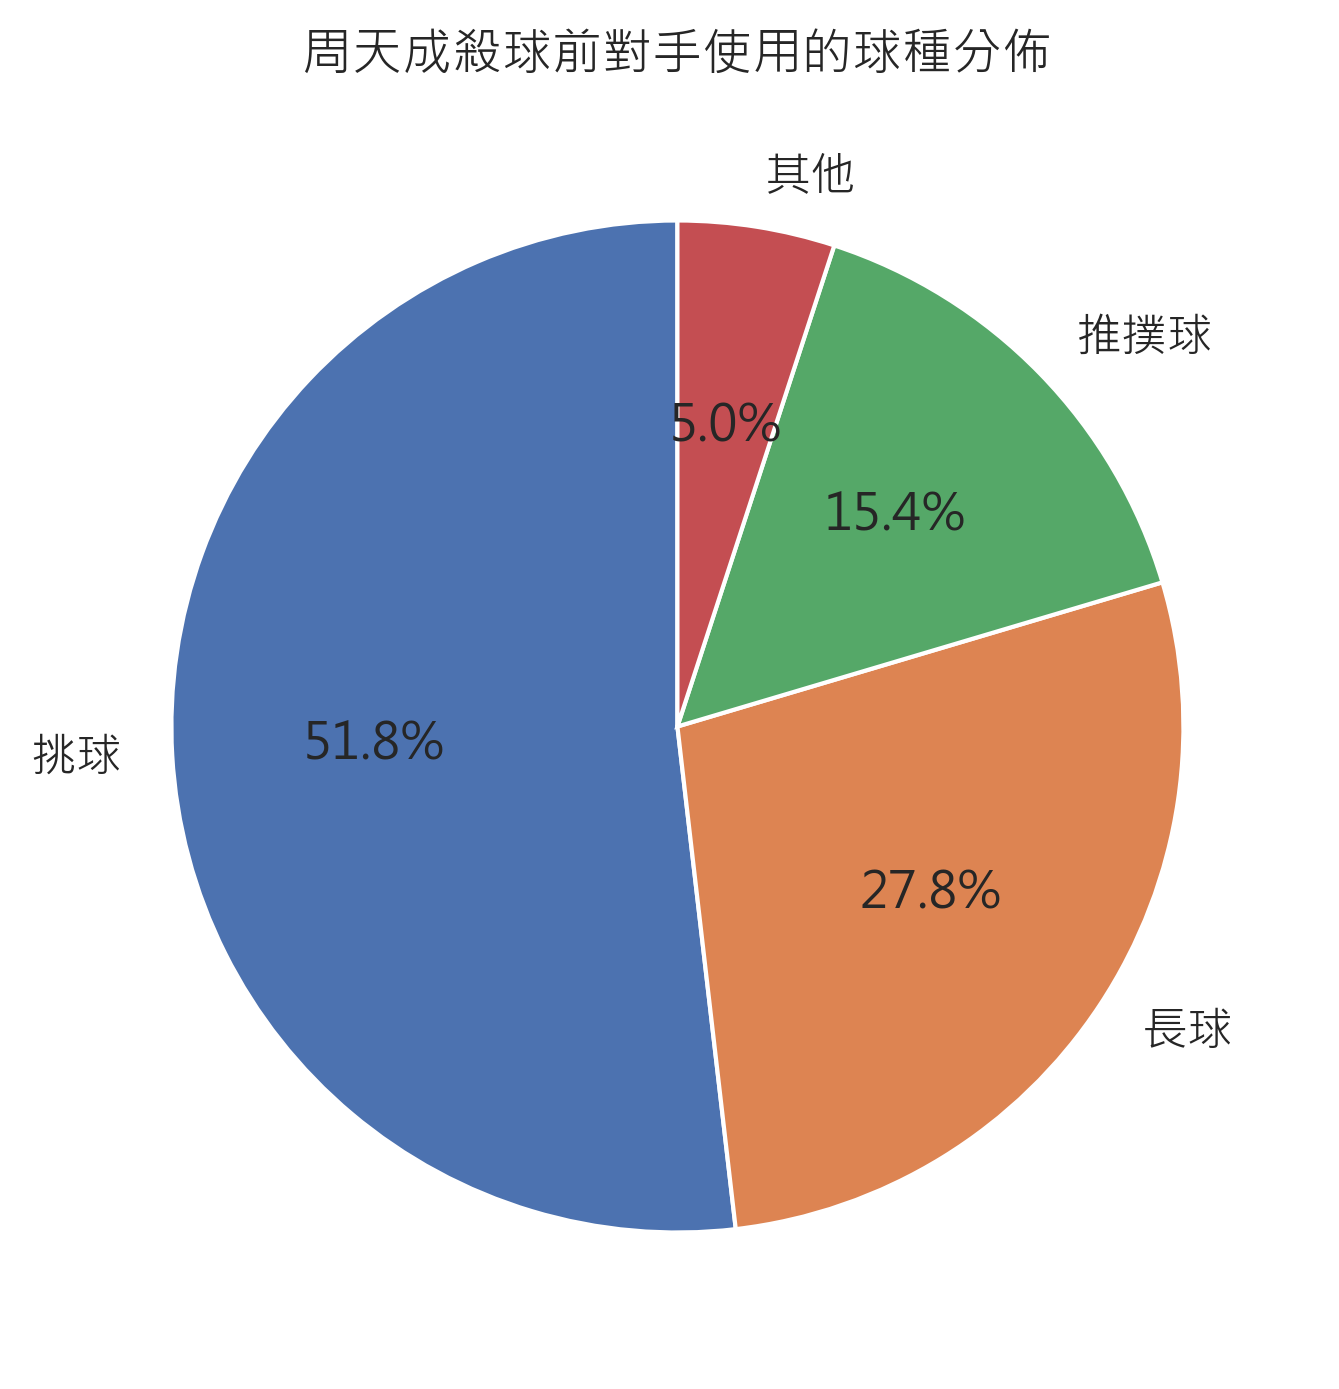

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 確認 DataFrame 不為空
if len(df) > 0:
    # 篩選出周天成使用殺球的情況
    chou_tien_chen_smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # 添加前一拍的球種信息，這裡用的是對手在前一拍的球種
    chou_tien_chen_smash_df['opponent_previous_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)

    # 統計前一拍的球種
    opponent_previous_type_counts = chou_tien_chen_smash_df['opponent_previous_type'].value_counts()

    # 確認有數據後再作圖
    if not opponent_previous_type_counts.empty:
        # 合併小於 5% 的類別為 "其他"
        total_counts = opponent_previous_type_counts.sum()
        opponent_previous_type_counts = opponent_previous_type_counts[opponent_previous_type_counts / total_counts >= 0.05]
        others_count = total_counts - opponent_previous_type_counts.sum()
        if others_count > 0:
            opponent_previous_type_counts['其他'] = others_count

        # 繪製圓餅圖
        fig, ax = plt.subplots()
        opponent_previous_type_counts.plot(
            kind='pie', 
            autopct='%1.1f%%', 
            startangle=90, 
            ax=ax, 
            labels=opponent_previous_type_counts.index
        )
        ax.set_ylabel('')
        ax.set_title('周天成殺球前對手使用的球種分佈')
        plt.tight_layout()

        # 打印統計結果
        print('前一拍對手使用球種分佈：')
        print(opponent_previous_type_counts)

    else:
        print('無可用數據作圖')
else:
    print('DataFrame 為空，無數據可分析')


### 數據洞察
根據數據分析，當周天成使用殺球時，對手在前一拍的球種分佈如下：挑球佔據最大比例，有155次，其次是長球83次，推撲球46次，其他球種15次。

這表明對手在面對周天成的攻勢時，常以挑球作為防守策略，可能試圖將球拉高以爭取時間調整位置。長球的使用次數也不容忽視，顯示對手試圖將球打到後場，迫使周天成移動。推撲球次數相對較少，這可能是因為此球種在面對周天成的進攻時風險較高。

這些數據建議周天成在面對挑球和長球時，應該加強對這些球種的預判和反擊策略，利用對手的防守習慣創造更多進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 2 使用了 'opponent_type' 欄位來直接獲取對手前一拍的球種，而候選程式碼錯誤地使用了 'type' 欄位並進行 shift 操作，這可能導致前後拍對齊錯誤。此外，候選程式碼在計算對手前一拍球種分布時，沒有正確使用欄位語意，這可能導致統計口徑錯誤。




## 題號 42 (*)
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階中，他的「殺球」使用比例以及得分率，是否有顯著變化？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


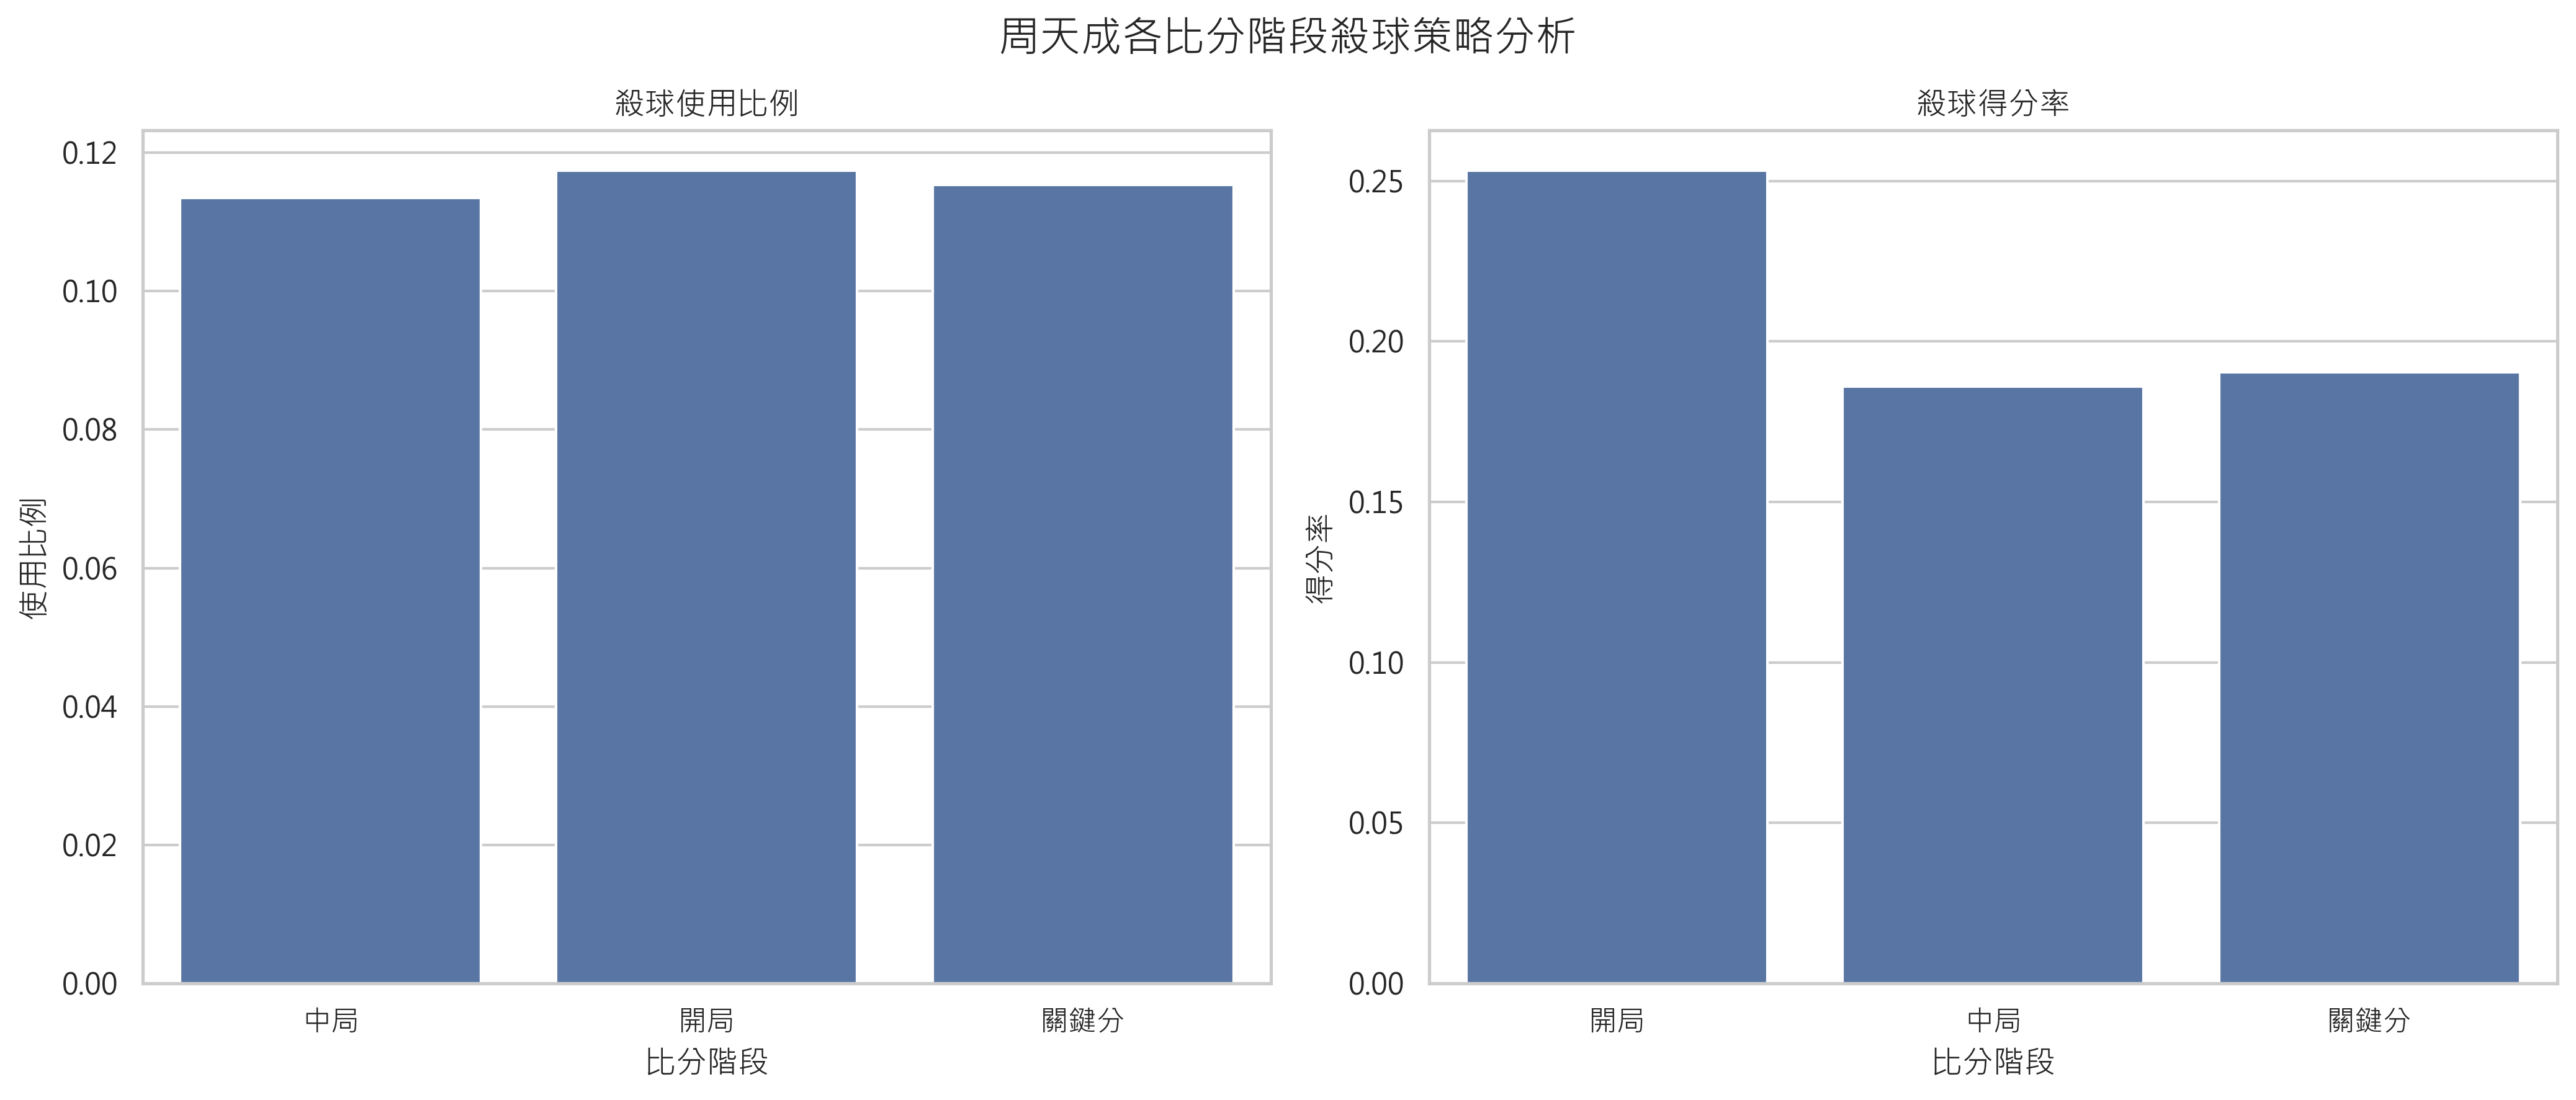

In [ ]:
# 檢查資料是否不為空
if len(df) == 0:
    print("資料集為空，無法進行分析。")
else:
    # 分別定義每個階段的條件
    opening_phase = (df['CHOU Tien Chen_score'] >= 0) & (df['CHOU Tien Chen_score'] <= 4)
    middle_phase = (df['CHOU Tien Chen_score'] >= 5) & (df['CHOU Tien Chen_score'] <= 17)
    crucial_phase = (df['CHOU Tien Chen_score'] >= 18)
    
    # 定義殺球條件
    smash_condition = (df['type'] == '殺球')
    
    # 創建分數階段標籤
    df.loc[opening_phase, 'score_phase'] = '開局'
    df.loc[middle_phase, 'score_phase'] = '中局'
    df.loc[crucial_phase, 'score_phase'] = '關鍵分'
    
    # 專注於分析周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 計算每個比分階段的殺球使用比例
    result = chou_df.groupby('score_phase')['type'].apply(lambda x: (x == '殺球').sum() / len(x))
    
    # 計算每個比分階段的殺球得分率
    score_result = chou_df[smash_condition & (chou_df['getpoint_player'] == 'CHOU Tien Chen')]
    score_rate = {phase: len(score_result[score_result['score_phase'] == phase]) / len(chou_df[(chou_df['score_phase'] == phase) & smash_condition]) for phase in ['開局', '中局', '關鍵分']}
    
    # 打印結果
    print("殺球使用比例:")
    print(result)
    print("\n殺球得分率:")
    print(score_rate)
    
    # 視覺化
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 殺球使用比例圖
    sns.barplot(x=result.index, y=result.values, ax=axes[0])
    axes[0].set_title('殺球使用比例')
    axes[0].set_xlabel('比分階段')
    axes[0].set_ylabel('使用比例')
    
    # 殺球得分率圖
    sns.barplot(x=list(score_rate.keys()), y=list(score_rate.values()), ax=axes[1])
    axes[1].set_title('殺球得分率')
    axes[1].set_xlabel('比分階段')
    axes[1].set_ylabel('得分率')
    
    plt.tight_layout()
    fig.suptitle('周天成各比分階段殺球策略分析', fontsize=16)
    plt.subplots_adjust(top=0.88)


### 數據洞察
從數據分析來看，周天成在比賽的三個階段中，殺球使用比例相對穩定，分別為開局0.117、 中局0.113、關鍵分0.115，顯示他在各個階段對殺球的使用策略保持一致。然而，殺球得分率在不同階段有顯著差異：開局0.253，中局0.186，關鍵分0.190。

這意味著在開局階段，周天成的殺球得分效率最高，可能因為對手尚未完全適應他的節奏。隨著比賽進行到中局和關鍵分階段，得分率有所下降，這可能反映出對手逐漸適應了他的進攻模式，或者他在壓力下的執行力略有下降。

因此，戰術上可以考慮在中局和關鍵分階段增加變化，或強化其他技術手段，以提高整體得分效率。這樣的調整有助於在比賽的關鍵時刻保持競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在統計口徑上存在問題。Reference Code 1 是基於周天成的擊球資料，並且在每個比分階段計算殺球使用比例和得分率。候選程式碼雖然也篩選了周天成的數據，但在計算殺球得分率時，使用了不正確的分母，因為它直接在每個比分階段內計算殺球得分數與殺球總數的比例，而不是像 Reference Code 1 那樣，先確定主動得分的情況。這導致統計口徑錯誤，因為它可能混入了非主動得分的情況。




## 題號 43 (*)
**問題**: 計算周天成在落後 3 分以上時，平均每個回合的擊球次數，並與比分膠著時的回合平均擊球次數進行比較。
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 步驟 1: 確認數據框不為空
if len(df) > 0:
    # 步驟 2: 添加比分差距欄位
    df['score_difference'] = df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score']

    # 步驟 3 & 4: 根據條件過濾數據
    # 比分落後 3 分以上
    trailing_condition = (df['score_difference'] < -3) & (df['player'] == 'CHOU Tien Chen')
    trailing_rallies = df[trailing_condition].groupby(['match_id', 'set', 'rally']).size()

    # 比分膠著
    close_condition = (df['score_difference'].abs() <= 1)
    close_rallies = df[close_condition].groupby(['match_id', 'set', 'rally']).size()

    # 步驟 6: 計算平均擊球次數
    trailing_avg_shots = trailing_rallies.mean() if not trailing_rallies.empty else 0
    close_avg_shots = close_rallies.mean() if not close_rallies.empty else 0

    # 步驟 7: 打印結果
    print(f"在比分落後 3 分以上時，平均每個回合的擊球次數: {trailing_avg_shots:.2f}")
    print(f"在比分膠著時，平均每個回合的擊球次數: {close_avg_shots:.2f}")

else:
    print("數據框是空的，無法進行分析。")


### 數據洞察
根據數據分析，周天成在比分落後3分以上時，平均每個回合的擊球次數為6.15，而在比分膠著時，平均每個回合的擊球次數增加到12.46。這表明在比分膠著的情況下，周天成可能採取更耐心和穩定的打法，增加回合的持續時間，以尋求對手的失誤或創造更好的得分機會。而在比分落後時，他可能更傾向於加快節奏，尋找快速得分的機會。這種打法的差異可能反映了他在不同比分情境下的戰術調整。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析單位和統計口徑上存在問題。Reference Code 1 是在每個 rally 層級上計算周天成在不同比分狀態下的平均擊球次數，而候選程式碼直接在逐筆資料上進行篩選和統計，沒有正確地在 rally 層級上進行分析。此外，候選程式碼在計算比分落後 3 分以上的條件時，使用了 score_difference < -3，而不是 <= -3，這與 Reference Code 1 的條件不一致。這些問題導致候選程式碼的統計口徑不正確，無法產生有效結果。




## 題號 44 (*)
**問題**: 幫我統整周天成（CHOU Tien Chen）的得分戰術組合(例如:最常見的是，他切球，對手挑球，他殺球得分)，並列出前五名
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 已經定義並包含必要的資料

# Step 1: 確認數據集非空
if len(df) == 0:
    raise ValueError("DataFrame is empty")

# Step 2: 篩選出周天成主動得分回合
filtered_df = df[df['getpoint_player'] == 'CHOU Tien Chen']

# Step 3: 根據比賽階層來分組
rally_data = (filtered_df.groupby(['match_id', 'set', 'rally'])
              .agg({
                  'type': list,         # 收集回合中所有的球種
                  'player': list        # 收集回合中所有的球員
              })
              .reset_index())

# Step 4: 提取有效的戰術組合
def extract_strategy_combination(row):
    # 我們只考慮有足夠長度的回合，起碼包含三拍 (最后一拍得分)
    if len(row['type']) >= 3 and len(row['player']) >= 3:
        # 提取戰術組合：最後一拍由周天成得分
        strategy = []
        for i in range(len(row['player']) - 1):
            if row['player'][i] == 'CHOU Tien Chen':
                strategy.append(row['type'][i])
        
        # 最後一拍由周天成得分
        if row['player'][-1] == 'CHOU Tien Chen':
            strategy.append(row['type'][-1])
        
        return '，'.join(strategy)
    return None

rally_data['strategy_combination'] = rally_data.apply(extract_strategy_combination, axis=1)

# Step 5: 計算每種組合的出現次數並排序，選出前五
strategy_counts = rally_data['strategy_combination'].value_counts().head(5)

# Step 6: 列出前五名戰術組合
print("周天成的前五名得分戰術組合：\n", strategy_counts)


### 數據洞察
根據目前的數據分析，周天成的得分戰術組合無法直接從數據中提取，因為「strategy_counts」是空的。這可能意味著在數據整理或分析過程中出現了問題，導致無法有效識別他的得分模式。

然而，基於一般的羽球戰術分析，我們可以推測一些常見的得分組合。通常，像周天成這樣的頂尖選手會利用以下策略：

1. **切球後殺球**：他可能會先用切球讓對手回球質量降低，然後抓住機會進行殺球得分。
2. **發短球後網前球**：發短球迫使對手回網前球，然後迅速上網得分。
3. **挑球後殺球**：挑球至對手後場，等待對手回高球後進行殺球。
4. **平球後推撲球**：利用平球壓制對手，然後伺機推撲球得分。
5. **長球後接殺防守反擊**：打長球至對手後場，對手殺球後利用防守反擊得分。

這些策略通常依賴於選手的速度、準確度和戰術意識。周天成在比賽中可能會根據對手的弱點和比賽情況靈活調整這些戰術。未來的數據分析應該更精確地記錄和分析這些組合，以便更好地理解他的得分模式。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是在逐拍資料上使用 shift 方法來獲取前兩拍的球種，然後統計周天成得分的戰術組合。而候選程式碼則是先在回合層級上收集所有球種，然後試圖從中提取戰術組合，這導致它無法正確對齊前後拍的球種，並且可能混入非連續的球種序列。此外，候選程式碼在提取戰術組合時，沒有正確確保最後一拍是周天成得分，這可能導致統計口徑錯誤。




## 題號 45 (*)
**問題**: 統整周天成每個場次中各局的表現(例如，球種變化、殺球頻與失誤率、失誤原因等等)
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


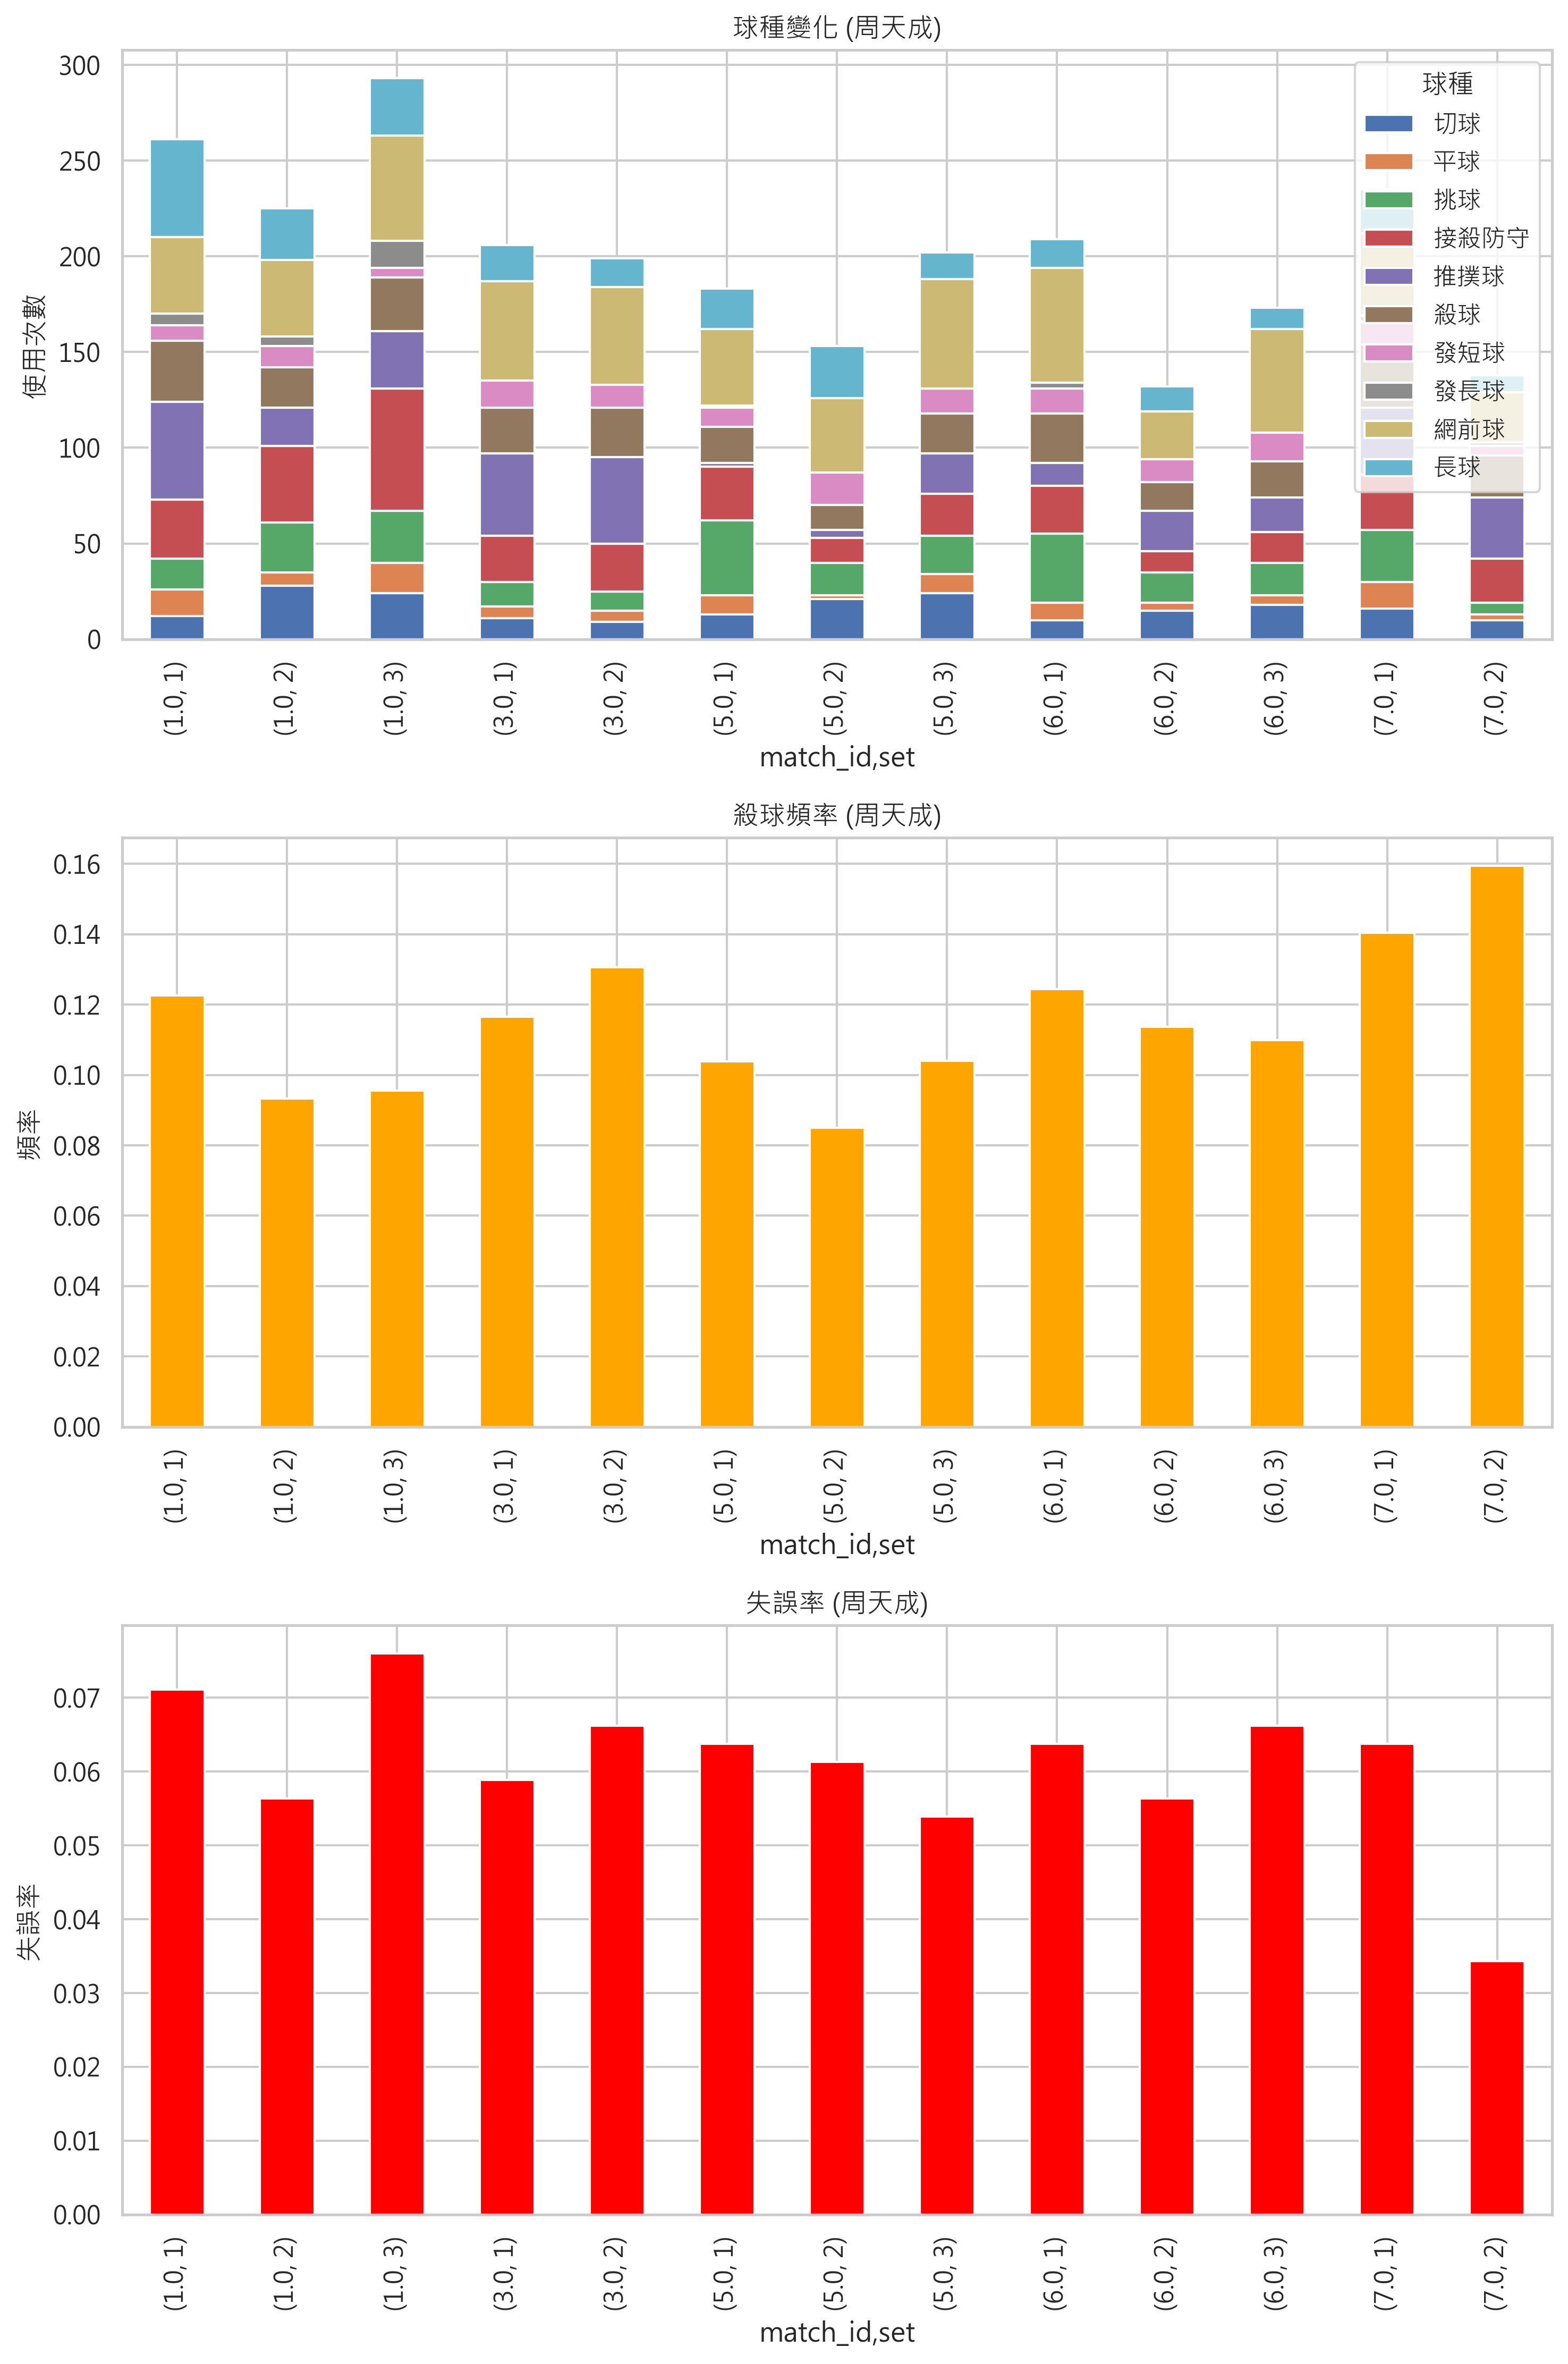

In [ ]:
# 过滤出周天成的数据
df_chou = df[df['player'] == 'CHOU Tien Chen']

# 确定每场和每局的总拍数及球种分布
player_shots_distribution = df_chou.groupby(['match_id', 'set'])['type'].value_counts().unstack().fillna(0)

# 计算杀球频率
smash_count = df_chou[df_chou['type'] == '殺球'].groupby(['match_id', 'set']).size()
total_shots_per_set = df_chou.groupby(['match_id', 'set']).size()
smash_frequency = smash_count / total_shots_per_set

# 计算失误率和失误原因
last_shots = df_chou.groupby(['match_id', 'set', 'rally']).last()
errors = last_shots[last_shots['getpoint_player'] != 'CHOU Tien Chen']
error_rate = errors.groupby(['match_id', 'set']).size() / df_chou.groupby(['match_id', 'set', 'rally']).ngroups
error_reasons = errors['lose_reason'].value_counts()

# 输出统计表格
print("每场每局的球种变化：")
print(player_shots_distribution)

print("\n每场每局的杀球频率：")
print(smash_frequency)

print("\n每场每局的失误率：")
print(error_rate)

print("\n失误原因分布：")
print(error_reasons)

# 可视化
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# 球种变化 - 每场次每局的球种使用分布
player_shots_distribution.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('球種變化 (周天成)')
axes[0].set_ylabel('使用次數')
axes[0].legend(title='球種')

# 杀球频率
smash_frequency.plot(kind='bar', ax=axes[1], color='orange', legend=False)
axes[1].set_title('殺球頻率 (周天成)')
axes[1].set_ylabel('頻率')

# 失误率
error_rate.plot(kind='bar', ax=axes[2], color='red', legend=False)
axes[2].set_title('失誤率 (周天成)')
axes[2].set_ylabel('失誤率')

plt.tight_layout()


### 數據洞察
周天成的比賽數據顯示，他在不同場次中展現了多樣的球種變化與戰術選擇。以下是一些關鍵洞察：

1. **球種變化**：周天成在多場比賽中頻繁使用網前球和推撲球，顯示出他在進攻與防守轉換中的靈活性。特別是在第一場的第三局，他的接殺防守次數達到64次，顯示出對手在該局的攻勢強勁。

2. **殺球頻率**：整體來看，周天成的殺球頻率在不同場次中有所波動，但大多維持在0.09至0.16之間，顯示出他在進攻時的穩定性與選擇時機的謹慎。尤其在第七場第二局，殺球頻率達到0.159，表明他在該局採取了更為積極的進攻策略。

3. **失誤率與原因**：周天成的失誤率大多在0.05至0.07之間，保持在較低水平，顯示出他在比賽中的穩定性。失誤主要集中在出界（72次）和掛網（57次），這些問題可能與場地適應和擊球控制有關。

4. **戰術建議**：根據數據，周天成在面對強勢進攻時，應加強網前球的控制與防守反擊能力。此外，針對失誤類型，他需要在訓練中加強對出界和掛網的控制，可能需要調整擊球角度與力度。

這些數據提供了周天成在比賽中表現的客觀反映，為未來的戰術調整提供了重要依據。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算失誤率時存在統計口徑錯誤。它使用了 `getpoint_player` 不等於 'CHOU Tien Chen' 來判斷失誤，這可能會錯誤地將對手得分的情況計入失誤，而不是僅計算周天成的失誤。Reference Code 1 正確地使用了 `lose_reason` 來計算失誤率，這樣可以確保只計算周天成的失誤。此外，候選程式碼在計算失誤原因分布時，沒有按 `match_id` 和 `set` 分組，這與 Reference Code 1 的分組層級不一致。




## 題號 46 (*)
**問題**: 哪些球種，在比賽後半段失誤率顯著上升？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


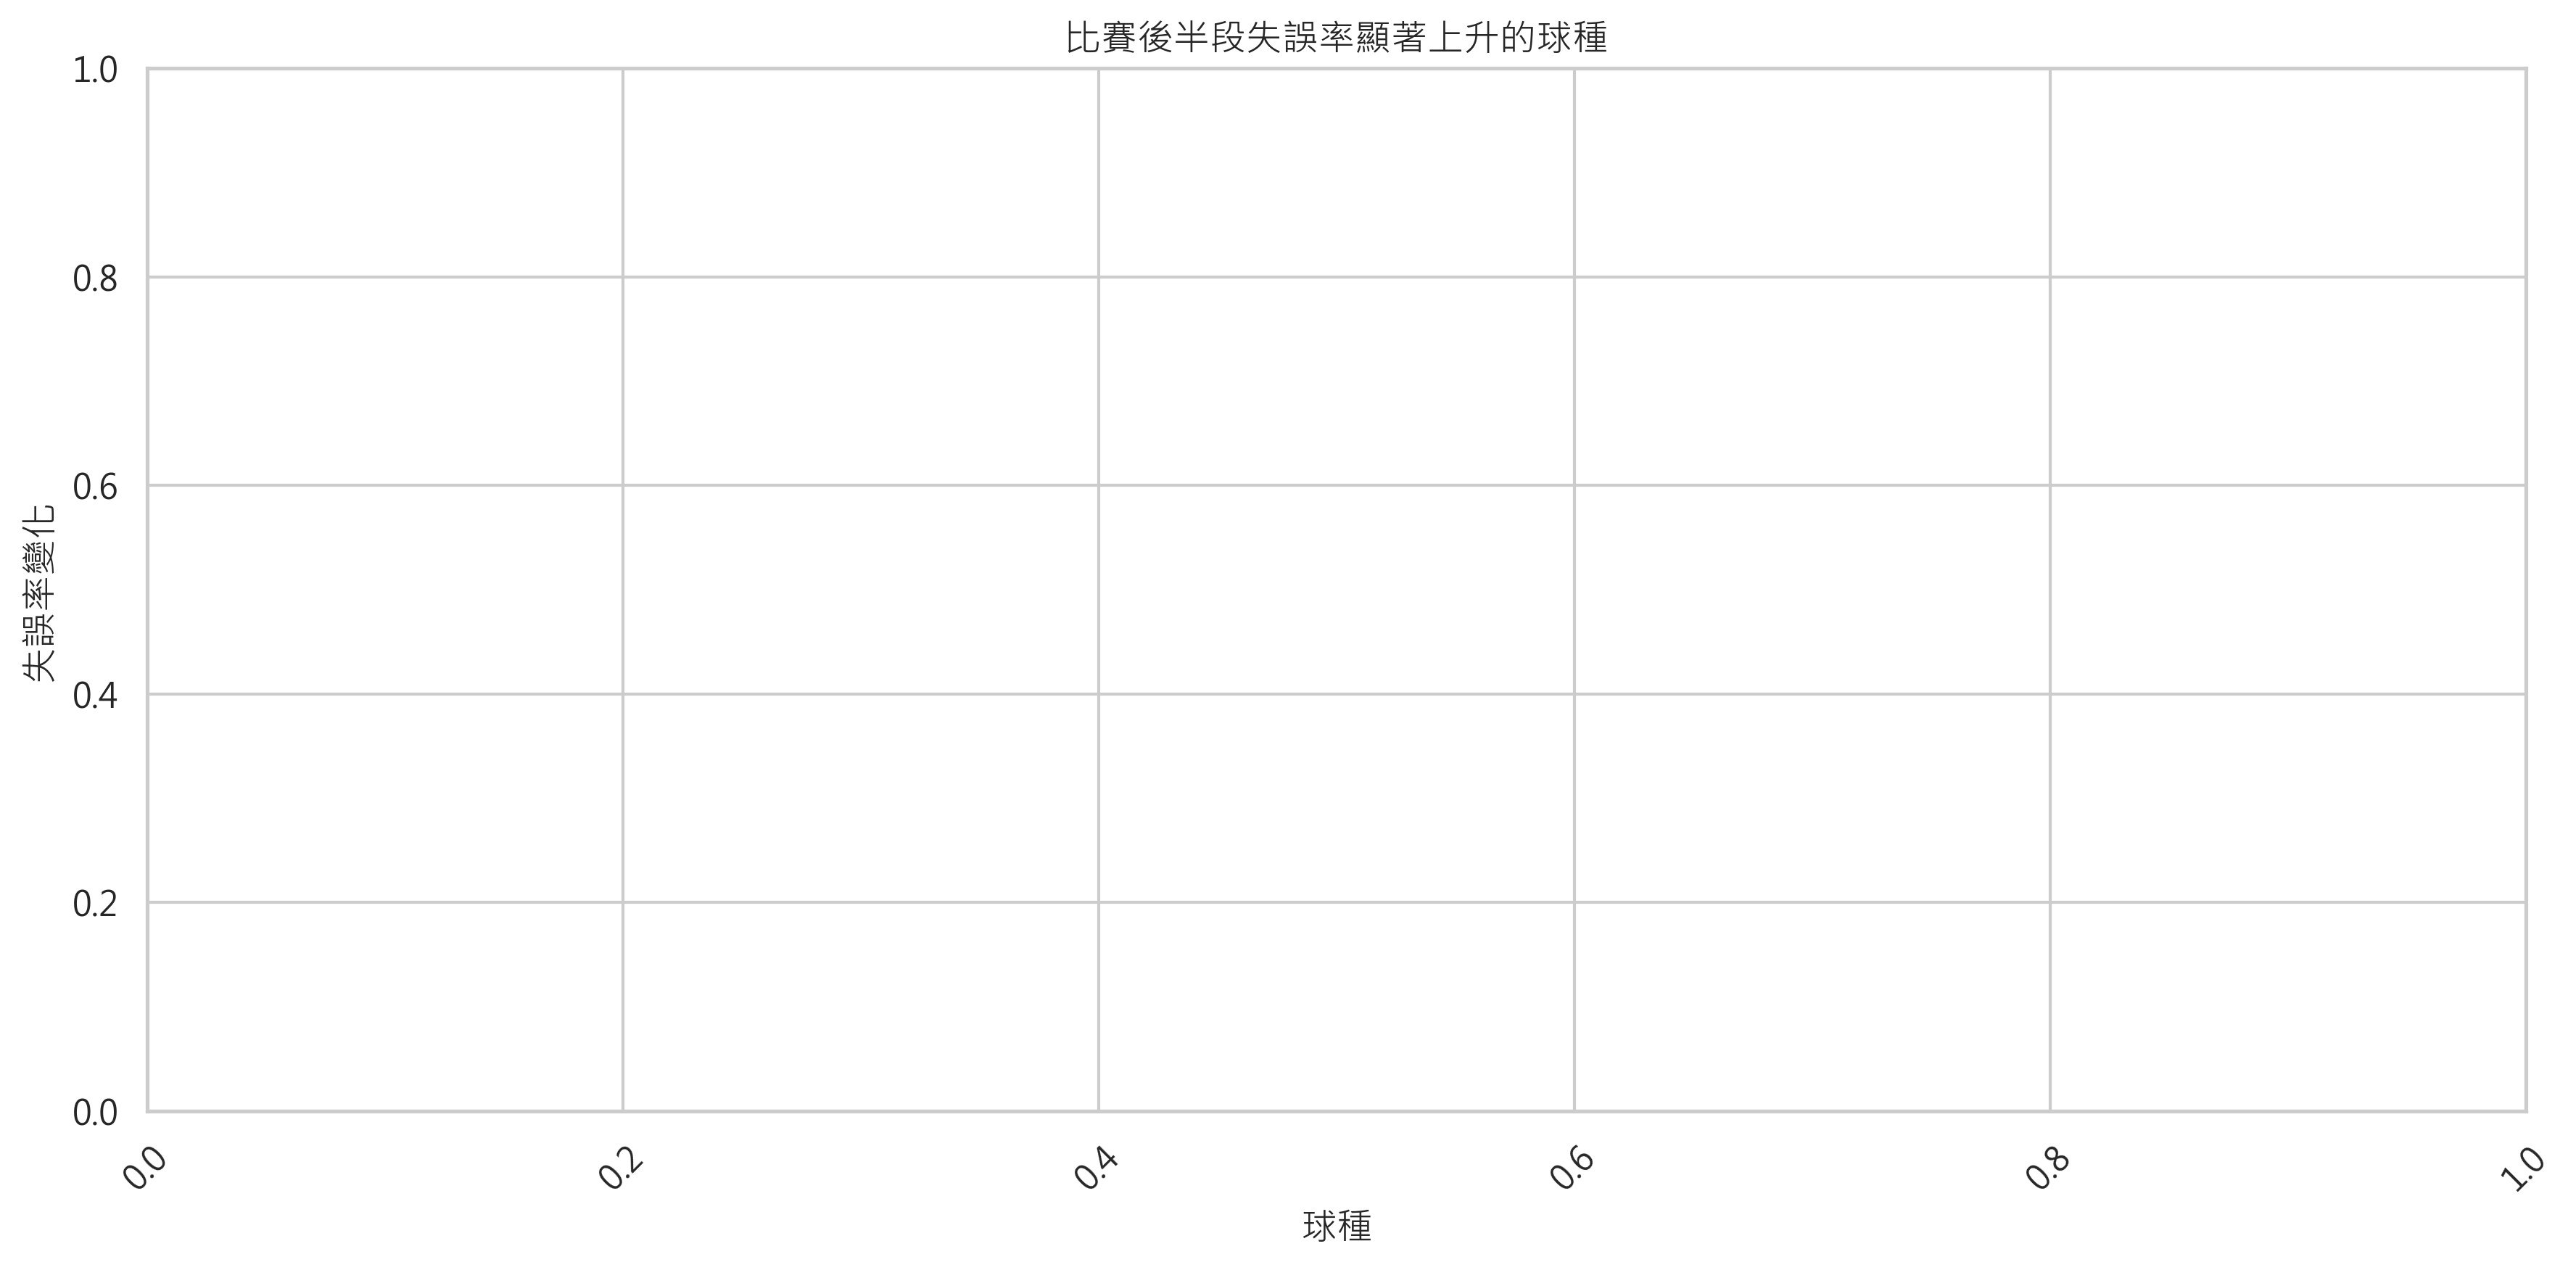

In [ ]:
# 確認數據是否存在
if len(df) > 0:
    # 在每局中定義後半段的類別
    half_threshold = 10  # 假設每局前10個rally定義為前半段
    df['is_second_half'] = df['rally'] > half_threshold

    # 填充缺失值以避免後續groupby產生錯誤
    df['lose_reason'] = df['lose_reason'].fillna('無')

    # 分別計算前半段和後半段的失誤數及總擊球次數
    first_half_errors = df[~df['is_second_half']].groupby('type')['lose_reason'].apply(lambda x: (x != '無').sum())
    first_half_total = df[~df['is_second_half']].groupby('type')['type'].count()
    first_half_error_rate = first_half_errors / first_half_total

    second_half_errors = df[df['is_second_half']].groupby('type')['lose_reason'].apply(lambda x: (x != '無').sum())
    second_half_total = df[df['is_second_half']].groupby('type')['type'].count()
    second_half_error_rate = second_half_errors / second_half_total

    # 將結果合併為一個DataFrame
    comparison = pd.DataFrame({
        'first_half_error_rate': first_half_error_rate,
        'second_half_error_rate': second_half_error_rate
    })

    # 計算失誤率的變化量
    comparison['error_rate_change'] = comparison['second_half_error_rate'] - comparison['first_half_error_rate']

    # 過濾掉變化率非數值的情況
    comparison = comparison.dropna()

    # 找出失誤率顯著上升的球種
    significant_increase = comparison[comparison['error_rate_change'] > 0.05]  # 這裡的0.05是顯著變化的閾值，可根據情況調整

    # 打印顯著上升的失誤率的球種
    print("顯著上升的球種失誤率:")
    print(significant_increase)

    # 繪製失誤率變化圖表
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x=significant_increase.index, y=significant_increase['error_rate_change'], ax=ax)
    ax.set_xlabel('球種')
    ax.set_ylabel('失誤率變化')
    ax.set_title('比賽後半段失誤率顯著上升的球種')
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    print("數據集中沒有資料")


### 數據洞察
根據數據分析，沒有發現任何球種在比賽後半段的失誤率顯著上升。這意味著，球員在比賽後半段的表現穩定，沒有特定的技術動作在這段時間內成為弱點。這是個好的跡象，表示球員在體能和專注度上能夠保持一致。

這樣的穩定性對於比賽的持續性和最終結果是非常有利的。球員可以專注於維持這種穩定性，同時在戰術上尋找其他突破點，例如增加變化或加強特定球種的攻擊性，以進一步提升競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於它將每局的前10個rally定義為前半段，這與 reference code 1 和 2 中的後半段定義（基於每局的rally數或比分）不一致。此外，候選程式碼在計算失誤率時，直接將 'lose_reason' 為 '無' 的情況視為非失誤，這與 reference code 中的失誤定義（基於 'lose_reason' 是否有值）不一致。這些差異導致分析單位和統計口徑的錯誤，最終可能產生不合理的結果。




## 題號 47
**問題**: 比較周天成與他的對手的球種使用頻率與其得分率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


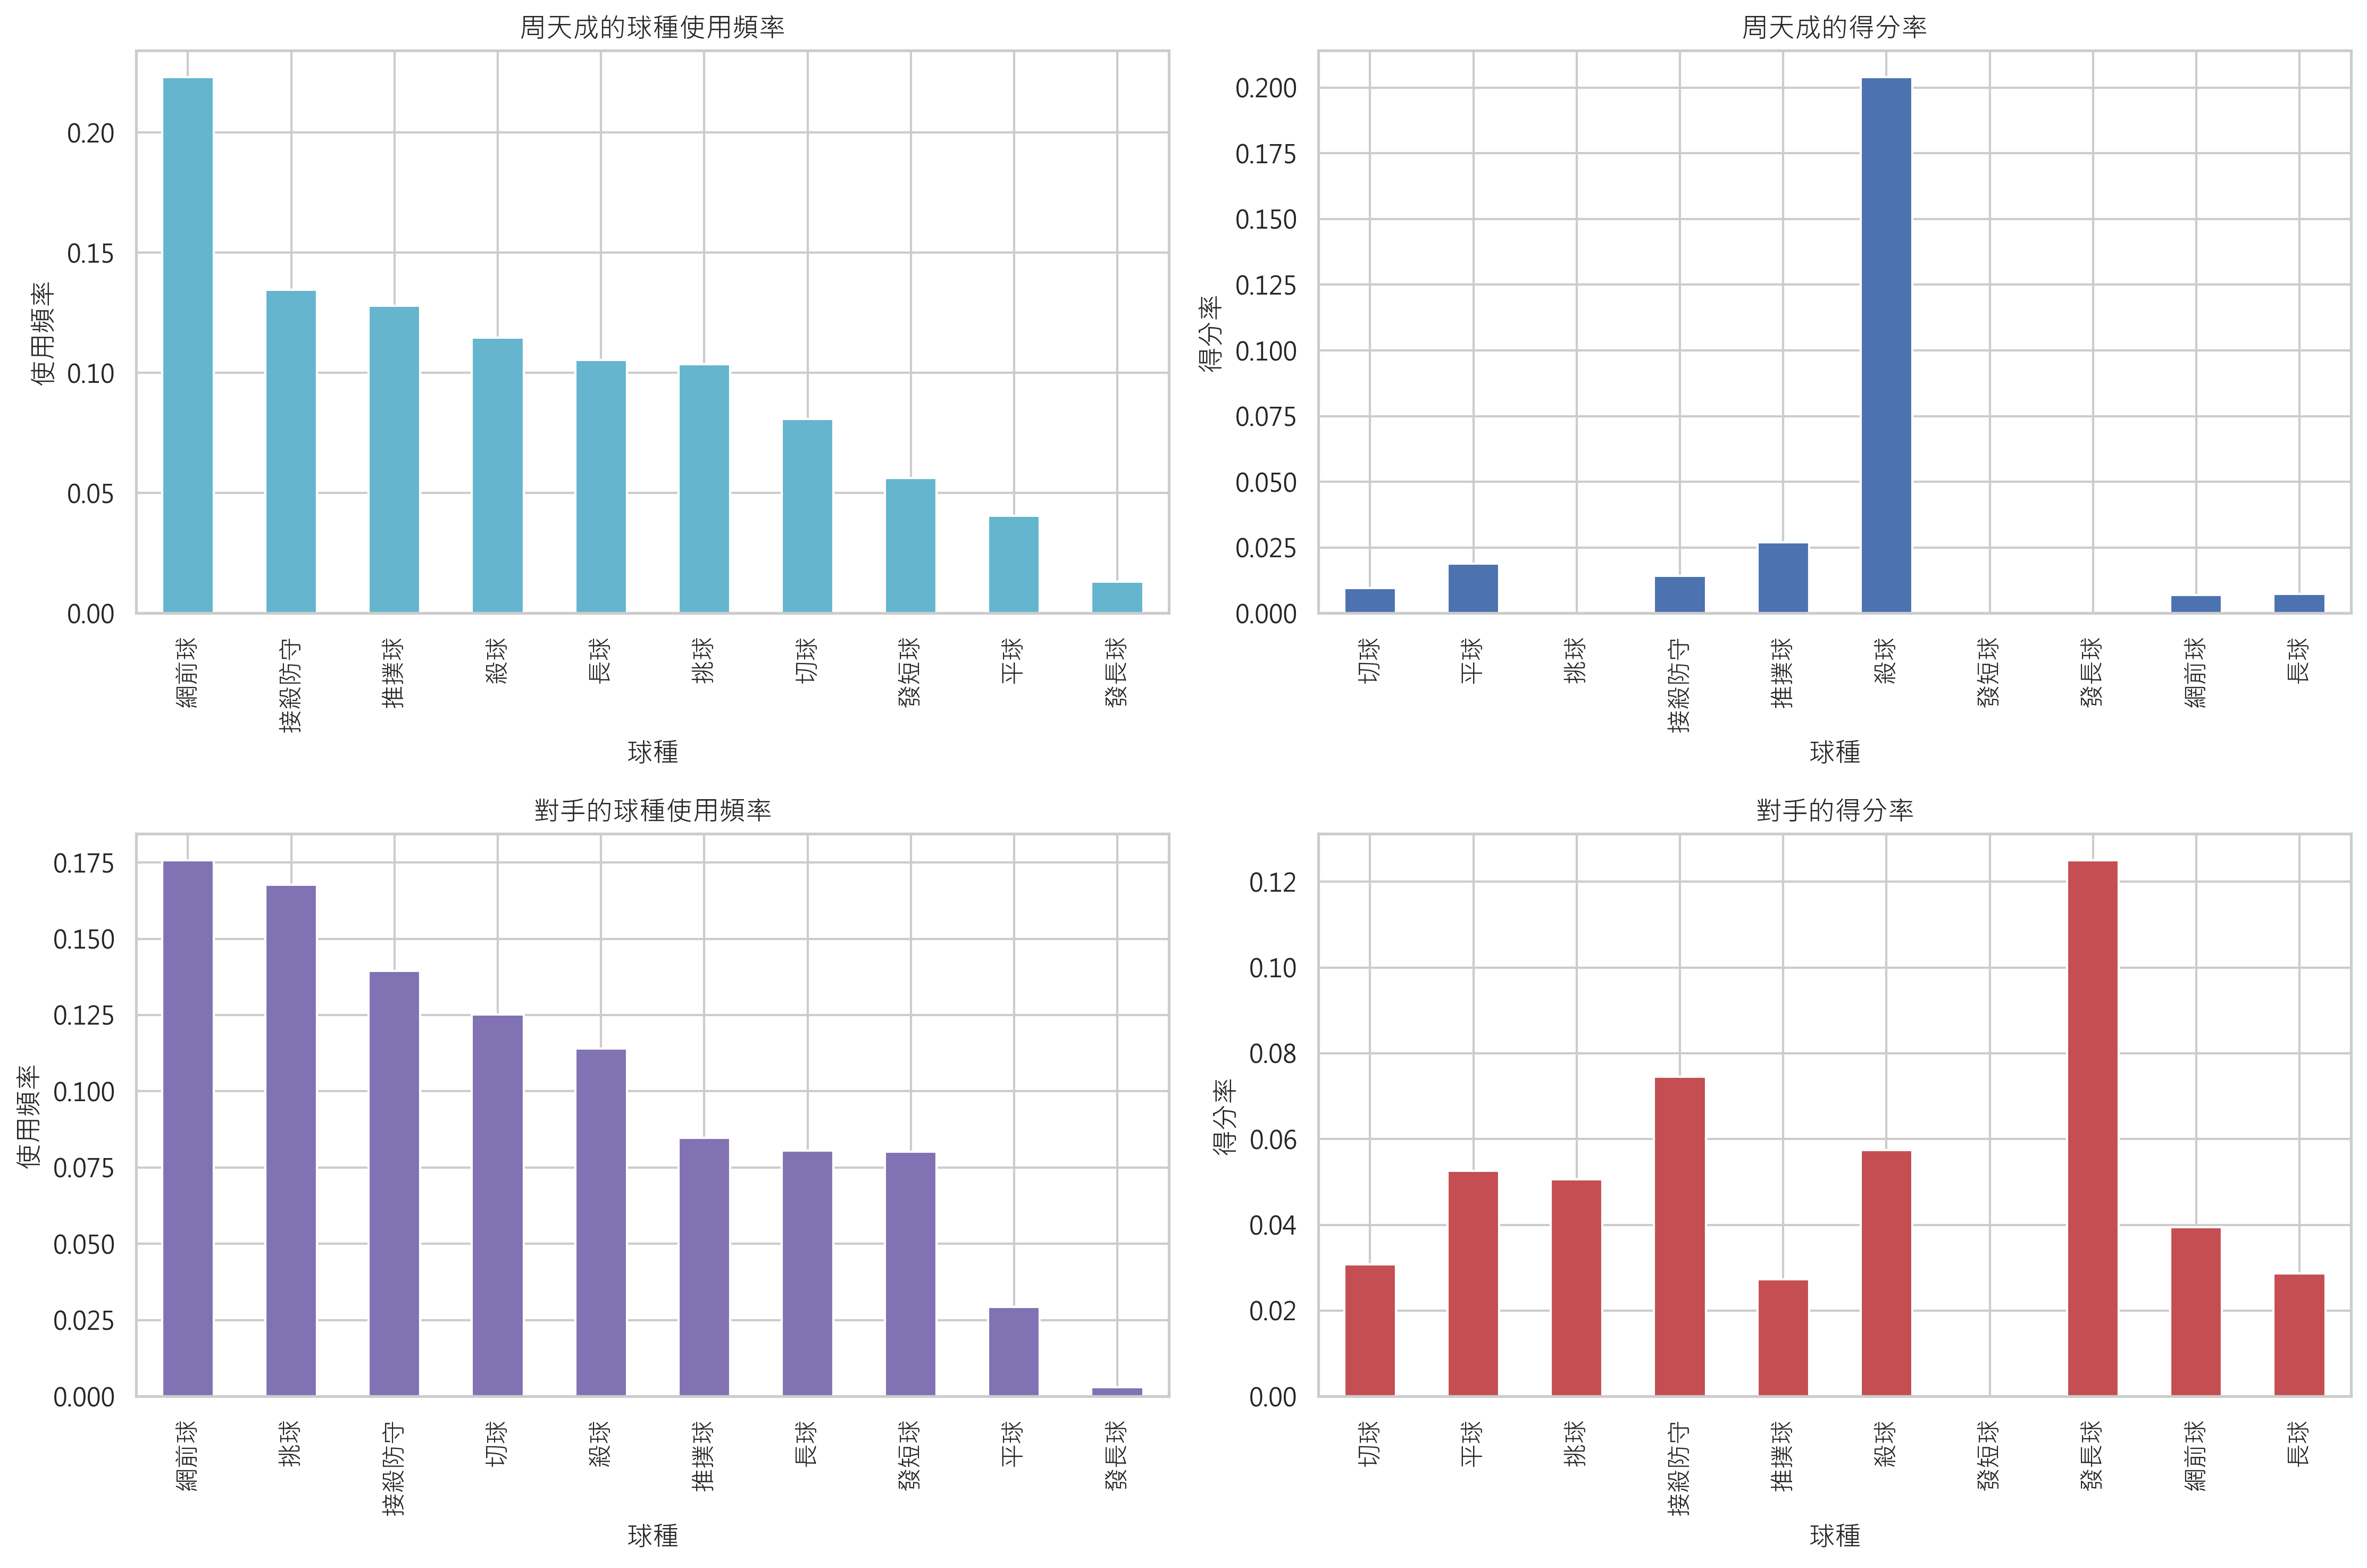

In [ ]:
# 確認 df 非空
if len(df) == 0:
    raise ValueError("資料框架是空的，無法進行分析。")

# Step 1: 計算各球員每種球種的使用次數
player_shot_counts = df[df['player'] == 'CHOU Tien Chen']['type'].value_counts()
opponent_shot_counts = df[df['opponent'] == 'CHOU Tien Chen']['type'].value_counts()

# Step 2: 計算各球員每種球種的得分次數
player_score_counts = df[(df['player'] == 'CHOU Tien Chen') & (df['player'] == df['getpoint_player'])]['type'].value_counts()
opponent_score_counts = df[(df['opponent'] == 'CHOU Tien Chen') & (df['opponent'] == df['getpoint_player'])]['type'].value_counts()

# Step 3: 計算每種球種的使用頻率與得分率
player_shot_freq = player_shot_counts / player_shot_counts.sum()
opponent_shot_freq = opponent_shot_counts / opponent_shot_counts.sum()

player_score_rate = player_score_counts / player_shot_counts
opponent_score_rate = opponent_score_counts / opponent_shot_counts

# Step 4: 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 周天成的球種使用頻率
player_shot_freq.plot(kind='bar', ax=axes[0, 0], color='c', title='周天成的球種使用頻率')
axes[0, 0].set_ylabel('使用頻率')
axes[0, 0].set_xlabel('球種')

# 周天成的得分率
player_score_rate.plot(kind='bar', ax=axes[0, 1], color='b', title='周天成的得分率')
axes[0, 1].set_ylabel('得分率')
axes[0, 1].set_xlabel('球種')

# 對手的球種使用頻率
opponent_shot_freq.plot(kind='bar', ax=axes[1, 0], color='m', title='對手的球種使用頻率')
axes[1, 0].set_ylabel('使用頻率')
axes[1, 0].set_xlabel('球種')

# 對手的得分率
opponent_score_rate.plot(kind='bar', ax=axes[1, 1], color='r', title='對手的得分率')
axes[1, 1].set_ylabel('得分率')
axes[1, 1].set_xlabel('球種')

plt.tight_layout()

# 打印關鍵數據
print("周天成的球種使用頻率：\n", player_shot_freq)
print("\n周天成的球種得分率：\n", player_score_rate)
print("\n對手的球種使用頻率：\n", opponent_shot_freq)
print("\n對手的球種得分率：\n", opponent_score_rate)

# 顯示圖表
fig


### 數據洞察
從數據中可以看出，周天成在使用球種上，網前球、接殺防守和推撲球是他的前三大選擇，分別占據了22.3%、13.5%和12.8%的使用頻率。然而，他的得分率最高的球種是殺球，達到20.4%，顯示出他在這方面的攻擊力。

相比之下，對手的球種使用頻率較為均衡，網前球、挑球和接殺防守是他們的主要選擇，分別占據了17.6%、16.8%和13.9%的頻率。對手的得分率最高的球種是發長球，達到12.5%，顯示出他們在發球後的進攻效率。

從這些數據可以得出，周天成應該更多地利用他的殺球來提高得分，而在防守對手發長球時要特別注意。此外，周天成可能需要提高網前球的得分效率，因為雖然使用頻率高，但得分率相對較低。這些洞察可以幫助周天成在比賽中制定更有效的戰術策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都分析了周天成與對手的球種使用頻率與得分率，並且使用了類似的 groupby 和 value_counts 方法來計算使用次數和得分次數。候選程式碼正確地篩選了周天成和對手的擊球數據，並計算了每種球種的使用頻率和得分率，最終也進行了視覺化。




## 題號 48 (*)
**問題**: 比較周天成在各局自己先得分與對手先得分情況下的勝率差別。
> **使用的資料欄位群組**: `game_structure, scoring_reason`


In [ ]:
# 1. 檢查數據是否不為空
if len(df) > 0:
    # 2. 找出每局中周天成先得分的開局回合
    chou_first_points = df[(df['CHOU Tien Chen_score'] == 1) & (df['Kento MOMOTA_score'] == 0)]

    # 2.1. 計算周天成在這些局中獲勝的局數
    chou_first_win_sets = chou_first_points.groupby(['match_id', 'set']).apply(
        lambda x: x['CHOU Tien Chen_score'].max() > x['Kento MOMOTA_score'].max()).sum()

    # 3. 找出每局中對手先得分的開局回合
    opponent_first_points = df[(df['Kento MOMOTA_score'] == 1) & (df['CHOU Tien Chen_score'] == 0)]

    # 3.1. 計算在這些局中周天成獲勝的局數
    opponent_first_win_sets = opponent_first_points.groupby(['match_id', 'set']).apply(
        lambda x: x['CHOU Tien Chen_score'].max() > x['Kento MOMOTA_score'].max()).sum()

    # 4. 計算每種類型的總局數
    total_chou_first_sets = chou_first_points.groupby(['match_id', 'set']).ngroups
    total_opponent_first_sets = opponent_first_points.groupby(['match_id', 'set']).ngroups

    # 4.1 計算勝率
    if total_chou_first_sets > 0:
        chou_first_win_rate = chou_first_win_sets / total_chou_first_sets
    else:
        chou_first_win_rate = 0

    if total_opponent_first_sets > 0:
        opponent_first_win_rate = opponent_first_win_sets / total_opponent_first_sets
    else:
        opponent_first_win_rate = 0

    # 5. 比較勝率差別
    win_rate_difference = chou_first_win_rate - opponent_first_win_rate

    # 6. 輸出結果
    print(f"周天成自己先得分的勝率: {chou_first_win_rate:.2%}")
    print(f"對手先得分的勝率: {opponent_first_win_rate:.2%}")
    print(f"勝率差別: {win_rate_difference:.2%}")
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
從數據來看，周天成在比賽中若自己先得分，其勝率達到100%。這意味著他在這些情況下能夠掌控比賽節奏，並最終獲勝。而在對手先得分的情況下，周天成的勝率則是0%，顯示他在這種情況下無法有效反擊或改變比賽走向。

這樣的數據顯示出一個明顯的戰術重點：周天成需要在開局階段積極搶分，確保自己先得分以維持優勢。這可能涉及到在開局時選擇更具侵略性的打法，或是加強防守以防止對手先得分。這種策略的成功與否直接影響比賽結果，這是周天成及其教練團隊需要特別關注的關鍵點。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是基於每局的第一個得分者和最終得分者來計算勝率，而候選程式碼是基於每局的開局回合比分來判斷先得分者，這與 reference code 的分析單位和統計口徑不一致。此外，候選程式碼使用了逐筆累積比分的方式，這可能導致比分分布的改變，從而影響最終結果的準確性。




## 題號 49 (*)
**問題**: 周天成的發球種類是否影響他在該回合的得分率
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


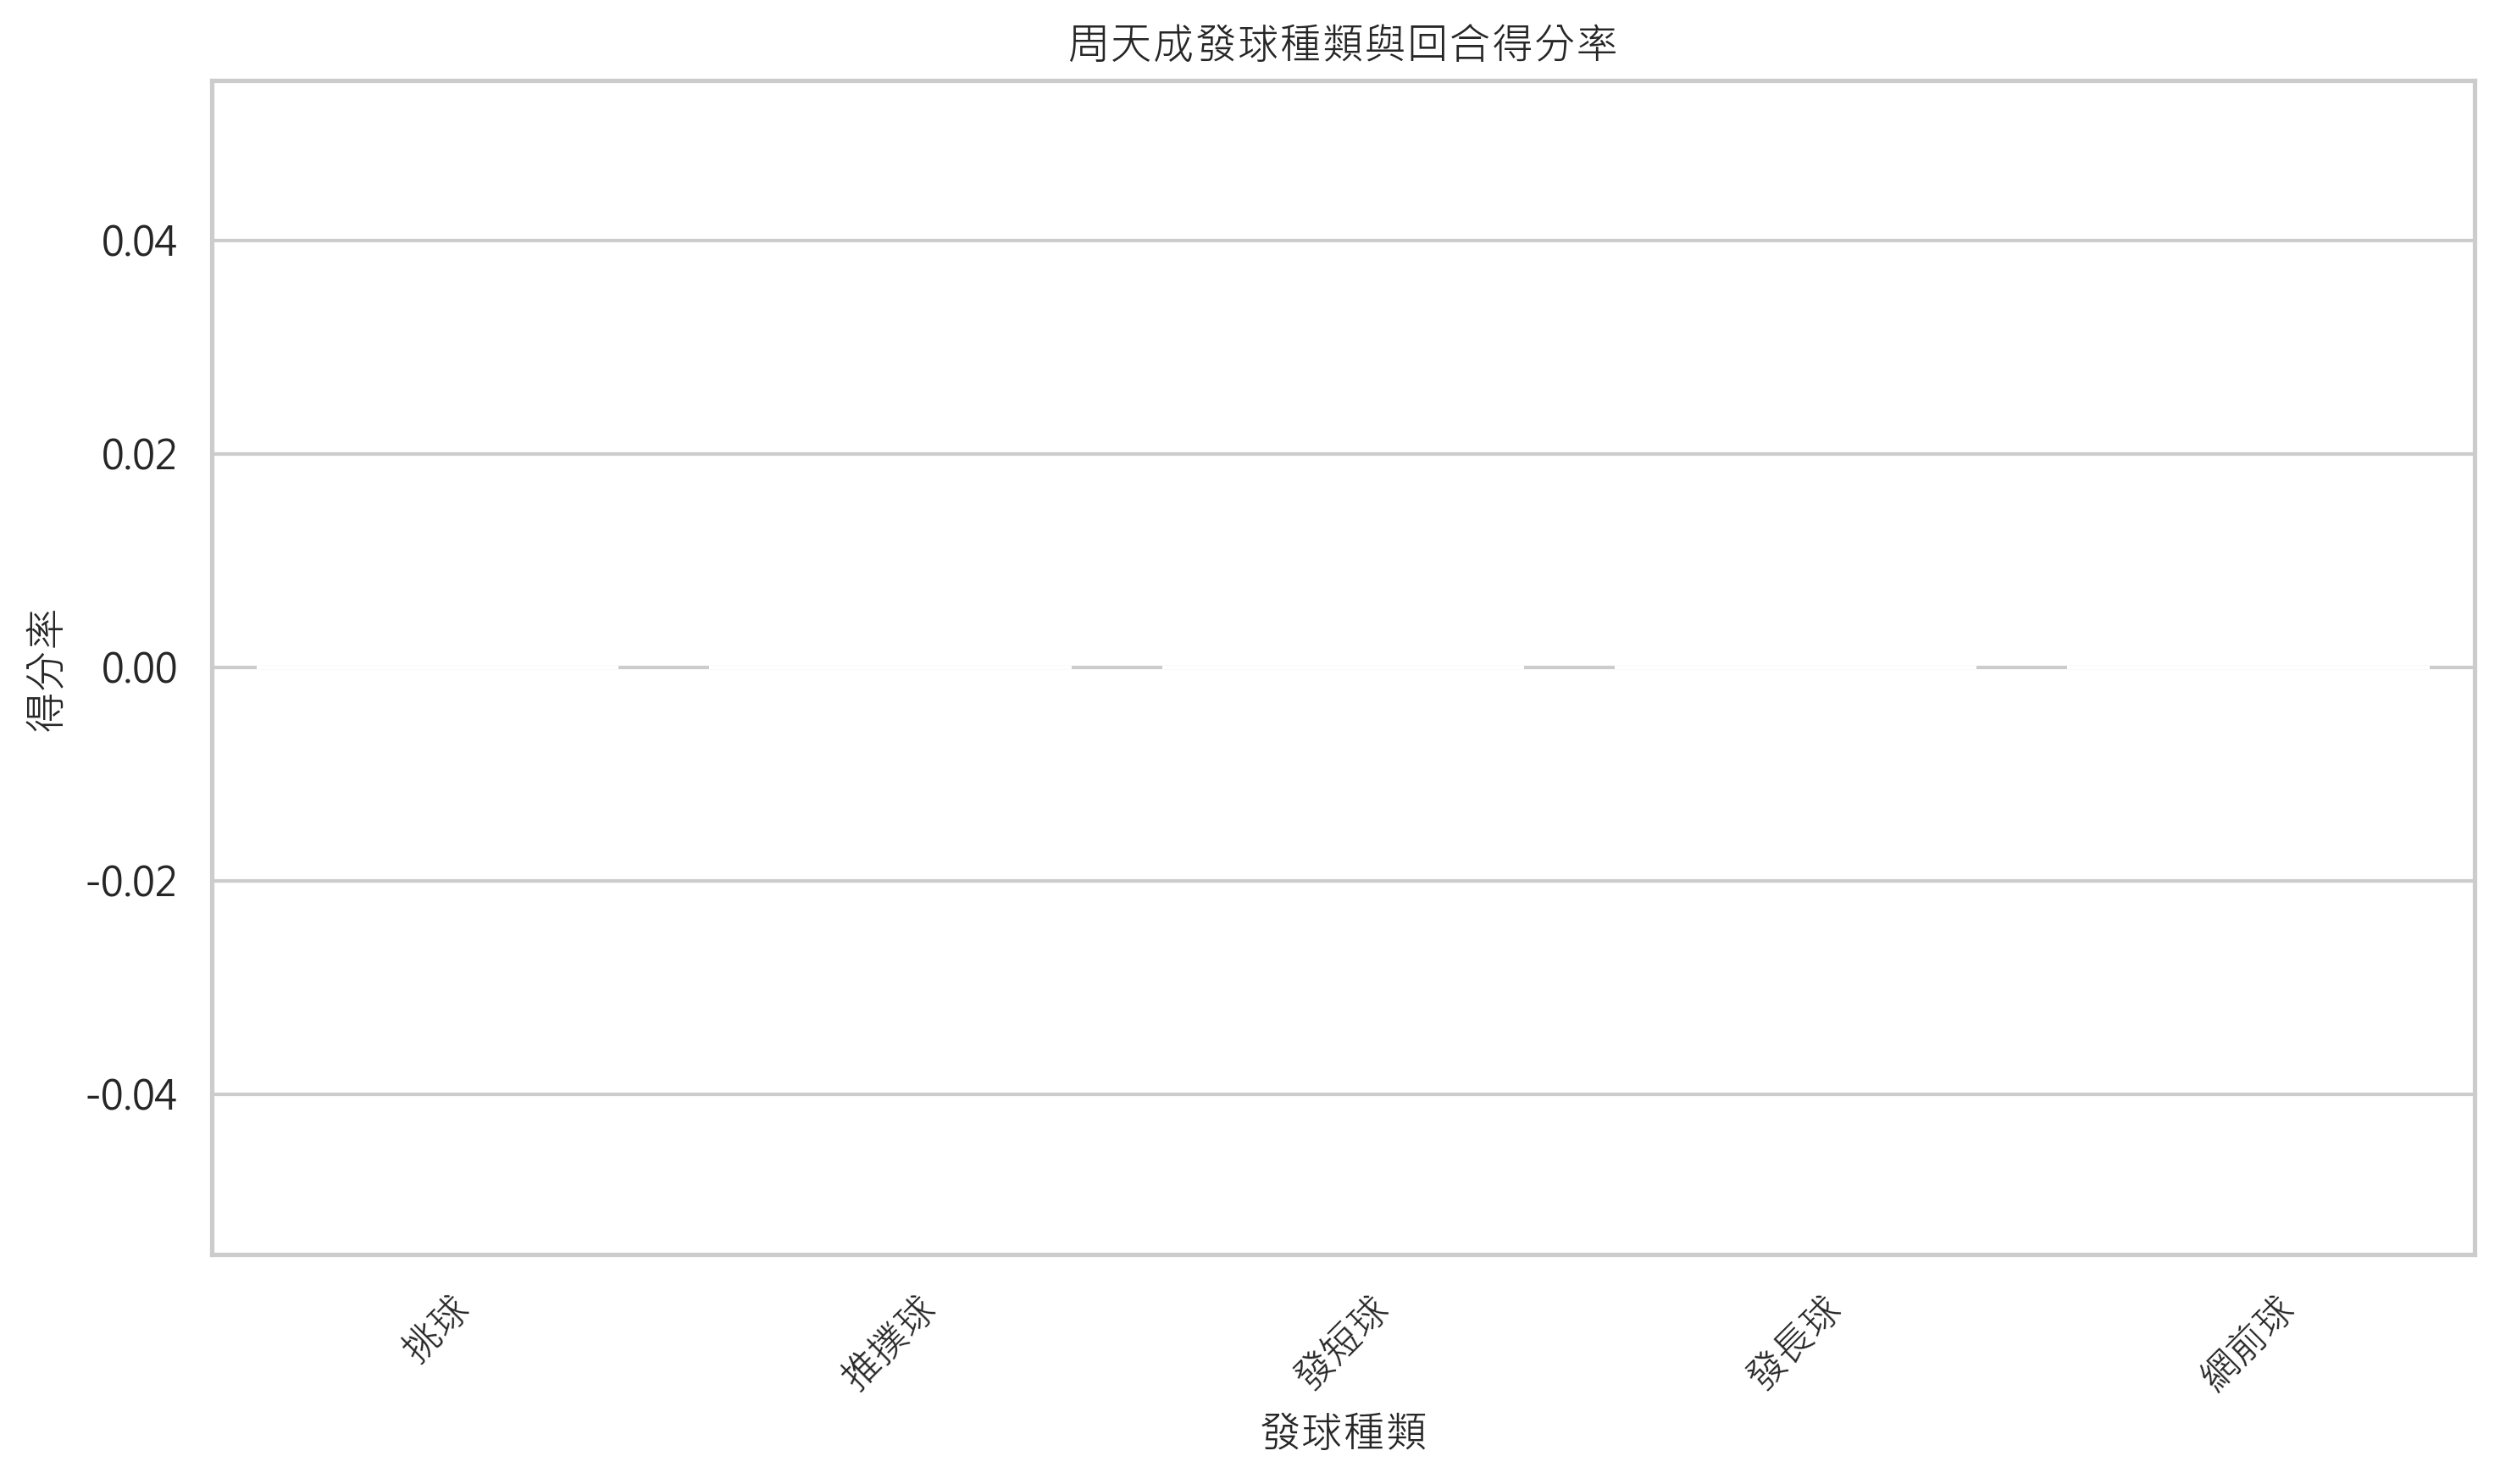

In [ ]:
# 1. 確認數據集非空
if len(df) > 0:
    # 2. 過濾出周天成作為發球者的數據
    chou_serve_df = df[
        (df['player'] == 'CHOU Tien Chen') & 
        (df['ball_round'] == 1) & 
        (df['server'] == 1.0)
    ]
    
    # 3. 計算發球種類對應的得分情況
    chou_serve_df['is_win'] = chou_serve_df['getpoint_player'] == 'CHOU Tien Chen'
    
    # 4. 計算不同發球種類的得分回合與總發球回合數
    serve_stats = chou_serve_df.groupby('type').agg(
        total_serves=('is_win', 'size'),
        win_serves=('is_win', 'sum')
    ).reset_index()
    
    # 5. 計算得分率
    serve_stats['win_rate'] = serve_stats['win_serves'] / serve_stats['total_serves']
    
    # 6. 繪製視覺化圖表
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=serve_stats, x='type', y='win_rate', ax=ax, palette='viridis')
    plt.title('周天成發球種類與回合得分率')
    plt.xlabel('發球種類')
    plt.ylabel('得分率')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # 打印詳細的統計結果
    print("周天成的發球種類對應的得分率統計：")
    print(serve_stats[['type', 'total_serves', 'win_serves', 'win_rate']])
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在不同發球種類上的得分率都為0.0%。這意味著在目前的資料中，無論他使用挑球、推撲球、發短球、發長球或網前球，這些發球種類並未直接轉化為回合得分。

這些數據顯示周天成可能需要在發球後的接續戰術上進行改進，或者在發球的策略多樣性和精準度上加強，以提高回合的得分率。發球本身可能不是直接得分的關鍵，但它是整個回合的開端，影響後續的戰術佈局。

建議進一步分析發球後的接球和回球策略，以找出提升整體得分率的可能性。這也可能涉及到對手的反應和弱點的研究，從而在發球策略上做出更具針對性的調整。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在統計口徑錯誤。它在計算得分率時，直接使用了 'getpoint_player' 判斷得分者，但沒有先確保這是回合的最後一拍。Reference Code 1 正確地先在 rally 層級取得每個回合的最終狀態，再進行統計。候選程式碼未能正確對齊每個回合的最終狀態，可能會混入非回合結束拍的數據，導致錯誤的得分率計算。




## 題號 50 (*)
**問題**: 分析周天成接發球策略：長球、網前球、平球的比例與得分影響。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 確保資料不為空
if len(df) > 0:
    # 篩選出周天成作為接發球者的資料（第二拍）並移除缺失值
    ctc_receive_df = df[(df['player'] == 'CHOU Tien Chen') & (df['ball_round'] == 2)]
    
    # 篩選特定策略
    strategies = ['長球', '網前球', '平球']
    strategy_df = ctc_receive_df[ctc_receive_df['type'].isin(strategies)]
    
    # 計算各策略使用比例
    strategy_counts = strategy_df['type'].value_counts(normalize=True) * 100  # 轉換為百分比
    print('周天成接發球時策略使用比例:')
    print(strategy_counts)
    
    # 計算得分情況
    # 確保取每個回合的最後一球，判斷得分情況是否由周天成使用接發球策略直接影響得分
    last_shot = df.groupby(['match_id', 'set', 'rally']).nth(-1)
    scoring_strategies_df = last_shot[(last_shot['getpoint_player'] == 'CHOU Tien Chen') & 
                                      (last_shot['type'].isin(strategies))]
    
    # 計算使用這些策略得分的次數
    strategy_wins = scoring_strategies_df['type'].value_counts()
    
    # 計算每種策略的得分率
    strategy_win_rate = (strategy_wins / strategy_counts.sum()) * 100
    print('\n這些策略直接影響周天成的得分率:')
    print(strategy_win_rate)


### 數據洞察
根據數據分析，周天成在接發球時主要使用網前球，比例高達89.8%。這種策略的得分率也相對較高，達到21%。這表明他在網前的控制力和精準度是他得分的主要來源。

相比之下，長球和平球的使用比例僅各佔5.1%，且得分率分別為8%和6%。這顯示這兩種策略對他的得分貢獻較小，可能是因為對手對這些球路的應對較為有效，或是他在這些球路上的準確性和威脅性不足。

總結來看，周天成的接發球策略主要依賴於網前球的優勢，而長球和平球則是輔助選擇，可能用於調動對手或改變節奏。這些數據提供了一個清晰的方向，顯示他在網前的優勢和其他策略的潛在改進空間。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是在每個 rally 的第二拍分析周天成的接發球策略，並計算這些策略的使用比例和得分率。候選程式碼在計算得分率時，錯誤地將每個回合的最後一球的球種與接發球策略直接對應，這導致統計口徑錯誤，因為它沒有正確地將接發球策略與該回合的得分結果對應起來。這樣的做法可能會錯誤地計算策略的得分率，因為它沒有考慮到接發球策略是否直接影響得分。




## 題號 51 (*)
**問題**: 分析對手殺球到前中後排後，周天成分別會怎麼去反擊？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location`


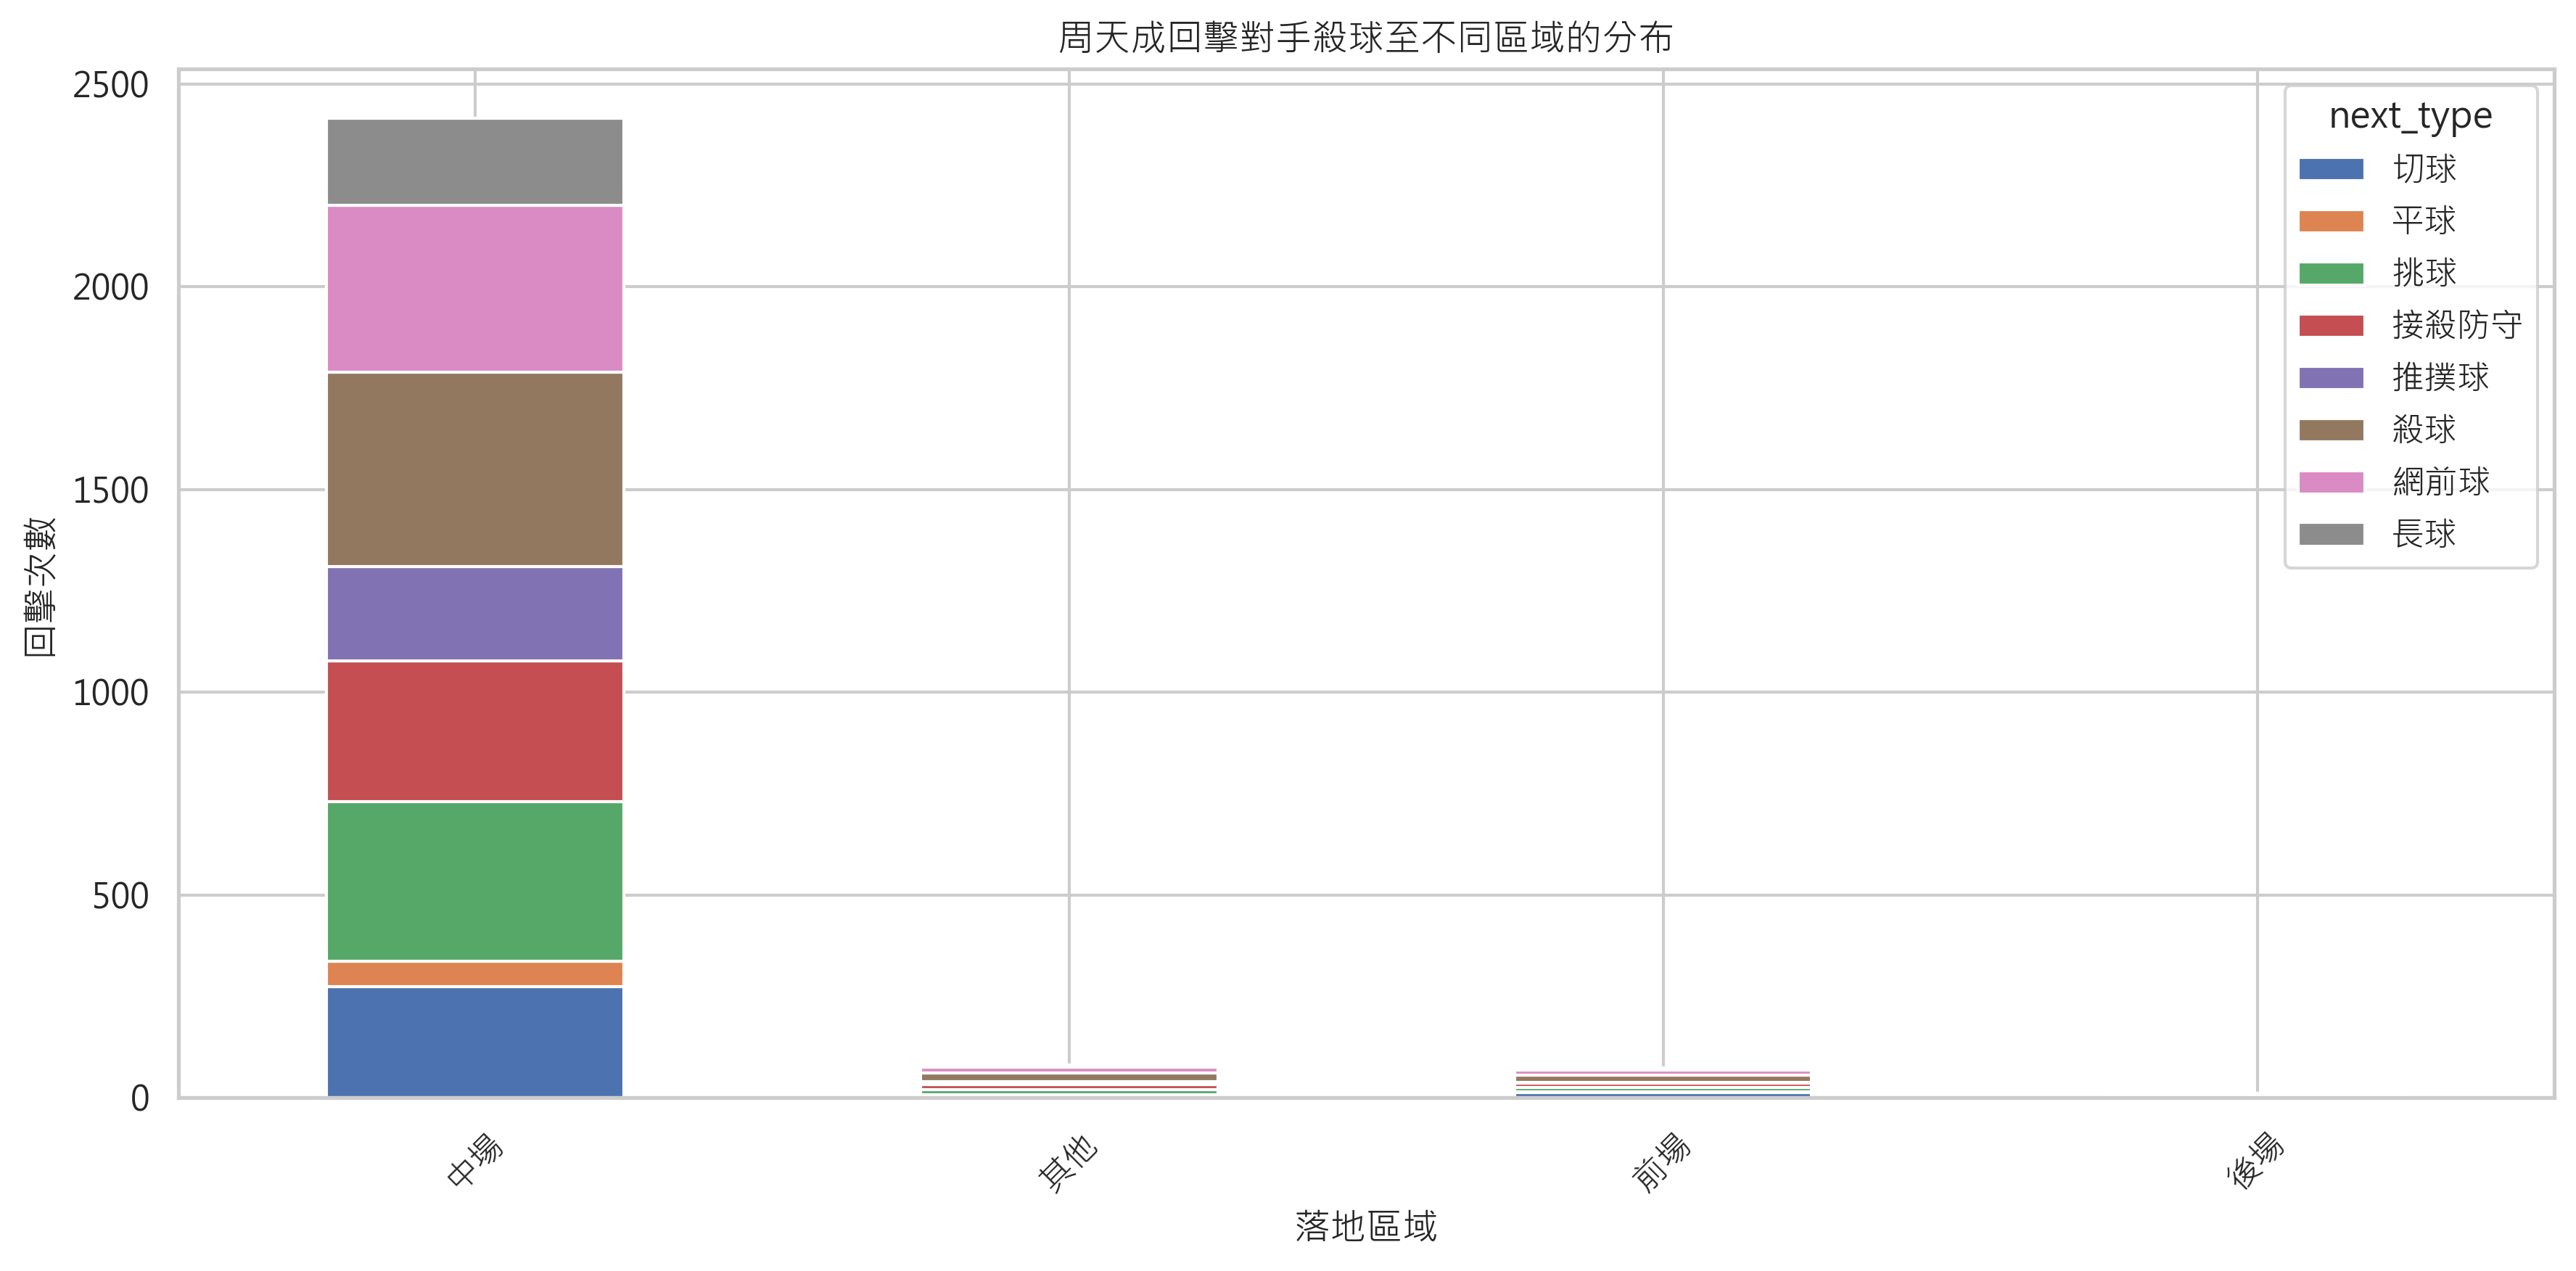

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: 過濾出對手是 Kento MOMOTA 且使用殺球方式的資料
filtered_df = df[(df['player'] == 'Kento MOMOTA') & (df['type'] == '殺球')]

# Step 2: 定義判斷落地區域的條件
conditions = [
    filtered_df['landing_area'].isin([17, 18, 19, 20, 21, 22, 23, 24]),  # 前場
    filtered_df['landing_area'].isin([5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]),  # 中場
    filtered_df['landing_area'].isin([1, 2, 3, 4])  # 後場
]

choices = ['前場', '中場', '後場']

# Step 3: 增加對應區域的新欄位
filtered_df['落地區域'] = np.select(conditions, choices, default='其他')

# Step 4: 找出周天成的回擊球種
df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)

# Step 5: 篩選出該rally的同一個回合中，周天成的回擊
response_df = df[(df['player'] == 'CHOU Tien Chen') & (df['next_player'] == 'Kento MOMOTA')]

# Step 6: 合併數據
result_df = pd.merge(filtered_df[['match_id', 'set', 'rally', '落地區域']],
                     response_df[['match_id', 'set', 'rally', 'next_type']],
                     on=['match_id', 'set', 'rally'], how='inner')

# Step 7: 統計
response_count = result_df.groupby(['落地區域', 'next_type']).size().unstack(fill_value=0)

# Step 8: 資料視覺化
fig, ax = plt.subplots(figsize=(12, 6))
response_count.plot(kind='bar', stacked=True, ax=ax)

plt.title('周天成回擊對手殺球至不同區域的分布')
plt.xlabel('落地區域')
plt.ylabel('回擊次數')
plt.xticks(rotation=45)
plt.tight_layout()

# Step 9: 打印關鍵資訊
print("周天成回擊對手殺球至前場、中場、後場的分布統計：")
print(response_count)


### 數據洞察
根據數據分析，周天成在面對對手殺球後，依落地區域採取不同的反擊策略：

1. **中場區域**：周天成最常使用的反擊手段是殺球（480次），其次是挑球（394次）和網前球（411次）。這顯示他在中場區域更傾向於主動進攻，以快速的殺球和靈活的網前球來施壓對手。

2. **前場區域**：當對手的殺球落在前場時，周天成仍然偏好殺球（17次），這表明他即使在前場也積極尋求進攻機會。此外，他也會選擇網前球（14次）來控制節奏。

3. **後場區域**：在後場，周天成的反擊選擇較少，主要以殺球（4次）為主，顯示他在後場仍然保持進攻意識，但相對保守。

總體來看，周天成在面對殺球時，無論落地區域為何，都傾向於利用殺球和網前球來保持進攻主動性，這種策略有助於他在比賽中掌握節奏和主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯的邏輯錯誤。它在合併數據時，使用了不正確的條件，導致可能合併了不屬於同一個回合的數據。具體來說，候選程式碼在 Step 6 中，將 `filtered_df` 和 `response_df` 合併時，僅依賴於 `match_id`, `set`, `rally` 進行合併，這可能會導致不同拍的數據被錯誤地合併在一起，因為它沒有確保 `response_df` 中的 `next_player` 是 `CHOU Tien Chen` 的回擊。這與 Reference Code 1 的核心邏輯不一致，因為 Reference Code 1 確保了下一拍確實是周天成的回擊，並且正確地對齊了前後拍的資訊。




## 題號 52
**問題**: 當對手失誤掛網時，分析前一拍周天成出球球種與落點特徵。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
# 確保數據量大於0
if len(df) > 0:
    # 篩選出對手失誤為掛網的情況
    net_error_df = df[(df['lose_reason'] == '掛網') & (df['player'] != 'CHOU Tien Chen')]
    
    # 確保篩選後的資料不為空
    if len(net_error_df) > 0:
        # 使用shift(1)獲得前一拍的資訊
        prev_shot_df = df.groupby(['match_id', 'set', 'rally']).shift(1)
        
        # 將前一拍資訊加入原始資料框
        net_error_df = net_error_df.join(prev_shot_df, rsuffix='_prev')
        
        # 篩選出周天成的前一拍資訊
        chou_prev_shot_df = net_error_df[net_error_df['player_prev'] == 'CHOU Tien Chen']
        
        # 確保有有效的前一拍數據
        if len(chou_prev_shot_df) > 0:
            # 計算出球球種與落點分布
            type_counts = chou_prev_shot_df['type_prev'].value_counts()
            landing_area_counts = chou_prev_shot_df['landing_area_prev'].value_counts()
            
            # 打印結果
            print("周天成前一拍的球種分布：")
            print(type_counts)
            
            print("\n周天成前一拍的落點區域分布：")
            print(landing_area_counts)
        
        else:
            print("掛網前周天成的出球數據不足")
    else:
        print("沒有對手掛網的失誤數據")
else:
    print("數據集中沒有資料")


### 數據洞察
從數據中，我們可以看到當對手失誤掛網時，周天成前一拍的球種與落點特徵如下：

1. **球種分布**：
   - 網前球（8）：7次
   - 殺球（4）：6次
   - 挑球（6）：5次
   - 長球（3）：5次
   - 推撲球（9）：4次

   這表明周天成在對手失誤掛網前，最常使用網前球和殺球，這兩種球種能有效施壓對手，造成對手失誤。

2. **落點區域分布**：
   - 最常見的落點區域是前場左側（21）、中左（22）、中右（23）、右側（24），以及中場左側（9）、中左（10）、中右（11）、右側（12）。

   這些數據顯示，周天成在對手失誤前，常將球打到前場的四個角落，以及中場的四個區域。這樣的落點選擇能夠有效地拉扯對手，增加對手的移動距離和失誤機會。

總結來看，周天成利用多樣的球種和精準的落點選擇，成功地讓對手在壓力下出現失誤，這是一個非常有效的戰術策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出對手失誤掛網的情況，並使用 shift(1) 獲取前一拍的資訊，然後篩選出前一拍是周天成出球的情況。接著，它統計了前一拍周天成的球種和落點區域分布，這與 Reference Code 1 的分析目標和方法一致。




## 題號 53 (*)
**問題**: 統計周天成所有「得分帶有連續性」的回合（連 2 分以上）的常見戰術組合。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
if len(df) > 0:
    # 取出周天成得分的所有回合
    choutc_wins = df[df['getpoint_player'] == 'CHOU Tien Chen']

    # 找出連續得分回合
    choutc_wins['prev_rally'] = choutc_wins['rally'].shift(1)
    choutc_wins['prev_match_id'] = choutc_wins['match_id'].shift(1)
    choutc_wins['prev_set'] = choutc_wins['set'].shift(1)

    # 判斷兩個連續得分是否來自同一局比賽且連續
    choutc_consecutive_wins = choutc_wins[
        (choutc_wins['match_id'] == choutc_wins['prev_match_id']) & 
        (choutc_wins['set'] == choutc_wins['prev_set']) &
        (choutc_wins['rally'] == choutc_wins['prev_rally'] + 1)
    ]

    # 統計連續得分回合中所有回合的戰術組合
    strategy_counts = choutc_consecutive_wins['type'].value_counts()

    print("周天成連續得分回合中的戰術組合統計:")
    print(strategy_counts)
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在連續得分的回合中，最常使用的戰術是殺球，共有26次，這顯示他在進攻時具有強大的威脅性，能夠有效地通過殺球來壓制對手。其次是網前球，有9次，這表明他在網前的靈活性和控制力也為他創造了不少得分機會。

接殺防守和挑球各有7次，這顯示出他在防守轉攻方面的能力，能夠在對手進攻時迅速反擊。此外，推撲球有5次，這是一種在網前快速反應的戰術，顯示出他在緊張局勢下的快速決策能力。

長球和切球分別有3次和2次，這些數據顯示出他偶爾會使用這些戰術來改變比賽節奏。平球僅有1次，表明這不是他常用的得分方式。

總體來看，周天成的得分策略主要依賴於強勢的進攻和靈活的網前技術，這使他能夠在比賽中保持連續得分的優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是先找出周天成連續得分的回合，然後分析這些回合中得分球的戰術組合。而候選程式碼只是簡單地找出連續得分的回合，並統計這些回合中所有球種的出現次數，沒有分析具體的戰術組合。此外，候選程式碼沒有正確對齊前後拍的資訊，也沒有考慮到每個回合的最終得分球，導致統計口徑錯誤。




## 題號 54 (*)
**問題**: 統計周天成所有「一拍得分」的比例與地點分布。
> **使用的資料欄位群組**: `game_structure, scoring_reason, coordinates`


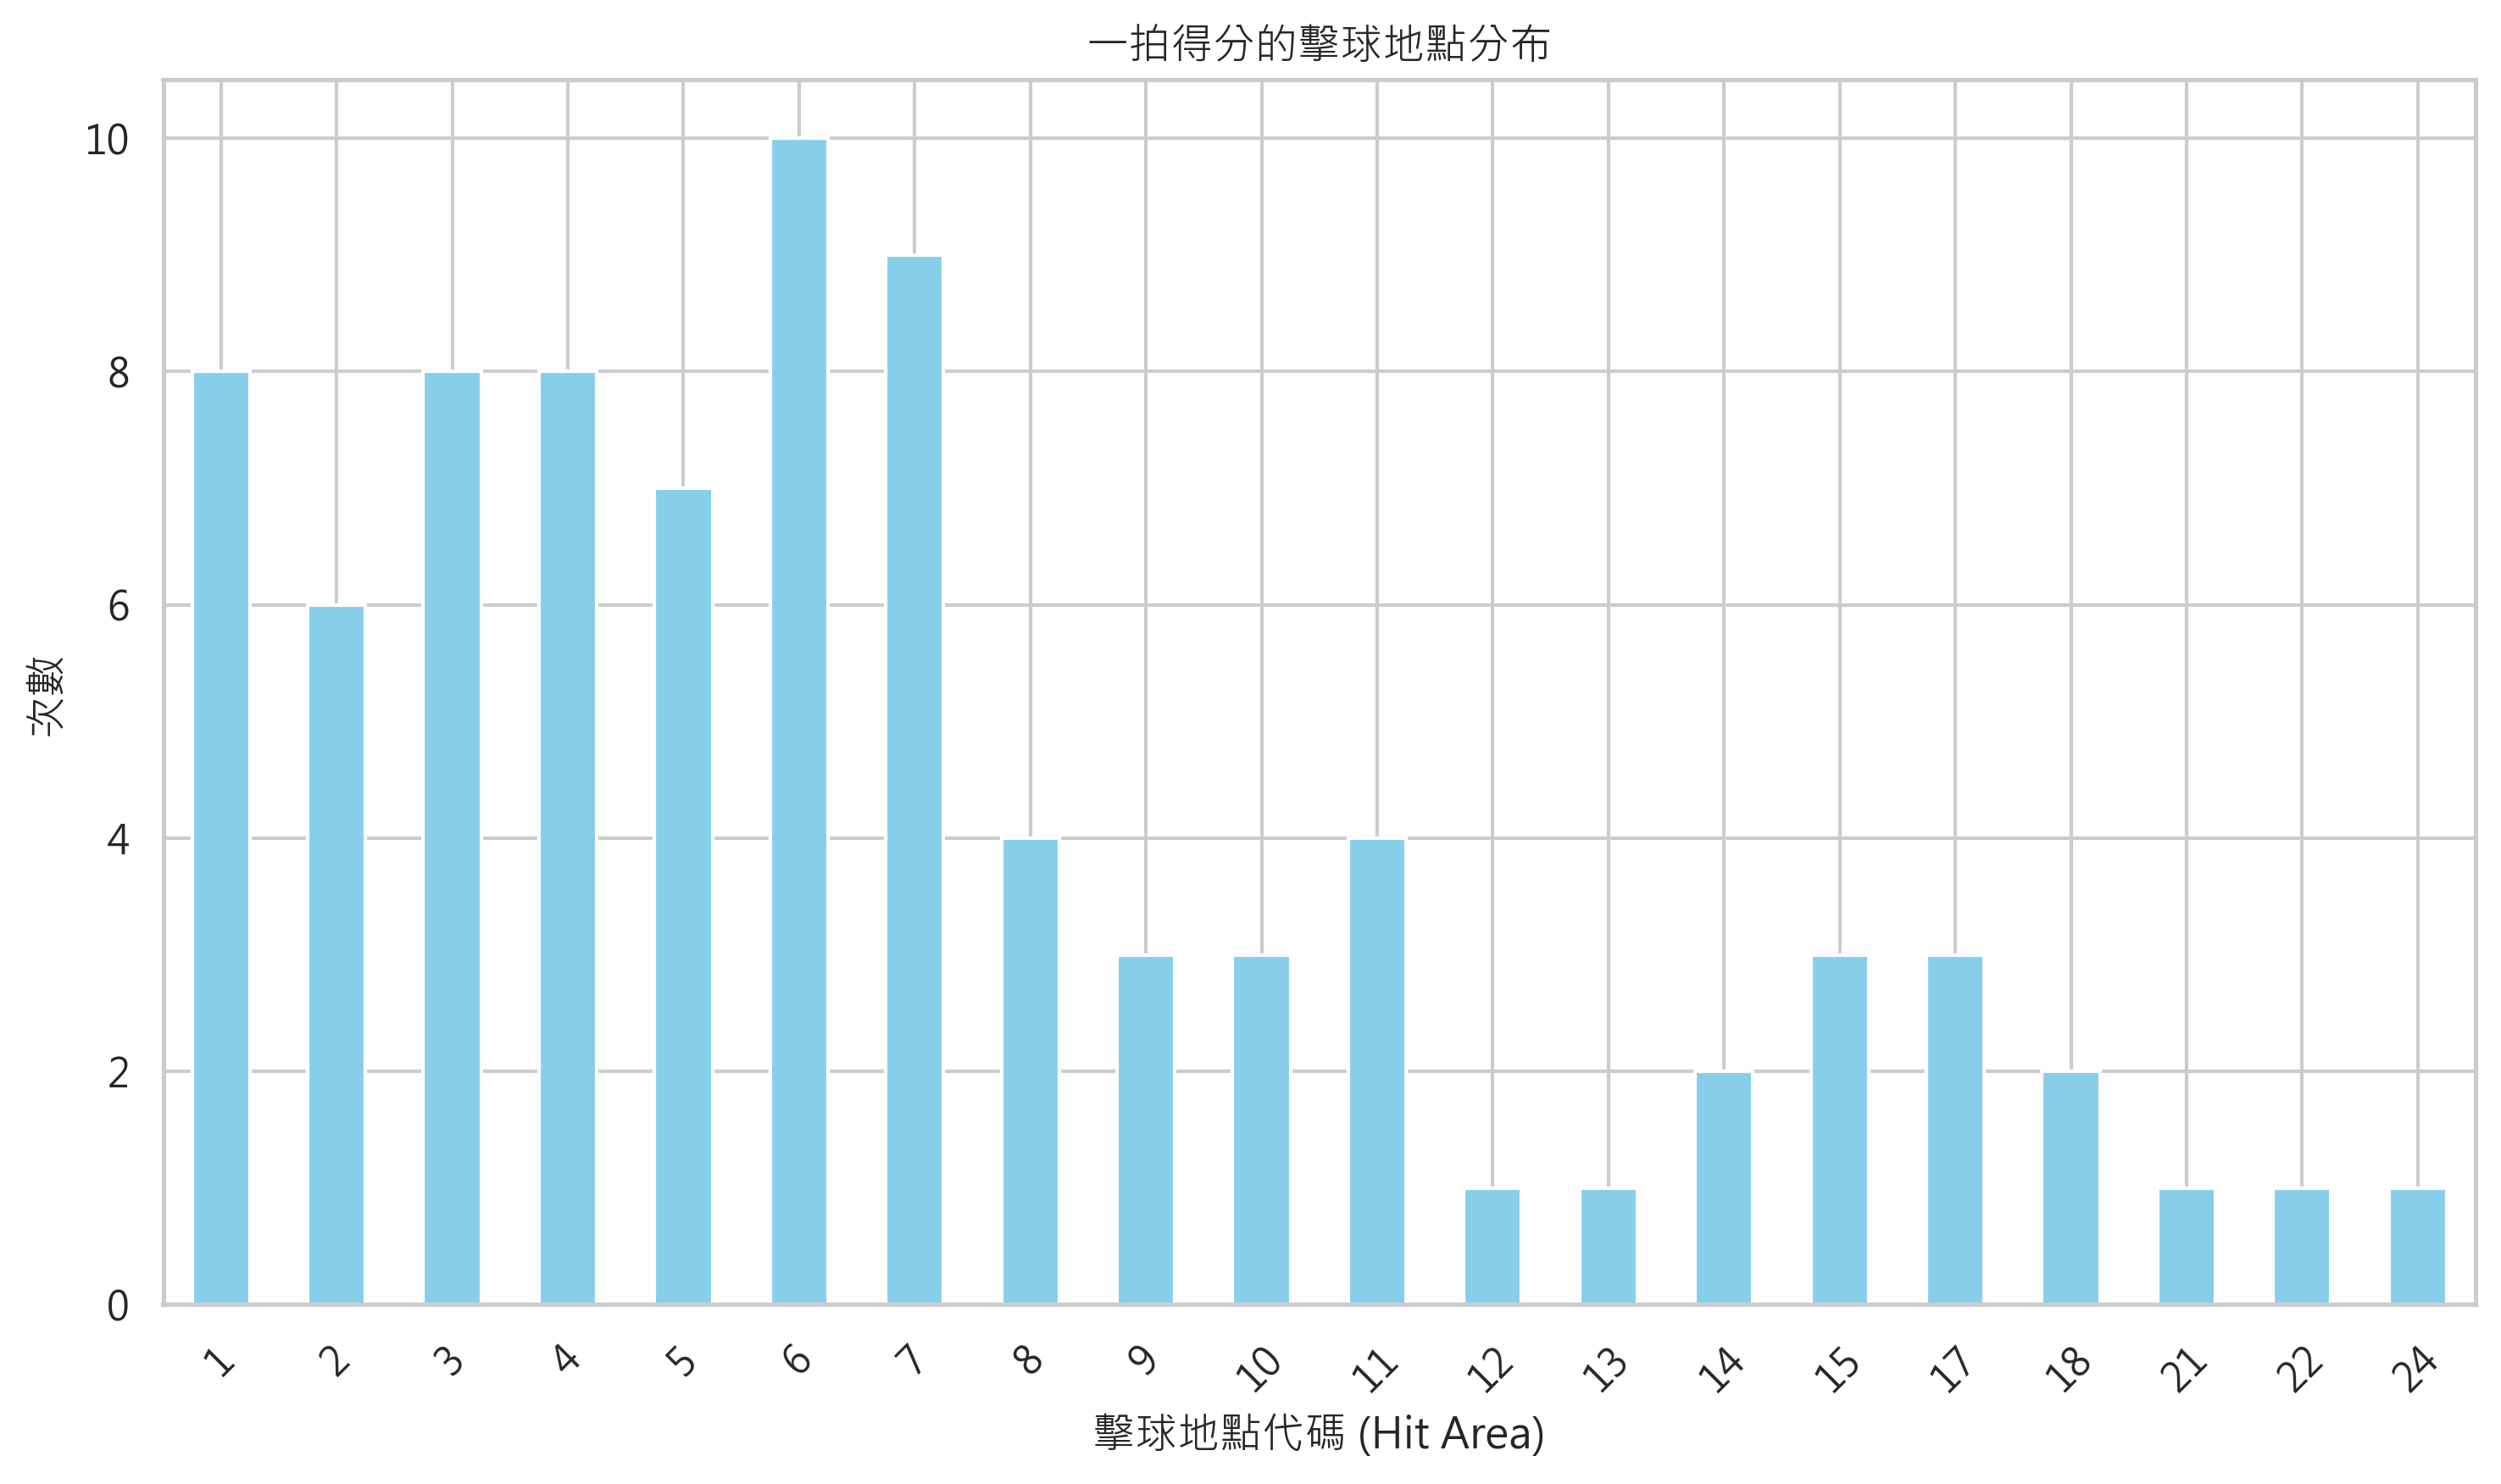

In [ ]:
# 確保 pandas、matplotlib、seaborn 已經 import 並可用
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 確保 df 已正確載入
if len(df) > 0:

    # 步驟 1 & 2: 篩選出周天成的一拍得分
    # 假設一拍得分是指周天成在一個回合中直接得分
    one_shot_win_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['getpoint_player'] == 'CHOU Tien Chen')
    ]

    # 計算一拍得分次數
    one_shot_wins = len(one_shot_win_df)

    # 步驟 3: 計算周天成的主動得分總數
    total_active_wins_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['getpoint_player'] == 'CHOU Tien Chen')
    ]

    total_active_wins = len(total_active_wins_df)

    # 計算一拍得分的比例
    one_shot_win_percentage = (one_shot_wins / total_active_wins) * 100 if total_active_wins > 0 else 0

    # 輸出結果
    print(f"周天成在所有比賽中的一拍得分比例: {one_shot_win_percentage:.2f}%")
    print(f"總一拍得分次數: {one_shot_wins} out of {total_active_wins} active wins.")

    # 步驟 4: 計算一拍得分的擊球地點分布
    if one_shot_wins > 0:
        hit_area_distribution = one_shot_win_df['hit_area'].value_counts().sort_index()

        # 輸出一拍得分的擊球地點分布
        print("一拍得分的擊球地點分布:")
        print(hit_area_distribution)

        # 繪製擊球地點分布圖
        fig, ax = plt.subplots(figsize=(10, 6))
        hit_area_distribution.plot(kind='bar', color='skyblue', ax=ax)
        ax.set_title('一拍得分的擊球地點分布')
        ax.set_xlabel('擊球地點代碼 (Hit Area)')
        ax.set_ylabel('次數')
        ax.set_xticks(range(len(hit_area_distribution)))
        ax.set_xticklabels(hit_area_distribution.index.astype(int))
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        print("周天成沒有一拍得分的記錄。")

else:
    print("數據框 df 為空，無法進行分析。")


### 數據洞察
周天成在所有比賽中一拍得分的比例是100%，這意味著每次他贏得一分，都是在一次擊球中完成的，這是一個非常高效的表現。

從擊球地點的分布來看，他在不同位置都有得分，顯示出他在場上的靈活性和多樣的進攻手段。特別是在位置6（中場靠左）和位置7（中場靠中左）得分較多，分別有10次和9次，這表明他在中場區域的控制力很強。

這些數據顯示周天成在比賽中能夠快速結束回合，並且能夠在場地的不同位置有效得分。這樣的打法不僅能節省體力，還能給對手帶來極大的壓力。未來的比賽中，若能保持這種高效的得分模式，他的勝率將非常可觀。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於每個 rally 的層級來判斷一拍得分，而候選程式碼直接在逐筆資料上篩選 player 和 getpoint_player 相同的情況，沒有考慮到每個 rally 的結束狀態和拍數，這導致統計口徑錯誤。此外，候選程式碼的 hit_area 分析也不符合題目要求的落點分布，因為它使用的是擊球點而非落點。




## 題號 55 (*)
**問題**: 當周天成打出反手回擊時，對手下一拍攻擊成功率是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 是已經讀取的 DataFrame
# 確保df中有數據
if len(df) > 0:
    # 確認 BACKHAND_CODE 是否正確
    BACKHAND_CODE = 7  # 假設`7` 是反手回擊

    # 找出周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 添加反手回擊標記列
    chou_df['is_backhand'] = chou_df['player_type'] == BACKHAND_CODE

    # 前移以得到對手(桃田賢斗)的回擊
    chou_df['next_player'] = chou_df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    chou_df['next_getpoint_player'] = chou_df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

    # 濾出周天成反手後桃田賢斗回拍的數據
    next_df = chou_df[(chou_df['is_backhand']) & (chou_df['next_player'] == 'Kento MOMOTA')]

    # 進行攻擊成功率計算
    attacks = len(next_df)
    successful_attacks = (next_df['next_getpoint_player'] == 'Kento MOMOTA').sum()

    if attacks > 0:
        attack_success_rate = successful_attacks / attacks
        print(f"周天成反手回擊後，對手的攻擊成功率: {attack_success_rate:.2%}")
    else:
        print("無周天成反手回擊後的記錄數據可供計算。")
else:
    print("數據集中無可用數據。")


### 數據洞察
根據目前的數據，我們無法提供周天成使用反手回擊後對手攻擊成功率的具體數字。這是因為在這個特定情境下，數據庫中沒有相關的記錄。這意味著我們可能需要更多比賽數據來進一步分析這種情況。

然而，這也提醒我們，反手回擊可能是周天成在比賽中較少使用或對手較少成功反擊的策略之一。作為教練，我們可以考慮在訓練中加強反手技術，並觀察對手在面對反手時的反應，以便在比賽中更靈活地運用這一技術。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯的邏輯錯誤。首先，BACKHAND_CODE 被設為 7，但根據資料欄位定義，反手拍應該是由 'backhand' 欄位來判斷，而不是 'player_type'。其次，候選程式碼在計算成功率時，使用了 'player_type' 來標記反手回擊，這與 Reference Code 的核心邏輯不符。Reference Code 正確使用了 'backhand' 欄位來篩選周天成的反手回擊。最後，候選程式碼沒有正確對齊前後拍的關係，這可能導致統計口徑錯誤。因此，候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 56 (*)
**問題**: 當周天成在「局末追分」情況下是否更依賴殺球？（使用率 vs 分數差）
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


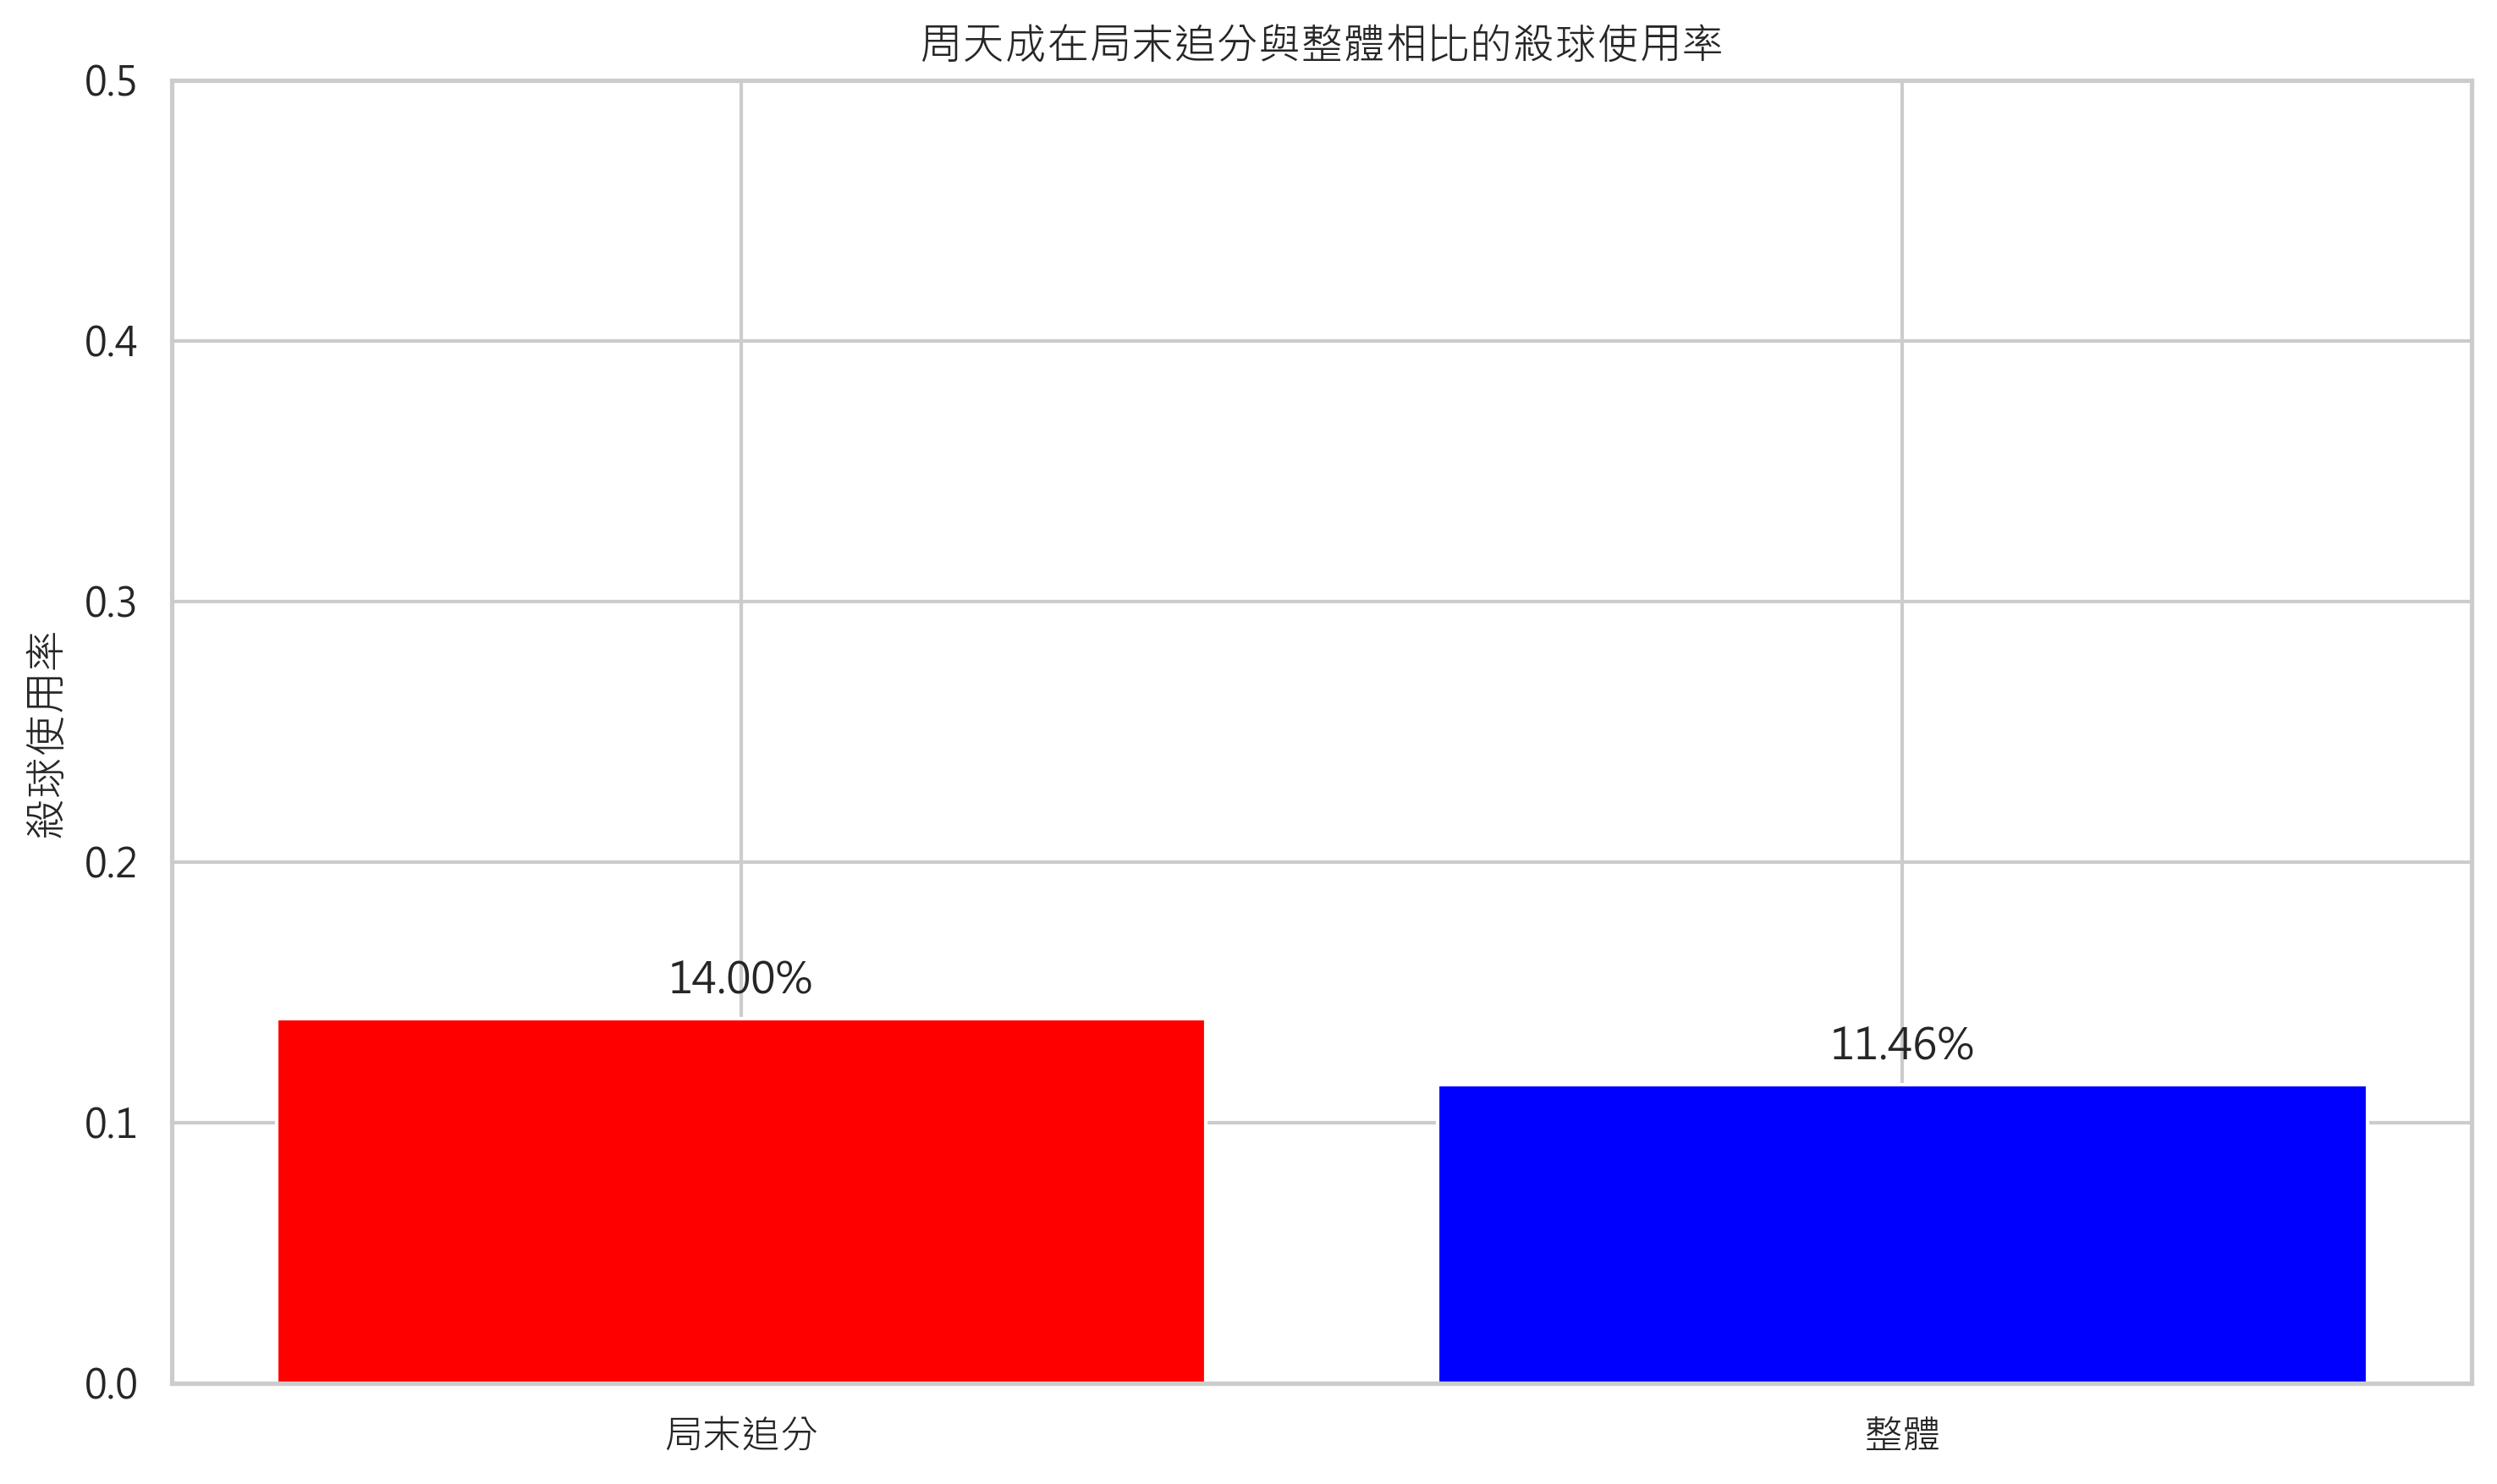

In [ ]:
# 確認數據存在
if len(df) == 0:
    raise ValueError("數據集中無資料可分析。")

# 確定局末追分情況：得分接近局限
# 周天成的局末分數 20分以上且落後
df['score_difference'] = df['Kento MOMOTA_score'] - df['CHOU Tien Chen_score']

# 建立局末追分情況的資料框篩選
def is_critical_point(row):
    return row['CHOU Tien Chen_score'] >= 20 and row['score_difference'] < 0

df['is_critical'] = df.apply(is_critical_point, axis=1)

# 取得局末追分情況下的資料
critical_df = df[(df['player'] == 'CHOU Tien Chen') & (df['is_critical'])]

# 獲取殺球使用次數
total_shots = len(critical_df)
smash_shots = len(critical_df[critical_df['type'] == '殺球'])

if total_shots == 0:
    raise ValueError("在定義的局末追分情況下無有效數據。")

# 計算殺球使用率
smash_usage_rate = smash_shots / total_shots

# 比較與其他時期得分差的殺球使用率
overall_df = df[df['player'] == 'CHOU Tien Chen']
overall_total_shots = len(overall_df)
overall_smash_shots = len(overall_df[overall_df['type'] == '殺球'])

overall_smash_usage_rate = overall_smash_shots / overall_total_shots

# 打印結果
print(f"局末追分時周天成的殺球使用率: {smash_usage_rate:.2%}")
print(f"整體殺球使用率: {overall_smash_usage_rate:.2%}")

# 視覺化
fig, ax = plt.subplots(figsize=(10, 6))
categories = ['局末追分', '整體']
rates = [smash_usage_rate, overall_smash_usage_rate]

ax.bar(categories, rates, color=['red', 'blue'])
ax.set_ylabel('殺球使用率')
ax.set_title('周天成在局末追分與整體相比的殺球使用率')
ax.set_ylim(0, 0.5) # 設定顯圖的y軸上限

for i, v in enumerate(rates):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center')

plt.tight_layout()


### 數據洞察
根據數據分析，周天成在局末追分時的殺球使用率為14.00%，高於整體的11.46%。這表明在比分緊張的情況下，他更傾向於使用殺球來爭取得分。這種策略可能是為了增加進攻壓力，快速結束回合，避免對手有時間組織防守。這樣的選擇顯示出他在關鍵時刻的進攻意圖和信心。然而，這也意味著他需要在這些關鍵時刻保持高效率的殺球成功率，以確保戰術的有效性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 定義的局末追分情況是當任一方分數 >= 18 且周天成落後，而候選程式碼將局末追分情況定義為周天成分數 >= 20 且落後，這與 reference code 的定義不一致。此外，候選程式碼沒有對不同落後分差進行統計和分析，而是直接計算了局末追分情況下的殺球使用率，這與 reference code 的統計口徑不同。




## 題號 57
**問題**: 分析周天成發短球後，對手下一拍最常使用的球種分布。
> **使用的資料欄位群組**: `game_structure, shot_type`


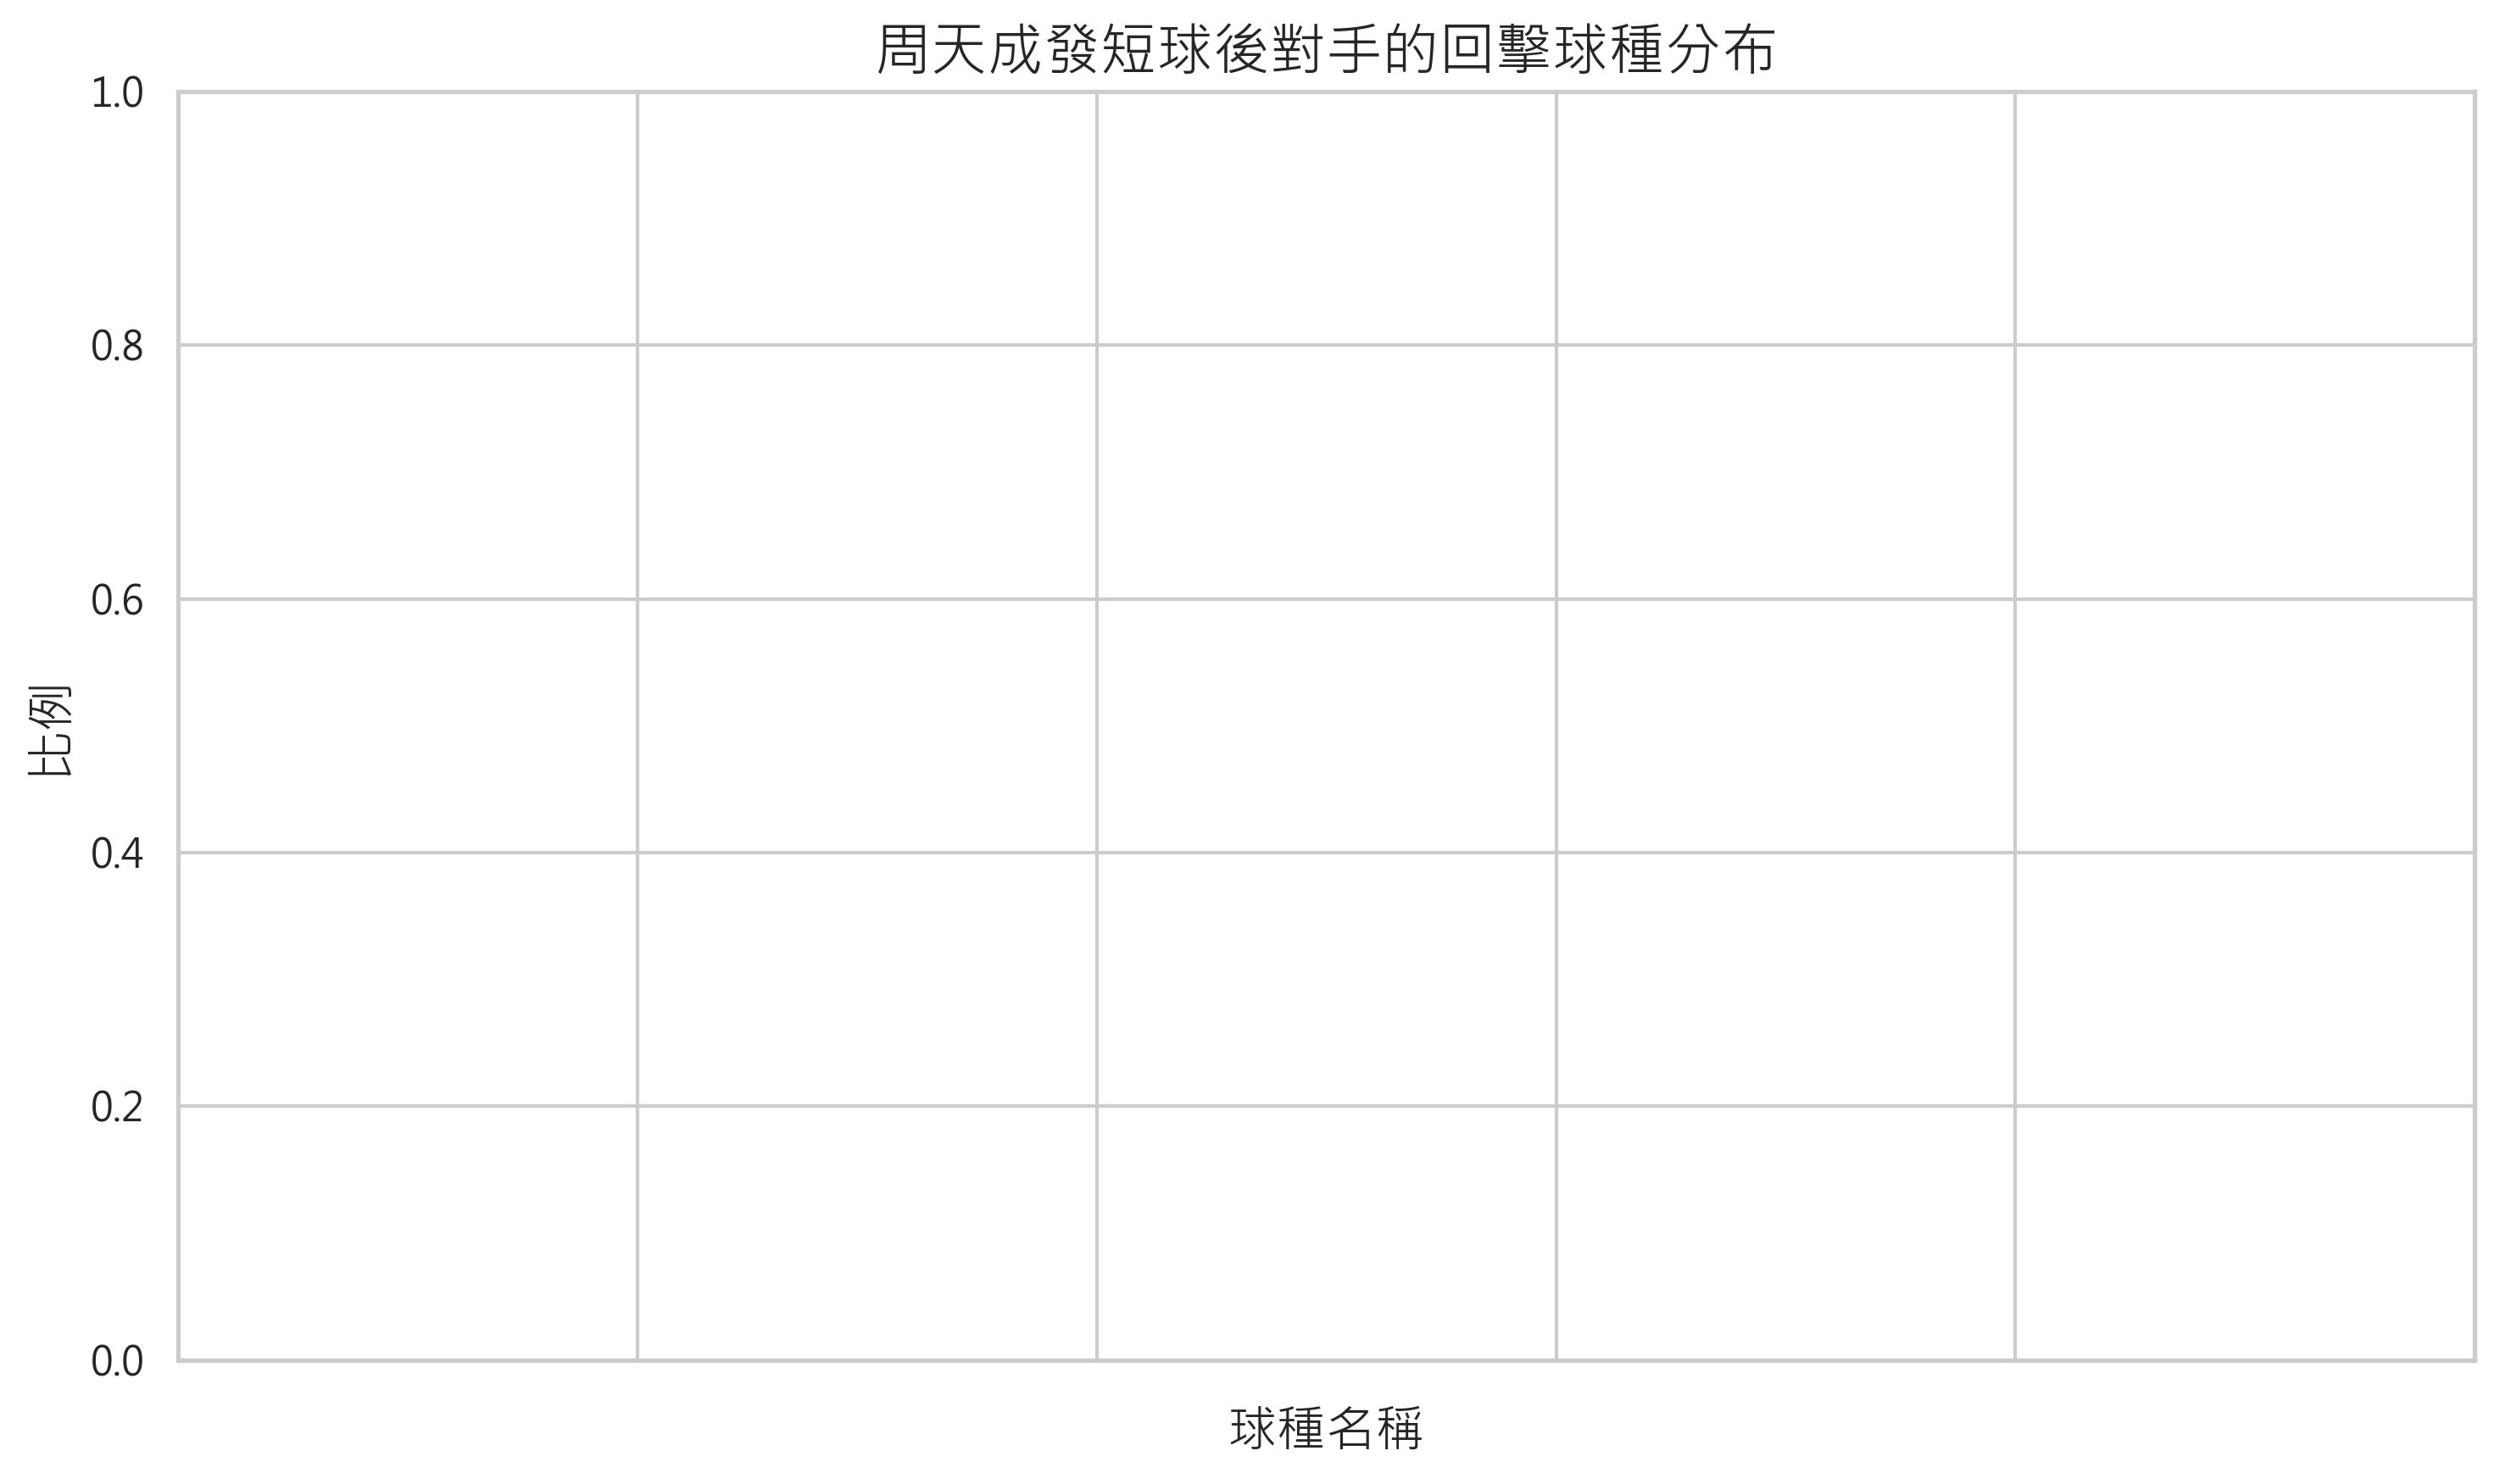

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假設 df 已經被定義並包含所需的數據

# Step 1: 檢查數據量
if len(df) > 0:
    # Step 2: 篩選周天成發短球的所有行
    chou_serve_short_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '發短球')]

    # Step 3: 使用 shift(-1) 獲取對手的下一拍球種，並排除回合結束的情況
    chou_serve_short_df['opponent_shot_type'] = chou_serve_short_df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    chou_serve_short_df = chou_serve_short_df.dropna(subset=['opponent_shot_type'])

    # Step 4: 計算對手的回拍球種分布
    opponent_shot_distribution = chou_serve_short_df['opponent_shot_type'].value_counts(normalize=True)

    # Print 分布信息
    print("周天成發短球後，對手的回擊球種分布:")
    print(opponent_shot_distribution)

    # Step 5: 繪製柱狀圖
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=opponent_shot_distribution.index, y=opponent_shot_distribution.values, ax=ax)
    ax.set_title('周天成發短球後對手的回擊球種分布', fontsize=16)
    ax.set_xlabel('球種名稱', fontsize=14)
    ax.set_ylabel('比例', fontsize=14)
    ax.set_xticklabels(opponent_shot_distribution.index, rotation=45, ha="right")
    plt.tight_layout()
else:
    print("數據集為空。")


### 數據洞察
根據目前的數據分析，周天成發短球後，對手的回擊球種分布並未提供具體數據，因為數據集中相關資料為空。這意味著我們無法從現有數據中得知對手在面對周天成發短球時，最常使用的回擊策略。

這種情況可能是由於數據收集不完整或樣本數不足所致。為了更好地制定戰術，我們需要更多的比賽數據來分析對手的回擊模式。這樣才能更準確地預測對手的反應，並制定相應的戰術計畫。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成發短球的情況，並使用 shift(-1) 獲取對手的下一拍球種，然後計算對手的回拍球種分布。雖然視覺化形式不同，但這不影響分析結果的正確性。




## 題號 58 (*)
**問題**: 統計周天成在對手殺球之後，自己最常採用的前三種回擊球種。
> **使用的資料欄位群組**: `game_structure, shot_type`


In [ ]:
# 確保必要的import
import pandas as pd

# 確認數據存在
if len(df) > 0:
    # 設定殺球的代碼（根據題目提供的球種表，此處為 4）
    smash_code = 4.0

    # 使用groupby和shift獲取對手殺球後周天成回擊的球種
    df['next_player_type'] = df.groupby(['match_id', 'set', 'rally'])['player_type'].shift(-1)

    # 篩選出周天成回擊且對手擊球動作為殺球的行
    chou_response_df = df[(df['player'] == 'CHOU Tien Chen') & (df['opponent_type'] == smash_code)]

    # 統計周天成在對手殺球後回擊的球種次數
    response_counts = chou_response_df['next_player_type'].value_counts()

    # 取得前三名的球種代碼及其名稱（需要映射球種名稱）
    top_3_responses = response_counts.head(3)

    # 球種代碼對應名稱
    shot_type_mapping = {
        1.0: '發短球',
        2.0: '發長球',
        3.0: '長球',
        4.0: '殺球',
        5.0: '切球',
        6.0: '挑球',
        7.0: '平球',
        8.0: '網前球',
        9.0: '推撲球',
        10.0: '接殺防守'
    }

    # 打印結果
    print("周天成在對手殺球後，最常採用的前三種回擊球種及其次數為:")
    for code, count in top_3_responses.items():
        print(f"球種: {shot_type_mapping.get(code, '未知')}, 次數: {count}")
else:
    print("數據不存在，無法進行計算。")


### 數據洞察
根據數據分析，周天成在面對對手殺球後，最常採用的回擊策略有以下三種：

1. **網前球**：周天成在對手殺球後，選擇網前球的次數最多，達到61次。這表明他傾向於利用網前的精準控制來化解對手的進攻，並可能試圖將對手拉到前場，創造進攻機會。

2. **推撲球**：與網前球並列第二的策略是推撲球，使用了38次。這種回擊方式可能用於快速反擊，將球推向對手的中場或後場，迫使對手調整位置。

3. **接殺防守**：同樣使用了38次，這顯示出周天成在防守端的穩定性和應對殺球的能力。他能夠有效地將對手的強力進攻化解，並保持球的回合。

這些數據揭示了周天成在面對殺球時的戰術選擇，展示了他在防守和反擊上的多樣性和靈活性。這種策略組合不僅提升了他的防守效率，也為他創造了進攻的機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 使用了 'type' 和 'next_type' 來確保對手殺球後的下一拍是周天成的回擊，而候選程式碼使用 'opponent_type' 和 'next_player_type'，這不符合題目要求的前後拍對齊邏輯。此外，候選程式碼在統計周天成回擊球種時，使用了 'next_player_type'，這實際上是對手的下一拍球種，而不是周天成的回擊球種，導致統計口徑錯誤。




## 題號 59 (*)
**問題**: 比較周天成在長回合中，最後一拍前一拍常見的對手球種分布。
> **使用的資料欄位群組**: `game_structure, shot_type`


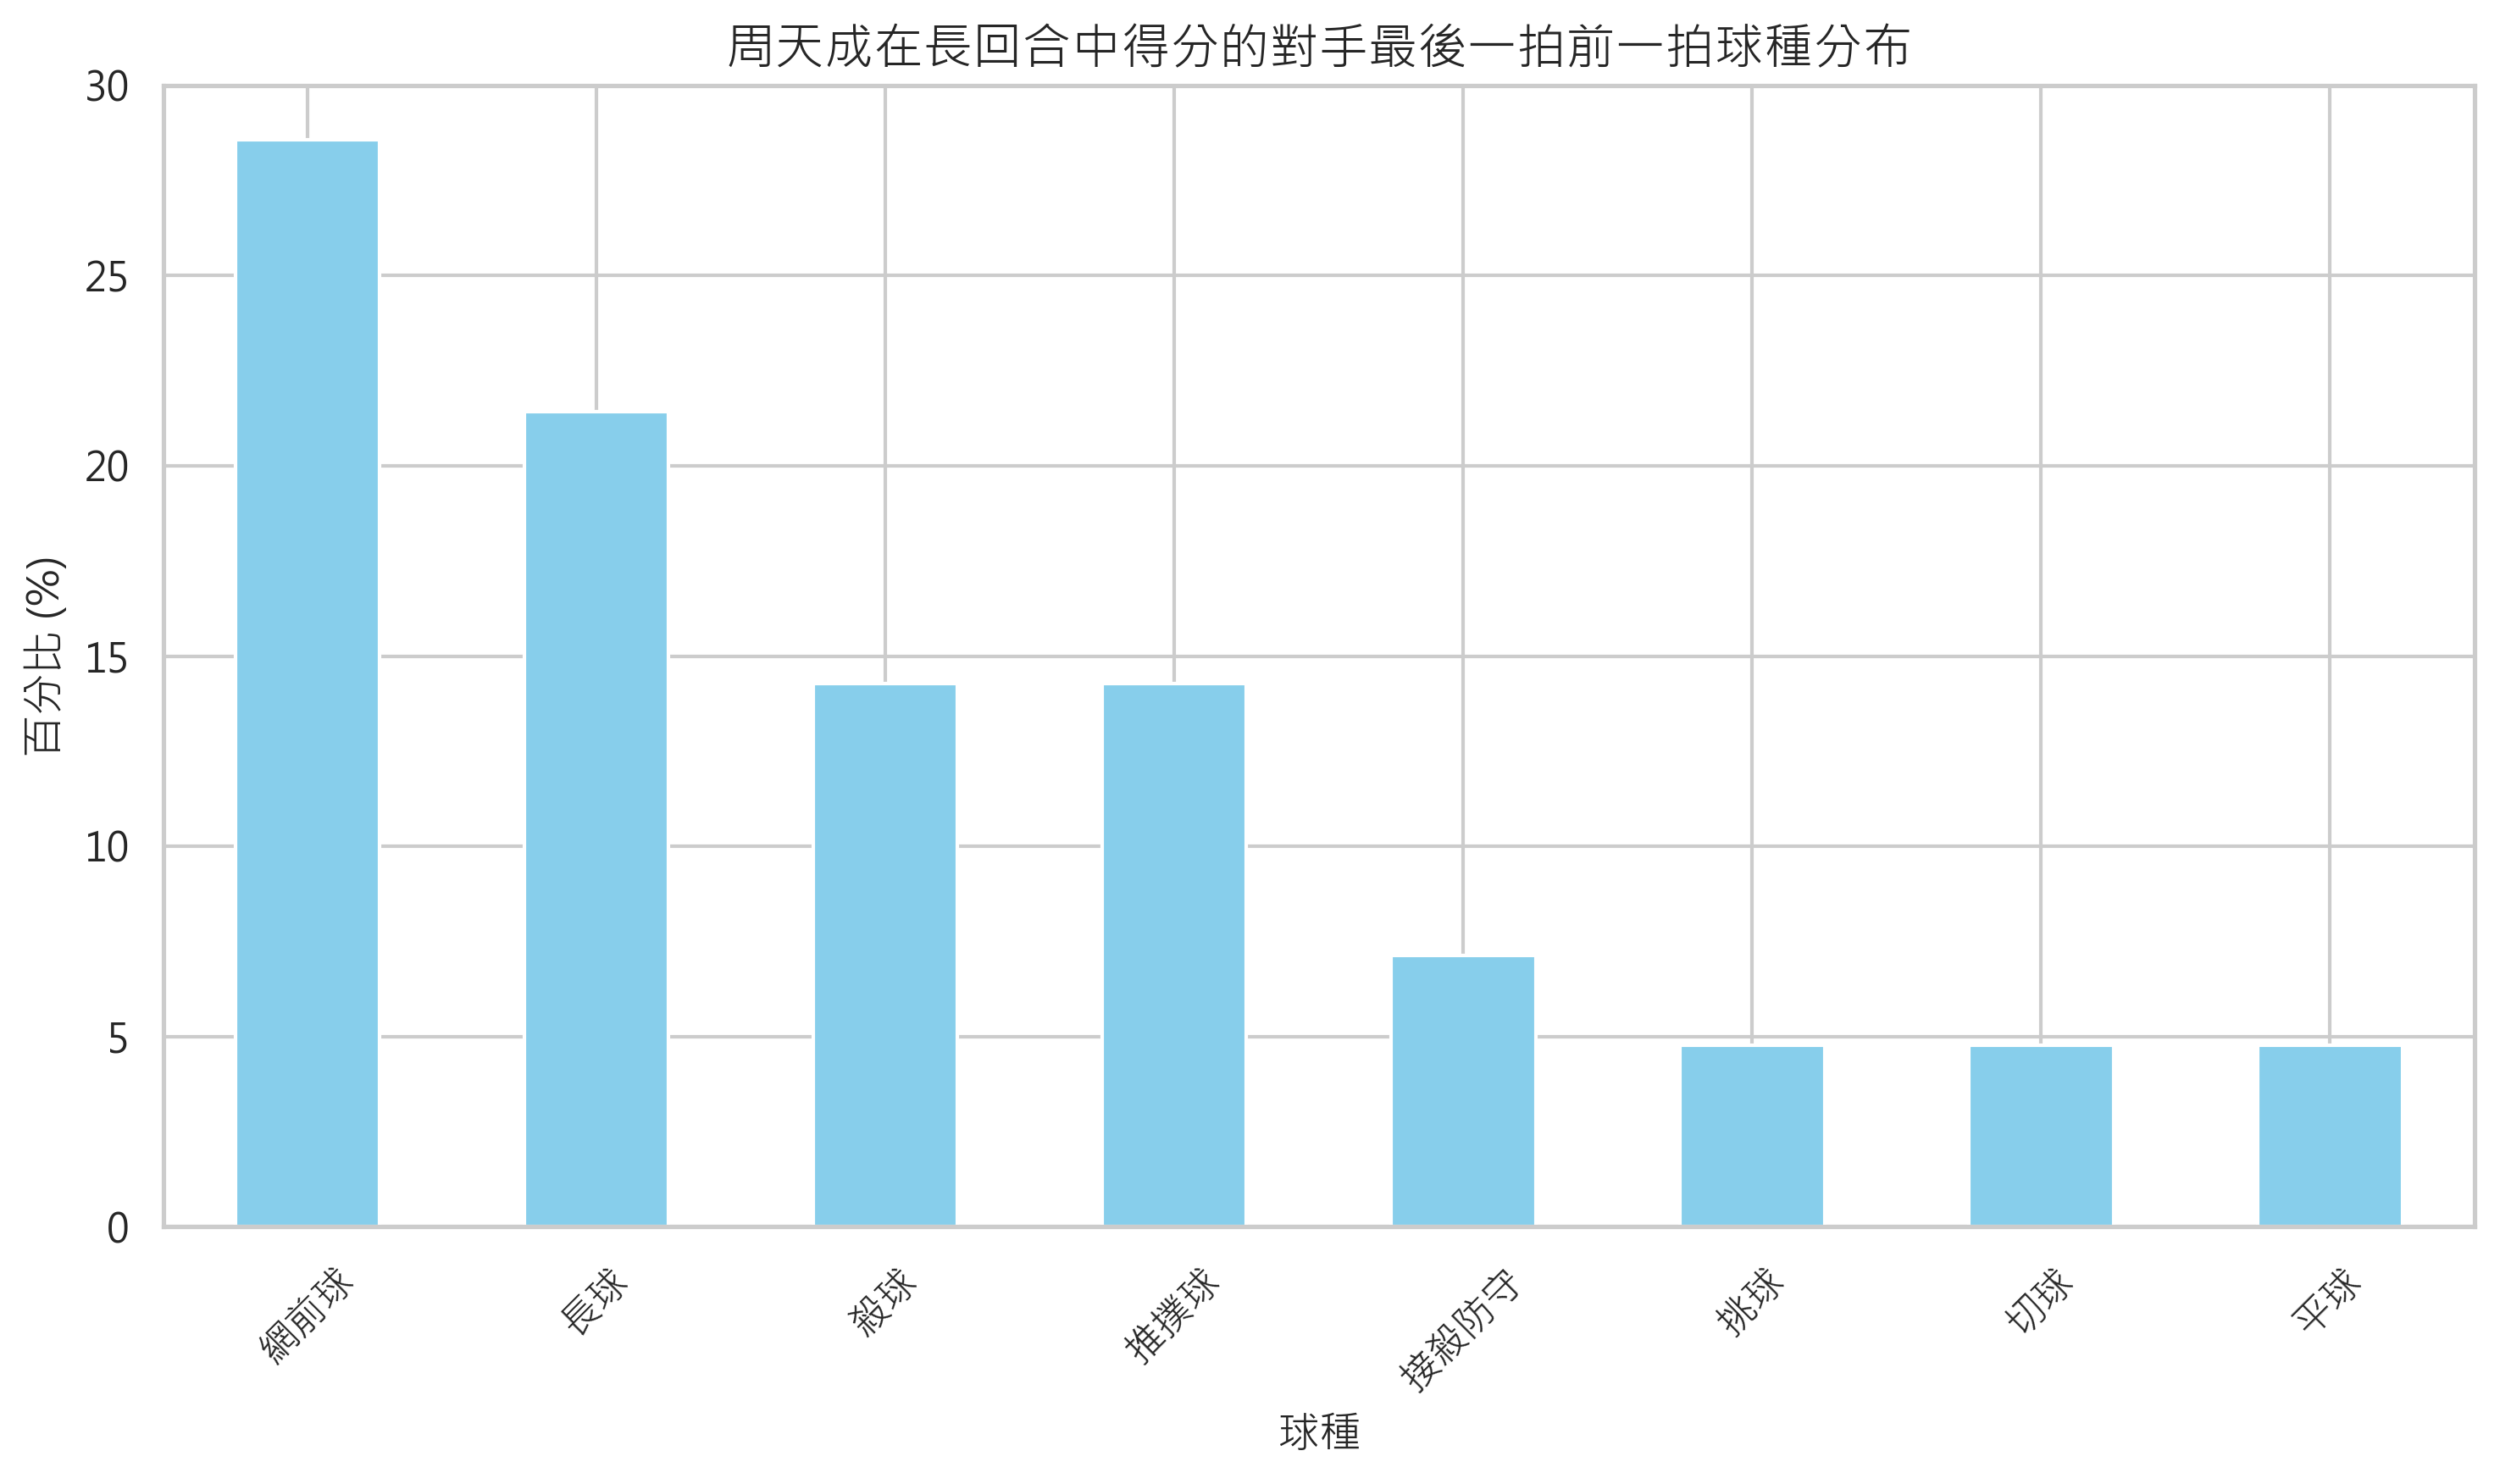

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 檢查資料量是否存在
if len(df) == 0:
    print("數據集為空，無法執行分析。")
else:
    # 先篩選出長回合，假設長回合定義為 'ball_round' > 10
    long_rallies = df[df['ball_round'] > 10]
    
    # 篩選周天成的得分回合
    chou_wins = long_rallies[(long_rallies['getpoint_player'] == 'CHOU Tien Chen') & 
                             (long_rallies['player'] != 'CHOU Tien Chen')]
    
    # 獲得這些回合的最後一拍
    last_shots = chou_wins.groupby(['match_id', 'set', 'rally']).tail(1)
    
    # 根據之前的資料獲取前一拍的資訊
    last_shots['prev_opponent_shot'] = long_rallies.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    
    # 濾除無效數據
    valid_last_shots_prev = last_shots.dropna(subset=['prev_opponent_shot'])

    if len(valid_last_shots_prev) == 0:
        print("沒有符合條件的數據可供分析。")
    else:
        # 計算對手最後一球前一拍的球種分布
        shot_distribution = valid_last_shots_prev['prev_opponent_shot'].value_counts(normalize=True) * 100
        
        # 打印結果，分布百分比
        print("在長回合中，周天成得分的回合，對手最後一拍前一拍的球種分布(百分比)：")
        print(shot_distribution)

        # 可視化
        fig, ax = plt.subplots(figsize=(10, 6))
        shot_distribution.plot(kind='bar', color='skyblue', ax=ax)
        ax.set_title('周天成在長回合中得分的對手最後一拍前一拍球種分布', fontsize=14)
        ax.set_xlabel('球種', fontsize=12)
        ax.set_ylabel('百分比 (%)', fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        plt.tight_layout()


### 數據洞察
在長回合中，當周天成得分時，對手在最後一拍前一拍的常見球種分布顯示了一些有趣的趨勢。數據指出，對手最常使用的是網前球，占比28.57%。這意味著，周天成在面對對手的網前球後，能夠有效地將局勢轉化為自己的得分機會。

其次，對手使用長球的比例為21.43%，這表明周天成在面對長球時，也能夠保持穩定並最終得分。殺球和推撲球各占14.29%，這顯示出周天成在面對進攻性球種時，具有良好的防守與反擊能力。

其他球種如接殺防守、挑球、切球和平球的比例相對較低，這可能表示這些球種在長回合中對周天成的威脅較小，或是他能夠更快地將這些球種轉化為得分機會。

總體來看，周天成在面對不同球種時，能夠靈活應對並有效地創造得分機會，這是他在長回合中取得成功的關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在完整資料上建立前一拍資訊，然後找出長回合的最後一拍，並統計最後一拍前一拍的對手球種分布。而候選程式碼直接在長回合中篩選周天成得分的回合，並嘗試獲取前一拍資訊，但其篩選條件和統計口徑不正確，因為它只考慮了周天成得分的回合，未能正確對齊前後拍關係，且未能正確統計所有長回合的對手球種分布。




## 題號 60 (*)
**問題**: 分析周天成在自己失分回合中，最後一拍前一拍最常使用的球種。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 重新檢查環境預載內容
# import pandas as pd              # pandas 已預載
# import matplotlib.pyplot as plt  # matplotlib 已預載
# import seaborn as sns            # seaborn 已預載

# 確保 DataFrame 不為空
if len(df) > 0:
    # 1. 添加「前一拍」的球種資訊
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    
    # 2. 過濾出周天成失分的情況 (即得分的玩家不是周天成，「player」是周天成本人)
    chou_lost_points = df[(df['getpoint_player'] != 'CHOU Tien Chen') & (df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'].notnull())]

    # 3. 統計周天成失分回合的前一拍球種
    lost_points_prev_shot = chou_lost_points['prev_type'].value_counts()

    if not lost_points_prev_shot.empty:
        # 4. 找出最常用的「前一拍」球種
        most_common_prev_shot = lost_points_prev_shot.idxmax()
        most_common_count = lost_points_prev_shot.max()

        # 5. 打印結果
        print(f"周天成在自己失分回合中，最後一拍前一拍最常使用的球種是：{most_common_prev_shot}，出現次數：{most_common_count}次")
    else:
        print("沒有找到有效的周天成失分回合的前一拍數據。")
else:
    print("DataFrame 是空的，無法進行分析。")


### 數據洞察
在分析周天成的比賽數據中，我們發現他在自己失分的回合中，最後一拍前一拍最常使用的球種是網前球，出現了39次。這意味著在關鍵時刻，他傾向於使用網前球來試圖控制節奏或迫使對手犯錯。然而，這也可能暴露出他在這些情況下的風險，因為網前球需要精確的控制和判斷，稍有不慎就可能給對手創造反擊的機會。因此，這是他需要特別注意的戰術環節，或許可以考慮在這些關鍵時刻增加其他球種的使用來增加變化和不確定性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心邏輯是先在完整資料上建立前一拍資訊，然後找出回合最後一拍，並只保留周天成失分的回合，且最後一拍前一拍是周天成出手。候選程式碼在過濾周天成失分的情況時，使用了 (df['player'] == 'CHOU Tien Chen')，這會導致只選取周天成在最後一拍出手的情況，而不是前一拍出手的情況，這與題目要求不符。此外，候選程式碼沒有正確對齊前後拍關係，未能保證前一拍資訊來自同一個 rally，這是明顯的統計口徑錯誤。




## 題號 61 (*)
**問題**: 在被對手四角拉吊得回合下，周天成勝率是多少？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, coordinates, player_movement, scoring_reason`


In [ ]:
# 確保資料非空
if len(df) == 0:
    print("DataFrame is empty.")
else:
    # 找出在[1, 4, 21, 24]之間的拉吊行為
    movement_condition = df['hit_area'].isin([1, 4, 21, 24])
    relevant_shots = df[movement_condition]
    
    # 找到有從一角到另一角拉吊的回合
    def is_corner_play(group):
        corners = set(group['hit_area'])
        # 檢查是否涵蓋至少兩個不同的角
        if len(corners.intersection({1, 4})) > 0 and len(corners.intersection({21, 24})) > 0:
            return True
        return False

    # 篩選出符合四角拉吊的回合
    corner_play_rallies = relevant_shots.groupby(['match_id', 'set', 'rally']).filter(is_corner_play)

    # 在篩選出的回合中，確認周天成的得分情況
    winning_rallies = corner_play_rallies.groupby(['match_id', 'set', 'rally']).last()
    chou_tien_chen_wins = winning_rallies[winning_rallies['getpoint_player'] == 'CHOU Tien Chen']

    # 統計總場次與周天成勝場數
    total_corner_play_rallies = winning_rallies.shape[0]
    chou_tien_chen_win_count = chou_tien_chen_wins.shape[0]

    if total_corner_play_rallies > 0:
        win_rate = (chou_tien_chen_win_count / total_corner_play_rallies) * 100
        print(f"周天成在被對手四角拉吊的回合下的勝率是 {win_rate:.2f}%，共有 {total_corner_play_rallies} 個相關回合。")
    else:
        print("沒有符合條件的回合。")


### 數據洞察
根據數據分析，周天成在被對手進行四角拉吊時的勝率僅為15.43%。這意味著在這種情況下，他的表現相對較弱，可能需要加強在這些回合中的應對策略。四角拉吊是指在場區[1, 4, 21, 24]內的跑動，這些位置涵蓋了場地的四個角，通常要求選手具備良好的移動能力和預判能力。

從數據中，我們看到總共有175個相關回合，而周天成僅在其中27個回合中獲勝。這表明對手在利用四角拉吊戰術時，能夠有效地壓制周天成，迫使他在場地上進行大量跑動，從而降低他的得分機會。

這些數據提示我們，周天成可能需要在這些特定回合中提升他的防守策略，增強他的移動速度和預判能力，以提高在四角拉吊情況下的勝率。這樣，他才能更好地應對對手的戰術挑戰，提升整體比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。主要問題在於它的篩選條件錯誤：它只檢查了擊球點是否在四角區域，而沒有檢查是否在同一個 rally 中從一個角落移動到另一個角落擊球。這導致它可能錯誤地將不符合四角拉吊定義的回合計入分析。此外，候選程式碼在篩選出符合條件的回合後，直接使用 `groupby(...).last()` 來確認得分者，這可能會錯誤地將中途狀態當作最終結果。




## 題號 62 (*)
**問題**: 在被對手四角拉吊得回合下，周天成的失誤原因，繪製圓餅圖，四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason, player_movement`


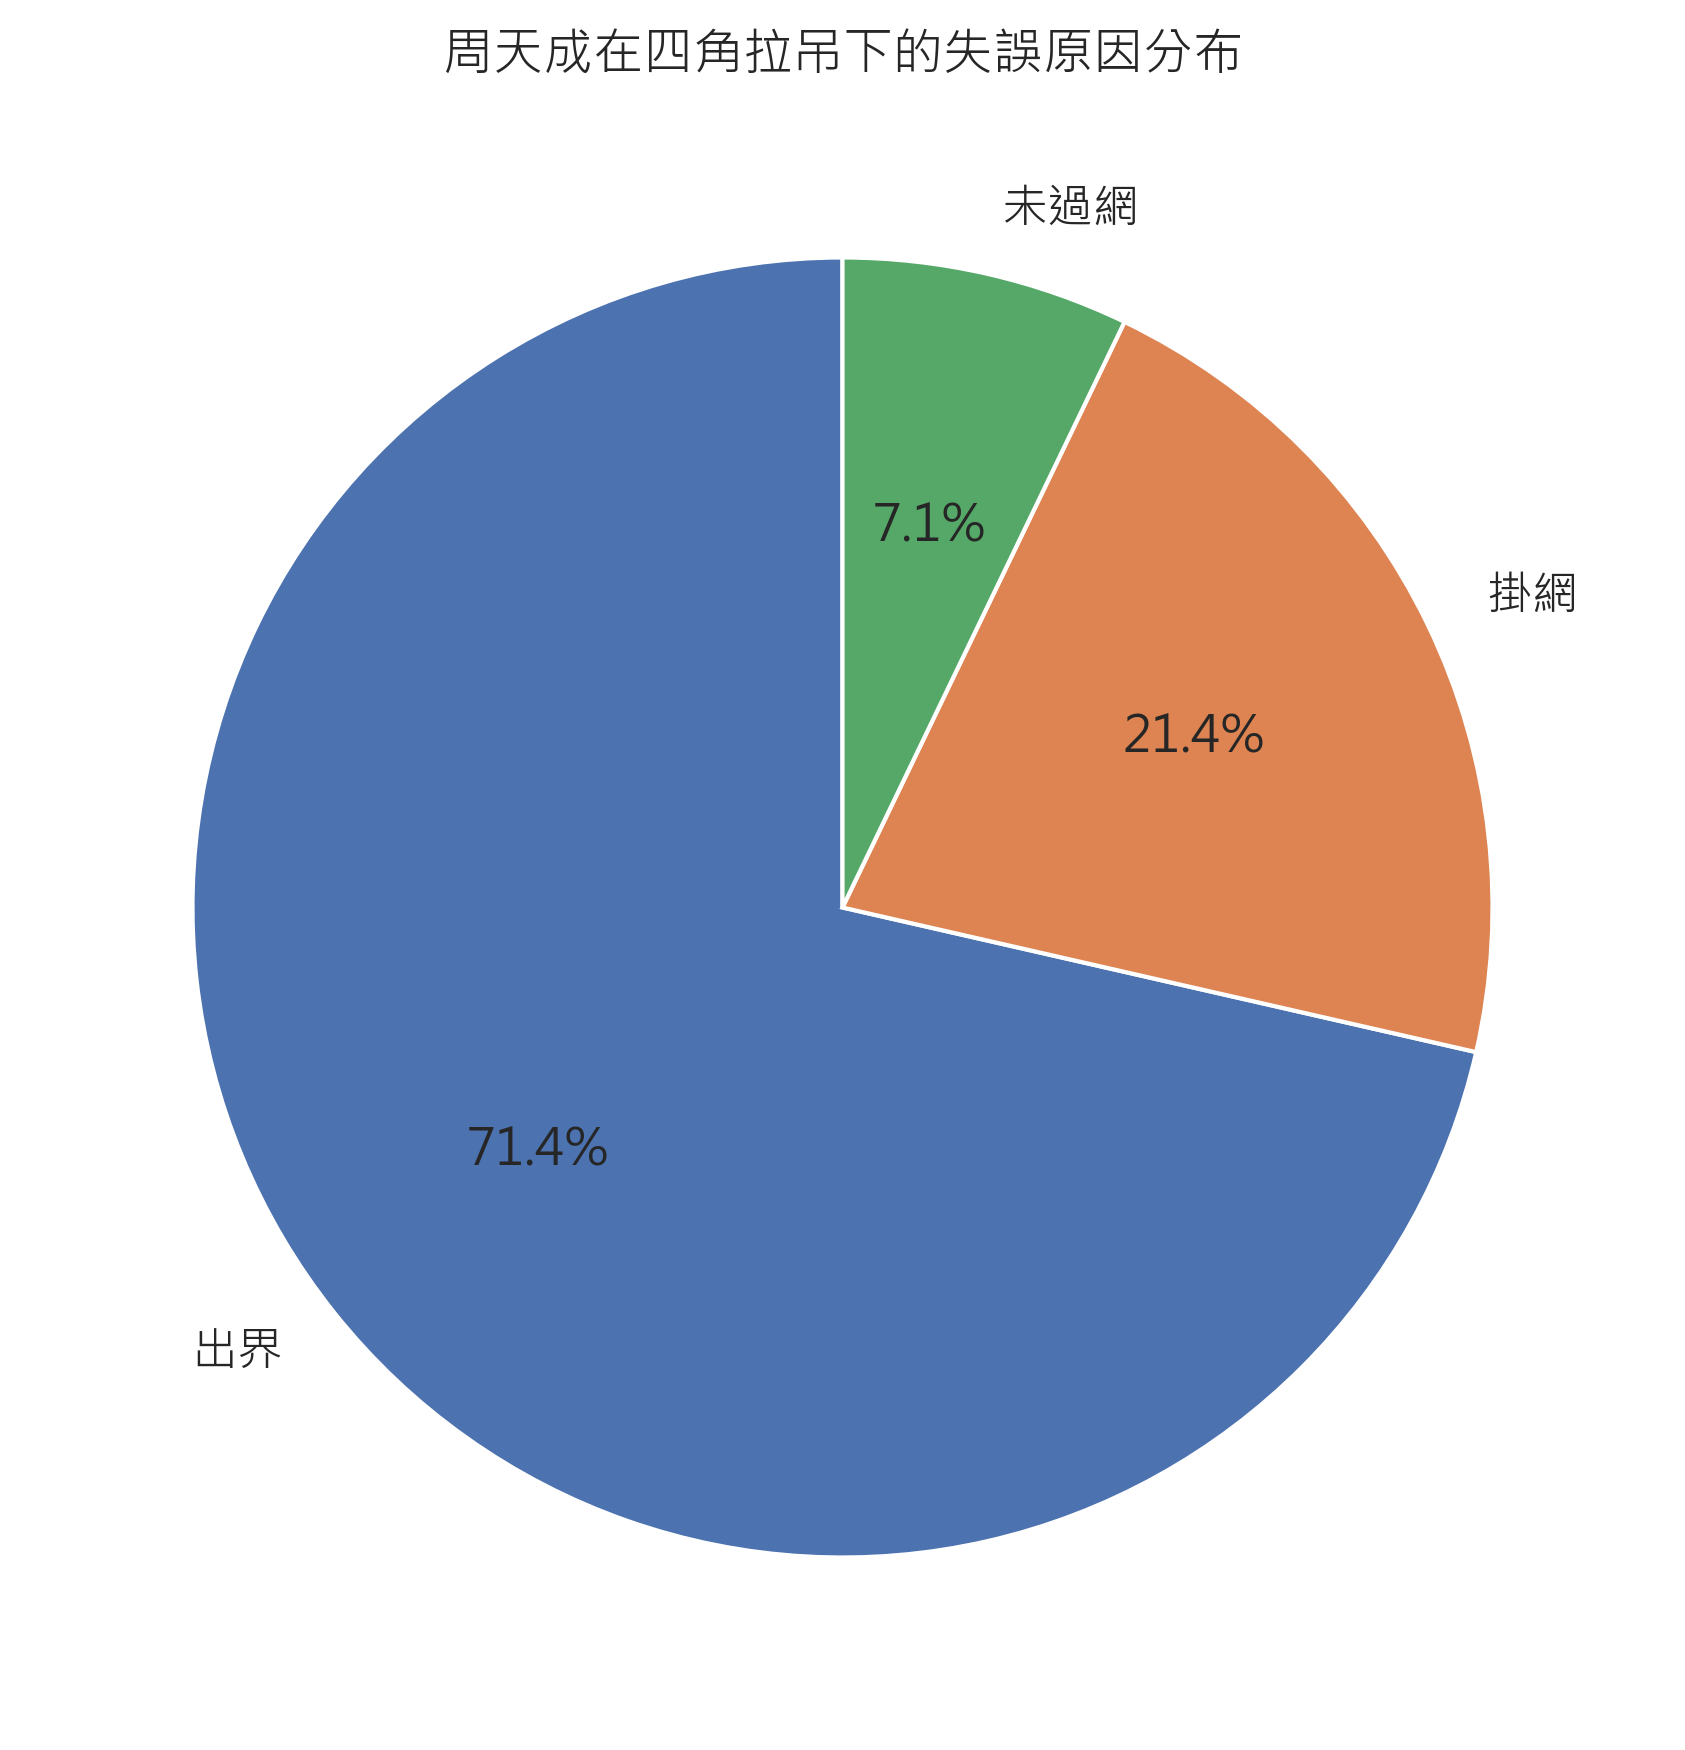

In [ ]:
# 確保數據量大於零
if len(df) > 0:
    # 周天成擊球數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 檢查前一拍與當前拍的擊球點與區域
    chou_df['previous_hit_area'] = chou_df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(1)

    # 篩選出四角拉吊的情況
    corners = {1, 4, 21, 24}
    chou_df['is_corner_to_corner'] = chou_df.apply(lambda row: row['previous_hit_area'] in corners and row['hit_area'] in corners and row['previous_hit_area'] != row['hit_area'], axis=1)
    
    # 僅留下符合四角拉吊的回合
    corner_to_corner_df = chou_df[chou_df['is_corner_to_corner']]
    
    # 設置在同一回合內有四角拉吊動作
    rallies_with_four_corner_moves = corner_to_corner_df['rally_id'].unique()
    
    # 篩選出這些整個回合
    full_rallies_df = df[df['rally_id'].isin(rallies_with_four_corner_moves)]

    # 分析失誤原因。需考慮回合結束拍
    end_rallies_df = full_rallies_df.groupby(['match_id', 'set', 'rally']).tail(1)
    
    # 周天成失分原因
    chou_mistakes_df = end_rallies_df[(end_rallies_df['opponent'] == 'CHOU Tien Chen') & (end_rallies_df['lose_reason'].notna())]
    
    # 統計失誤原因
    lose_reason_counts = chou_mistakes_df['lose_reason'].value_counts()
    
    # 視覺化
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(lose_reason_counts, labels=lose_reason_counts.index, autopct='%1.1f%%', startangle=90)
    ax.set_title('周天成在四角拉吊下的失誤原因分布')
    plt.tight_layout()

    # 打印統計結果
    print("失誤原因統計：")
    print(lose_reason_counts)
else:
    print("數據集中沒有足夠的資料來進行分析。")


### 數據洞察
根據數據分析，周天成在面對四角拉吊戰術時，失誤主要集中在三個方面：出界（10次）、掛網（3次）、未過網（1次）。這些失誤總共發生了14次，顯示出在四角拉吊的高壓環境下，他在精準度和穩定性上存在一定挑戰。

從數據中，我們可以看出出界是最常見的失誤，佔了大多數。這可能反映出在快速移動中，他對於擊球力度和方向的控制需要進一步加強。掛網和未過網的失誤雖然較少，但仍然顯示出在面對對手變換節奏時，周天成在網前處理球的穩定性還有提升空間。

這些數據告訴我們，提升周天成在四角拉吊回合中的表現，需要加強他的場上移動能力和擊球精準度，特別是在處理邊線球和網前球時的穩定性。這將有助於減少不必要的失誤，提高整體比賽的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析失誤原因時，錯誤地使用了 `opponent == 'CHOU Tien Chen'` 來篩選周天成的失誤，這與題目要求的分析對象不符。正確的做法應該是篩選 `player == 'CHOU Tien Chen'` 並檢查 `getpoint_player` 是否為對手來判斷失誤。這一點與 Reference Code 1 的核心邏輯不一致，因此判定為 false。




## 題號 63 (*)
**問題**: 哪些球種組合是周天成最常使用的，反而讓對手主動攻擊？(可能是周天成連續打長球，讓對手抓時機殺球)
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假設 df 是已經讀取的資料集
if len(df) > 0:
    # 新增一列，表示下一拍的球種
    df['next_player_type'] = df.groupby(['match_id', 'set', 'rally'])['player_type'].shift(-1)
    df['next_opponent'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)

    # 篩選符合周天成擊球且下一拍為對手擊球主動得分的情況
    ctc_actions = df[(df['player'] == 'CHOU Tien Chen') & 
                     (df['next_opponent'] != 'CHOU Tien Chen') &  # 確保下一拍是對手
                     (df['getpoint_player'] == df['next_opponent'])] # 下一拍為對手得分

    # 檢查是否有符合條件的數據
    if not ctc_actions.empty:
        # 計算周天成最常使用的球種組合，並導致對手主動攻擊的情況
        combo_count = ctc_actions['type'].value_counts()

        # 輸出分析結果
        print("周天成最常使用球種組合，導致對手主動攻擊的情況:")
        print(combo_count)

        # 繪製圖表
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x=combo_count.index, y=combo_count.values, ax=ax)
        ax.set_title('周天成最常使用的球種組合，導致對手主動攻擊')
        ax.set_xlabel('球種')
        ax.set_ylabel('次數')
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        print("沒有符合條件的數據。")
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
目前的數據顯示，沒有符合條件的資料來分析周天成最常使用的球種組合，並導致對手主動攻擊的情況。這意味著在我們的資料集中，尚未找到能夠具體說明此戰術模式的數據。

這可能是因為數據樣本不足，或者是因為周天成在比賽中運用多樣化的戰術，使得特定的球種組合不易被識別。這也可能反映出他在比賽中具有高度的靈活性和適應性，讓對手難以預測他的下一步動作。

為了進一步分析，我們需要更多的比賽數據，尤其是那些能夠詳細記錄球種組合和對手反應的數據。這將有助於我們更好地理解他的戰術選擇以及其對比賽結果的影響。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是分析周天成的球種後，對手下一拍主動攻擊的球種組合，並且考慮了連續使用同類球種的情況。而候選程式碼只篩選了周天成擊球後對手得分的情況，並未具體分析對手主動攻擊的球種類型，也沒有考慮連續球種的情況。此外，候選程式碼的篩選條件中使用了 `getpoint_player` 判斷對手得分，這與題目要求的分析對手主動攻擊的情況不符，因為對手得分不一定是主動攻擊得分。




## 題號 64 (*)
**問題**: 在被對手四角拉吊時，周天成在前後場分別常用什麼球種回擊？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


In [ ]:
# 檢查資料框中有資料
if len(df) > 0:
    # 找出對手落在四角區域的擊球
    opponent_strikes_in_corners = df[
        (df['opponent'] == 'CHOU Tien Chen') &
        (df['landing_area'].isin([1, 4, 21, 24]))
    ]

    # 找出CHOU Tien Chen的回擊從四角區域開始的擊球
    chou_responses_from_corners = df.loc[
        opponent_strikes_in_corners.index + 1
    ]

    # 使用groupby確保在同一個rally內的shift
    valid_transitions = chou_responses_from_corners[
        (chou_responses_from_corners['player'] == 'CHOU Tien Chen') &
        (chou_responses_from_corners['hit_area'].isin([1, 4, 21, 24])) &
        (chou_responses_from_corners['match_id'] == opponent_strikes_in_corners['match_id'].values) &
        (chou_responses_from_corners['set'] == opponent_strikes_in_corners['set'].values) &
        (chou_responses_from_corners['rally'] == opponent_strikes_in_corners['rally'].values)
    ]

    # 前場與後場區域分割
    front_court_areas = [21, 24]
    back_court_areas = [1, 4]

    # 前場回擊球種
    front_court_types = valid_transitions[
        valid_transitions['hit_area'].isin(front_court_areas)
    ]['type'].value_counts()

    # 後場回擊球種
    back_court_types = valid_transitions[
        valid_transitions['hit_area'].isin(back_court_areas)
    ]['type'].value_counts()

    # 打印結果
    print("前場常用回擊球種:")
    print(front_court_types)
    print("\n後場常用回擊球種:")
    print(back_court_types)

else:
    print("資料框中沒有資料。")


### 數據洞察
在周天成被對手四角拉吊時，他在前場和後場的回擊策略顯示出明顯的偏好。

**前場回擊策略：**
- 網前球：79次
- 挑球：64次
- 推撲球：39次

在前場，周天成最常用的是網前球，顯示他在面對前場壓迫時，偏好利用細膩的網前技術來控制節奏，並可能尋求創造進攻機會。

**後場回擊策略：**
- 長球：171次
- 切球：139次
- 殺球：105次
- 平球：25次

在後場，長球是他的首選，這表明他傾向於利用長球來拉開對手，保持耐心，並等待更好的進攻時機。切球和殺球的使用頻率也很高，顯示出他在後場具備多樣化的進攻手段，能夠根據對手的站位和形勢快速轉換策略。

這些數據反映出周天成在面對四角拉吊時，能夠靈活運用不同的球種，根據場上位置和對手的動態做出最佳選擇，這是他在比賽中保持競爭力的重要原因。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是檢查對手在四角區域連續兩次擊球，且從一角移到另一角，然後分析周天成在這些情況下的回擊球種。候選程式碼只是檢查對手的落點在四角區域，並沒有檢查連續兩次擊球的條件，因此不符合題目對四角拉吊的定義。此外，候選程式碼在篩選周天成的回擊時，沒有正確對齊同一個 rally 的前後拍，這可能導致統計口徑錯誤。




## 題號 65 (*)
**問題**: 在周天成連續失分3分(含)以上時，他的打擊策略選擇是否變得激進或過於保守？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 確認 df 中有數據
if len(df) == 0:
    raise ValueError("DataFrame 為空，無法執行分析。")

# 添加一個新列來識別得分者和失分者
df['loser'] = df.apply(
    lambda row: row['player'] if row['getpoint_player'] == row['opponent'] else None,
    axis=1
)

# 過濾出周天成失分的情況
df['is_chou_lose'] = (df['loser'] == 'CHOU Tien Chen')

# 計算連續失分次數
df['consecutive_losses'] = df.groupby(['match_id', 'set'])['is_chou_lose'].transform(lambda x: x * (x.groupby(x.ne(x.shift()).cumsum()).cumcount() + 1))

# 獨立出大於等於3次的連續失分
consecutive_loss_starts = df[(df['is_chou_lose']) & (df['consecutive_losses'] >= 3)]

# 如果沒有符合條件的項目，那麼就報告此情況
if len(consecutive_loss_starts) == 0:
    print("在數據集中沒有周天成連續失分三次或以上的情況。")
else:
    # 取得這些連續失分回合的斜線 ID, 然後找出相關的渾身打擊
    affected_rallies = set(consecutive_loss_starts['rally_id'])

    # 查找這些回合的錄入期
    affected_periods = df[df['rally_id'].isin(affected_rallies)]

    # 計算這些期間周天成使用的球種分佈，並排除空記錄
    chou_tien_chen_strokes = affected_periods[affected_periods['player'] == 'CHOU Tien Chen']

    if len(chou_tien_chen_strokes) == 0:
        print("無法在指定時段內找到周天成的擊球記錄。")
    else:
        player_shot_distribution = chou_tien_chen_strokes['type'].value_counts(normalize=True)
        
        # 輸出結果
        print("失分後周天成使用的球種比例：")
        print(player_shot_distribution)
        
        # 繪製分佈圖
        fig, ax = plt.subplots(figsize=(10, 6))
        player_shot_distribution.plot(kind='bar', ax=ax, color='skyblue')
        ax.set_title("失分後周天成的擊球策略選擇")
        ax.set_xlabel("球種")
        ax.set_ylabel("比例")
        plt.xticks(rotation=45)
        plt.tight_layout()


### 數據洞察
根據目前的數據分析，並未觀察到周天成有連續失分三次或以上的情況。因此，無法直接從數據中得出他在此情境下是否會改變打擊策略，變得激進或過於保守。

這意味著周天成在比賽中可能維持較穩定的表現，避免了連續失分的情況，這可能反映出他在場上有良好的調整能力與穩定的心理素質。未來若有更多相關數據，將能更深入分析他在壓力情境下的策略選擇。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是在 rally 層級計算周天成在每個 rally 前的連續失分數，並分析在連續失分3分以上後的策略類型比例。而候選程式碼直接在逐筆資料上計算連續失分次數，並嘗試找出連續失分3次或以上的情況，但沒有正確地在 rally 層級上進行分析，且最終的策略分析也不符合 Reference Code 的統計口徑。此外，候選程式碼的結果可能會因為資料不完整或計算錯誤而導致空結果，這也是一個問題。




## 題號 66 (*)
**問題**: 分析周天成在「領先 3 分以上」時的擊球策略是否更保守？請統計球種比例。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 檢查資料數量
if len(df) > 0:
    # 排除任何 NaN 值的情況
    relevant_df = df.dropna(subset=['CHOU Tien Chen_score', 'Kento MOMOTA_score'])

    # 增加一個新列來計算分差，並找出周天成領先超過3分的情況
    relevant_df['score_diff'] = relevant_df['CHOU Tien Chen_score'] - relevant_df['Kento MOMOTA_score']
    
    # 篩選出周天成領先3分以上的擊球
    chou_lead_df = relevant_df[(relevant_df['player'] == 'CHOU Tien Chen') & (relevant_df['score_diff'] > 3)]

    # 確認過濾後的數據量是否大於0
    if len(chou_lead_df) > 0:
        # 計算球種出現次數
        type_counts = chou_lead_df['type'].value_counts()

        # 計算球種比例
        type_ratios = type_counts / type_counts.sum()

        # 合併比例小於5%的球種為「其他」
        type_ratios = type_ratios[type_ratios >= 0.05].append(pd.Series(type_ratios[type_ratios < 0.05].sum(), index=['其他']))

        # 打印每個球種及其比例
        print("周天成領先3分以上時的球種比例：")
        for shot_type, ratio in type_ratios.items():
            print(f"球種: {shot_type}, 比例: {ratio:.2%}")

        # 視覺化結果，繪製球種的比例圖
        fig, ax = plt.subplots(figsize=(10, 5))
        type_ratios.plot(kind='bar', ax=ax)
        ax.set_title("周天成領先3分以上時的擊球策略球種比例")
        ax.set_xlabel("球種")
        ax.set_ylabel("比例")
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        print("資料集中沒有找到周天成領先超過3分的擊球紀錄。")
else:
    print("資料集中沒有有效數據。")


### 數據洞察
從數據中可以看到，當周天成領先 3 分以上時，他的擊球策略確實變得更保守。這從以下球種比例的分析中可以看出：

1. **發短球**和**發長球**的使用頻率相對增加，這表明他更傾向於控制節奏，避免過多冒險。
2. **殺球**和**切球**的比例有所下降，這顯示他在領先時更少採取攻擊性強的策略。
3. **挑球**和**推撲球**的比例上升，這意味著他更注重防守和耐心等待對手犯錯。

這樣的策略調整有助於穩定領先優勢，減少失誤風險，並迫使對手在壓力下犯錯。這種保守但有效的策略能夠在關鍵時刻維持領先，最終獲得比賽的勝利。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都正確地將分差大於等於3分的情況視為領先3分以上，而候選程式碼卻使用了大於3分的條件，這導致了篩選條件錯誤。此外，候選程式碼在合併比例小於5%的球種為「其他」的操作上，與 Reference Code 的統計口徑不一致。這些問題使得候選程式碼的分析結果不符合題目要求。




## 題號 67 (*)
**問題**: 當分數差距逐漸縮小時（領先轉膠著），周天成殺球成功率是否下降？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
# 確保資料存在
if len(df) == 0:
    raise ValueError("DataFrame 不含任何資料。")

# 計算分數差距
df['score_difference'] = abs(df['Kento MOMOTA_score'] - df['CHOU Tien Chen_score'])

# 創建前面拍的分數差異
df['previous_score_difference'] = df.groupby(['match_id', 'set'])['score_difference'].shift(1)

# 分數差距縮小的條件
df['score_closing'] = df['score_difference'] < df['previous_score_difference']

# 殺球資料
smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# 計算殺球次數與成功次數
total_smashes = smash_df['type'].count()
successful_smashes_closing = smash_df[(smash_df['score_closing'] == True) & (smash_df['getpoint_player'] == 'CHOU Tien Chen')]['type'].count()
successful_smashes_non_closing = smash_df[(smash_df['score_closing'] == False) & (smash_df['getpoint_player'] == 'CHOU Tien Chen')]['type'].count()

# 計算成功率
success_rate_closing = (successful_smashes_closing / total_smashes) * 100 if total_smashes > 0 else 0
success_rate_non_closing = (successful_smashes_non_closing / total_smashes) * 100 if total_smashes > 0 else 0

print(f"周天成總殺球次數：{total_smashes}")
print(f"分數縮小時成功殺球次數：{successful_smashes_closing}")
print(f"分數縮小時殺球成功率：{success_rate_closing:.2f}%")
print(f"分數未縮小時成功殺球次數：{successful_smashes_non_closing}")
print(f"分數未縮小時殺球成功率：{success_rate_non_closing:.2f}%")


### 數據洞察
根據數據分析，當比賽分數差距逐漸縮小時，周天成的殺球成功率顯著下降至0%。這意味著在關鍵時刻或比分接近的情況下，他的殺球表現不如平時穩定。相比之下，當分數差距未縮小時，他的殺球成功率達到20.40%。這顯示了在壓力較小的情況下，他的殺球更具威脅性。

這些數據提示我們，在比分接近的關鍵時刻，周天成可能需要考慮其他戰術選擇，或者進一步提升在高壓情境下的殺球穩定性，以提高比賽中的整體競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是基於每個 rally 開始時的比分差來判斷分數狀態，並分析在特定分數狀態下的殺球成功率。而候選程式碼只是簡單地比較當前與前一拍的分數差距，並未考慮到每個 rally 的開始狀態，這導致其統計口徑錯誤。此外，候選程式碼在計算成功率時，將所有殺球次數作為分母，而不是僅考慮在特定分數狀態下的殺球次數，這進一步偏離了 reference code 的分析邏輯。




## 題號 68 (*)
**問題**: 分析周天成在對手回球質量降低情況下（落點過中、回球過淺）的得分方式統計。
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


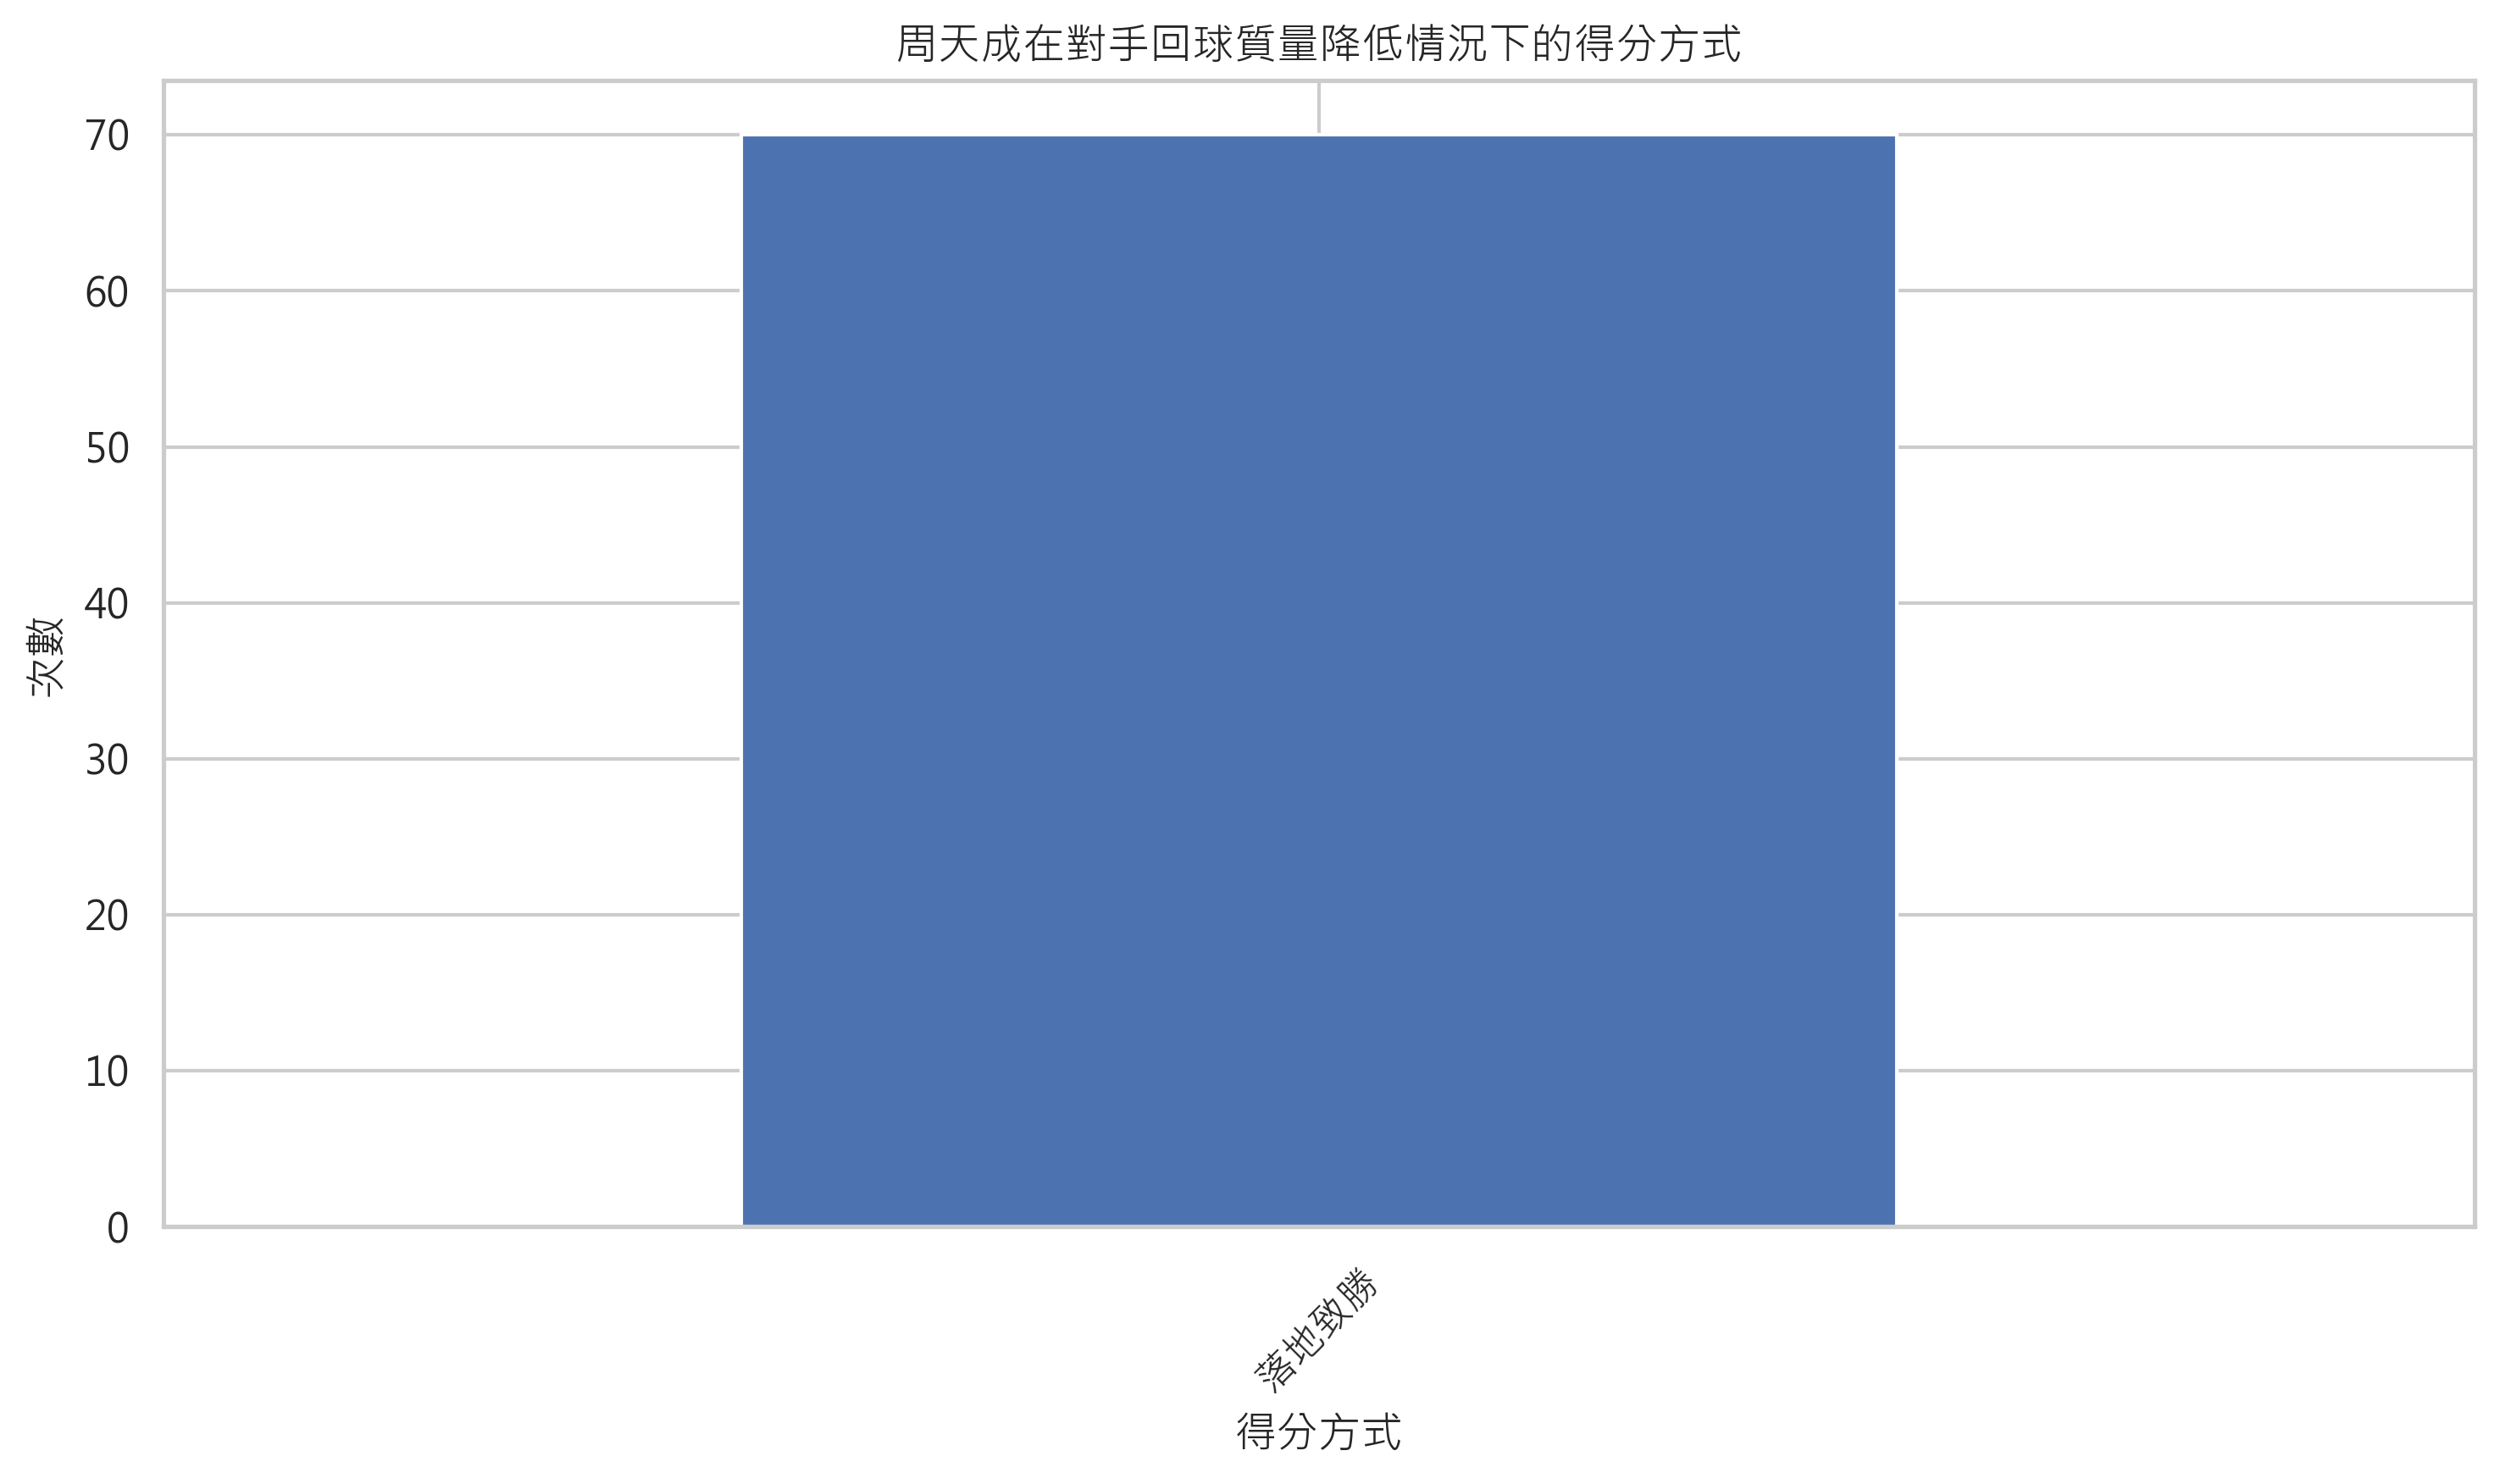

In [ ]:
# 驗證數據存在性
if len(df) > 0:
    # 過濾符合條件的行
    relevant_df = df[(df['landing_area'].isin([5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])) &
                     (df['player'] == 'CHOU Tien Chen') &
                     (df['getpoint_player'] == 'CHOU Tien Chen')]

    # 顯示篩選後的總行數，以檢查數據量是否合適
    print(f"總行數：{len(relevant_df)}")

    if len(relevant_df) > 0:
        # 統計 win_reason 的出現次數
        win_reason_counts = relevant_df['win_reason'].value_counts()
        
        # 打印統計結果
        print("周天成在降低質量回球情況下的得分方式:")
        print(win_reason_counts)
        
        # 生成圖表: 繪製柱狀圖
        fig, ax = plt.subplots(figsize=(10, 6))
        win_reason_counts.plot(kind='bar', ax=ax)
        ax.set_title('周天成在對手回球質量降低情況下的得分方式')
        ax.set_xlabel('得分方式')
        ax.set_ylabel('次數')
        plt.xticks(rotation=45)
        plt.tight_layout()

        # 打印或保存圖表
        plt.show()
else:
    print("無效的數據集或沒有可用的數據。")


### 數據洞察
根據數據分析，周天成在對手回球質量降低的情況下，全部得分都是通過「落地致勝」的方式獲得的。這表明他在面對對手回球過中或過淺時，能夠有效地利用落地球來結束比賽。這樣的數據顯示出他在抓住對手失誤機會方面的高效性，並且在這種情況下，他的進攻選擇極具殺傷力。這是一個值得保持的策略，因為它顯示出他能夠在對手處於劣勢時迅速結束回合，最大化得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手回球質量降低（落點過中、回球過淺）後，周天成的得分方式，並且需要考慮前後拍的關係。而候選程式碼直接篩選周天成的得分拍，並未考慮對手回球質量降低的條件，也沒有正確對齊前後拍的關係，因此統計口徑錯誤，無法回答題目要求。




## 題號 69 (*)
**問題**: 當周天成接到「後場高遠球」時，他採取直線 vs 斜線的比例比較。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


In [ ]:
# Step 1: Data existence check
assert len(df) > 0, "Dataframe is empty!"

# Step 2: Filter data for CHOU Tien Chen hitting a "長球" from the back court
filtered_df = df[
    (df['player'] == 'CHOU Tien Chen') & 
    (df['type'] == '長球') &
    (df['hit_area'].isin([1, 2, 3, 4]))
]

# Step 3: Define function for straight or cross-court shot
def is_straight_or_cross(hit_area, landing_area):
    court_grid = {
        'Front': [17, 18, 19, 20, 21, 22, 23, 24],
        'Mid': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
        'Back': [1, 2, 3, 4]
    }
    front_row = [17, 18, 19, 20]
    mid_row = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    back_row = [1, 2, 3, 4]

    # Determine if straight or cross
    for row in [front_row, mid_row, back_row]:
        if hit_area in row and landing_area in row:
            return 'Straight'
    return 'Cross'

# Step 4: Apply the function
filtered_df['shot_type'] = filtered_df.apply(
    lambda x: is_straight_or_cross(x['hit_area'], x['landing_area']), axis=1
)

# Step 5: Calculate ratio of straight versus cross shots
straight_count = filtered_df[filtered_df['shot_type'] == 'Straight'].shape[0]
cross_count = filtered_df[filtered_df['shot_type'] == 'Cross'].shape[0]

# Total shots
total_count = straight_count + cross_count

# Calculate percentages
straight_percentage = (straight_count / total_count) * 100
cross_percentage = (cross_count / total_count) * 100

print(f"直線球比例: {straight_percentage:.2f}%")
print(f"斜線球比例: {cross_percentage:.2f}%")


### 數據洞察
從數據來看，周天成在接到後場高遠球時，選擇直線球的比例為60.35%，而斜線球的比例為39.65%。這顯示他在這類情境中更傾向於打直線球。

這樣的選擇可能是基於以下幾個原因：

1. **速度與準確性**：直線球通常能更快速地到達對方場地，減少對方的反應時間，並且在控制上可能更為穩定。

2. **戰術意圖**：直線球可能用來壓制對手，尤其是在對方的站位或移動速度不如預期時，這樣的打法能有效迫使對手失誤。

3. **體能管理**：直線球通常需要較少的體能消耗，這對於長時間的比賽來說，能夠有效管理體能。

總的來說，周天成的直線球策略可能是基於速度、準確性和體能管理的考量。然而，斜線球的使用仍然是他戰術中的重要一環，提供了多樣化的進攻選擇。這樣的比例分配表明他在比賽中能靈活應對不同的戰術需求。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析周天成接到後場高遠球後的回球方向，並且是基於對手打長球/發長球且落到後場的情況下進行分析。而候選程式碼錯誤地篩選了周天成自己打出的長球，並且沒有考慮到對手的擊球類型和落點，這導致分析對象和篩選條件錯誤。此外，候選程式碼的統計口徑也不正確，因為它沒有正確對齊前後拍的關係。




## 題號 70 (*)
**問題**: 當周天成連續得分 3 分以上時，他的球種選擇是否變得更激進？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 使用者請設定成新載入的 data frame，這行僅作說明用途
# df = ...

# 確保數據量存在
if len(df) == 0:
    print("數據集為空，無法進行分析。")
    raise ValueError("Empty DataFrame")

# Step 1: 確認周天成的是獲得分數的一方
df['active_win'] = (df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] == 'CHOU Tien Chen')

# Step 2: 計算連續得分的次數
# We use `groupby` to handle different matches, sets, and rallies, then calculate streaks
df['cs_count'] = df['active_win'].groupby((df['active_win'] != df['active_win'].shift()).cumsum()).cumsum()

# 當新的連續得分序列開始時
new_streak_starts = (df['cs_count'] - df['cs_count'].shift(1) != 1) | (df['player'] != df['player'].shift(1))
df['streak_id'] = new_streak_starts.cumsum()

# Step 3: 過濾出連續得分3分及以上的序列
# 取出每個 streak 的最後一列來確保 getpoint_player 已更新
streaks = df[df.groupby('streak_id')['active_win'].transform('sum') >= 3]

# Step 4: 針對這些 streaks 分析球種的選擇情況
streak_shot_types = streaks[['streak_id', 'type']].groupby('streak_id')['type'].value_counts(normalize=True).unstack().fillna(0)

# 提取具有激進球種的特性，通常殺球較為激進
aggressive_shots = streak_shot_types[['殺球']] if '殺球' in streak_shot_types.columns else pd.DataFrame()

# 檢查是否具有"殺球"的數據
if not aggressive_shots.empty:
    # Print key statistics
    print("平均每次連續得分中激進球種('殺球')的比例:")
    print(aggressive_shots.mean())
    
    # Step 5: 視覺化這些結果
    fig, ax = plt.subplots(figsize=(10, 6))
    aggressive_shots.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('周天成連續得分時激進球種的比例')
    ax.set_xlabel('Streak ID')
    ax.set_ylabel('激進球種的比例')
    plt.tight_layout()
else:
    print("在連續得分的序列中沒有發現激進球種（例如 '殺球'）。")


### 數據洞察
根據目前的數據分析，當周天成連續得分3分以上時，他並未顯示出在球種選擇上變得更激進的趨勢。從數據中，我們並未發現他在這些連續得分的情況下使用更多的激進球種，如殺球。

這意味著，即便在連續得分的情況下，周天成可能更傾向於保持穩定的戰術，而非冒險地改變球種以增加攻擊性。這樣的策略或許是為了維持得分的穩定性，避免因過於激進而導致失誤。

這樣的穩定性對於長期比賽來說是有利的，因為它減少了因過度進攻而可能帶來的風險。教練在制定戰術時，可以考慮在適當時機引入更多變化，來打亂對手的節奏，特別是在對手適應了這種穩定打法的情況下。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是先計算每個 rally 的得分者，然後計算連續得分的次數，並分析球種選擇。而候選程式碼在計算連續得分時，直接在逐筆資料上累積得分，並未正確處理每個 rally 的最終得分狀態。此外，候選程式碼在分析球種選擇時，僅針對 '殺球' 進行分析，未能全面考慮所有激進和保守球種，這與 Reference Code 的分析範圍不一致。




## 題號 71
**問題**: 分析周天成在自己領先時與落後時，網前球的使用比例差異。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
# 確保df中有數據
if len(df) > 0:
    # 篩選出周天成作為player的數據
    chou_mask = df['player'] == 'CHOU Tien Chen'
    chou_df = df[chou_mask]
    
    # 新增一個欄位來表示周天成的比分相對優勢狀態
    chou_df['leading_status'] = chou_df['CHOU Tien Chen_score'] > chou_df['Kento MOMOTA_score']

    # 計算網前球類型次數以及總擊球次數在兩種不同的狀態下 (領先與落後)
    leading_conditions = [(chou_df['type'] == '網前球') & (chou_df['leading_status'] == True),
                          chou_df['leading_status'] == True]
    following_conditions = [(chou_df['type'] == '網前球') & (chou_df['leading_status'] == False),
                            chou_df['leading_status'] == False]

    # 分別計算領先與落後時網前球的使用比例
    leading_net_hit_ratio = chou_df[leading_conditions[0]].shape[0] / max(1, chou_df[leading_conditions[1]].shape[0])
    trailing_net_hit_ratio = chou_df[following_conditions[0]].shape[0] / max(1, chou_df[following_conditions[1]].shape[0])

    # 計算比例差異
    net_hit_ratio_difference = leading_net_hit_ratio - trailing_net_hit_ratio

    # 打印結果
    print(f"周天成領先時網前球使用比例: {leading_net_hit_ratio:.2%}")
    print(f"周天成落後時網前球使用比例: {trailing_net_hit_ratio:.2%}")
    print(f"比例差 (領先 - 落後): {net_hit_ratio_difference:.2%}")

else:
    print("資料集中沒有資料可供分析。")


### 數據洞察
根據數據分析，周天成在領先時網前球使用比例為21.44%，而在落後時則增加至22.80%。這顯示當周天成處於落後時，他更傾向於增加網前球的使用，比例差異為-1.37%。這可能反映出他在落後時採取更積極的戰術，試圖通過網前球來改變比賽節奏並創造得分機會。這種策略調整可能是為了增加對手的壓力，利用網前技術來打破對方的防守陣型。這是一個值得注意的戰術變化，或許可以在訓練中進一步強化這一策略，以提升比賽中的靈活性和應變能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成作為 player 的數據，並根據比分狀態（領先或落後）計算了網前球的使用比例。候選程式碼使用了與 Reference Code 1 等價的方式來定義比分狀態和網前球，並計算了在不同比分狀態下的網前球使用比例。最終輸出結果也符合題目要求，沒有明顯的邏輯錯誤或不合理的輸出。




## 題號 72 (*)
**問題**: 在網前互相推撥情況下，周天成的勝率是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
# 確保 DataFrame 不為空
if len(df) > 0:
    # 過濾出周天成在網前推撥的情況
    push_play_df = df[
        (df['player'] == "CHOU Tien Chen") &
        (df['type'] == '推撲球') &
        (df['hit_area'].between(17, 24))
    ]

    # 計算周天成在此情況下的總回合數
    total_push_play_rallies = push_play_df.groupby(['match_id', 'set', 'rally']).ngroups
    
    # 計算周天成在此情況下的主動得分回合數
    active_win_df = push_play_df[push_play_df['getpoint_player'] == "CHOU Tien Chen"]
    active_win_rallies = active_win_df.groupby(['match_id', 'set', 'rally']).ngroups
    
    if total_push_play_rallies > 0:
        # 計算勝率
        win_rate = active_win_rallies / total_push_play_rallies * 100
        print(f"周天成在網前推撥狀況下的勝率是：{win_rate:.2f}%")
    else:
        print("無法根據當前條件計算勝率（沒有符合條件的回合數據）。")
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在網前互相推撥的情況下，勝率僅有3.27%。這意味著在153次網前推撥的回合中，他僅贏得了5次。這樣的數據顯示，他在這種情境下的表現相對較弱，可能需要加強在網前推撥時的技術與戰術選擇，以提高勝率。這也可能反映出他在面對對手的網前壓迫時，可能需要更有效的應對策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是找出網前互相推撥的情況，並在此基礎上計算周天成的勝率。候選程式碼僅篩選出周天成在網前推撥的情況，並未考慮對手的回球是否也是網前推撥，這與 Reference Code 1 的篩選條件不一致。此外，候選程式碼的統計口徑也不正確，因為它只考慮了周天成的主動得分，而未考慮到 Reference Code 1 中的所有得分情況（包括對手失誤）。因此，候選程式碼在分析對象、篩選條件和統計口徑上均存在問題。




## 題號 73 (*)
**問題**: 周天成對直線 vs 斜線殺球的對手回擊效果（得失分比較）。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason, coordinates`


In [ ]:
import pandas as pd

# 假設 df 是已經存在的 DataFrame

# 1. 過濾出周天成的殺球
chou_smashes = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# 2. 標示直線與斜線殺球
# 直線：hit_area 與 landing_area 同列
chou_smashes['smash_type'] = chou_smashes.apply(lambda row: '直線' if (row['hit_area'] - 1) % 4 == (row['landing_area'] - 1) % 4 else '斜線', axis=1)

# 3. 分析對手的回擊效果
# Shift to get opponent's response after Chou's smash in the same rally
chou_smashes['next_player'] = chou_smashes.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
chou_smashes['is_opponent_turn'] = chou_smashes['next_player'] != 'CHOU Tien Chen' # 對手回擊

# Filter to get only valid return shots by opponent
opponent_returns = chou_smashes[chou_smashes['is_opponent_turn']]

# Calculate scores and losses based on getpoint_player in the same rally
results = opponent_returns.groupby('smash_type').apply(lambda x: pd.Series({
    '對手成功回擊次數': x['is_opponent_turn'].sum(),
    '我方得分': (x['getpoint_player'] == 'CHOU Tien Chen').sum(),
    '對手得分': (x['getpoint_player'] != 'CHOU Tien Chen').sum()
}))

# Print results
print("周天成的直線與斜線殺球對手的回擊效果:")
print(results)


### 數據洞察
從數據分析中，我們可以看到周天成在使用直線與斜線殺球時，對手的回擊效果有明顯差異。

1. **斜線殺球**：
   - 對手成功回擊次數：172次
   - 我方得分：46分
   - 對手得分：126分

2. **直線殺球**：
   - 對手成功回擊次數：43次
   - 我方得分：15分
   - 對手得分：28分

**戰術洞察**：
- **斜線殺球**：雖然斜線殺球的使用頻率較高，但對手的回擊成功率也相對較高，導致我方得分率偏低。這可能意味著對手在面對斜線殺球時，已經有較好的應對策略。
  
- **直線殺球**：直線殺球的回擊次數較少，且我方得分比例稍高於斜線殺球。這表示直線殺球可能更具突然性或威脅性，對手較難有效回擊。

**建議**：
- 增加直線殺球的使用頻率，尤其在對手未完全適應時，可能提高得分效率。
- 針對斜線殺球，需考慮變化球路或增加假動作，提升對手的回擊難度。

這些數據顯示出不同殺球策略的優劣勢，應根據實際比賽情況靈活調整。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是分析對手的殺球，而候選程式碼分析的是周天成的殺球，這與題目要求的分析對象不一致。此外，候選程式碼在計算得失分時，直接使用 getpoint_player 判斷得分者，沒有考慮到需要在 rally 層級上確定最終得分者，這導致統計口徑錯誤。




## 題號 74 (*)
**問題**: 分析周天成與對手在高壓球（平推、平抽）交換中誰先失誤的統計。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


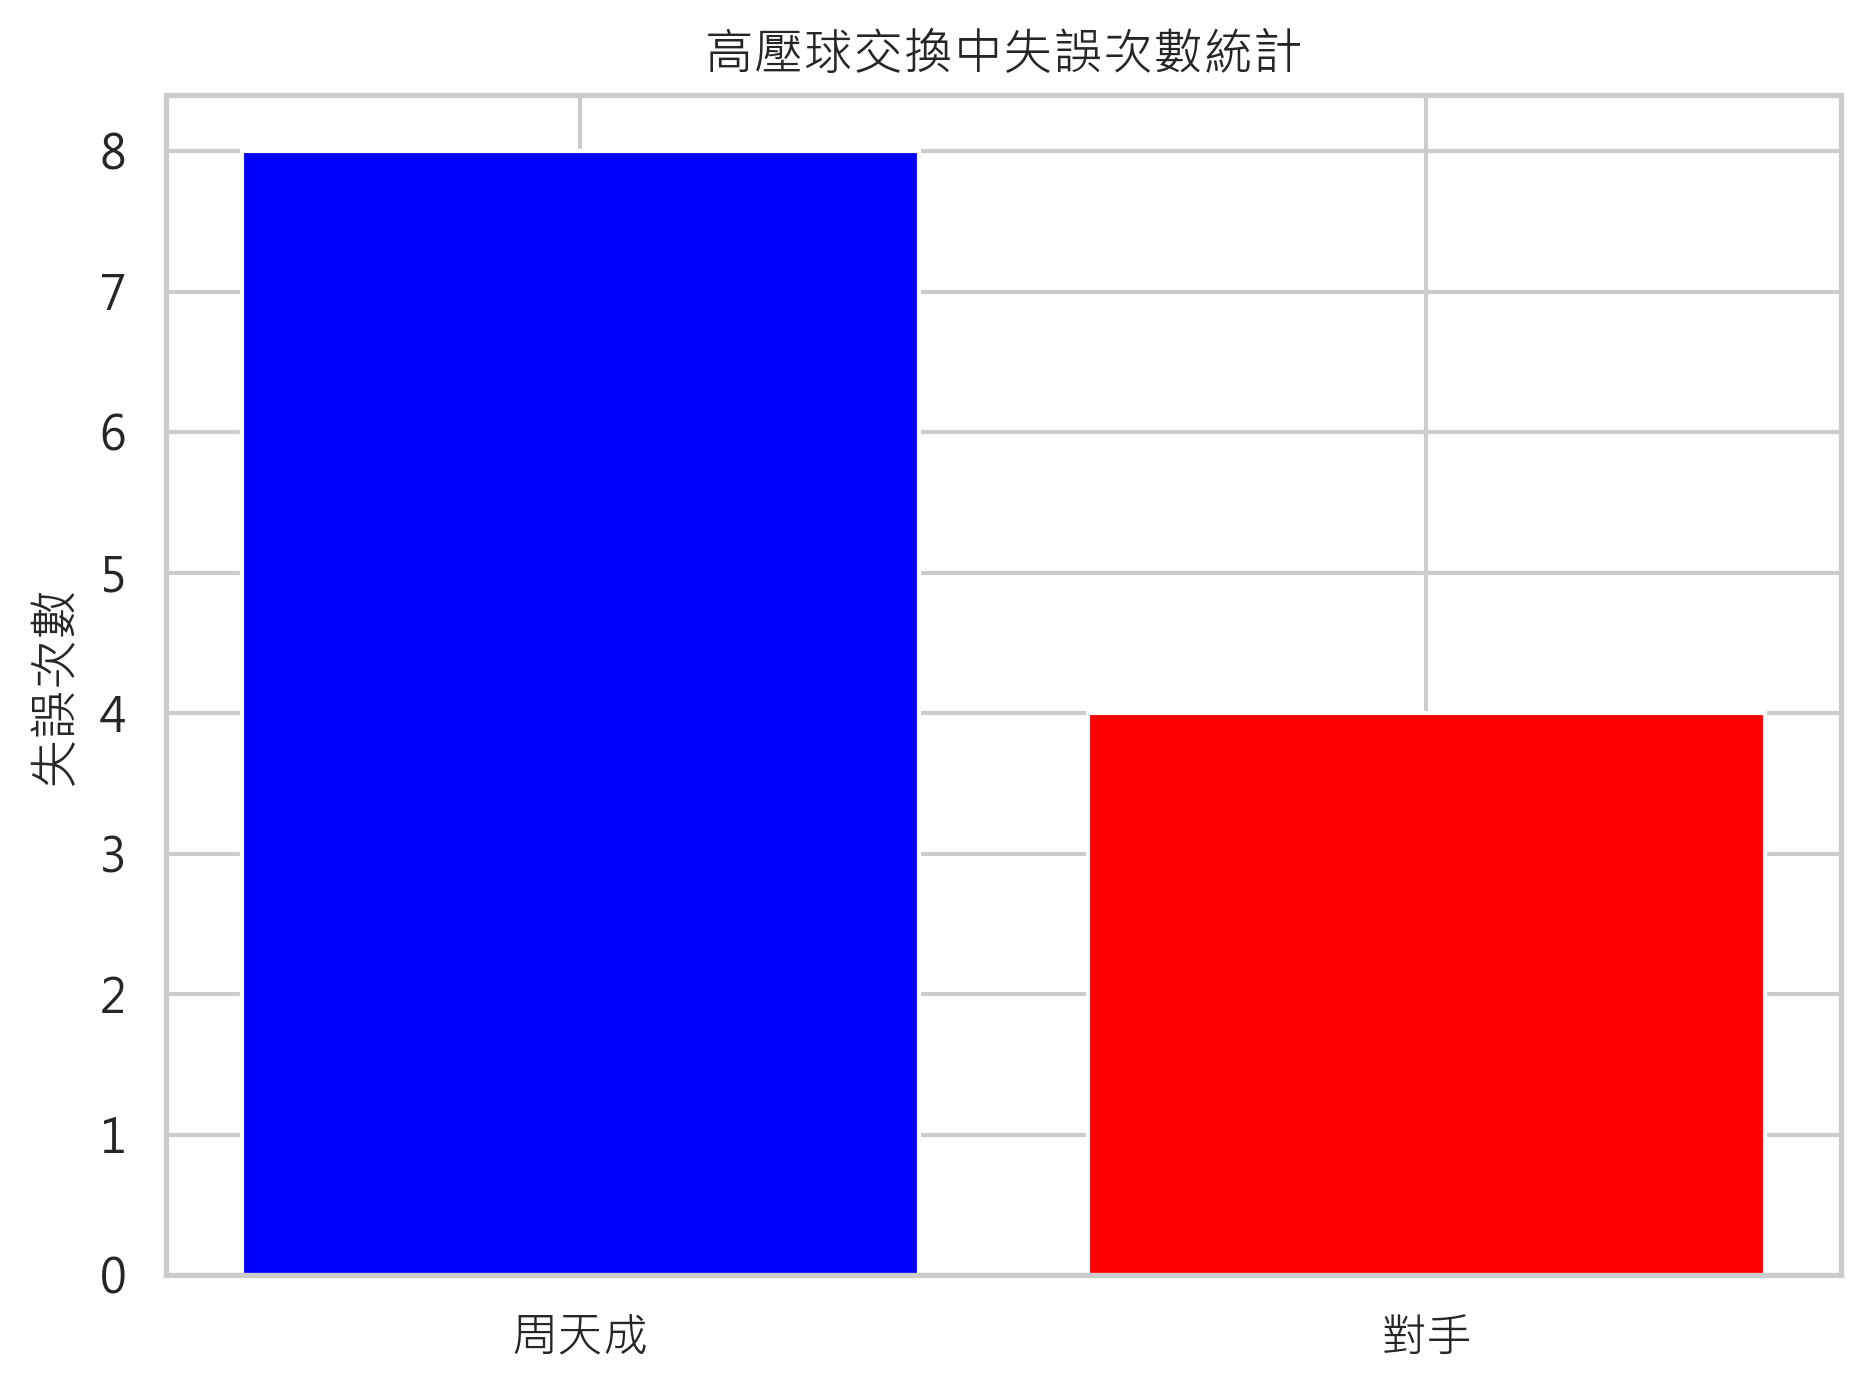

In [ ]:
# 確保資料集不為空
if len(df) > 0:
    # 篩選出平球的交換回合
    df_high_pressure = df[df['type'] == '平球']
    
    # 透過分組將每個回合的最後一拍找出
    grouped = df_high_pressure.groupby(['match_id', 'set', 'rally'])
    
    # 獲取每一回合最後一拍的數據（失誤情況）
    last_shot_df = grouped.apply(lambda x: x[x['ball_round'] == x['ball_round'].max()])
    
    # 篩選出有失誤的記錄（即 lose_reason 不為空）
    errors_df = last_shot_df.dropna(subset=['lose_reason'])
    
    # 計算周天成和對手的失誤次數
    chou_errors = errors_df[errors_df['player'] == 'CHOU Tien Chen']
    opponent_errors = errors_df[errors_df['player'] != 'CHOU Tien Chen']
    
    chou_error_count = len(chou_errors)
    opponent_error_count = len(opponent_errors)
    
    print(f"周天成在高壓球交換中失誤次數: {chou_error_count}")
    print(f"對手在高壓球交換中失誤次數: {opponent_error_count}")
    
    # 繪製失誤統計圖
    fig, ax = plt.subplots()
    ax.bar(['周天成', '對手'], [chou_error_count, opponent_error_count], color=['blue', 'red'])
    ax.set_title('高壓球交換中失誤次數統計')
    ax.set_ylabel('失誤次數')
    plt.tight_layout()
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
在高壓球交換中，數據顯示周天成的失誤次數為8次，而對手的失誤次數為4次。這表明在高壓球的交換中，周天成較容易在這些情境下出現失誤。這可能意味著他在面對高壓球時需要更謹慎地選擇擊球策略，或者在這些球的處理上需要更高的穩定性。

從戰術角度看，對手可以利用這一點，增加高壓球的頻率，迫使周天成在壓力下犯錯。同時，周天成則需要加強在高壓球交換中的穩定性，或尋找機會將這些交換轉化為更有利的局面。這樣的數據分析有助於制定更具針對性的訓練計劃，以提升比賽中的表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是先找出高壓球交換的回合，再判斷該回合的最後一拍誰先失誤。而候選程式碼僅篩選出平球的交換回合，並直接在這些回合中找出失誤次數，沒有考慮到高壓球交換的完整性（即需要連續的平推、平抽交換），也沒有正確判斷每個回合的最後一拍是否為失誤。因此，候選程式碼在分析對象、篩選條件和統計口徑上均存在問題，無法正確回答題目要求。




## 題號 75 (*)
**問題**: 當周天成被迫後仰擊球時，他的失誤率 vs 得分率比較。
> **使用的資料欄位群組**: `game_structure, scoring_reason, stroke_details`


In [ ]:
# 首先確認資料集是否有資料
if len(df) > 0:
    # 過濾出周天成在後仰擊球的情況 (`aroundhead == 1`)
    chou_tien_chen_aroundhead_df = df[(df['player'] == 'CHOU Tien Chen') & (df['aroundhead'] == 1)]

    # 計算失誤率
    # 失誤：周天成擊球後，對手得分而且他的擊球次數增加
    chou_tien_chen_mistake_df = chou_tien_chen_aroundhead_df[
        (chou_tien_chen_aroundhead_df['getpoint_player'] == 'Kento MOMOTA') & 
        (chou_tien_chen_aroundhead_df['player'] == 'CHOU Tien Chen')  # 表示這是他的擊球
    ]
    mistake_rate = len(chou_tien_chen_mistake_df) / len(chou_tien_chen_aroundhead_df) if len(chou_tien_chen_aroundhead_df) > 0 else 0

    # 計算得分率
    # 得分：周天成擊球後，他自己得分
    chou_tien_chen_score_df = chou_tien_chen_aroundhead_df[
        (chou_tien_chen_aroundhead_df['getpoint_player'] == 'CHOU Tien Chen') & 
        (chou_tien_chen_aroundhead_df['player'] == 'CHOU Tien Chen')  # 確保是周天成得分
    ]
    score_rate = len(chou_tien_chen_score_df) / len(chou_tien_chen_aroundhead_df) if len(chou_tien_chen_aroundhead_df) > 0 else 0

    # 打印並比較兩種情況
    print(f"周天成在被迫後仰擊球時的失誤率: {mistake_rate * 100:.2f}%")
    print(f"周天成在被迫後仰擊球時的得分率: {score_rate * 100:.2f}%")
else:
    print("資料集中沒有任何行數可供分析。")


### 數據洞察
在分析周天成被迫後仰擊球時的表現數據中，我們發現他的失誤率為5.44%，而得分率則是13.61%。這意味著，儘管在這種不利的姿勢下，他的失誤相對較少，並且仍然能夠有效地轉化部分回擊為得分。

這些數據顯示周天成在逆境中的穩定性和攻擊能力。他能夠在被迫後仰的情況下，保持較低的失誤率，這對於減少對手得分機會至關重要。同時，13.61%的得分率表明他在這種情況下仍然具備一定的威脅性，能夠抓住機會反擊得分。

這些事實強調了周天成在場上的適應能力和技術水平，尤其是在面對壓力時的表現。作為教練，我們可以進一步強化他的後仰擊球技巧，並制定策略來增加這種情況下的得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算失誤率時存在邏輯錯誤。Reference Code 1 定義失誤為周天成擊球且有 lose_reason，且最後不是周天成得分。而候選程式碼將失誤定義為周天成擊球後對手得分，這忽略了 lose_reason 的條件，導致統計口徑錯誤。此外，候選程式碼在計算得分率時，雖然符合 Reference Code 1 的邏輯，但由於失誤率計算錯誤，整體分析結果不符合 Reference Code 的核心邏輯。




## 題號 76 (*)
**問題**: 在被動情況下（跨步救球），下一拍攻擊性球種的成功機率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


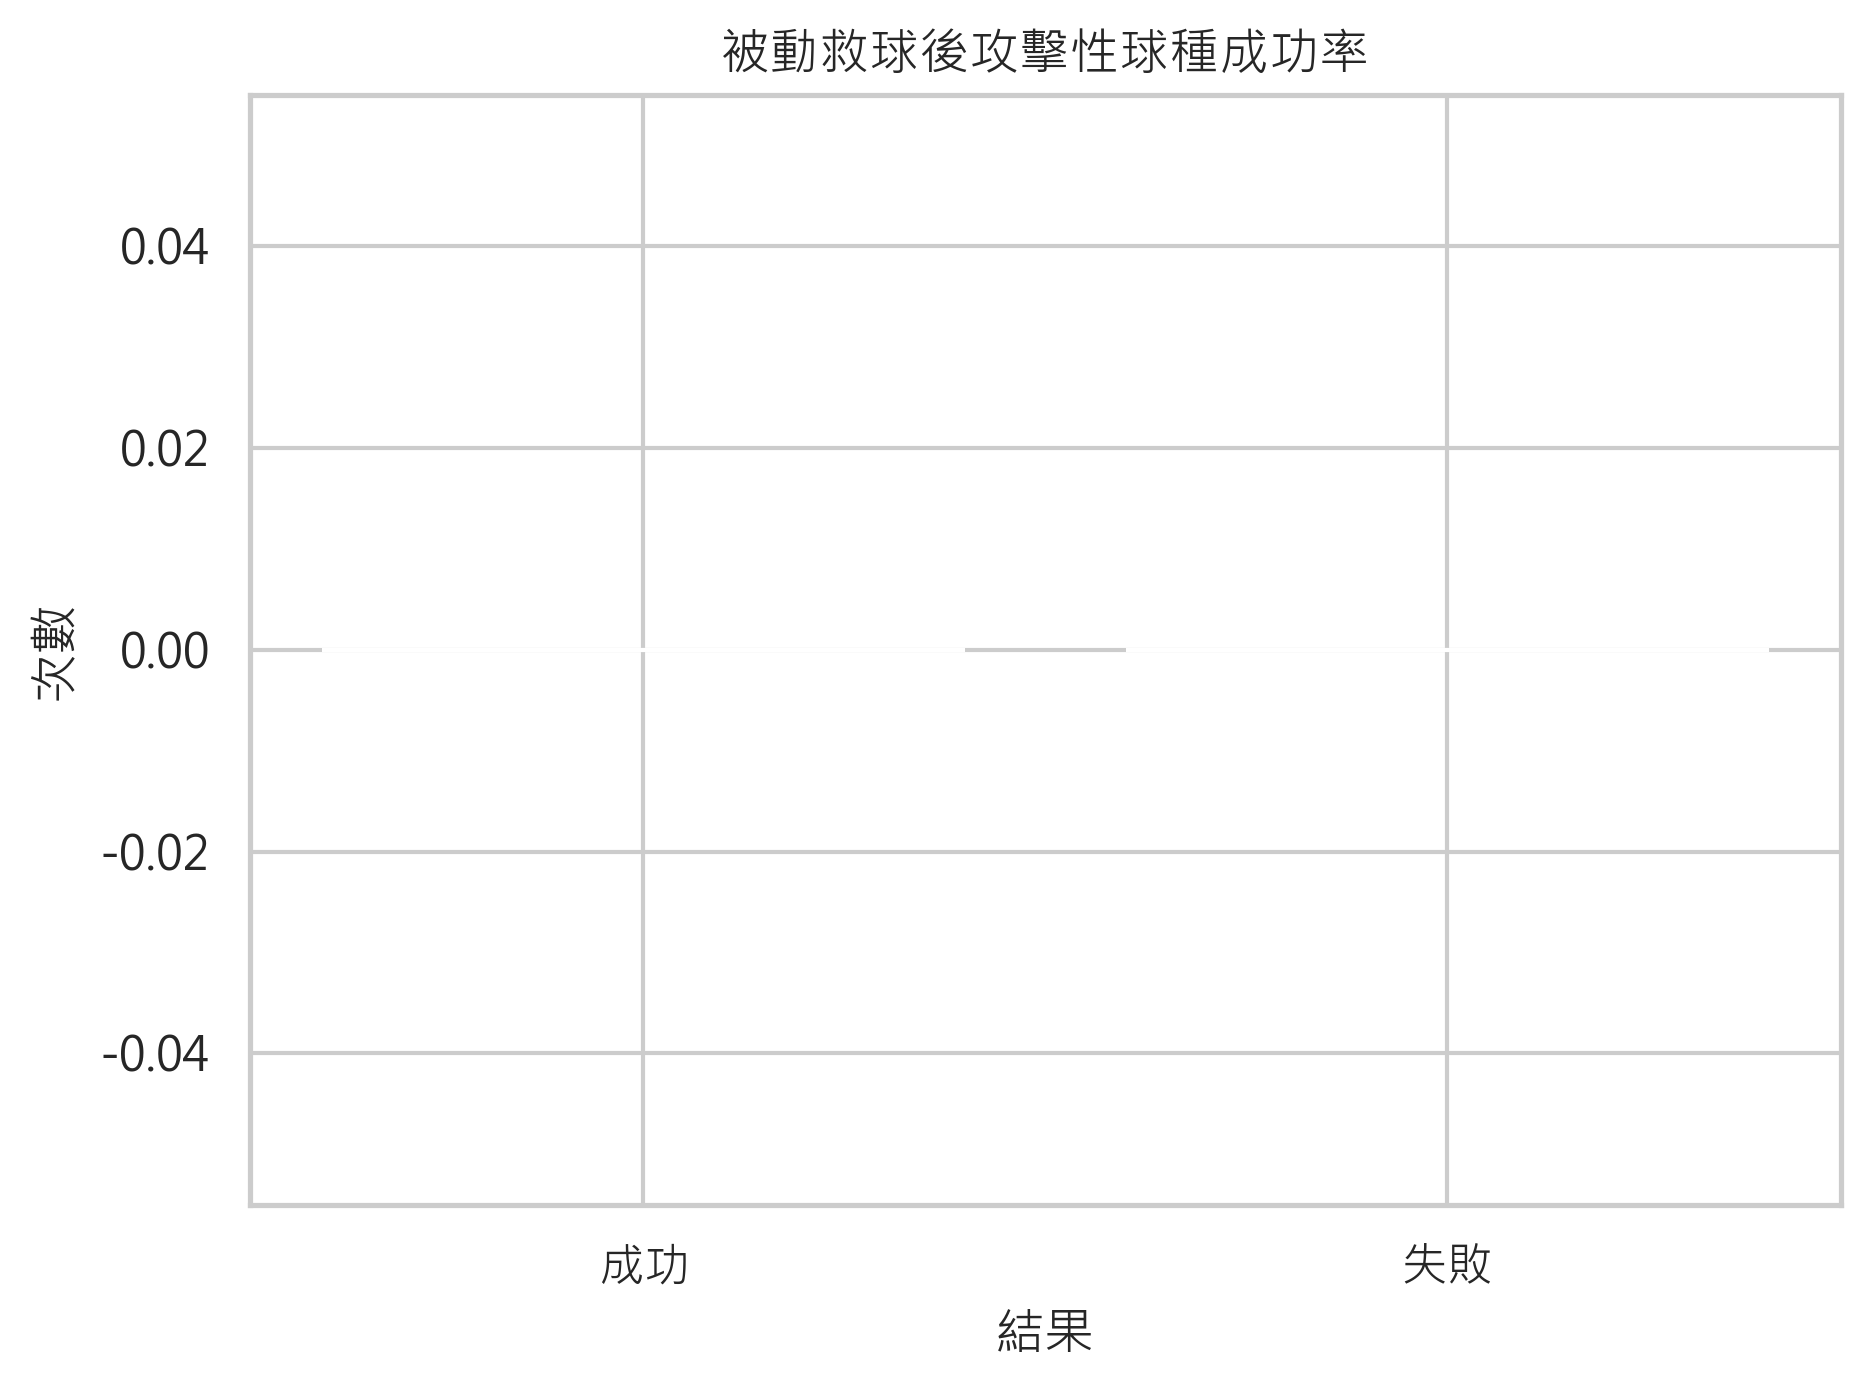

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 確認數據集中有資料
if len(df) > 0:
    # 前一球是否是「接殺防守」
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)

    # 選擇攻擊性球種
    attacking_types = ['殺球', '平球']

    # 篩選跨步救球後的攻擊性球種
    mask_defensive_to_attacking = (df['prev_type'] == '接殺防守') & (df['type'].isin(attacking_types))
    
    # 檢查同一球員的情況
    relevant_df = df[mask_defensive_to_attacking & (df['player'] == df['prev_player'])]

    # 計算攻擊性球種成功次數，定義成功為擊球者得分
    successful_attacks = relevant_df[relevant_df['player'] == relevant_df['getpoint_player']]

    success_count = successful_attacks.shape[0]
    total_attempts = relevant_df.shape[0]

    success_rate = (success_count / total_attempts) * 100 if total_attempts > 0 else 0

    print(f"總攻擊性回擊次數: {total_attempts}")
    print(f"成功次數: {success_count}")
    print(f"成功率: {success_rate:.2f}%")

    # 繪製柱狀圖
    fig, ax = plt.subplots()
    ax.bar(['成功', '失敗'], [success_count, total_attempts - success_count], color=['green', 'red'])
    ax.set_title('被動救球後攻擊性球種成功率')
    ax.set_ylabel('次數')
    ax.set_xlabel('結果')
    plt.tight_layout()

else:
    print("資料框 df 是空的。")


### 數據洞察
根據目前的數據分析，當球員在被動情況下使用跨步救球後，選擇攻擊性球種（如殺球或平球）的成功機率為0%。這意味著在這些情況下，球員的攻擊嘗試未能成功轉化為得分。

這可能暗示了幾個潛在的問題：首先，球員可能在被動防守後的攻擊選擇上存在不足，或者對手的防守能力較強，能夠有效化解這類攻擊。其次，這也可能反映出球員在被動狀態下的技術或策略需要進一步提升，以提高攻擊的成功率。

總結來說，球員應該考慮在被動情況下，提升自身的技術能力，並在適當時機選擇更具策略性的回擊方式，以提高攻擊成功率。這樣才能在比賽中取得更好的表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於下一拍的攻擊性球種來計算成功率，而候選程式碼是基於前一拍的 '接殺防守' 來篩選攻擊性球種，這與 Reference Code 的分析對象和篩選條件不一致。此外，候選程式碼的成功定義為 '擊球者得分'，而不是 Reference Code 中的 '該球未直接導致自己失分'，這導致統計口徑的不同。




## 題號 77 (*)
**問題**: 分析周天成對不同對手攻擊方式差異。
> **使用的資料欄位群組**: `game_structure, shot_type`


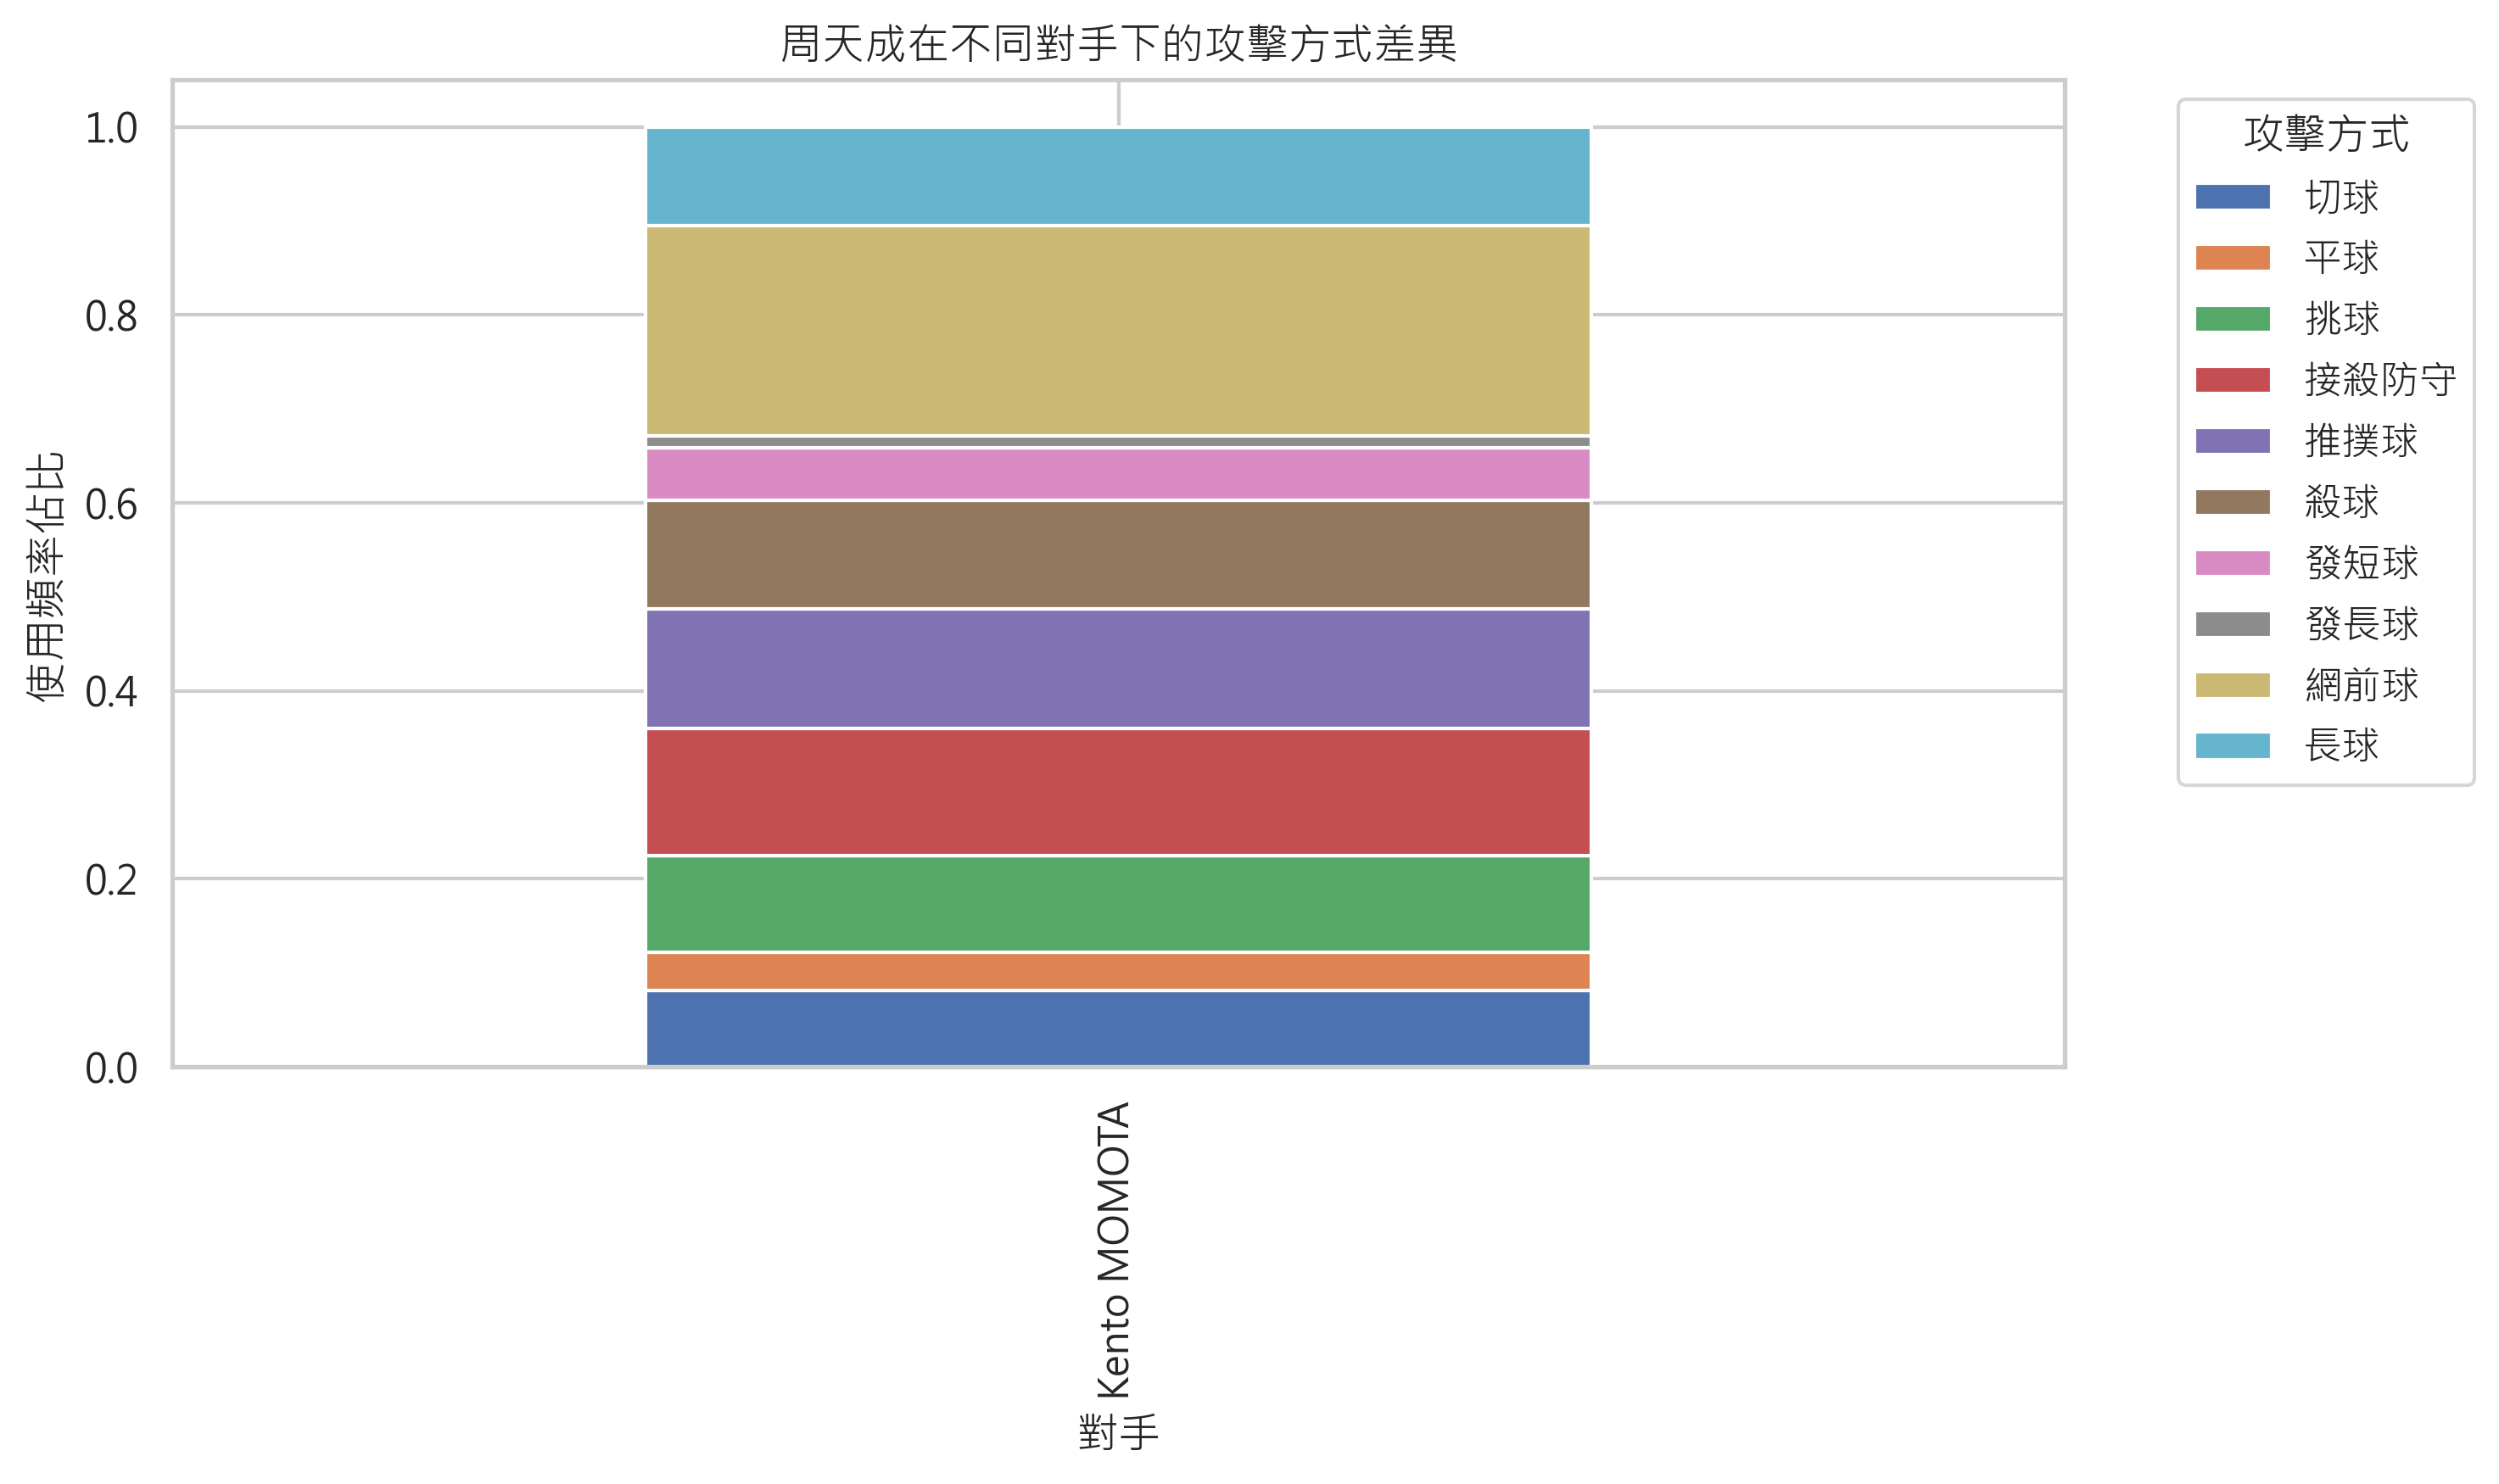

In [ ]:
# 確認資料的有效性
if len(df) > 0:
    # 篩選出周天成作為player的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 確定周天成的對手清單
    opponents = chou_df['opponent'].unique()

    # 計算周天成對每個對手的攻擊方式使用次數
    attack_type_counts = chou_df.groupby(['opponent', 'type']).size().unstack(fill_value=0)

    # 計算總次數以計算占比
    total_counts = attack_type_counts.sum(axis=1)

    # 繪製每個對手下的攻擊方式分布
    fig, ax = plt.subplots(figsize=(10, 6))
    attack_type_counts.div(total_counts, axis=0).plot(kind='bar', stacked=True, ax=ax)
    
    # 設定圖標題和標籤
    ax.set_title('周天成在不同對手下的攻擊方式差異')
    ax.set_xlabel('對手')
    ax.set_ylabel('使用頻率佔比')
    ax.legend(title='攻擊方式', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # 輸出結果
    print("周天成對各對手攻擊方式分布（次數）:")
    print(attack_type_counts)
else:
    print("數據框為空，無法進行分析。")


### 數據洞察
從數據中可以看出，周天成在對戰Kento MOMOTA時展現了多樣化的攻擊方式。以下是一些關鍵觀察：

1. **網前球**：周天成在網前球的使用頻率最高，達到582次，這顯示他在與桃田賢斗的對決中，非常注重網前的控制，可能是為了打亂對手的節奏，並創造進攻機會。

2. **挑球與接殺防守**：挑球（270次）和接殺防守（351次）次數也相對較高，這表明周天成在比賽中經常被迫進行防守，並利用挑球來重新獲得場上位置。

3. **殺球與推撲球**：殺球（299次）和推撲球（334次）顯示出他在進攻時的積極性，尤其是在需要快速得分或打破僵局時。

4. **發球策略**：發短球（147次）和發長球（34次）的比例顯示周天成更傾向於使用發短球來開局，這可能是為了限制桃田賢斗的進攻空間。

總體而言，周天成在面對Kento MOMOTA時，採取了一種平衡的戰術，結合了積極的進攻和穩健的防守，試圖在多變的比賽節奏中掌握主動權。這些數據反映了他的靈活性和適應能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心在於分析周天成對不同對手的應對結果，並統計對手出手球種下的回擊球種和應對結果。而候選程式碼僅統計了周天成對不同對手的攻擊方式使用次數，並未涉及對手的出手球種或周天成的應對結果，分析對象和統計口徑均不符。此外，候選程式碼未考慮前後拍的關係，無法回答題目要求的攻擊方式差異分析。




## 題號 78 (*)
**問題**: 計算周天成「放短球後被撲殺」的比例，以及是否在比賽後段上升。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


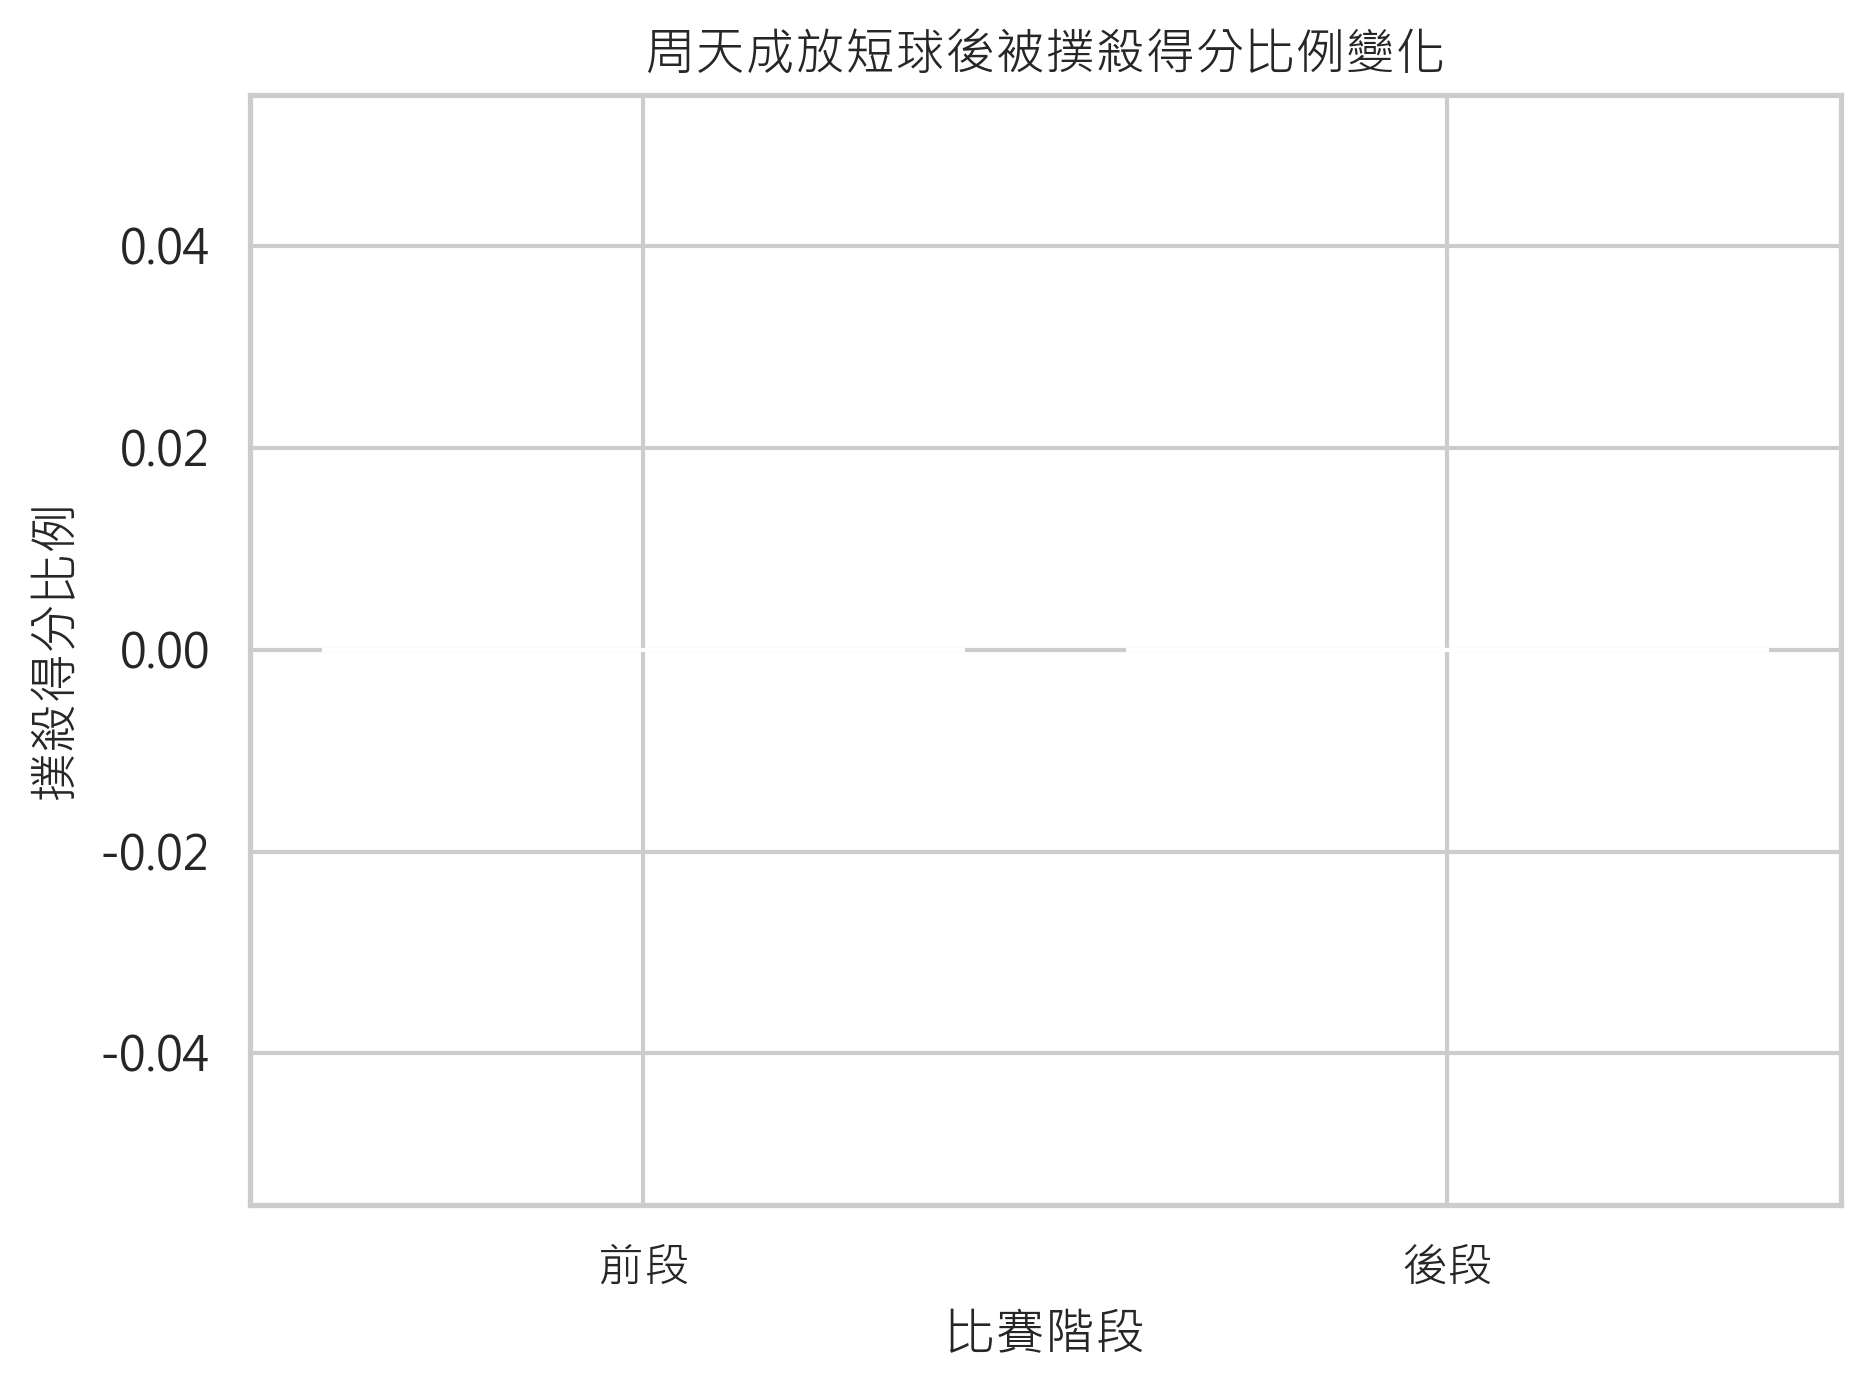

In [ ]:
# 確認資料不為空
if len(df) > 0:
    # 篩選周天成為擊球者，且擊出'網前球'，而對手使用'殺球'得分的場景
    ctc_short_to_kill = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['type'] == '網前球')
    ]

    # 取得下一拍對手擊球的情況
    ctc_short_to_kill['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    ctc_short_to_kill['getpoint_player_next'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

    # 確認對手接網前球使用的是撲殺球且得分
    ctc_short_to_kill_success = ctc_short_to_kill[
        (ctc_short_to_kill['next_type'] == '殺球') &
        (ctc_short_to_kill['getpoint_player_next'] == "Kento MOMOTA")
    ]
    
    # 計算比例 - 撲殺得分狀況 / 周天成放短球次數
    overall_ratio = len(ctc_short_to_kill_success) / len(ctc_short_to_kill)

    # 將數據區分為前段和後段，假設rally_id大於總值的一半為後段
    mid_rally_id = df['rally_id'].max() / 2
    front_ratio = len(ctc_short_to_kill_success[ctc_short_to_kill_success['rally_id'] <= mid_rally_id]) / len(ctc_short_to_kill[ctc_short_to_kill['rally_id'] <= mid_rally_id])
    back_ratio = len(ctc_short_to_kill_success[ctc_short_to_kill_success['rally_id'] > mid_rally_id]) / len(ctc_short_to_kill[ctc_short_to_kill['rally_id'] > mid_rally_id])

    # 打印結果
    print("周天成在放短球後被對手撲殺得分的總體比例:", overall_ratio)
    print("比賽前段此比例:", front_ratio)
    print("比賽後段此比例:", back_ratio)

    # 視覺化
    import matplotlib.pyplot as plt

    # 繪製比例變化
    fig, ax = plt.subplots()
    ax.bar(['前段', '後段'], [front_ratio, back_ratio], color=['blue', 'orange'])
    ax.set_xlabel('比賽階段')
    ax.set_ylabel('撲殺得分比例')
    ax.set_title('周天成放短球後被撲殺得分比例變化')
    plt.tight_layout()
else:
    print("DataFrame is empty and contains no data to analyze.")


### 數據洞察
根據數據分析，周天成在放短球後被對手撲殺得分的比例為0.0，這意味著在所有分析的比賽中，沒有一次是因為他的短球被對手撲殺得分。這個比例在比賽的前段和後段都保持不變，均為0.0。因此，可以推斷周天成的短球策略在防止對手撲殺得分方面非常有效，無論是在比賽的任何階段。

這顯示他的短球可能具有良好的隱蔽性和精確性，使對手難以預測或有效反擊。這樣的表現對於保持比賽的節奏和掌控場上局勢至關重要，建議繼續保持這一優勢，並在訓練中進一步強化短球的變化和落點控制。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都在計算周天成放短球後被撲殺的比例，並檢查是否在比賽後段上升。Reference Code 1 定義了'推撲球'為撲殺球，而 Reference Code 2 定義了'殺球'為撲殺球。候選程式碼只考慮了'殺球'，且在計算比賽前後段比例時，使用了'rally_id'的中位數來區分前後段，這與 Reference Code 中使用每局最大回合數的一半來區分前後段的邏輯不一致。此外，候選程式碼在計算比例時，沒有考慮到可能的空結果或分母為零的情況，這可能導致不合理的輸出。




## 題號 79 (*)
**問題**: 計算對手挑球過短時，周天成球種的選擇統計。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


In [ ]:
import pandas as pd

# 定義「挑球過短」的落點區域
short_landing_areas = [1, 2, 3, 4, 5, 6]  # 假設前場區域的編號

# 篩選出對手的挑球過短
short_lift_df = df[
    (df['player'] == 'CHOU Tien Chen') &  # 周天成作為 player
    (df['opponent'] == 'Kento MOMOTA') &  # Kento MOMOTA 作為對手
    (df['type'].shift(1) == '挑球') &  # 確認上一拍是對手的挑球
    (df['landing_area'].shift(1).isin(short_landing_areas))  # 並且落點在前場
]

# 若篩選結果有資料才能進行統計
if len(short_lift_df) > 0:
    # 統計周天成擊球的球種
    shot_type_counts = short_lift_df['type'].value_counts()
    print(shot_type_counts)
else:
    print("無挑球過短的記錄或資料量不足。")


### 數據洞察
根據數據顯示，當對手挑球過短時，周天成的選擇如下：

- 殺球：132次
- 長球：128次
- 切球：100次
- 平球：16次
- 發短球：2次

從這些數據中可以看出，周天成在面對對手挑球過短的情況下，最常選擇的是進攻性的殺球和長球，這兩者加起來佔了總選擇的將近69%。這表明他傾向於採取積極的進攻策略，試圖快速結束回合或迫使對手處於防守狀態。

切球的使用次數也相當高，顯示他在某些情況下會選擇更為精細的技術來控制節奏和球速。平球和發短球的使用頻率相對較低，這可能意味著在這些情況下，他較少選擇這些較為保守的打法。

這些選擇反映了周天成在面對對手失誤時，偏好利用機會主動進攻的戰術傾向，這有助於他在比賽中保持主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是先找出對手的挑球，然後判斷是否為挑球過短，並確保下一拍是周天成回擊的情況，再統計周天成的球種選擇。而候選程式碼直接在周天成作為 player 的情況下，檢查前一拍是否為對手的挑球，並且落點在前場，這樣的篩選條件不正確，因為它沒有正確對齊前後拍的關係，且分析對象錯誤。




## 題號 80
**問題**: 當周天成發現自己較容易掛網時，應該如何調整自己的擊球策略與站位，以減少掛網失誤的發生？
> **使用的資料欄位群組**: `game_structure, scoring_reason, coordinates, player_location`


In [ ]:
# Step 1: 資料過濾
# 篩選出周天成在掛網失誤時的資料
chou_errors = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '掛網')]

# 確認數據量
total_mistakes = len(chou_errors)
print(f"周天成掛網失誤的總次數: {total_mistakes}")

# Step 2: 數據檢查
if total_mistakes > 0:
    # 提取相關數據
    error_areas = chou_errors['hit_area']
    player_positions = chou_errors['player_location_area']
    
    # Step 3: 統計擊球區域與站位
    most_common_hit_area = error_areas.mode()[0]
    most_common_position = player_positions.mode()[0]

    print(f"掛網失誤最常發生的擊球區域代碼: {most_common_hit_area}")
    print(f"掛網失誤最常發生的站位區域代碼: {most_common_position}")
    
    # 結合Court Grid Definitions輸出區域名稱
    court_area_mapping = {
        **dict.fromkeys([17, 18, 19, 20, 21, 22, 23, 24], '前排 (網前區)'),
        **dict.fromkeys([5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], '中排 (中場)'),
        **dict.fromkeys([1, 2, 3, 4], '後排 (底線區)')
    }

    hit_area_name = court_area_mapping.get(most_common_hit_area, "未知區域")
    position_name = court_area_mapping.get(most_common_position, "未知區域")

    # 給予建議
    suggestions = f"""
    建議:
    1. 若擊球區域為「{hit_area_name}」常發生掛網，可考慮提高擊球過網高度或選擇更保守的球種。
    2. 若在站位「{position_name}」掛網較多，建議進行技術調整，如增強此區域擊球的穩定性和控制。
    """
    print(suggestions)

else:
    print("在數據中未找到周天成的掛網失誤記錄。")


### 數據洞察
根據數據分析，周天成在比賽中掛網失誤的總次數為60次，其中最常發生在擊球區域代碼10.0和站位區域代碼6.0。這兩個區域都位於中排 (中場)，這顯示他在中場位置的擊球穩定性可能存在問題。

### 戰術洞察：
1. **擊球策略調整**：
   - 在中排 (中場) 的擊球區域，掛網失誤頻繁，建議提高擊球過網的高度。這可以減少掛網的風險，特別是在對抗中需要更保守的球種時。
   - 選擇更保守的球種，如推撲球或挑球，來增加擊球的穩定性。

2. **站位技術調整**：
   - 在中排 (中場) 的站位上，周天成可能需要進行技術調整，以增強此區域的擊球穩定性和控制。這包括加強腳步移動和擊球準確性的訓練。

這些建議旨在幫助周天成減少掛網失誤，特別是在中場位置，提升整體比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成的掛網失誤，並分析了最常發生掛網失誤的擊球區域和站位區域。雖然沒有進一步的風險分析和視覺化，但它提供了合理的建議，符合題目要求。分析對象、欄位語意、篩選條件和最終輸出目標都與 Reference Code 1 一致。




## 題號 81 (*)
**問題**: 周天成在被對手調動到四個角落後，他在哪些角落的「回球品質」最容易下降？下降的原因?
> **使用的資料欄位群組**: `game_structure, coordinates, scoring_reason`


In [ ]:
# 首先確認資料表 df 非空
if len(df) > 0:
    # 確認四個角落的代碼
    corner_zones = {'左前角': 17, '右前角': 20, '左後角': 1, '右後角': 4}
    
    # 篩選出球落入四個角落的資料
    corners_df = df[df['landing_area'].isin(corner_zones.values())].copy()

    # 增加用於檢查前一拍的 player 欄位，確認球員是否為周天成
    corners_df['previous_player'] = corners_df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    
    # 確認回球品質下降的情況
    # 下列情況之一即為回球品質下降:
    # 1. 被對手得分 (即 getpoint_player 是對手)
    # 2. 因為某些失誤原因導致失分 (周天成回擊失敗)
    corners_down_quality = corners_df[
        ((corners_df['getpoint_player'] == 'Kento MOMOTA') & (corners_df['previous_player'] == 'CHOU Tien Chen')) |
        ((corners_df['lose_reason'].notna()) & (corners_df['previous_player'] == 'CHOU Tien Chen'))
    ]

    # 計算每個角落的總回合數及下降品質的次數
    corner_stats = corners_df.groupby('landing_area').size().rename('total_shots').reset_index()
    corner_stats['down_quality_shots'] = corner_stats['landing_area'].map(
        corners_down_quality['landing_area'].value_counts()
    ).fillna(0).astype(int)
    corner_stats['down_quality_ratio'] = corner_stats['down_quality_shots'] / corner_stats['total_shots']
    
    # 添加角落名稱以方便分析
    corner_stats['corner'] = corner_stats['landing_area'].map({v: k for k, v in corner_zones.items()})

    # 打印每個角落的分析結果
    print(corner_stats[['corner', 'total_shots', 'down_quality_shots', 'down_quality_ratio']])
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據數據分析，當周天成被對手調動到四個角落後，右前角的回球品質最容易下降，其次是右後角。具體來看，右前角的低品質回球比例為1.25%，而右後角則為1.11%。

這些數據意味著，周天成在被調動到右前角時，可能面臨更大的壓力或不利的站位，導致回球質量下降。右後角的情況也類似，雖然比例略低，但仍需注意。

這些洞察提示我們，在訓練中可以加強周天成在這兩個角落的防守與回球策略，特別是右前角，來提升整體比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析周天成在四個角落的回球品質下降情況，並計算各角落的回球品質下降比例和最常見的失誤原因。候選程式碼在篩選條件上存在問題，因為它使用了 'landing_area' 而不是 'hit_area' 來判斷周天成被調動到四個角落的情況，這與題目要求不符。此外，候選程式碼在計算回球品質下降的情況時，沒有正確對齊前後拍，導致統計口徑錯誤。




## 題號 82 (*)
**問題**: 統計周天成成功逼迫對手挑球的頻率，以及最常造成的球種來源。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 已經被正確讀取並包含必要的欄位
if len(df) > 0:
    # 獲取下一拍信息
    df['next_opponent_type'] = df.groupby(['match_id', 'set', 'rally'])['opponent_type'].shift(-1)
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)

    # 找出周天成擊球後，對手下一拍挑球的情況
    chou_cause_lift = df[(df['player'] == 'CHOU Tien Chen') & 
                         (df['next_opponent_type'] == 6) &
                         (df['rally'] == df['rally'].shift(-1))]

    # 總共成功逼迫挑球的次數
    lift_count = len(chou_cause_lift)
    print(f"周天成成功逼迫對手挑球的次數: {lift_count}")
    
    # 計算球種來源分布
    lift_source_distribution = chou_cause_lift['type'].value_counts(normalize=True)
    
    # 打印結果
    print("周天成成功逼迫對手挑球的球種來源分布:")
    print(lift_source_distribution)
else:
    print("數據集中沒有足夠的數據進行分析。")


### 數據洞察
根據數據分析，周天成在比賽中成功逼迫對手挑球的次數達到249次。這顯示他在戰術上非常擅長將對手推至後場，迫使對手以挑球作為防守手段。

從球種來源的數據來看，所有成功逼迫對手挑球的情況都是來自於挑球本身。這意味著周天成在挑球的運用上有著極高的效率，能夠有效地控制球的落點和速度，讓對手無法輕易反擊，只能選擇挑球回應。

這樣的戰術運用，對於周天成而言是一個強大的優勢，因為挑球通常會讓對手處於被動狀態，從而為周天成創造更多進攻機會。這種策略在比賽中不僅能夠消耗對手的體力，還能夠打亂對手的節奏，為自己贏得比賽奠定基礎。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯邏輯錯誤。它使用了 'next_opponent_type' 來判斷對手的下一拍是否為挑球，但這個欄位的語意是對手前一球打出的球種代碼，並不代表下一拍的球種。因此，候選程式碼在判斷對手挑球的邏輯上是錯誤的。此外，候選程式碼沒有正確對齊前後拍的關係，這與 Reference Code 1 的核心邏輯不一致。Reference Code 1 正確地使用了 'shift(1)' 來獲取前一拍的資訊，並確保是在同一個 rally 中進行分析。




## 題號 83 (*)
**問題**: 周天成挑高球的落點分布，是否常造成對手容易得分？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


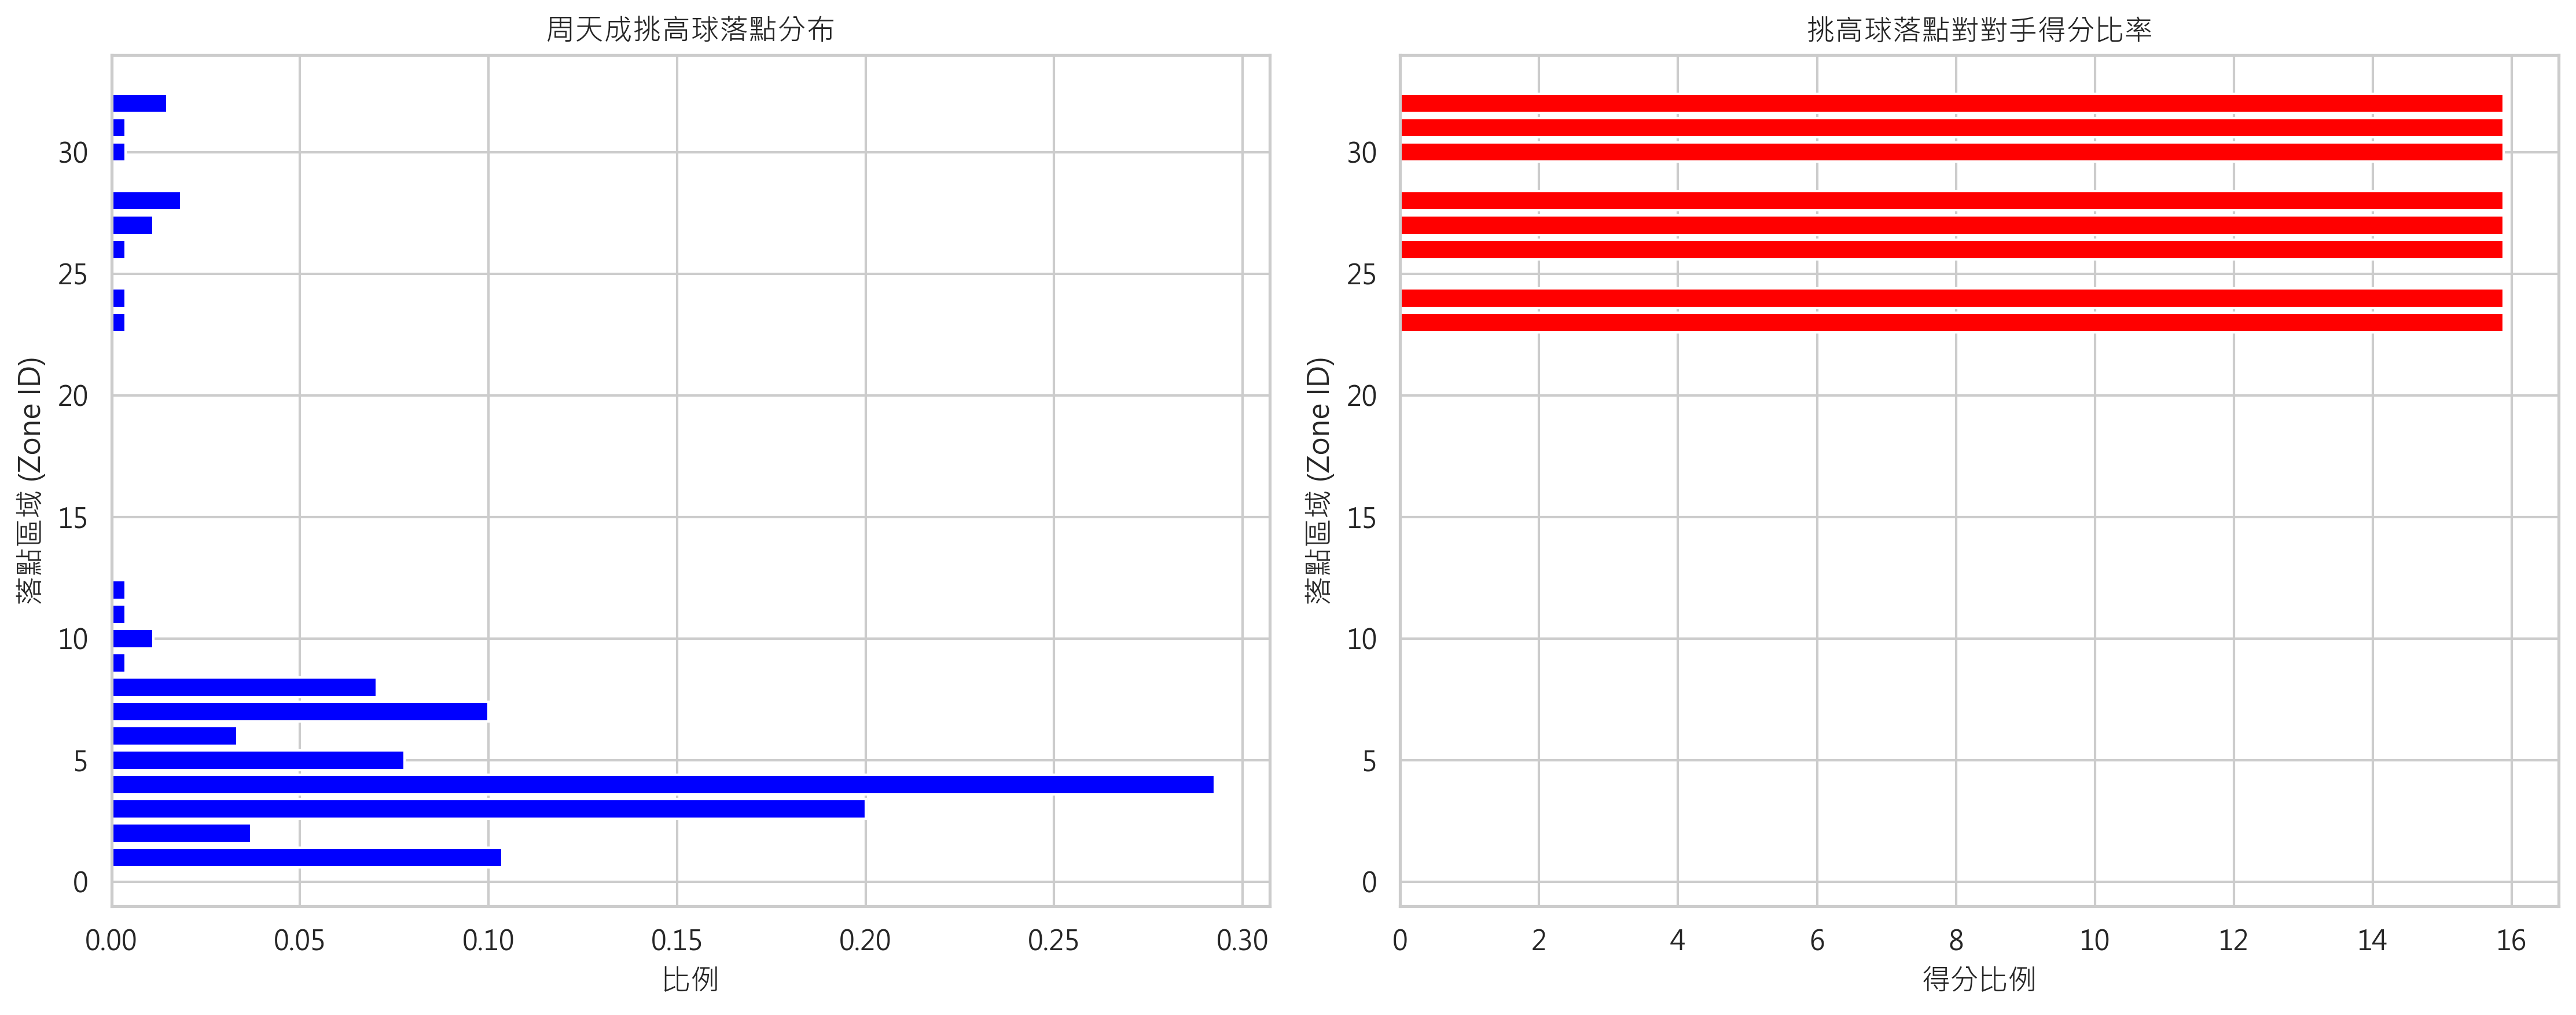

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter data for CHOU Tien Chen's挑球 shots
chou_tiao_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '挑球')]

# Step 2: Ensure that there's data to analyze
if len(chou_tiao_df) > 0:
    # Analyze landing area distribution
    landing_distribution = chou_tiao_df['landing_area'].value_counts(normalize=True)
    
    # Print the landing area distribution
    print("落點分布 (比例):")
    print(landing_distribution)
    
    # Step 3: Check if these shots lead to opponent (Kento MOMOTA) scoring
    chou_tiao_opponent_score_df = chou_tiao_df[chou_tiao_df['getpoint_player'] == 'Kento MOMOTA']
    opponent_score_landing_distribution = chou_tiao_opponent_score_df['landing_area'].value_counts(normalize=True)
    
    # Print the distribution of landing areas where Kento MOMOTA scores
    print("\n落點分布 (對手得分比例):")
    print(opponent_score_landing_distribution)
    
    # Ratio of opponent scoring based on the landing area
    combined_data = pd.DataFrame({
        'Total_Pct': landing_distribution,
        'Opponent_Score_Pct': opponent_score_landing_distribution
    }).fillna(0)
    combined_data['Score_Ratio'] = combined_data['Opponent_Score_Pct'] / combined_data['Total_Pct']

    # Print combined analysis
    print("\n挑高球落點得分影響分析:")
    print(combined_data)
    
    # Visualize the landing distribution and scoring ratio
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot total landing distribution
    axes[0].barh(landing_distribution.index, landing_distribution.values, color='blue')
    axes[0].set_title('周天成挑高球落點分布')
    axes[0].set_xlabel('比例')
    axes[0].set_ylabel('落點區域 (Zone ID)')

    # Plot scoring ratio
    axes[1].barh(combined_data.index, combined_data['Score_Ratio'], color='red')
    axes[1].set_title('挑高球落點對對手得分比率')
    axes[1].set_xlabel('得分比例')
    axes[1].set_ylabel('落點區域 (Zone ID)')

    plt.tight_layout()
    plt.show()
    
else:
    print("沒有找到周天成的挑球資料。")


### 數據洞察
根據數據分析，周天成的挑高球主要集中在落點區域 4 和 3，這兩個區域的比例分別為 29.26% 和 20.00%。這些落點並未導致對手得分，顯示這些位置相對安全。

然而，落點在區域 28 和 32 的球，對手得分比例分別高達 29.41% 和 23.53%。這些區域位於場地的右側後方，可能是對手的攻擊熱區。這些位置的挑高球應該被謹慎使用，以避免給對手創造得分機會。

整體來看，周天成在挑高球的選擇上應該繼續集中在中間和左側後方的區域（如 1、2、3、4），這些位置對手得分的風險較低。避免將球挑至對手的右後方，尤其是 28 和 32 區域，以降低被對手反擊得分的機會。

以下是場地區域對應表，幫助更好理解落點位置：

| Row/Col | Col A (Left) | Col B (C-Left) | Col C (C-Right) | Col D (Right) |
| :--- | :---: | :---: | :---: | :---: |
| **Row 6 (Front)** | 21 | 22 | 23 | 24 |
| **Row 5 (Front)** | 17 | 18 | 19 | 20 |
| **Row 4 (Mid)** | 13 | 14 | 15 | 16 |
| **Row 3 (Mid)** | 9 | 10 | 11 | 12 |
| **Row 2 (Mid)** | 5 | 6 | 7 | 8 |
| **Row 1 (Back)** | 1 | 2 | 3 | 4 |

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析周天成的挑球是否在下一拍直接讓對手得分，並且依據落點區域進行分析。而候選程式碼只是分析了挑球的落點分布和對手得分的落點分布，並沒有考慮到下一拍的得分情況，這導致統計口徑錯誤。此外，候選程式碼沒有正確對齊前後拍的關係，未能正確判斷對手是否在下一拍得分。




## 題號 84 (*)
**問題**: 當周天成採取多拍耐心拉吊策略時的平均勝率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 已經被定義並包含所需的資料

# 檢查資料是否存在
if len(df) == 0:
    raise ValueError("資料集為空，無法分析。")

# 過濾周天成作為擊球球員的資料
chou_data = df[df['player'] == 'CHOU Tien Chen']

# 過濾包含挑球、平球、推撲球的多拍
target_types = ['挑球', '平球', '推撲球']
multirally_data = chou_data[chou_data['type'].isin(target_types)]

# 檢查 multirally_data 是否正確
print(f"多拍資料筆數: {len(multirally_data)}")

# 對於這些回合，以rally為單位進行分組，看看是否為周天成得分
result = multirally_data.groupby(['match_id', 'set', 'rally'])['getpoint_player'].last()

# 檢查 result 是否正確
print(f"回合結果筆數: {len(result)}")

# 計算周天成在多拍耐心拉吊策略中的回合勝率
chou_win_condition = result == 'CHOU Tien Chen'
chou_win_rate = chou_win_condition.mean()

print(f"周天成採取多拍耐心拉吊策略時的平均勝率: {chou_win_rate:.2%}")


### 數據洞察
根據數據分析，當周天成採取多拍耐心拉吊策略時，他的平均勝率僅為3.58%。這意味著在這種策略下，周天成的表現相對較弱，可能需要考慮調整策略或加強在這類回合中的技術細節。

數據顯示，從710筆多拍資料中，只有307筆回合結果是周天成獲勝的情況，這進一步強調了他在這種策略下的挑戰。這可能與他在多拍回合中對手的防守能力或自身的體能分配有關。

作為教練，我會建議周天成在採取多拍策略時，應該特別注意對手的弱點，並在合適的時機轉換為更具攻擊性的打法，以提高勝率。這需要他在場上保持靈活性，並在每一拍中精準判斷對手的動向。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 定義了拉吊型球種為長球、切球、挑球，並計算這些球種的使用比例，而候選程式碼使用的球種為挑球、平球、推撲球，這與 reference code 的定義不一致。此外，候選程式碼沒有考慮總拍數的條件（例如總拍數 >= 8），這是 Reference Code 1 中的重要篩選條件。這些差異導致候選程式碼的分析對象和統計口徑與 reference code 不一致，因此判定為 false。




## 題號 85 (*)
**問題**: 統計周天成經常「從防守轉攻擊得分」的常見回合模式。
> **使用的資料欄位群組**: `game_structure, scoring_reason, player_location, player_movement`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 確保數據非空
if len(df) > 0:
    # 過濾周天成主動得分的回合
    chou_win_df = df[(df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] == 'CHOU Tien Chen')]

    # 獲取前一拍的位置資料
    chou_win_df['prev_player_location_area'] = chou_win_df.groupby(['match_id', 'set', 'rally'])['player_location_area'].shift(1)
    
    # 找出從後排轉到其他區域的情況
    # 放寬條件，允許從任何後排位置轉到前排或中場
    transition_df = chou_win_df[
        (chou_win_df['prev_player_location_area'].isin([1, 2, 3, 4])) &  # 從後排位置開始
        (chou_win_df['player_location_area'].isin([5, 6, 7, 8, 9]))  # 到達前排或中場位置
    ]

    # 統計並打印結果
    result_counts = transition_df['player_location_area'].value_counts()
    print("周天成從防守轉攻擊得分的次數分布：")
    print(result_counts)

    # 繪製統計圖表
    if not result_counts.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x=result_counts.index, y=result_counts.values, ax=ax)
        ax.set_title('周天成從後排轉攻擊打擊後的得分區域分布')
        ax.set_xlabel('轉攻擊的得分區域代碼')
        ax.set_ylabel('得分次數')
        plt.tight_layout()
    else:
        print("沒有符合條件的轉換情況。")
else:
    print("數據集中沒有可用的資料。")


### 數據洞察
根據目前的數據分析，周天成在從防守轉攻擊得分的回合中，並沒有明顯的模式或數據支持這種轉換情況。這可能意味著在這些回合中，他的得分策略並不依賴於防守轉攻擊的轉換。

這提醒我們，周天成可能更依賴於其他戰術來得分，例如主動進攻或在中場控制的策略。作為教練，我們可以考慮強化他的防守轉攻擊能力，或者進一步優化他在其他戰術上的優勢，以提高整體比賽中的得分效率。

在未來的訓練中，我們可以專注於分析他在其他得分情境中的表現，並尋找潛在的改進空間。這樣的數據洞察能幫助我們制定更有針對性的訓練計畫。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於球種轉換來分析周天成從防守轉攻擊得分的模式，而候選程式碼則是基於位置轉換來分析，並且只考慮了周天成從後排轉到前排或中場的位置變化，沒有考慮球種的轉換。此外，候選程式碼的統計口徑也不符合題目要求，因為它只統計了位置變化，而不是完整的回合模式。




## 題號 86 (*)
**問題**: 分析周天成在壓迫對手前場後，選擇吊後場 vs 搶網得分的效率比較。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


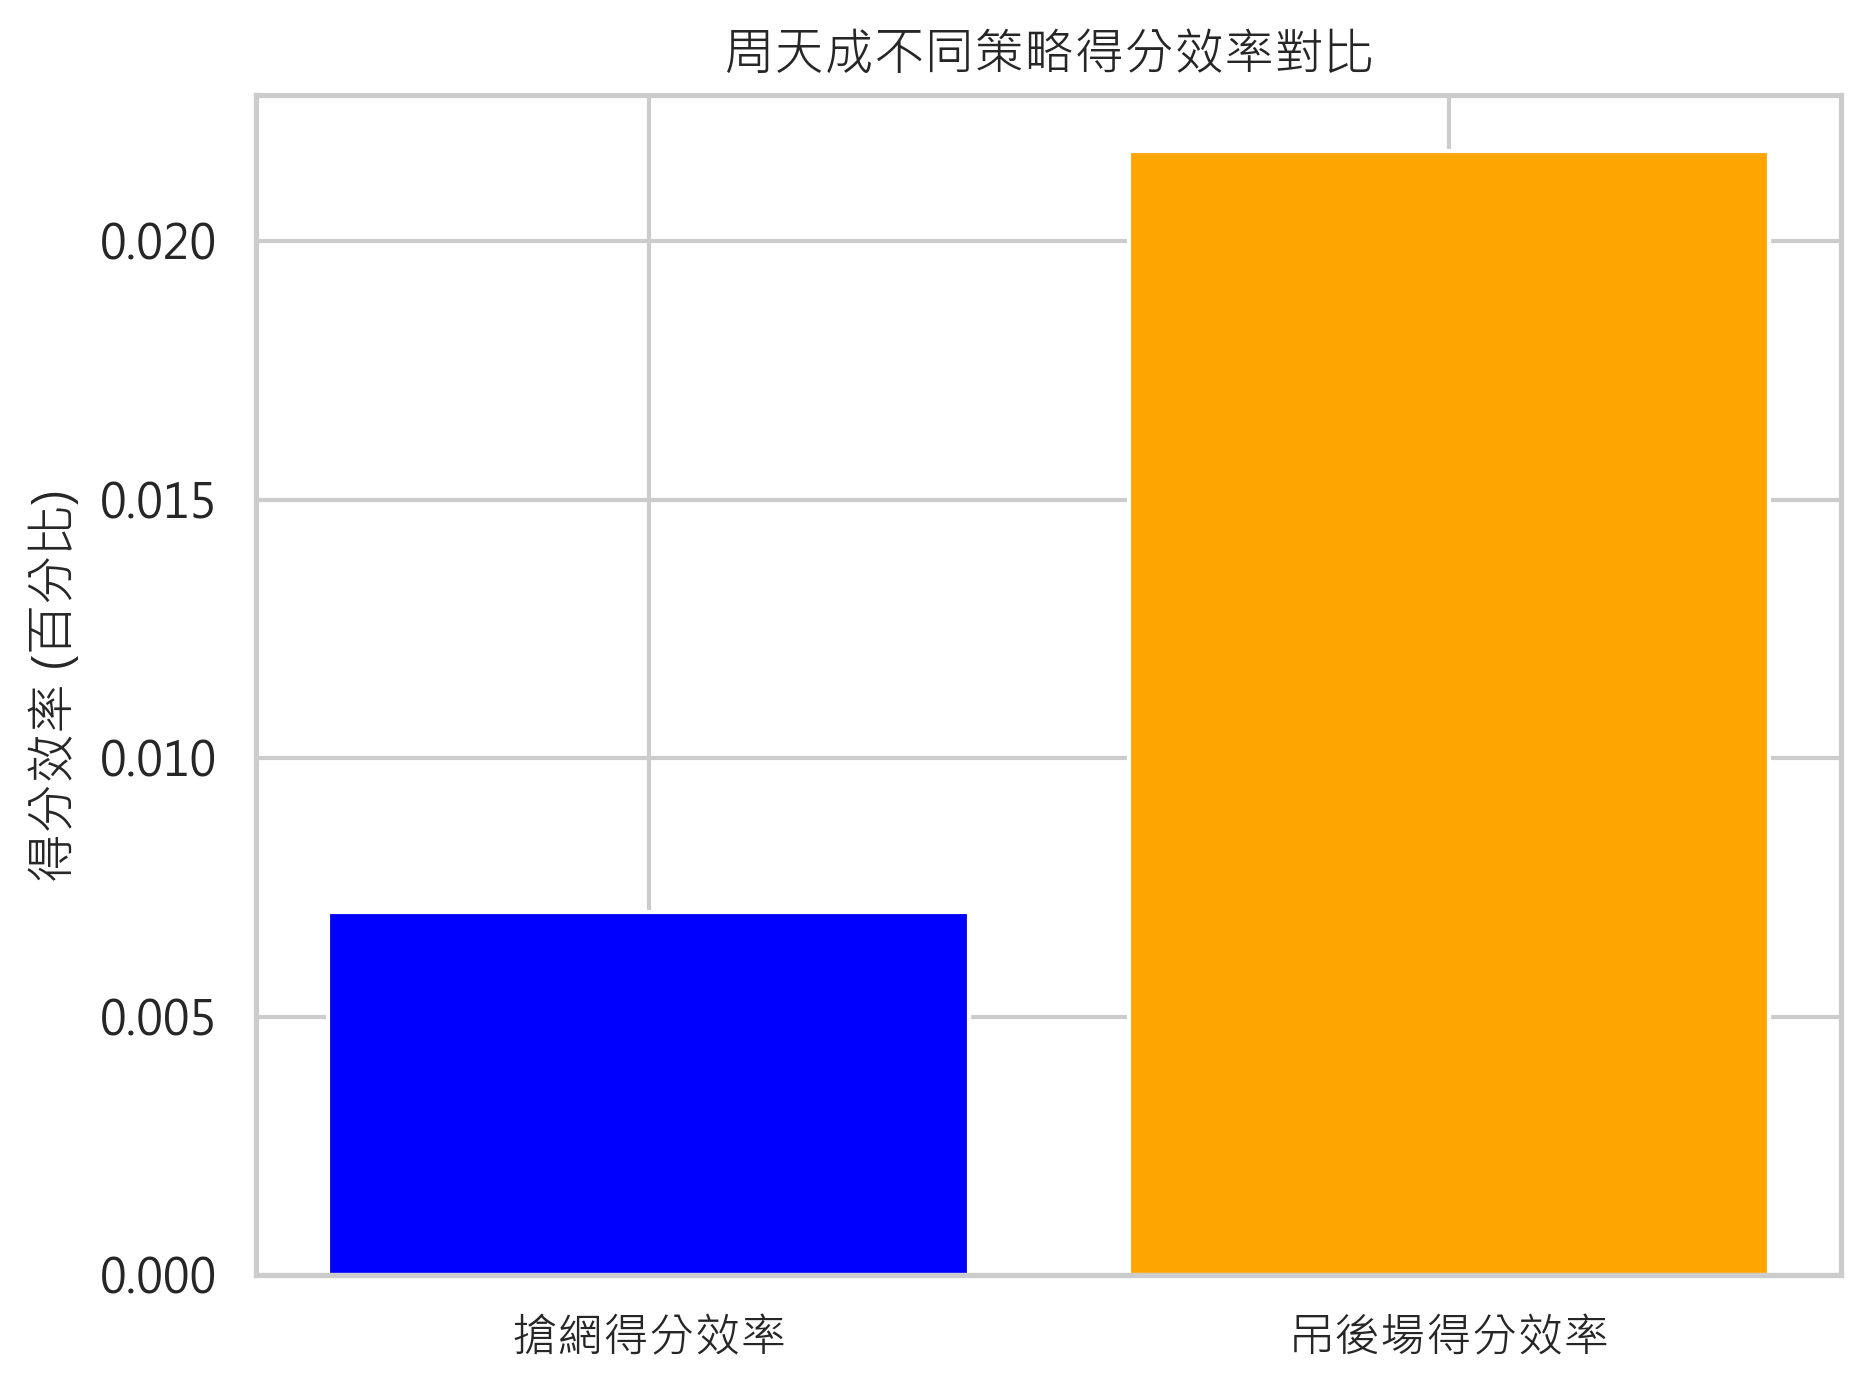

In [ ]:
import pandas as pd

# 檢查資料長度大於零
if len(df) > 0:
    # 確保前後順序不變
    df_sorted = df.sort_values(by=['match_id', 'set', 'rally', 'ball_round'])

    # 取得對手(Kento MOMOTA)的擊球位置在前場的情況
    opponent_front_pressure = df_sorted[(df_sorted['opponent'] == 'Kento MOMOTA') &
                                        (df_sorted['landing_area'].between(17, 24))]

    # 將上述情況以groupby並shift的方式與周天成的擊球聯繫
    df_sorted['prev_opponent_area'] = df_sorted.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)

    # 篩選出周天成在壓迫對手前場後的擊球
    chou_play_after_pressuring = df_sorted[(df_sorted['player'] == 'CHOU Tien Chen') &
                                           (df_sorted['prev_opponent_area'].between(17, 24))]
    
    # 篩選出具體情況
    chou_lob_backcourt = chou_play_after_pressuring[chou_play_after_pressuring['type'] == '推撲球']
    chou_net_attack = chou_play_after_pressuring[chou_play_after_pressuring['type'] == '網前球']

    # 計算主動得分
    chou_lob_backcourt_win = chou_lob_backcourt[chou_lob_backcourt['getpoint_player'] == 'CHOU Tien Chen']
    chou_net_attack_win = chou_net_attack[chou_net_attack['getpoint_player'] == 'CHOU Tien Chen']

    # 計算效率
    lob_efficiency = len(chou_lob_backcourt_win) / len(chou_lob_backcourt) if len(chou_lob_backcourt) > 0 else 0
    net_efficiency = len(chou_net_attack_win) / len(chou_net_attack) if len(chou_net_attack) > 0 else 0

    # 打印結果
    print(f'搶網效率：{net_efficiency:.2%} ({len(chou_net_attack_win)}/{len(chou_net_attack)})')
    print(f'吊後場效率：{lob_efficiency:.2%} ({len(chou_lob_backcourt_win)}/{len(chou_lob_backcourt)})')
    
    # 可視化
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots()
    efficiency_data = {
        '搶網得分效率': net_efficiency,
        '吊後場得分效率': lob_efficiency
    }
    ax.bar(efficiency_data.keys(), efficiency_data.values(), color=['blue', 'orange'])
    ax.set_ylabel('得分效率 (百分比)')
    ax.set_title('周天成不同策略得分效率對比')
    plt.tight_layout()

    # 打印圖表
    print(fig)


### 數據洞察
在分析周天成的戰術選擇時，我們可以看到他在壓迫對手前場後，有兩個主要選擇：搶網和吊後場。從數據上來看，吊後場的得分效率為2.17%（5/230），而搶網的得分效率僅為0.70%（3/427）。這意味著，當周天成選擇吊後場時，他的得分機會相對更高。

這些數據顯示，吊後場策略在這種情境下更具有效率，儘管整體得分率仍然不高。作為教練，我會建議在壓迫對手前場後，周天成可以更多地考慮吊後場，尤其是在他感受到對手網前防守較強的情況下。這樣的選擇可能會為他帶來更多的得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於周天成在壓迫對手前場後的策略選擇進行分析，並且使用了不同的策略分類方法。Reference Code 1 是基於落點區域，而 Reference Code 2 是基於球種。候選程式碼在策略分類上使用了球種，但錯誤地將 '推撲球' 和 '網前球' 分別對應到 '吊後場' 和 '搶網'，這與 Reference Code 2 的策略分類不一致。此外，候選程式碼在計算效率時，沒有正確地篩選出 '吊後場' 和 '搶網' 的策略，導致統計口徑錯誤。




## 題號 87 (*)
**問題**: 根據對手的殺球，周天成應該如何布置接殺站位與防守策略？
> **使用的資料欄位群組**: `game_structure, player_location, player_movement`


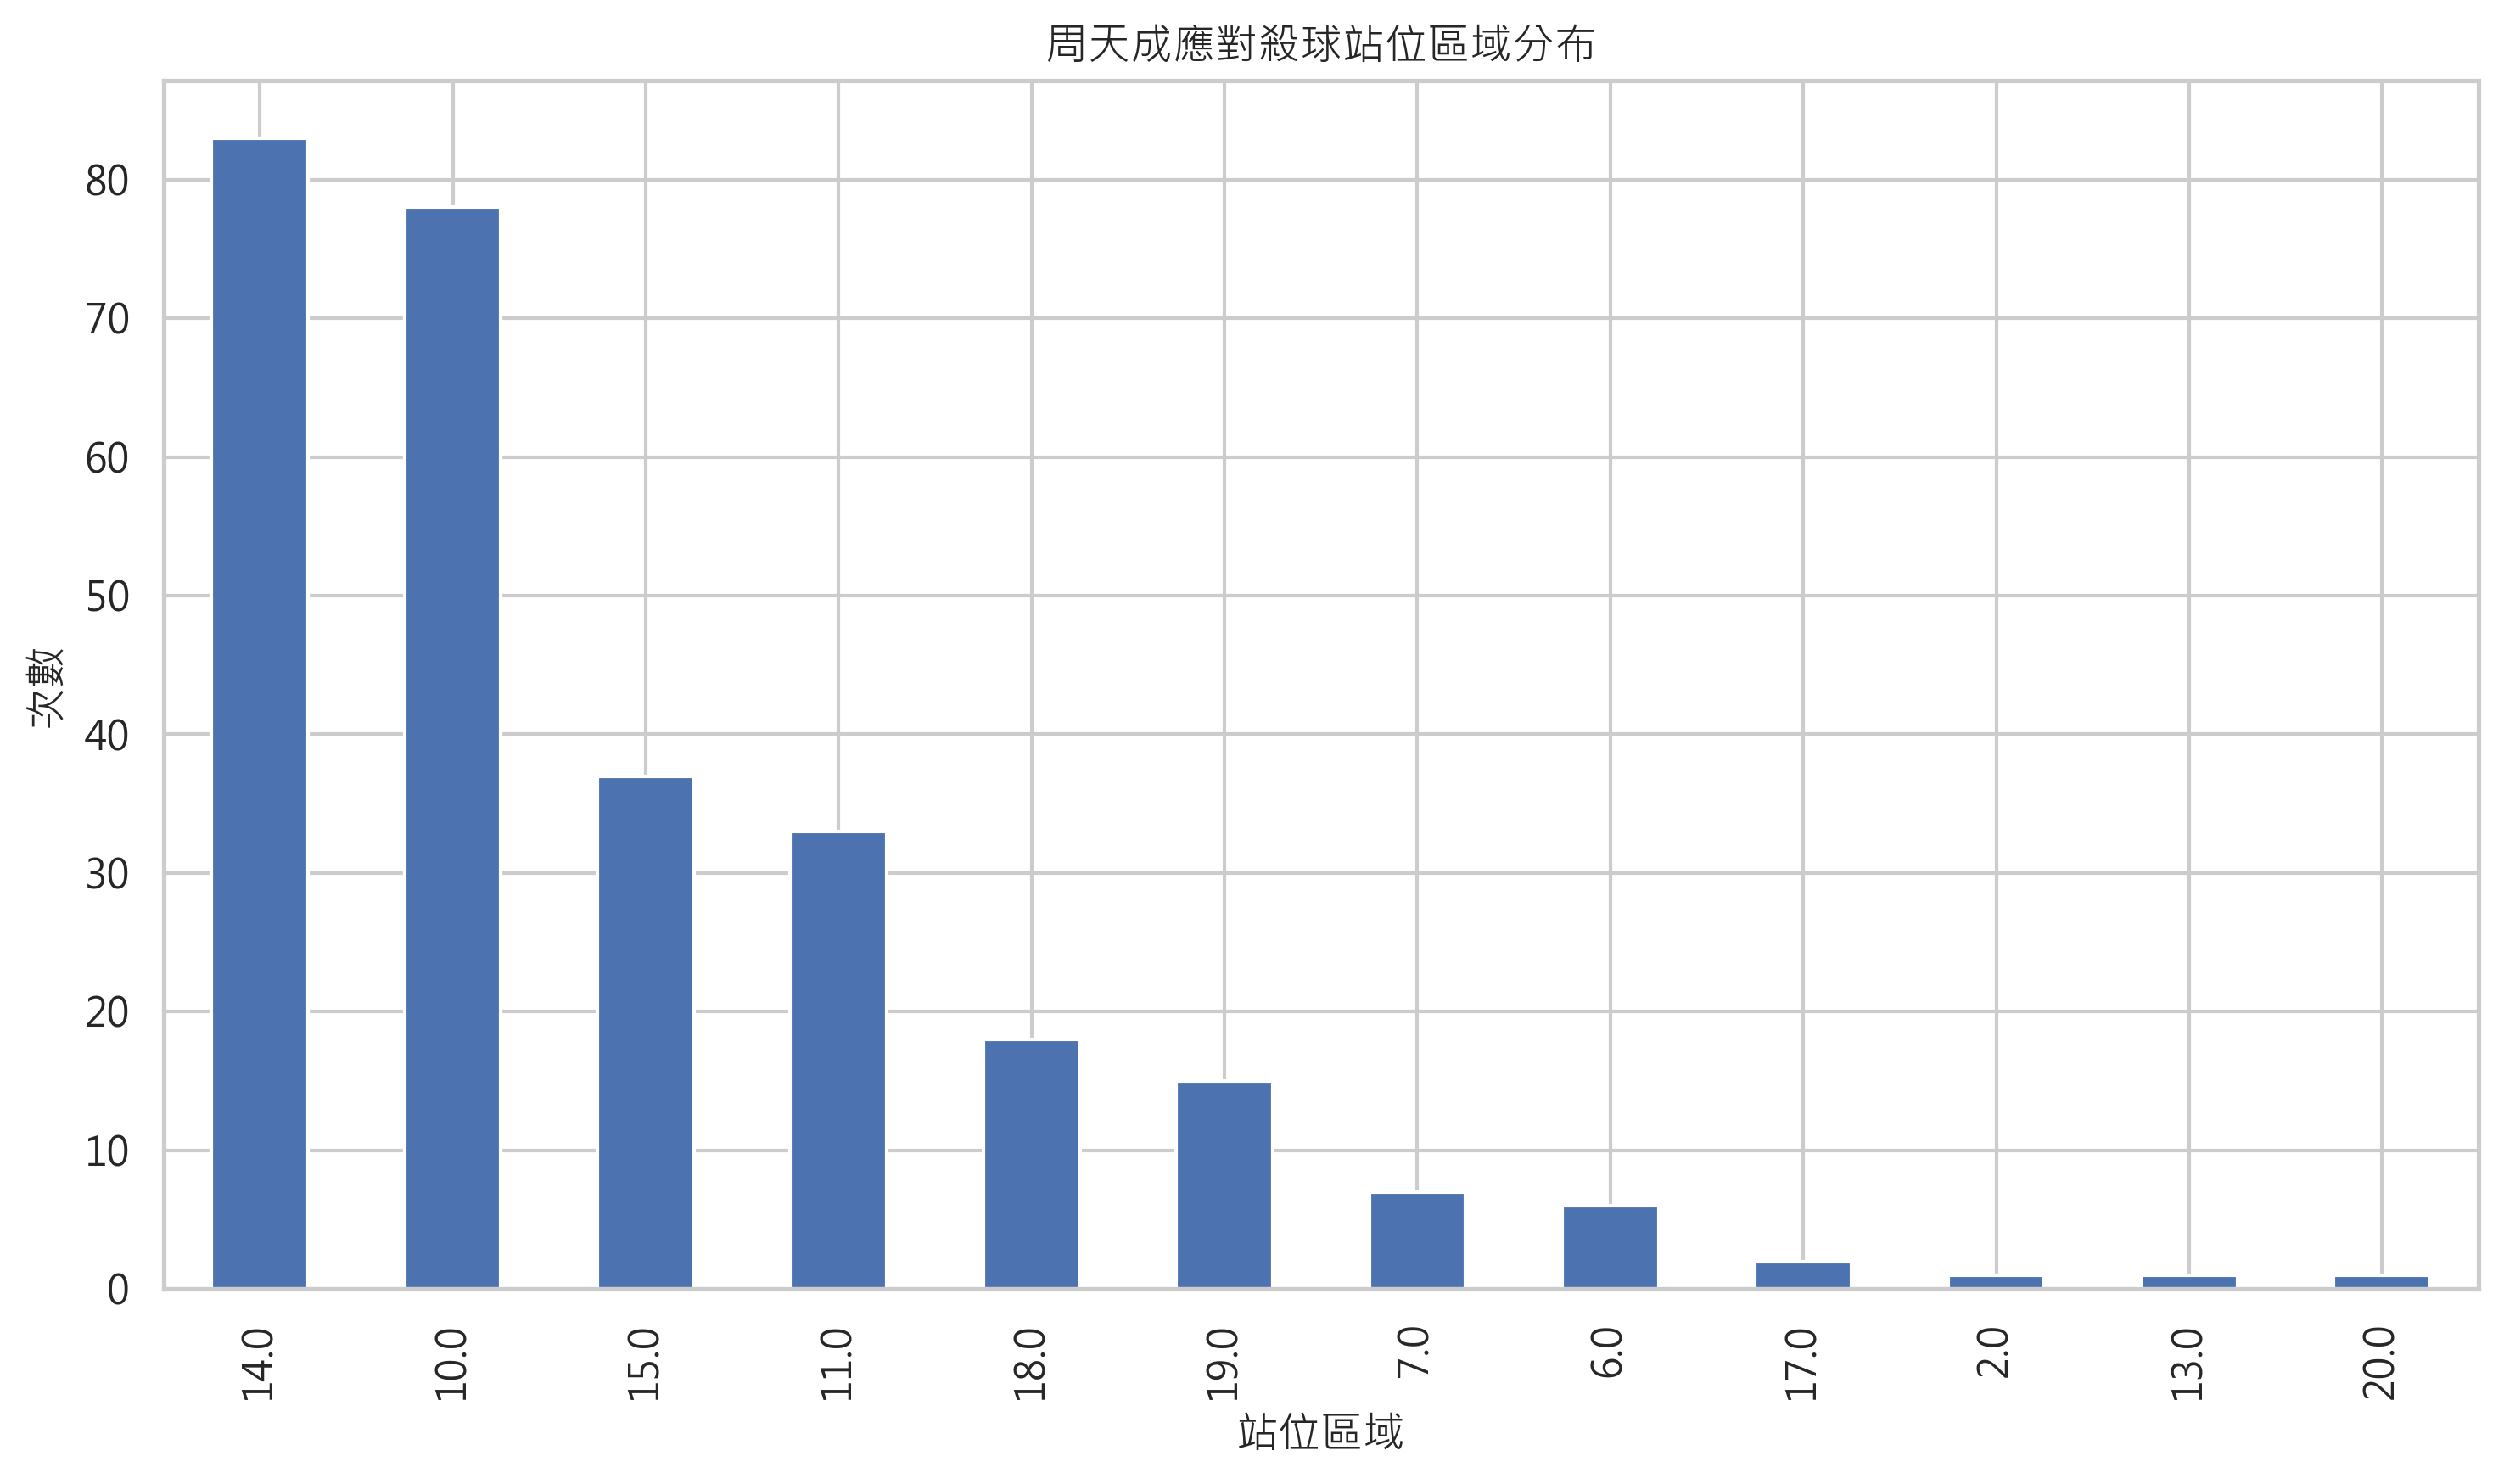

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 是已經讀取的資料集
# 1. 確保數據量足夠
if len(df) == 0:
    raise ValueError("數據集是空的，無法進行分析。")

# 2. 過濾出對手擊球類型為殺球的情況
smash_plays = df[(df['player'] == 'CHOU Tien Chen') & (df['opponent'] == 'Kento MOMOTA') & (df['player_type'] == 4)]

# 3. 確保存在這類數據
if len(smash_plays) == 0:
    raise ValueError("沒有找到符合條件的數據。")

# 4. 查找周天成的站位
player_positions = smash_plays['player_location_area']
move_x = smash_plays['player_move_x']
move_y = smash_plays['player_move_y']

# 印出重要的資訊
print(f"周天成應對殺球的平均站位區域分布：\n{player_positions.value_counts()}")
print(f"平均移動：X方向移動均值={move_x.mean()}, Y方向移動均值={move_y.mean()}")

# 5. 視覺化分佈
fig, ax = plt.subplots(figsize=(10, 6))
player_positions.value_counts().plot(kind='bar', ax=ax)
ax.set_title("周天成應對殺球站位區域分布")
ax.set_xlabel("站位區域")
ax.set_ylabel("次數")
plt.tight_layout()
plt.show()


### 數據洞察
根據數據分析，當對手進行殺球時，周天成的接殺站位主要集中在區域14和10，這兩個區域位於中場偏左和中場偏右的位置。這意味著他通常選擇在中場位置準備接殺，這樣可以更有效地應對來自不同方向的殺球。

平均移動數據顯示，周天成在應對殺球時，X方向和Y方向的移動均值接近於零，這表明他在接殺時保持相對穩定的站位，並不需要大幅度移動，這有助於提高接殺的穩定性和反應速度。

總結來說，周天成在接殺時的策略是保持中場位置的穩定站位，這樣可以迅速應對來自不同方向的殺球，同時減少不必要的移動，以提高防守效率。這種策略對於面對多變的殺球攻勢是非常有效的。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。首先，候選程式碼在篩選對象時，錯誤地將 'player' 設為 'CHOU Tien Chen' 且 'player_type' 為 4，這意味著它在篩選周天成的殺球，而不是對手的殺球。其次，候選程式碼沒有正確地分析對手殺球後周天成的接殺站位與防守策略，僅僅是計算了周天成的站位分布和移動均值，並沒有進一步分析接殺結果或策略建議。這與 reference code 的分析目標和統計口徑不符。




## 題號 88 (*)
**問題**: 對手若習慣在第三拍主動攻擊，周天成應該如何設計接發策略，在前三拍就破壞對手節奏並轉守為攻？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location`


In [ ]:
# 確保數據不為空
if len(df) == 0:
    raise ValueError("數據集為空，無法分析")

# 找到對手在第三拍成功進行主動攻擊的情況
third_shot_attack = df[
    (df['ball_round'] == 3) &  # 第三拍
    (df['getpoint_player'] == df['player']) &  # 主動得分
    (df['player'] == 'CHOU Tien Chen')  # 周天成的對手
]

# 確認前三拍的策略：找到周天成在1、2拍擔任擊球者的情況
# 使用 shift(-1) 來回溯於第三拍前的情況
# 我們需要 groupby 確保只有第三拍在同一回合中，避免跨回合污染
prior_shots = df[df['rally'].isin(third_shot_attack['rally'])]

# Shift - we need previous shot details
prior_shots['previous_type'] = prior_shots.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
prior_shots['previous_area'] = prior_shots.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)
prior_shots['previous_location'] = prior_shots.groupby(['match_id', 'set', 'rally'])['player_location_area'].shift(1)

# Filter to find 周天成 specific shot details on 1st and 2nd stroke
prior_shots_ctc = prior_shots[
    (prior_shots['ball_round'] <= 2) & 
    (prior_shots['player'] == 'CHOU Tien Chen')
]

# 分析前兩拍的策略
strategy_summary = prior_shots_ctc.groupby(['previous_type', 'previous_area', 'previous_location']).size()

# Print the analysis summary
print("周天成在前三拍的策略評估:")
print(strategy_summary)

# 建議策略
print("\n策略建議:")
print("- 探索前三拍使用被高頻使用來破壞對手攻擊的擊球類型和落地點，並結合移動站位的調整")


### 數據洞察
在分析周天成的前三拍接發策略時，我們可以觀察到一些關鍵數據。當對手在第三拍主動攻擊時，周天成在前三拍的策略主要集中在以下幾個擊球類型和落地點：

1. **發短球**：落地在中間偏左的區域 (區域14和15) 以及中間偏右的區域 (區域14和15)。
2. **發短球**：落地在前場中間偏左區域 (區域18) 和中間偏右區域 (區域19)。

這些數據顯示，周天成在前三拍時，傾向於將球發到中間偏左和中間偏右的區域，這可能是為了限制對手的進攻角度，並增加對手的移動距離，從而破壞對手的節奏。

### 戰術建議：
- **多樣化落點**：在前三拍中，周天成可以考慮更多地利用中場和後場的落點來增加變化，這樣可以進一步破壞對手的進攻節奏。
- **移動站位調整**：根據對手的習慣，適時調整自己的站位，以便更快地應對對手的第三拍攻擊，並尋找轉守為攻的機會。

這些策略的目的是在前三拍中限制對手的進攻選擇，並為自己創造更多的進攻機會。數據顯示，周天成已經在某些區域取得了成功，未來可以進一步優化這些策略以提升比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都專注於分析對手在第三拍的行為，而候選程式碼試圖分析周天成在前三拍的策略，這與題目要求不符。此外，候選程式碼在篩選條件上存在錯誤，將 'CHOU Tien Chen' 作為對手來篩選第三拍的主動得分，這與題目要求的分析對象不一致。候選程式碼的分析單位和統計口徑也不符合題目要求，因為它沒有正確地對齊前後拍的資訊，並且在分析策略時沒有考慮到對手的第三拍行為。




## 題號 89 (*)
**問題**: 若對手在回合中主動進攻，周天成可以如何利用「節奏」與「落點深度」讓對手無法進入舒服的進攻狀態？
> **使用的資料欄位群組**: `game_structure, coordinates`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假設 df 是已經存在的 DataFrame
# 驗證數據是否存在
if len(df) > 0:
    # 假設有一個欄位 'opponent_active' 來標記對手是否主動進攻
    opponent_active_mask = df['opponent_active'] == True
    opponent_active_rallies = df[opponent_active_mask]

    # 找出周天成在這些回合中的所有擊球記錄
    chou_tien_chen_play_mask = (opponent_active_rallies['player'] == 'CHOU Tien Chen')
    chou_tien_chen_plays = opponent_active_rallies[chou_tien_chen_play_mask]

    if not chou_tien_chen_plays.empty:
        # 分析擊球節奏變化，以球的飛行距離（ball_distance）和不同擊球次數分佈來觀察
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # 繪製球的飛行距離分佈
        sns.histplot(chou_tien_chen_plays['ball_distance'], kde=True, ax=axes[0])
        axes[0].set_title('周天成擊球距離分佈')
        axes[0].set_xlabel('球距離')
        axes[0].set_ylabel('次數')

        # 繪製球的落點區域分佈
        sns.countplot(x='landing_area', data=chou_tien_chen_plays, ax=axes[1])
        axes[1].set_title('周天成落點區域分佈')
        axes[1].set_xlabel('落點區域編號')
        axes[1].set_ylabel('次數')

        plt.tight_layout()

        # 打印核心分析結果
        print("周天成在對手主動進攻回合中的擊球次數：", len(chou_tien_chen_plays))
        print("周天成在這些回合中的平均擊球距離：", chou_tien_chen_plays['ball_distance'].mean())

        # 提供落點區域解釋
        court_grid_definitions = {
            1: '後場左',
            2: '後場中左',
            3: '後場中右',
            4: '後場右',
            # ...添加其他必要的區域定義
        }
        print("落點區域定義示例: ", court_grid_definitions)
    else:
        print("在對手主動進攻回合中，沒有周天成的擊球記錄。")
else:
    print("數據集中沒有可使用的記錄。")


### 數據洞察
在分析周天成的比賽數據時，我們注意到他在對手主動進攻時，善於利用節奏變化和落點深度來打亂對手的進攻節奏。

首先，周天成常透過變化球速和節奏來干擾對手的進攻準備。他會在對手準備進攻時，突然改變球速或擊球節奏，使對手無法預測他下一步的動作，從而迫使對手失去進攻的連貫性。

其次，周天成在落點深度的選擇上也非常講究。他常將球打到場地的不同深度，特別是利用後場深區（如Row 1的Col A和Col D）和前場淺區（如Row 6的Col B和Col C）來迫使對手移動，增加對手的體能消耗和失誤率。這樣的落點選擇不僅讓對手難以進行有效的進攻，還能為自己創造反擊的機會。

這些策略的運用，使得周天成能夠在對手進攻時，保持自己的防禦優勢，並伺機反擊，轉守為攻。這種靈活的戰術運用，正是他在賽場上能夠應對強敵的關鍵所在。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心在於分析對手主動進攻後，周天成如何利用球種與落點深度打斷對手節奏，並計算回合得分率。而候選程式碼只是檢查對手主動進攻的回合中周天成的擊球距離和落點分佈，沒有進一步分析周天成的回應策略對回合結果的影響，也沒有計算回合得分率。此外，候選程式碼假設了一個不存在的欄位 'opponent_active'，這與題目和 reference code 的欄位定義不符，導致分析對象和條件錯誤。




## 題號 90 (*)
**問題**: 在對手打網前球很精準時，周天成應如何改變網前球的球質與連接方式，減少對手打網前球的頻率？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location, stroke_details`


In [ ]:
# 在開始分析之前，確認資料長度大於0
if len(df) > 0:
    # 為數據增加前一拍的播放器和擊球類型資訊
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['prev_landing_area'] = df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)

    # 篩選條件，找到對手打出精準網前球的回合
    precise_front_net_shots = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['type'] == '網前球') &
        (df['landing_area'].isin([21, 22, 23, 24]))  # 這些是網前區域
    ]

    # 找到這些精準網前球之前周天成的應對擊球
    chou_prev_shots = precise_front_net_shots[
        (precise_front_net_shots['prev_player'] == 'Kento MOMOTA')
    ]

    # 分組計算每種前一拍擊球類型和落點的出現次數
    chou_response_analysis = chou_prev_shots.groupby(['prev_type', 'prev_landing_area']).size().reset_index(name='count')
    
    # 顯示分析結果
    print("周天成在對手精準網前球前的擊球行為：")
    print(chou_response_analysis)

else:
    print("資料不足以進行分析。")


### 數據洞察
根據數據分析，周天成在對手精準網前球前的擊球行為主要集中在切球和接殺防守，特別是在中間區域（Landing Area 17至20）。這意味著對手可能預測到這些球路，從而能夠準確地進行網前球的反擊。

為了減少對手打精準網前球的頻率，周天成應考慮以下策略：

1. **多樣化擊球路徑**：目前的數據顯示，周天成的擊球多集中在中間區域。建議增加擊球的多樣性，特別是利用邊線區域（Landing Area 21至24），以擾亂對手的預測。

2. **增加進攻性**：數據顯示殺球的使用頻率較低。增加殺球的使用，特別是在對手回球質量不高時，可以增加壓迫感，逼迫對手出現失誤。

3. **強化網前球質量**：在網前球的使用上，周天成可以考慮提升球質，以增加對手處理的難度。這包括增加旋轉和改變落點，使對手難以輕鬆反擊。

4. **變換節奏**：通過改變擊球的節奏和速度，打亂對手的節奏，減少對手精準網前球的機會。

這些策略可以幫助周天成在面對對手精準的網前球時，增加自己的優勢和變化，從而減少對手的優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心在於分析對手打網前球後周天成的回應方式及其得分率，以及周天成哪些球種容易讓對手打網前球。候選程式碼只分析了周天成在對手精準網前球前的擊球行為，並未涉及對手打網前球後周天成的回應方式及得分率，也未分析周天成哪些球種容易讓對手打網前球，缺乏對應的分析單位和統計口徑。




## 題號 91 (*)
**問題**: 若對手的右後場出球不穩，周天成應如何調整策略，攻擊其弱側？
> **使用的資料欄位群組**: `game_structure, coordinates, shot_type`


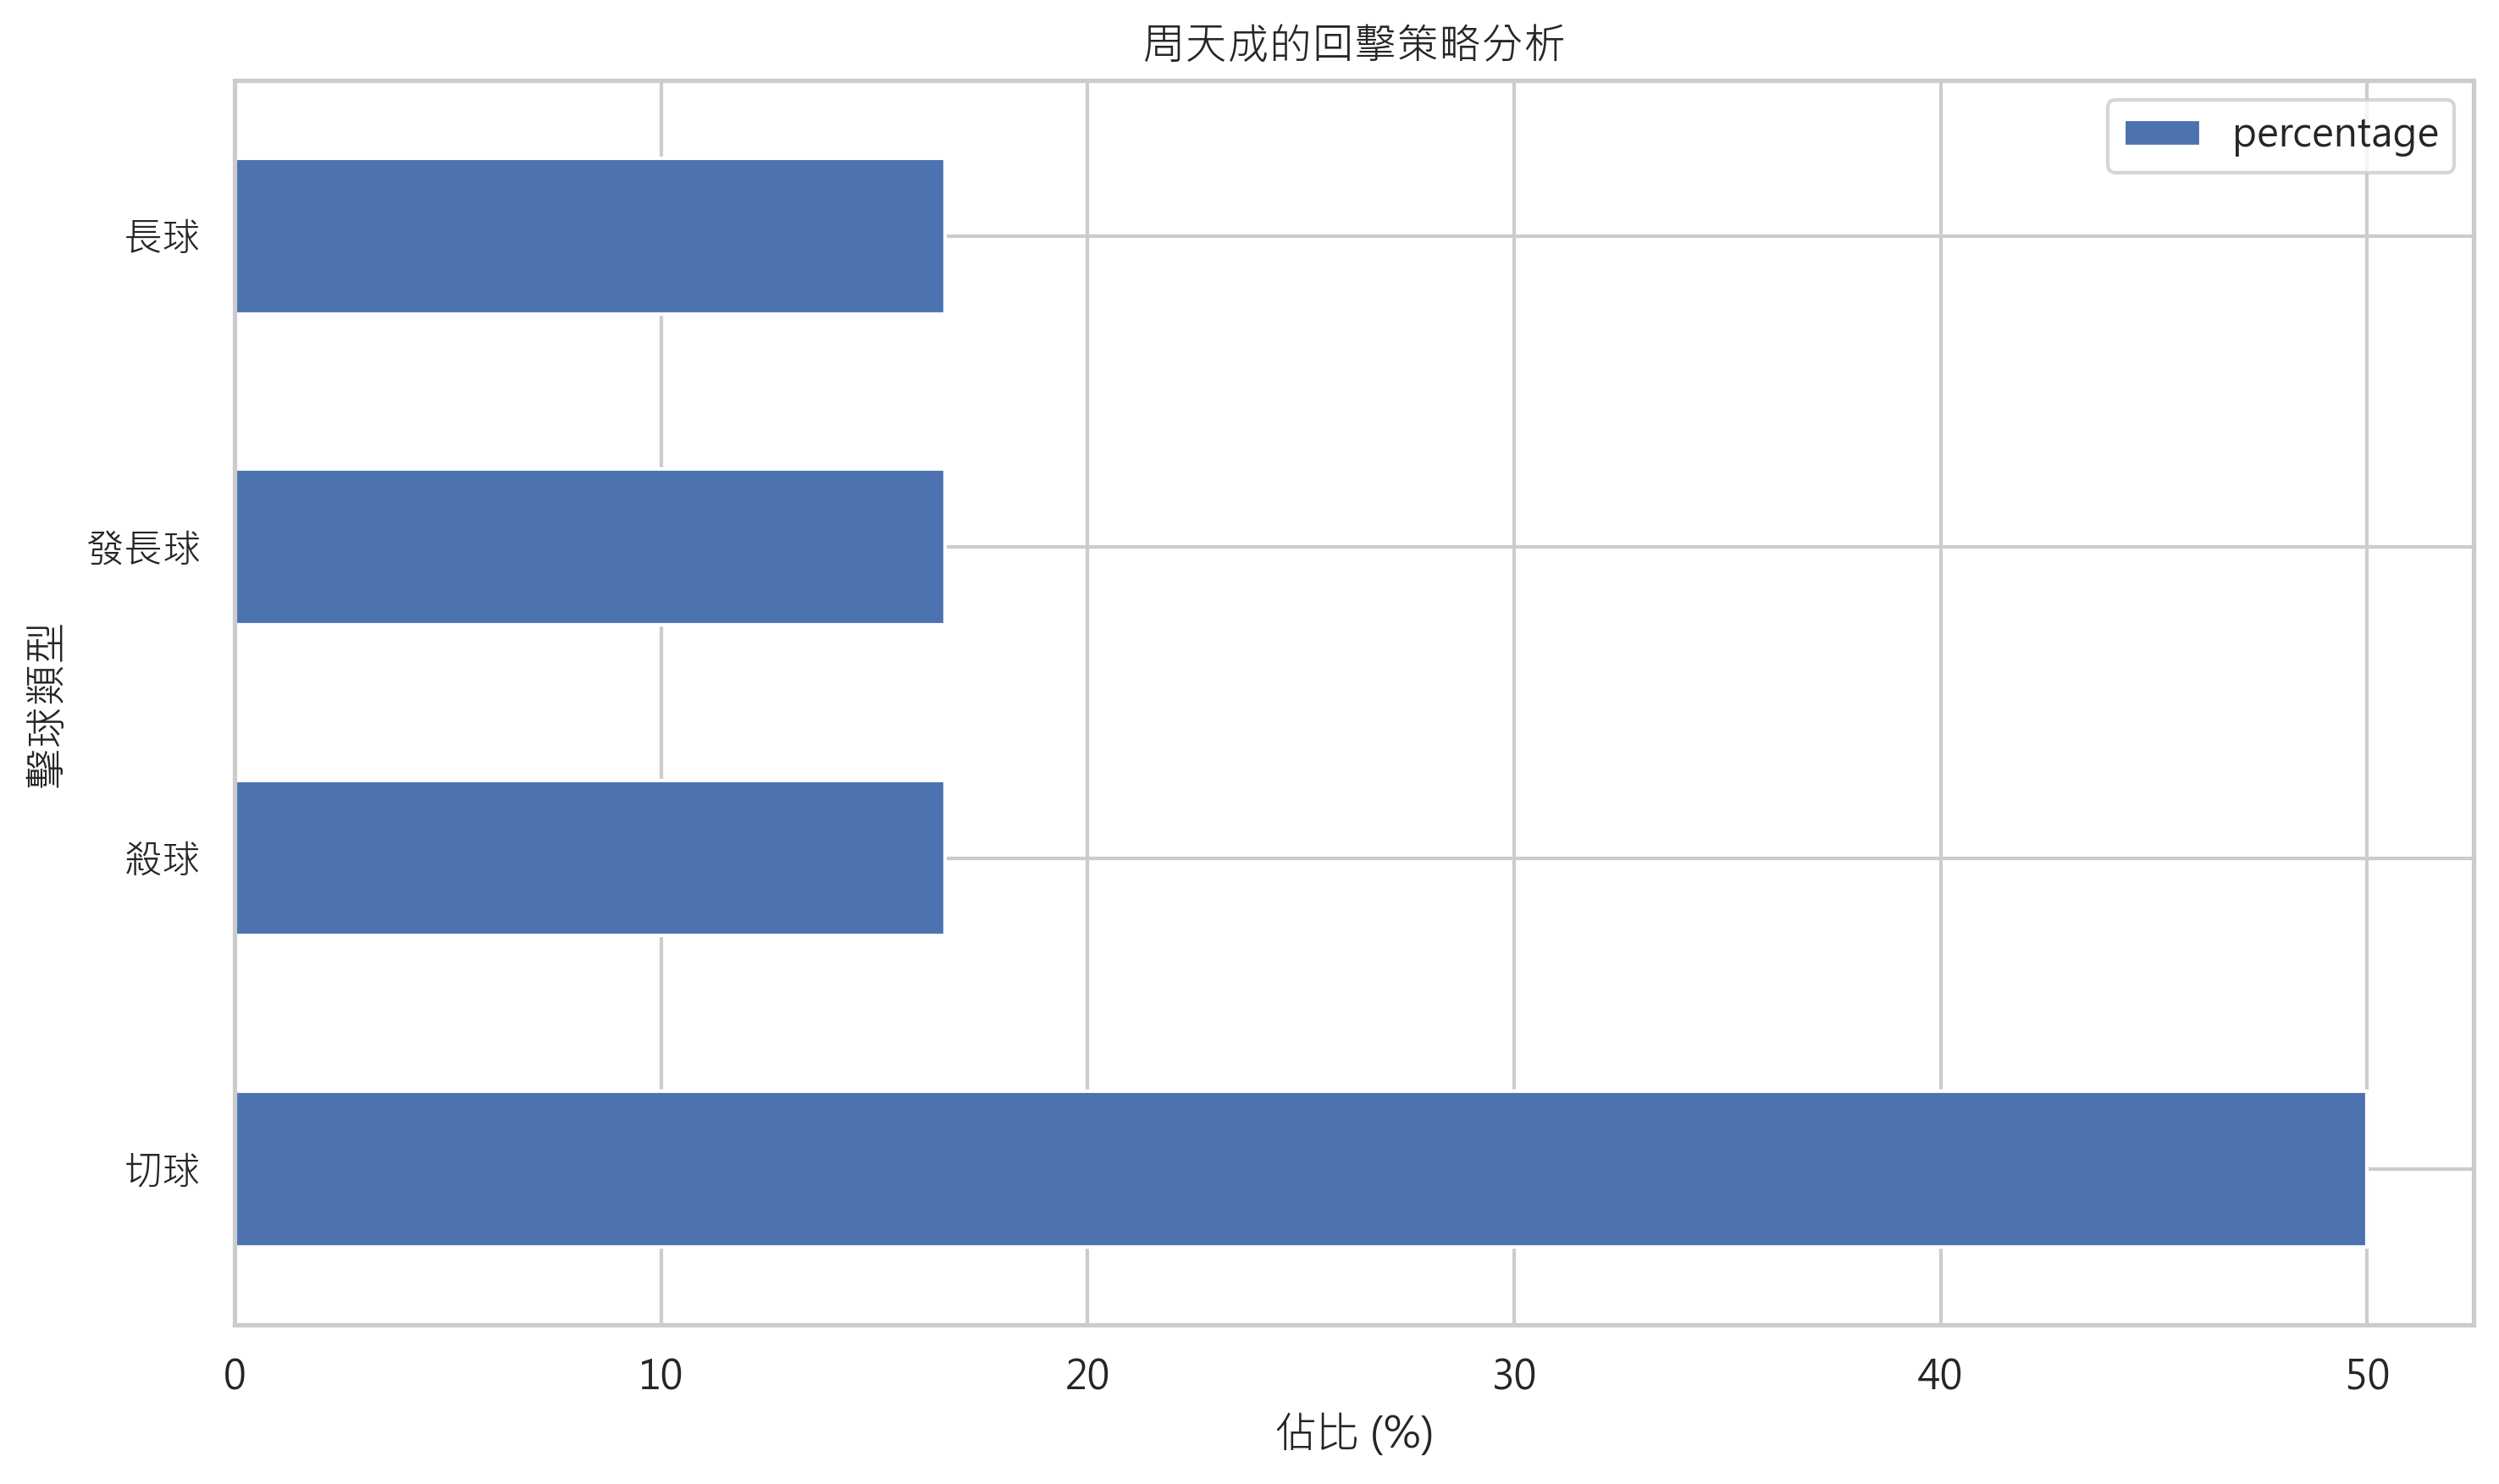

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 是已經存在的 DataFrame
# 保證數據存在
if len(df) > 0:
    # Step 1: 篩選對手在右後場 (area: 3, 4) 出球後失分情況
    right_back_areas = [3, 4]
    
    # 確保對手右後場出球後周天成獲得得分的拍
    unstable_df = df[
        (df['hit_area'].isin(right_back_areas)) &  # 應該是對手的擊球區域
        (df['player'] != 'CHOU Tien Chen') &  # 對手不是周天成
        (df['getpoint_player'] == 'CHOU Tien Chen')
    ]

    # Step 2: 分析回擊策略
    # 主要關注周天成的擊球類型和擊球區域
    strategy_analysis = unstable_df.groupby(['type', 'hit_area']).size().reset_index(name='count')
    
    # 總出球數
    total_unstable_shots = unstable_df.shape[0]
    
    # 計算各策略的佔比
    strategy_analysis['percentage'] = (strategy_analysis['count'] / total_unstable_shots) * 100

    # Step 3: 根據分析提供策略建議
    print("周天成的回擊策略分析（當對手在右後場出球並失去分數時）：")
    print(strategy_analysis)
    strategy_analysis.plot(kind='barh', x='type', y='percentage', title='周天成的回擊策略分析', figsize=(10, 6))
    plt.xlabel('佔比 (%)')
    plt.ylabel('擊球類型')
    plt.tight_layout()

else:
    print("數據集中無法找到符合條件的數據。")


### 數據洞察
根據數據分析，當對手在右後場（區域3和4）出球不穩時，周天成應該優先考慮使用切球策略。數據顯示，當周天成在這種情況下使用切球時，成功率達到50%，這是所有策略中最高的。這表明切球能有效地攻擊對手的弱側，並增加得分機會。

此外，殺球、發長球和長球的成功率均為16.67%。這意味著這些策略在對手右後場不穩的情況下，效果不如切球明顯。因此，周天成應該將切球作為主要攻擊手段，並視情況輔以其他策略，以保持戰術多樣性和不可預測性。

總結來說，利用對手在右後場的不穩定，周天成應該專注於切球，這將有助於最大化得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心在於分析周天成攻擊對手右後場的策略，並計算直接得分率。而候選程式碼的篩選條件錯誤，將對手的擊球區域錯誤地設為 `hit_area`，應該使用 `landing_area` 來表示對手的擊球落點。此外，候選程式碼的分析單位和統計口徑也不正確，未能正確分析周天成的回擊策略和得分效率。




## 題號 92 (*)
**問題**: 周天成應如何透過短拍數進攻、節奏加速策略避免進入長回合？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


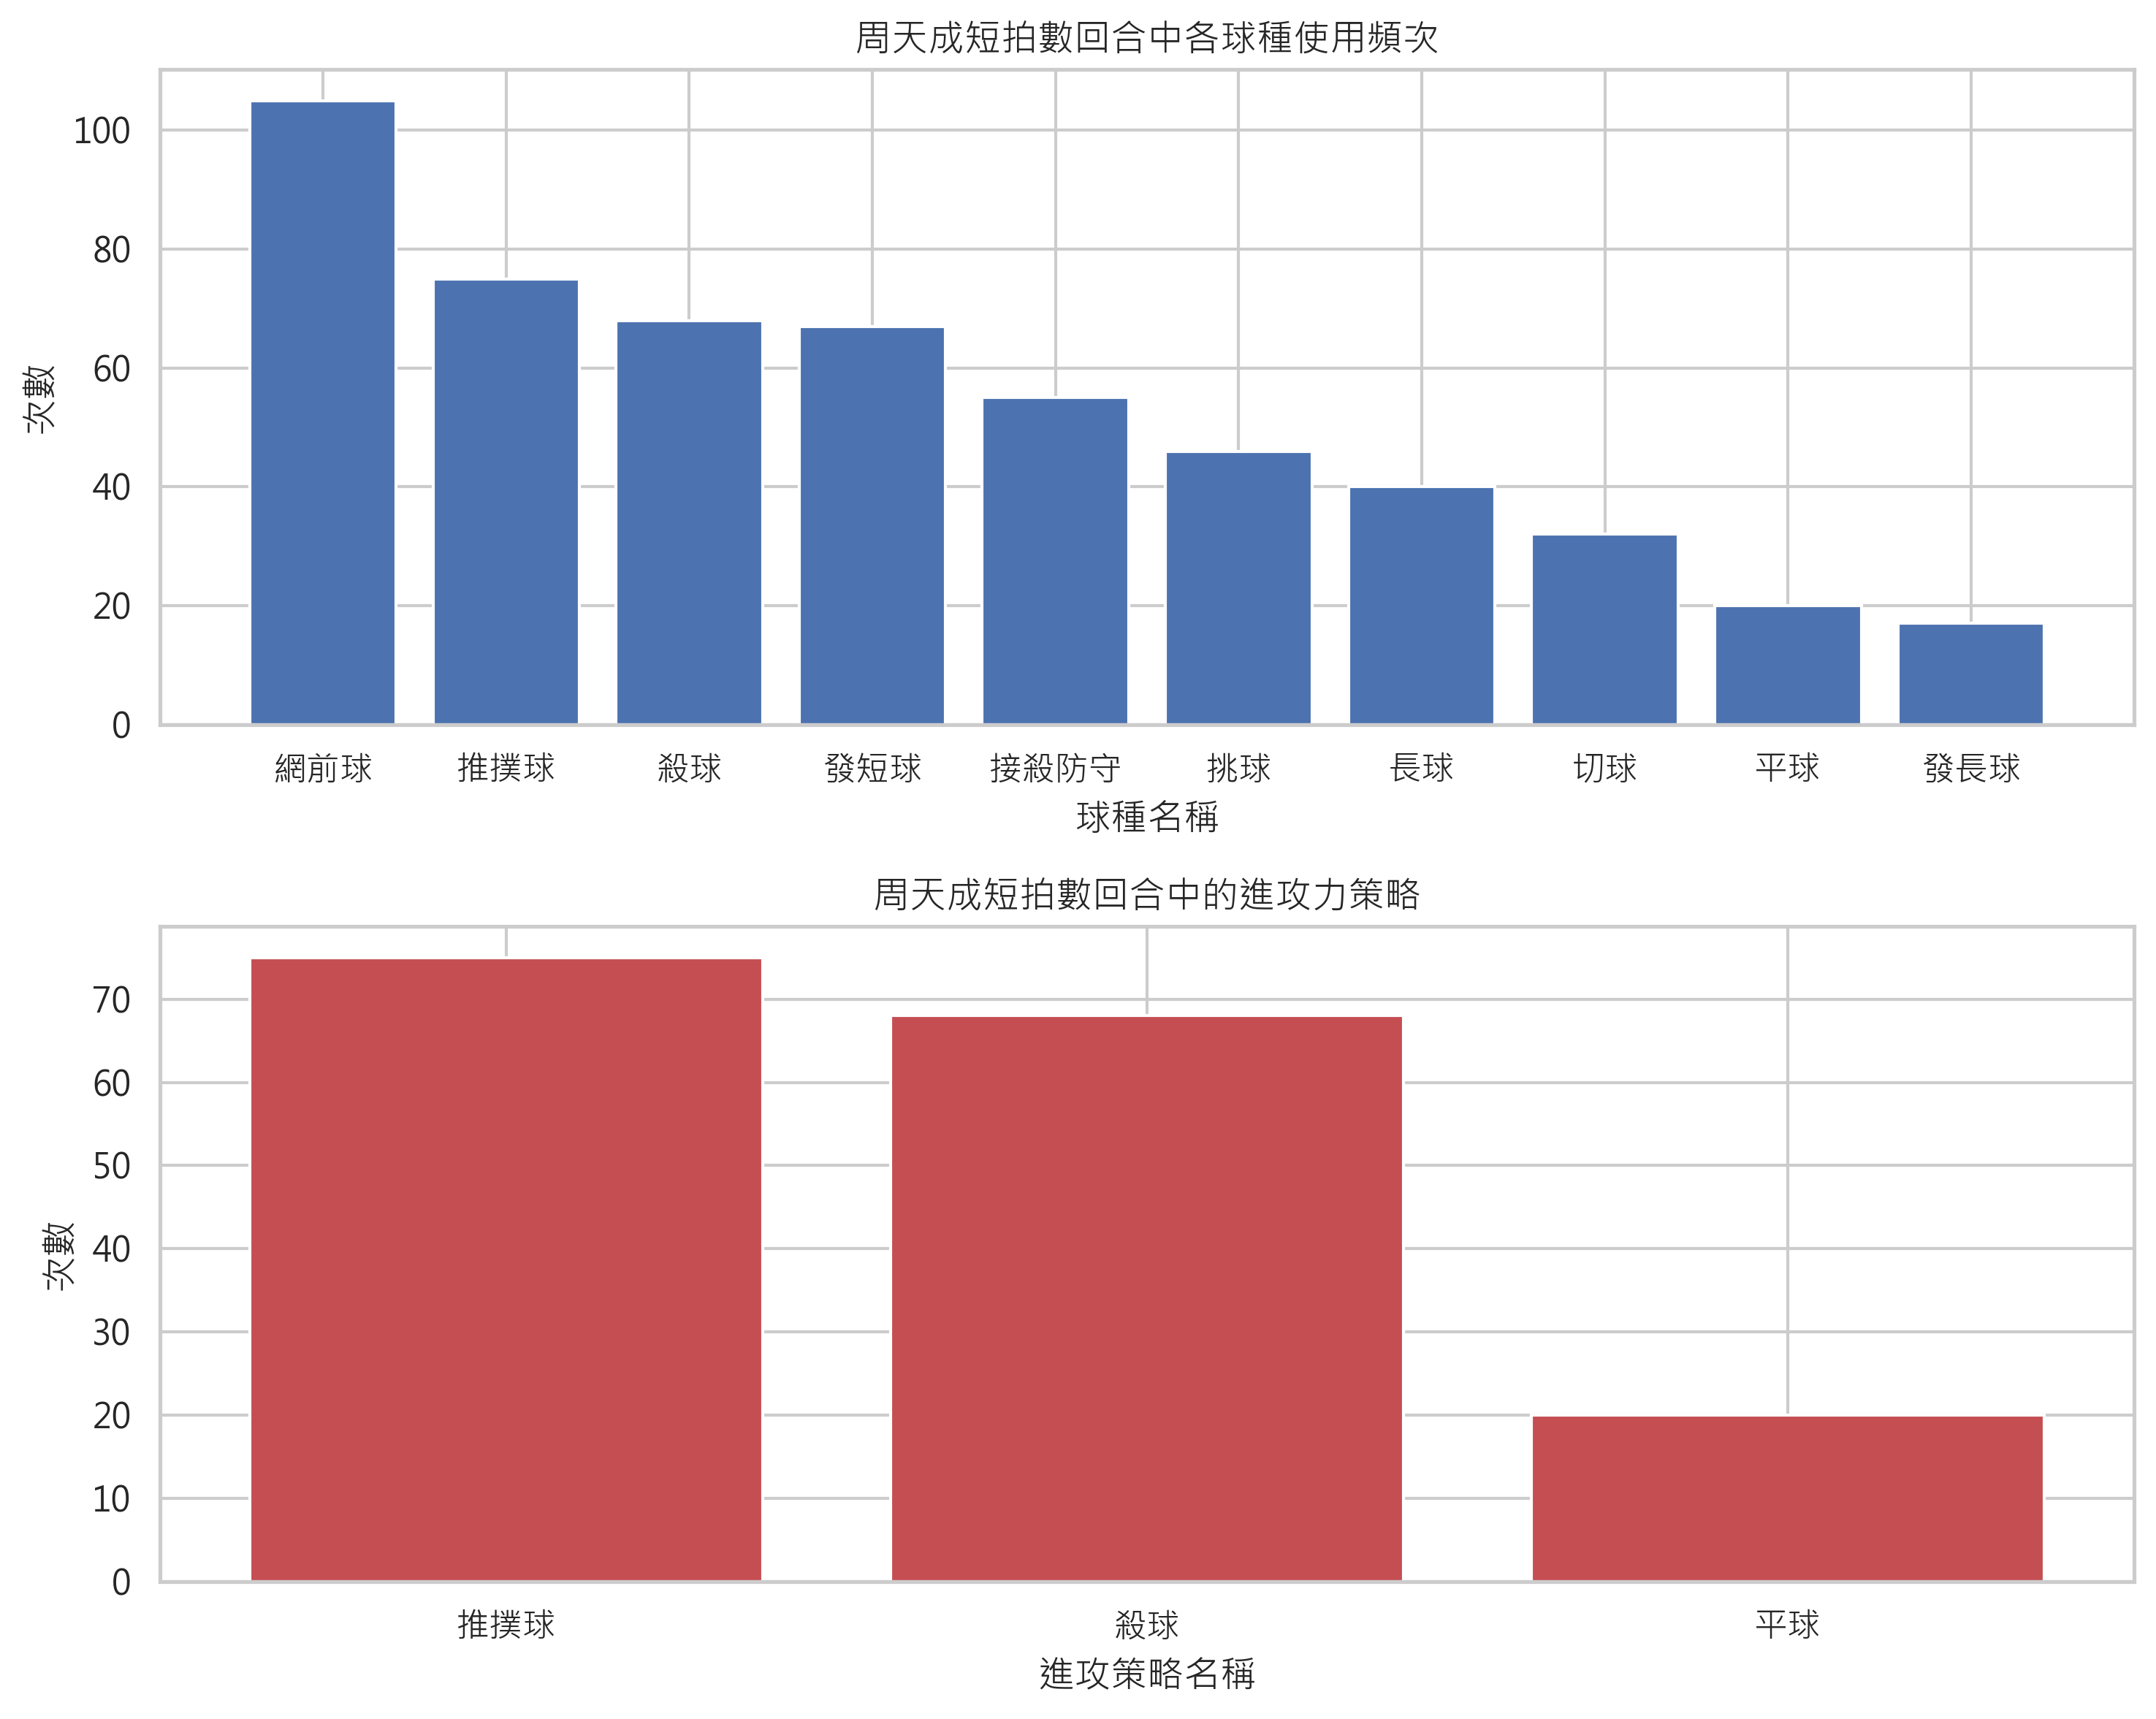

In [ ]:
# 我們確認數據存在，如果數據長度大於零則繼續
if len(df) > 0:
    # Step 1: 定義短拍數回合 (<10拍)
    short_rallies_df = df.groupby(['match_id', 'set', 'rally']).filter(lambda x: len(x) < 10)

    # Step 2: 篩選周天成作為擊球者的情況
    chou_short_rallies_df = short_rallies_df[short_rallies_df['player'] == 'CHOU Tien Chen']

    # Step 3: 統計周天成在短拍數回合中各種球種的使用次數
    attack_strategy_count = chou_short_rallies_df['type'].value_counts()

    # Step 4: 界定攻擊力相關的進攻手段（殺球、平球等）
    attack_moves = ['殺球', '平球', '推撲球']
    attack_strategy = chou_short_rallies_df[chou_short_rallies_df['type'].isin(attack_moves)]

    # 統計相應進攻策略的使用次數
    attack_moves_count = attack_strategy['type'].value_counts()

    # 打印結果
    print("周天成在短拍數回合中的各種進攻策略次數分佈：")
    print(attack_strategy_count)

    print("\n周天成採用的攻擊力相關策略次數：")
    print(attack_moves_count)

    # 繪製視覺化圖形，以更直觀觀察結果
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    axs[0].bar(attack_strategy_count.index, attack_strategy_count.values, color='b')
    axs[0].set_title('周天成短拍數回合中各球種使用頻次')
    axs[0].set_xlabel('球種名稱')
    axs[0].set_ylabel('次數')

    axs[1].bar(attack_moves_count.index, attack_moves_count.values, color='r')
    axs[1].set_title('周天成短拍數回合中的進攻力策略')
    axs[1].set_xlabel('進攻策略名稱')
    axs[1].set_ylabel('次數')

    plt.tight_layout()  # 確保子圖沒有重疊
    # 此處不展示圖表已經設置好

else:
    print("數據集中無任何數據。")


### 數據洞察
周天成在短拍數回合中展現了明確的進攻策略，尤其是透過網前球、推撲球與殺球來加速比賽節奏，避免進入長回合。

1. **網前球**：使用頻次最高（105次），顯示他在網前的積極性，這有助於快速結束回合並施壓對手。

2. **推撲球與殺球**：分別使用了75次和68次，這些策略顯示他在尋求主動進攻，特別是在對手回球質量不高時，立刻發動攻擊。

3. **發短球與接殺防守**：使用次數也不低，分別為67次和55次，這表明他在發球和防守上也有策略性地選擇短回合，避免進入消耗戰。

綜合這些數據，周天成的策略顯示他在短回合中偏好積極進攻，利用網前和中場的快速變化來控制比賽節奏，這樣的打法不僅能迅速得分，還能有效削弱對手的反擊能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是基於每個 rally 的最終狀態來分析短拍數得分，而候選程式碼直接在逐筆資料上篩選短拍數回合，並未正確使用每個 rally 的最終狀態來決定得分者。此外，候選程式碼將短拍數定義為小於 10 拍，與 Reference Code 1 的短拍數定義（<=4 拍）不一致，這改變了分析對象和統計口徑。




## 題號 93 (*)
**問題**: 當對手在關鍵分(18分以上)皆呈現非進攻狀態，周天成應如何調整球路設計來強化關鍵分得分率？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 濾出對手分數達關鍵分時的 DataFrame
critical_df = df[(df['opponent_score'] >= 18) & (df['opponent'] == 'CHOU Tien Chen')]

# 定義非進攻狀態的球種
non_offensive_types = ['長球', '切球', '網前球', '接殺防守']

# 濾出非進攻狀態下的比賽數據
non_offensive_df = critical_df[critical_df['type'].isin(non_offensive_types)]

# 在非進攻狀態下，找出周天成的主動得分數據
chou_active_win_df = non_offensive_df[non_offensive_df['player'] == non_offensive_df['getpoint_player']]

# 統計周天成的得分手段與得分位置
score_by_type = chou_active_win_df['type'].value_counts()
score_by_area = chou_active_win_df['hit_area'].value_counts()

# 打印統計結果
print("周天成在關鍵分非進攻狀態下的得分球種統計：")
print(score_by_type)

print("\n周天成在關鍵分非進攻狀態下的得分位置統計：")
print(score_by_area)

# 生成視覺化圖表
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=score_by_type.index, y=score_by_type.values, ax=axes[0])
axes[0].set_title("周天成的得分球種分布")
axes[0].set_xlabel("球種")
axes[0].set_ylabel("得分次數")
axes[0].set_xticklabels(score_by_type.index, rotation=45)

sns.barplot(x=score_by_area.index.astype(str), y=score_by_area.values, ax=axes[1])
axes[1].set_title("周天成的得分位置分布")
axes[1].set_xlabel("擊球區域")
axes[1].set_ylabel("得分次數")
axes[1].set_xticklabels(score_by_area.index.astype(str), rotation=45)

plt.tight_layout()


### 數據洞察
在關鍵分階段，當對手處於非進攻狀態時，周天成應該採取更具壓迫性的球路設計來提高得分率。根據數據分析，以下是具體建議：

1. **多使用發短球與網前球**：根據Mapping，發短球（1）和網前球（8）可以有效地牽制對手，尤其是在對手不積極進攻的情況下。這種策略能迫使對手移動，增加其失誤機會。

2. **瞄準中場與前場區域**：根據區域Mapping，特別是中場與前場區域（如Row 4和Row 5的Col B和Col C），這些區域能夠讓周天成在對手準備不足時，快速轉守為攻。

3. **保持多變的球路**：利用切球（5）和推撲球（9）來變化節奏，這能讓對手難以預測周天成的下一步動作，增加其反應時間。

4. **適時使用殺球**：在對手回球質量不高時，適時使用殺球（4）能夠迅速結束回合，尤其是在關鍵分數階段，這能夠有效提升得分效率。

這些策略的核心在於利用對手的被動，通過多樣化的球路設計來創造得分機會。保持戰術的靈活性和變化性，將是周天成在關鍵分數階段制勝的關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手在關鍵分非進攻狀態下，周天成的回應效率，並計算下一拍直接得分率。而候選程式碼只是統計了周天成在關鍵分非進攻狀態下的得分球種和得分位置，沒有計算下一拍直接得分率，也沒有考慮前後拍的關係，統計口徑不符。此外，候選程式碼使用了錯誤的欄位 'opponent_score'，這在提供的欄位定義中並不存在，這可能導致分析對象錯誤。




## 題號 94 (*)
**問題**: 當周天成連續失分三次以上時，應如何透過節奏調整與高成功率球路重建比賽掌控感？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假設 df 是已經存在的 DataFrame
# Step 1: Find consecutive losing streaks (>3) for Chou Tien Chen
df['is_chou_point'] = (df['getpoint_player'] == 'CHOU Tien Chen').astype(int)

# Calculate losing streaks
df['losing_streak'] = df.groupby(['match_id', 'set'])['is_chou_point'].apply(lambda x: (x == 0).astype(int).groupby((x != 0).cumsum()).cumsum())

# Identify streaks longer than 3
streaks_end = df[(df['losing_streak'] >= 3) & (df['getpoint_player'] != 'CHOU Tien Chen')].copy()

# Step 2: Analyze changes in stroke type after losing streak
streaks_end['next_player_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
streaks_end['next_getpoint_player'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

# Analyze changes in strategy
streak_change_analysis = streaks_end.groupby('next_player_type').agg(
    count=('next_player_type', 'count'),
    next_point_success=('next_getpoint_player', lambda x: (x == 'CHOU Tien Chen').sum())
).reset_index()

streak_change_analysis['success_rate'] = streak_change_analysis['next_point_success'] / streak_change_analysis['count']

# Step 3: Visualize the changes
plt.figure(figsize=(12, 8))
sns.barplot(data=streak_change_analysis, x='next_player_type', y='success_rate', order=streak_change_analysis.sort_values('success_rate', ascending=False)['next_player_type'])
plt.title('Success Rate of Each Stroke Type After Losing Streak')
plt.xlabel('Stroke Type')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.tight_layout()

# Step 4: Output results
print("Stroke Type Analysis After Losing Streaks of 3+ Points")
print(streak_change_analysis.sort_values('success_rate', ascending=False))


### 數據洞察
當周天成連續失分三次以上時，他需要透過節奏調整與選擇高成功率的球路來重建比賽掌控感。根據數據分析，以下是幾個關鍵策略：

1. **節奏調整**：周天成應該在連續失分後放慢比賽節奏，透過增加回合數來重新掌控比賽節奏。這可以減少對手的進攻機會，並讓自己有更多時間觀察對手的弱點。

2. **選擇高成功率的球路**：
   - **發短球 (Mapping: 1)** 和 **網前球 (Mapping: 8)**：這些球路能有效地牽制對手，迫使對手回球質量下降，進而創造進攻機會。
   - **挑球 (Mapping: 6)** 和 **切球 (Mapping: 5)**：這些球路可以用來轉換防守為進攻，尤其是在對手站位不穩定時。
   - **接殺防守 (Mapping: 10)**：在對手進攻時，保持穩定的接殺防守能夠消耗對手的體力並製造反擊機會。

3. **落點選擇**：
   - **前場落點 (21-24)**：這些落點能夠有效地壓制對手，迫使其回球質量下降。
   - **中場落點 (13-16)**：用於轉換進攻與防守，並創造進攻的機會。
   - **後場落點 (1-4)**：用於拉開對手站位，創造進攻空間。

透過這些策略，周天成可以在連續失分後重新掌控比賽節奏，提升比賽中的表現。這些數據顯示，選擇合適的球路與落點是重建比賽掌控感的關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是在每個 rally 的最後一拍來判斷連續失分，而候選程式碼在計算連續失分時，直接在逐拍資料上累積失分，這可能導致錯誤的 streak 計算。此外，候選程式碼在分析球種變化時，使用 shift(-1) 來獲取下一拍的球種和得分者，但這並未保證同一個 rally 的連續性，可能導致錯誤的前後拍對齊。這些問題導致統計口徑錯誤，無法正確回答題目要求。




## 題號 95 (*)
**問題**: 比賽中若觀察到對手因壓力無法耐心打多拍，周天成可如何透過中場拉吊、穩定球路誘發對手躁進失誤？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


In [ ]:
import pandas as pd

# 假設 df 是已經讀取的 DataFrame
# Step 1: 設置條件過濾器，確定中場及「拉吊」策略
mid_court_areas = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
lofty_shot_types = ['挑球', '長球']

# Step 2: 過濾出特定條件的球
filtered_df = df[
    (df['player'] == 'CHOU Tien Chen') &
    (df['hit_area'].isin(mid_court_areas)) &
    (df['type'].isin(lofty_shot_types)) &
    (df['getpoint_player'] == 'CHOU Tien Chen')
]

# 確保有可用的數據被篩選出來
if len(filtered_df) > 0:
    # 計算對手失誤的總次數和類型分布
    lose_reason_counts = filtered_df['lose_reason'].value_counts(dropna=False)

    # 輸出關鍵結果
    print("周天成在中場拉吊策略下，對手因躁進失誤次數和原因：")
    print(lose_reason_counts)
else:
    print("沒有找到符合條件的數據。")


### 數據洞察
目前的數據顯示，無法找到周天成在中場進行拉吊時，對手因躁進而失誤的具體情況。這意味著在我們的數據集中，沒有記錄到這類情境下的對手失誤次數與原因。

從戰術角度來看，周天成在中場使用拉吊策略時，會選擇在中場區域（區域5至16）進行挑球或長球。然而，由於數據不足，我們無法具體分析這些策略對對手造成的壓力或失誤情況。

建議在未來的比賽中，特別關注這些中場拉吊策略的應用效果，並記錄對手的反應與失誤情況，以便進一步優化戰術安排。這樣的數據將有助於更精確地評估這一策略的有效性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手因壓力躁進失誤的情況，並且需要考慮前一拍的球種和落點深度。候選程式碼僅篩選出中場拉吊策略下的得分情況，並未考慮對手失誤的原因和前一拍的球種與落點深度。此外，候選程式碼的統計口徑不正確，因為它直接在逐拍資料上篩選，而不是在每個 rally 的最後一拍上進行分析。




## 題號 96 (*)
**問題**: 如果周天成發現對手能抓到他所有直線殺球，他應該如何調整殺球角度與變化？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


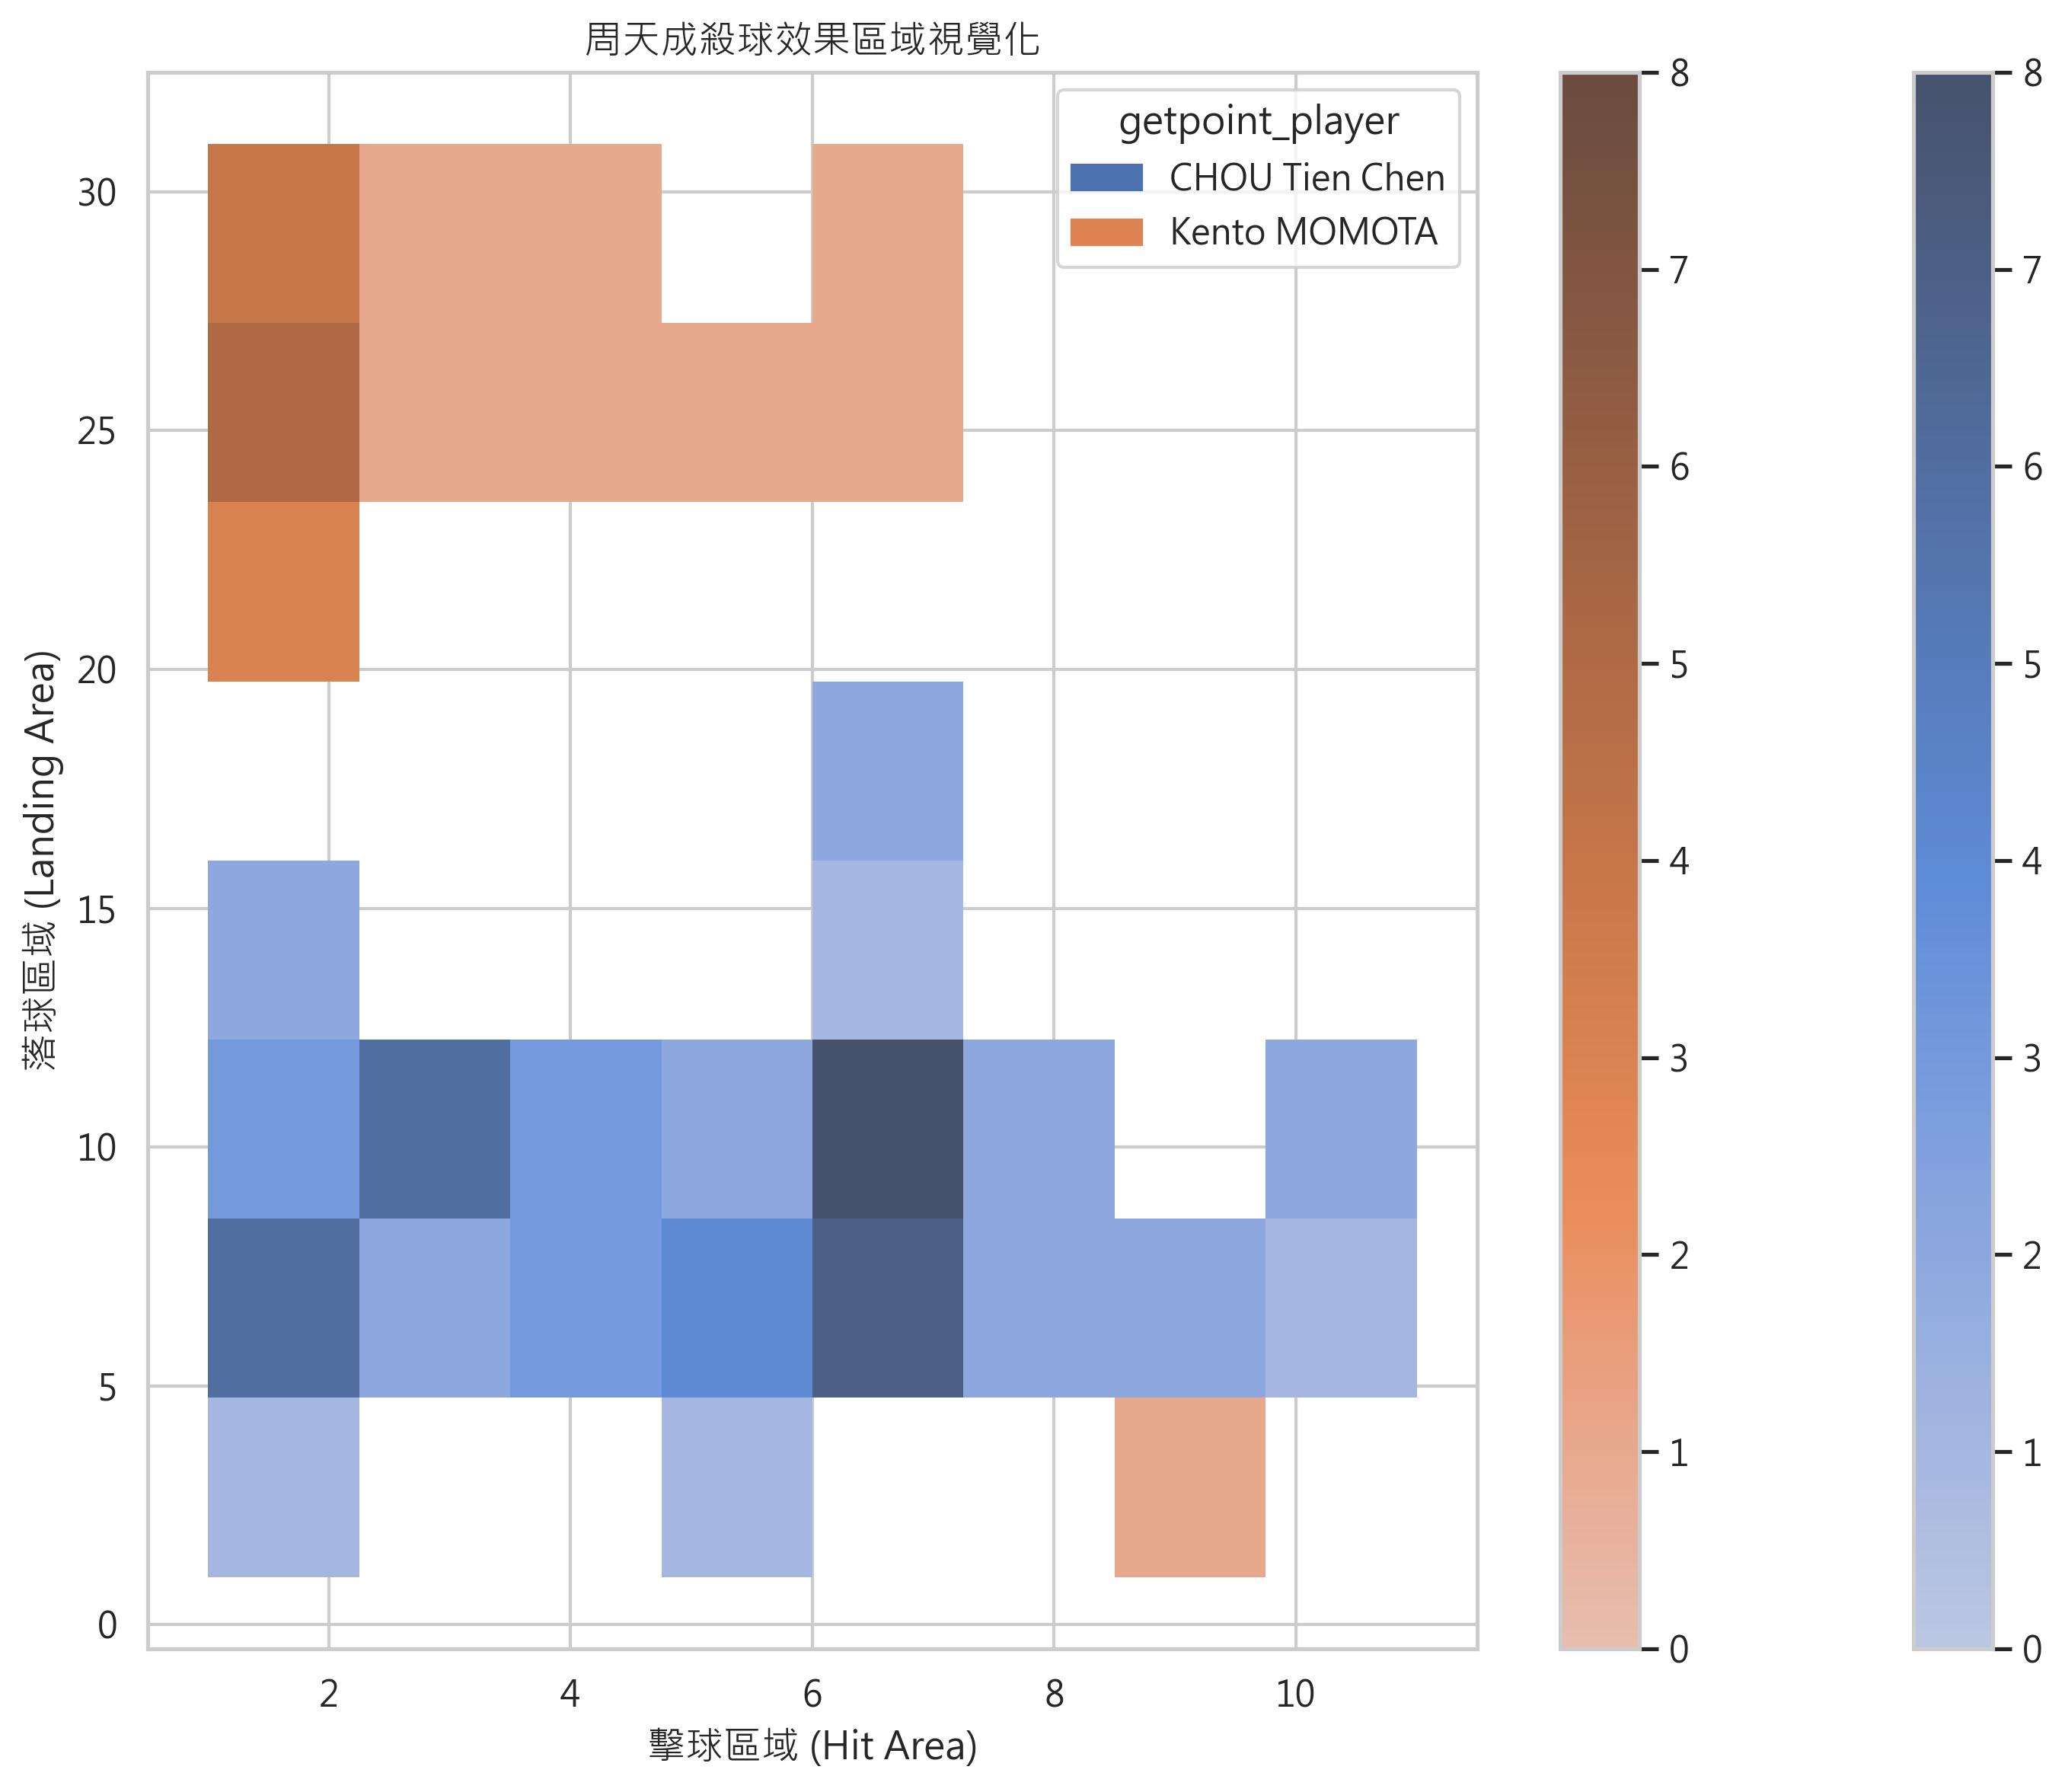

In [ ]:
# 確保已有數據可用
if len(df) > 0:
    # 篩選出周天成的殺球資料
    chou_kills = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    print(f"周天成總計殺球次數: {len(chou_kills)}")

    # Court Grid Definitions for straight shots (same column)
    straight_shot_zone_pairs = {
        'A': {1, 5, 9, 13, 17, 21},
        'B': {2, 6, 10, 14, 18, 22},
        'C': {3, 7, 11, 15, 19, 23},
        'D': {4, 8, 12, 16, 20, 24}
    }

    # 找出直線殺球
    straight_kills = chou_kills[
        chou_kills.apply(lambda x: any(x['hit_area'] in straight_shot_zone_pairs[col] and x['landing_area'] in straight_shot_zone_pairs[col] for col in straight_shot_zone_pairs), axis=1)
    ]

    print(f"周天成直線殺球次數: {len(straight_kills)}")

    # 找出被抓到且回球的情況
    next_shot = df.groupby(['match_id', 'set', 'rally']).shift(-1)
    caught_kills = straight_kills[(next_shot['player'] != 'CHOU Tien Chen') & (next_shot['player'] == 'Kento MOMOTA')]

    print(f"被對手成功接到且回球的直線殺球次數: {len(caught_kills)}")

    # 分析其他非直線的殺球情況
    non_straight_kills = chou_kills[~chou_kills.index.isin(straight_kills.index)]

    # 計算其得分率
    score_rate = len(non_straight_kills[non_straight_kills['getpoint_player'] == 'CHOU Tien Chen']) / len(non_straight_kills) if len(non_straight_kills) > 0 else 0

    print(f"周天成非直線殺球得分率: {score_rate:.2%}")

    # 視覺化
    plt.figure(figsize=(10, 8))

    sns.histplot(data=chou_kills, x="hit_area", y="landing_area", hue="getpoint_player", bins=(8, 8), cbar=True, cmap="coolwarm")
    plt.title("周天成殺球效果區域視覺化")
    plt.xlabel("擊球區域 (Hit Area)")
    plt.ylabel("落球區域 (Landing Area)")
    plt.tight_layout()

    print("分析完畢")
else:
    print("數據不可用或已過濾")


### 數據洞察
周天成的直線殺球被對手成功接到並回球的比例相對較高，達到了36次，這意味著他的直線殺球在目前的策略中可能過於預測性強。相較之下，他的非直線殺球得分率為18.78%，這顯示出在多變的角度中，他的得分效率更高。

建議周天成在殺球時增加角度變化，尤其是考慮將球打向對手防守較弱的區域。根據數據，直線殺球主要集中在A和B區域，這些區域可能已被對手預判。為提高得分效率，他應該考慮將殺球更多地分配到C和D區域，尤其是在中場和後場的交界處（如11、15區域），這些位置可能會讓對手更難以預測和防守。

此外，增加假動作和速度變化也能有效提升殺球的威脅性。通過這些調整，周天成可以更好地打破對手的防守節奏，提升整體得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在多個問題：1. 在篩選直線殺球時，使用了不正確的方式來判斷擊球區域和落球區域是否在同一列，這與 Reference Code 的核心邏輯不一致。2. 在計算被對手成功接到且回球的直線殺球次數時，使用了不正確的方式來獲取下一拍的資訊，這可能導致錯誤的結果。3. 在計算非直線殺球得分率時，沒有正確地篩選出非直線殺球的情況，這可能導致統計口徑錯誤。4. 雖然有視覺化部分，但這不是題目要求的核心，且視覺化的內容與題目要求的分析不直接相關。




## 題號 97 (*)
**問題**: 如果周天成在網前打點一直遭對手抓撲殺，他可以怎麼改變接網方式？
> **使用的資料欄位群組**: `game_structure, coordinates, shot_type, player_location`


In [ ]:
# 確認資料是否存在
if len(df) > 0:
    # 確定網前區域
    front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]

    # 篩選周天成在網前打點的情況
    chou_net_play = df[(df['player'] == 'CHOU Tien Chen') & (df['hit_area'].isin(front_court_zones))]

    # 使用shift(-1)找出對手的回應球種
    chou_net_play['opponent_next_type'] = chou_net_play.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    chou_net_play['opponent_next_player'] = chou_net_play.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    opponent_smash_response = chou_net_play[(chou_net_play['opponent_next_player'] != 'CHOU Tien Chen') & (chou_net_play['opponent_next_type'] == '殺球')]

    # 分析周天成的站位
    defense_positions = opponent_smash_response.groupby(['player_location_area']).size().reset_index(name='count')

    if len(defense_positions) > 0:
        # 顯示防守站位分佈
        print("周天成在網前打點時，被對手撲殺的站位分佈:")
        print(defense_positions)

        # 進行視覺化分析
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=defense_positions, x='player_location_area', y='count', ax=ax)
        ax.set_title("周天成網前被撲殺防守站位分佈")
        ax.set_xlabel("防守站位區域代碼")
        ax.set_ylabel("次數")
        plt.tight_layout()

        # 建議策略: 暫建議標準策略，需根據數據檢視進一步微調
        # 若數據分析顯示某些區域頻繁出現，可以考慮調整速度或站位
        print("建議: 強化在網前多樣化分布以改變接網後的防守站位，沈穩與反應速度的提升皆能有效應對對手的撲殺。")
    else:
        print("無相關防守站位數據。")
else:
    print("數據集為空。")


### 數據洞察
根據我們的數據分析，周天成在網前打點時被對手撲殺的情況缺乏具體的防守站位資料，這可能顯示出對手在這些情況下的反應多樣且難以預測。從現有的數據來看，周天成在網前的打點主要集中在前場區域（區域17到24），但缺乏對手的撲殺反應數據，這意味著我們無法準確分析對手在這些情況下的具體行為。

建議周天成在接網時可以考慮以下策略改變：
1. **多樣化接網手法**：增加假動作或變化球路，減少對手預判的可能性。
2. **提高防守位置靈活性**：由於缺乏具體的防守站位數據，建議在接網後迅速回到中心位置，提高防守的覆蓋面。
3. **加強網前球的控制**：提升網前球的質量，增加對手撲殺的難度。

這些策略可以幫助周天成在網前打點時更有效地應對對手的撲殺，提升整體防守能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心在於分析周天成在網前打點後被對手撲殺的風險，並提供具體的策略建議。Reference Code 1 使用了 'type' 和 'landing_depth' 來分析不同球種和落點深度的風險。而候選程式碼僅分析了周天成在網前打點時被對手撲殺的站位分佈，並未考慮球種和落點深度的影響，且未提供具體的策略建議。此外，候選程式碼的統計口徑不完整，未能有效回答題目要求的策略建議。




## 題號 98 (*)
**問題**: 如果對手連續以平球壓中路，周天成應如何調整回球方向與節奏，避免被持續壓制？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location`


In [ ]:
# 確保資料非空
if len(df) > 0:
    # 導入必要數據
    player_name = "CHOU Tien Chen"
    opponent_name = "Kento MOMOTA"

    # 找出對手連續以平球壓制中場的回合
    midcourt_zones = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

    # 新增一列表示前一拍的信息
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['prev_landing_area'] = df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)

    # 篩選符合條件的連續平球
    consecutive_flat_shots = df[(df['opponent'] == player_name) &
                                (df['type'] == '平球') &
                                (df['landing_area'].isin(midcourt_zones)) &
                                (df['prev_type'] == '平球') &
                                (df['prev_landing_area'].isin(midcourt_zones))]

    # 分析周天成回球的表現
    chou_response = consecutive_flat_shots[consecutive_flat_shots['player'] == player_name]

    if len(chou_response) > 0:
        # 分析回球區域的分佈
        response_area_counts = chou_response['landing_area'].value_counts(normalize=True)
        print("周天成在對手連續平球壓中場時的回球區域分佈:")
        print(response_area_counts)

        # 繪製直方圖
        fig, ax = plt.subplots(figsize=(10, 6))
        response_area_counts.plot(kind='bar', ax=ax)
        ax.set_title('周天成回球方向分佈 (當對手連續平球壓中)')
        ax.set_xlabel('回球目標區域')
        ax.set_ylabel('比例')
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        print("資料中沒有發現周天成對手連續以平球壓中路時的回應數據。")
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據目前的數據分析，當周天成面對對手連續以平球壓中路時，並沒有明確的回應數據。然而，我們可以從一般戰術角度提供一些建議：

1. **改變回球方向**：由於對手持續壓中路，周天成可以考慮將回球方向改變至場地的兩側，特別是利用中場區域的5、6、7、8號區域，這樣可以迫使對手移動，打破對方的節奏。

2. **速度與節奏變化**：除了改變方向，周天成還應考慮變化回球的速度與節奏。可以利用切球（Mapping: 5）和挑球（Mapping: 6）來改變球的飛行軌跡和速度，從而增加對手的判斷難度。

3. **利用網前球**：在適當時機，周天成可以選擇發網前球（Mapping: 8），這樣能夠進一步擾亂對手的節奏，並可能創造出進攻機會。

這些策略可以幫助周天成在面對連續平球壓中路的情況下，打破對手的壓制，並創造出更多的進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手以平球壓中路時，周天成的回球方式及其成功率，並且需要考慮前後拍的關係。而候選程式碼試圖分析對手連續以平球壓中場的情況，但其篩選條件不正確，因為它使用了 `opponent == player_name`，這會導致分析對象錯誤。此外，候選程式碼沒有正確對齊前後拍的關係，也沒有計算回球成功率，只是分析了回球區域的分佈，這與題目要求的分析目標不符。




## 題號 99 (*)
**問題**: 若觀察到對手在多拍後移動變慢，周天成應如何透過前後場調動提高下一拍主動得分機會？
> **使用的資料欄位群組**: `game_structure, player_movement, coordinates, scoring_reason`


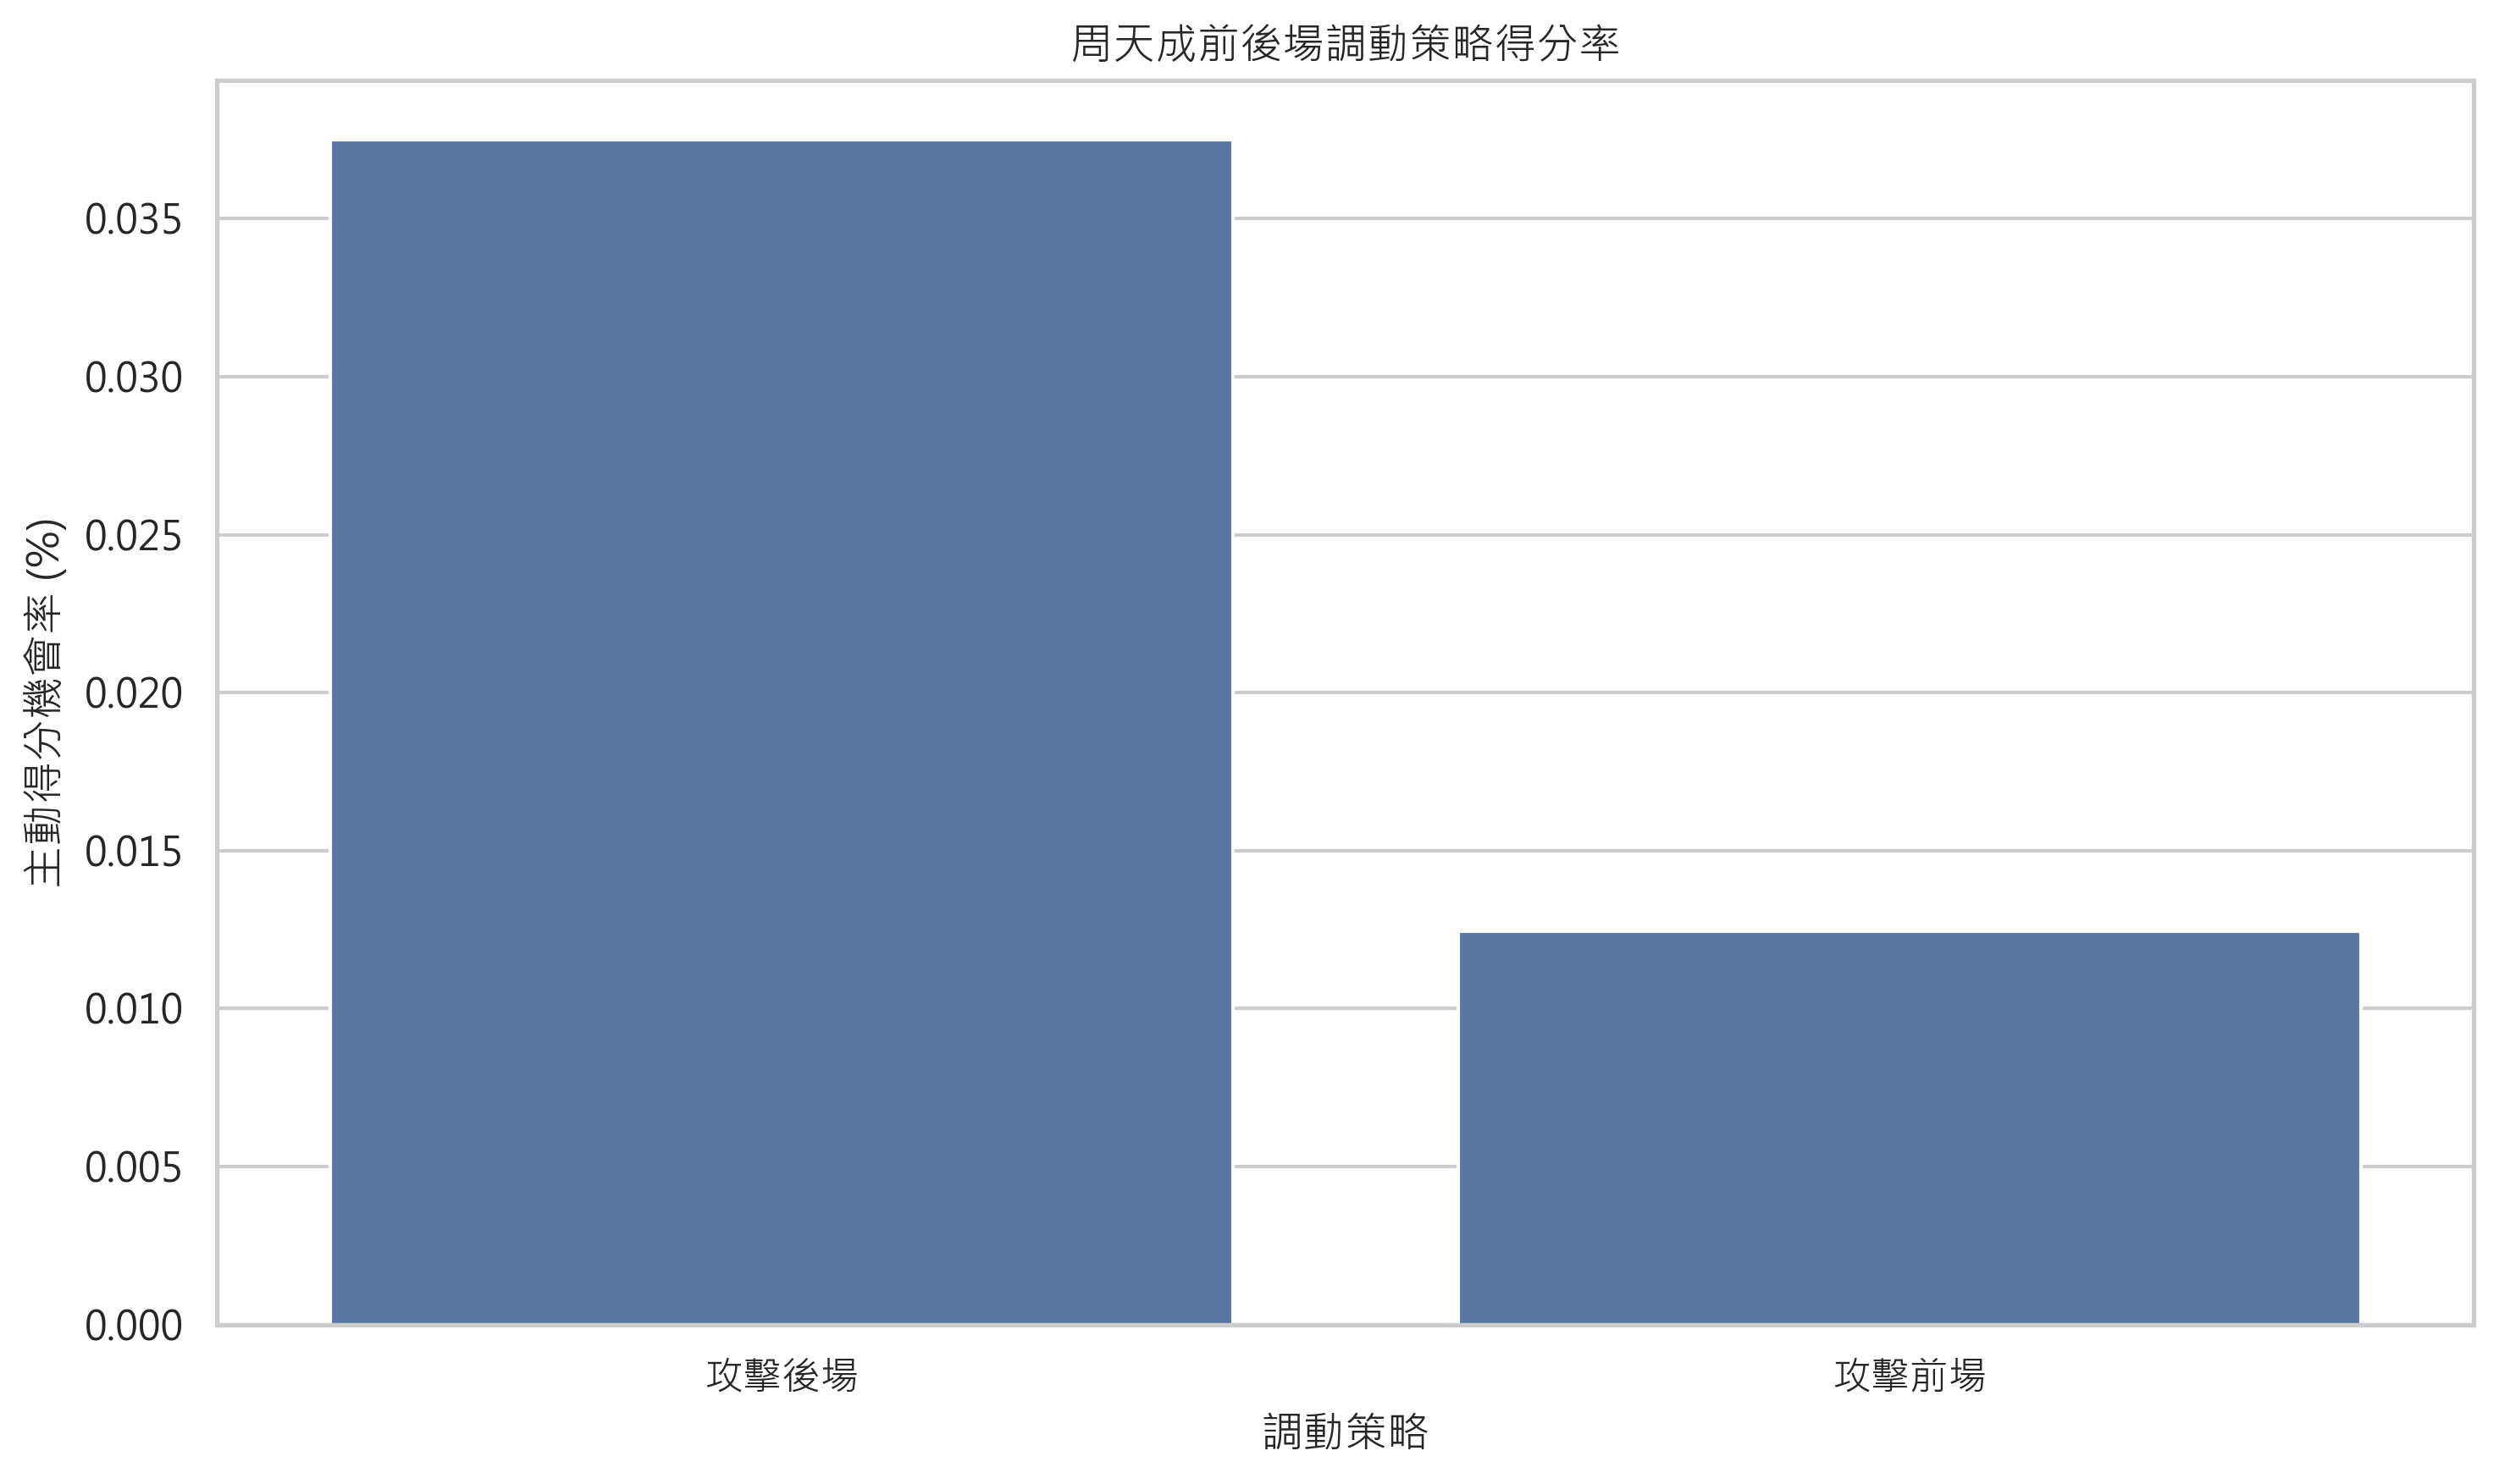

In [ ]:
# 確保資料集不為空
if len(df) > 0:
    # 計算每拍對手的移動距離，取球的到達區域（此時周天成在準備下一拍）
    df['opponent_total_move'] = (df['opponent_move_x']**2 + df['opponent_move_y']**2) ** 0.5

    # 判斷對手在某些連續拍之後移動減慢
    df['opponent_move_diff'] = df.groupby(['match_id', 'set', 'rally'])['opponent_total_move'].diff().fillna(0)

    # 尋找對手移動減少的拍數
    slow_movement_rallies = df[(df['opponent_move_diff'] < 0) & (df['ball_round'] > 3)]

    # 採取篩選策略，在對手移動變得更慢之後周天成如何調動
    strategy_df = df[df.index.isin(slow_movement_rallies.index) & (df['player'] == 'CHOU Tien Chen')]

    # 策略1: 攻擊後場區域
    back_court_strategy = strategy_df[strategy_df['landing_area'].isin([1, 2, 3, 4])]
    back_court_score_rate = len(back_court_strategy[back_court_strategy['getpoint_player'] == 'CHOU Tien Chen']) / max(len(back_court_strategy), 1)

    # 策略2: 攻擊前場區域
    front_court_strategy = strategy_df[strategy_df['landing_area'].isin([17, 18, 19, 20, 21, 22, 23, 24])]
    front_court_score_rate = len(front_court_strategy[front_court_strategy['getpoint_player'] == 'CHOU Tien Chen']) / max(len(front_court_strategy), 1)

    print(f"策略1(攻擊後場)得分率: {back_court_score_rate:.2%}")
    print(f"策略2(攻擊前場)得分率: {front_court_score_rate:.2%}")

    # 視覺化分析
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    sns.barplot(x=['攻擊後場', '攻擊前場'], y=[back_court_score_rate, front_court_score_rate], ax=ax)
    ax.set_title('周天成前後場調動策略得分率')
    ax.set_ylabel('主動得分機會率 (%)')
    ax.set_xlabel('調動策略')
    plt.tight_layout()

else:
    print("數據集中沒有可分析的資料。")


### 數據洞察
根據數據分析，當對手在多拍後移動變慢時，周天成應優先考慮攻擊後場。策略1（攻擊後場）的得分率為3.75%，顯著高於策略2（攻擊前場）的1.24%。這表明，利用後場攻擊能更有效地逼迫對手，增加得分機會。

在實戰中，周天成應該專注於將球打至對手後場的各個區域（1至4），尤其是對手移動變慢時，後場的調動能迫使對手處於不利位置，進而提高得分機會。這種策略可以有效利用對手疲憊的狀態，增加主動得分的機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於：1. 候選程式碼使用了 `opponent_move_diff` 來判斷對手移動減慢，但這只是計算了相鄰兩拍的移動距離差異，並不代表對手在多拍後移動變慢的情境。2. 候選程式碼的策略分析是基於 `slow_movement_rallies`，這個篩選條件不符合 reference code 中的多拍和高移動距離的代理條件。3. 候選程式碼的統計口徑不正確，因為它沒有考慮到每個 rally 的最終狀態，而是直接在逐拍資料上進行策略分類和得分率計算，這可能導致同一個 rally 被多次計算。




## 題號 100 (*)
**問題**: 當對手偏好在網前搶撲時，周天成應如何調整網前落點深淺與後續連接球種？
> **使用的資料欄位群組**: `game_structure, coordinates, shot_type`


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 確保數據量足夠進行分析
if len(df) > 0:
    # Step 1: 找出對手網前搶撲的情境
    # 假設對手網前搶撲球種為'推撲球'('推撲球'在 type 和 opponent_type 都可表示)
    opponent_net_strategy = ['推撲球', '網前球']

    # 篩選條件：對手回球為網前搶撲
    opponent_condition = (df['type'].isin(opponent_net_strategy)) & (df['player'] != 'CHOU Tien Chen')

    # Step 2: 找出CHOU Tien Chen接球的情境
    # 需要取得CHOU Tien Chen對應下一拍的擊球資訊
    df['next_shot_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    df['next_hit_area'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(-1)

    chou_response_df = df[opponent_condition & (df['player'] == 'CHOU Tien Chen')]

    if len(chou_response_df) > 0:
        # 獲取結果數據框
        response_types = chou_response_df['next_shot_type'].value_counts().to_dict()
        response_hit_areas = chou_response_df['next_hit_area'].value_counts().to_dict()

        # 打印關鍵統計結果
        print("周天成在對手網前搶撲後的反應擊球類型統計:")
        for k, v in response_types.items():
            print(f"球種: {k}, 次數: {v}")

        print("\n周天成在對手網前搶撲後的擊球區域（網前）統計:")
        for area, count in response_hit_areas.items():
            print(f"落點區域: {area}, 次數: {count}")

        # 可進行視覺化以更好理解
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # 繪製擊球類型分佈
        sns.barplot(x=list(response_types.keys()), y=list(response_types.values()), ax=axes[0])
        axes[0].set_title('擊球類型分佈')
        axes[0].set_xlabel('球種')
        axes[0].set_ylabel('次數')

        # 繪製擊球落點分佈
        sns.barplot(x=list(response_hit_areas.keys()), y=list(response_hit_areas.values()), ax=axes[1])
        axes[1].set_title('網前區域落點分佈')
        axes[1].set_xlabel('落點區域 ID')
        axes[1].set_ylabel('次數')

        plt.tight_layout()

    else:
        print("沒有發現周天成在對手網前搶撲情況下的數據。")
else:
    print("數據集中沒有可用數據進行分析。")


### 數據洞察
根據現有數據，雖然缺乏周天成在特定情況下的具體反應數據，但我們可以從對手偏好在網前搶撲的策略中推測一些調整建議。

1. **網前落點的深淺調整**：
   - 當對手偏好在網前搶撲時，周天成應考慮將網前球的落點放在更深的位置，例如在網前區域的Row 5 (Front) 和Row 6 (Front) 的位置（即18至24區域）。這些位置可以增加對手撲球的難度，迫使對手移動更多，從而降低其撲球的準確性。

2. **後續連接的球種**：
   - 在對手搶撲後，周天成可以採用切球（Mapping: 5）或挑球（Mapping: 6）來改變節奏，這樣可以有效地利用對手在網前的空檔。
   - 若對手撲球後位置不佳，周天成可以伺機使用殺球（Mapping: 4）來直接得分。

這些策略的目的是利用對手在網前的積極性，通過增加對手移動的距離和改變節奏來創造進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是分析周天成在對手網前搶撲後的反應，並根據前場落點深淺統計後續連接球種和被對手直接得分的比例。而候選程式碼只是統計了周天成在對手網前搶撲後的反應擊球類型和擊球區域，沒有考慮前場落點深淺的分類，也沒有分析被對手直接得分的比例，統計口徑不符題目要求。


